# Robustness of Graph Fraud Detection on YelpChi

This is the corrected sixth revision of my self-contained Kaggle notebook. The notebook itself is the runtime source of truth for benchmark code, experiment definition, audits, training, results, and figures. It does **not** clone or import the current project repository.

The completed R5 run proved the dual-T4 environment, upstream compatibility repairs, all 504 scientific rows, and the non-interactive plotting hotfix. The post-run audit then found that report uncertainty flattened crossed graph/training seeds and broke clean/stress pairing. This revision preserves the R5 experiment matrix while replacing that reporting layer with seed-aware paired summaries, direct protocol contrasts, worst-case/retention tables, explicit oracle claim scopes, and early-stopping telemetry.

The only project assets downloaded at runtime are YelpChi through DGL and the two allowed upstream research repositories actually evaluated: PMP and SEC-GFD. Package wheels are installed only to create the compatible CUDA environment.


## Research question and final outputs

My question is: **when node features or graph neighborhoods become less reliable, which fraud detectors lose performance, and under which controlled stress?** I compare a feature-only MLP, GraphSAGE, PMP, and SEC-GFD under heterophily, feature camouflage, relation camouflage, and random-edge noise.

A complete top-to-bottom run creates 31 audited graph-ledger rows, evaluates 21 distinct clean/stressed states, runs both evaluation protocols, and finishes with exactly 504 unique successful result rows. It produces seed-aware protocol summaries, paired clean-to-stress effects, paired protocol contrasts, worst-case and retention tables, a perturbation/performance join, three curated composite figures, and a lightweight report archive.

This is a static synthetic robustness benchmark. Oracle scenarios are controlled probes. Oracle graphs used during variant training are privileged-label diagnostics, not realistic attacker simulations, operational rankings, or claims of production readiness.


## Kaggle settings and measured resource budget

Before pressing **Run All**, I set Kaggle to **GPU T4 x2** and turn **Internet on**. No dataset, source package, checkpoint, config, or result file is uploaded manually.

Kaggle may advertise a larger nominal disk than the writable free space visible inside a running session. The failed-run evidence showed 19.5 GiB free before setup and 14.4 GiB afterward. Therefore, this revision checks the measured free space instead of assuming that the nominal 57.6 GiB is empty. It also stores severity-zero variants as references and excludes heavy caches from the final report ZIP.

The two 15 GiB T4 memory pools stay separate, so I run independent model lanes instead of DataParallel. The inline main-v3 matrix is designed for the observed 30 GiB RAM tier and the measured writable disk.


In [1]:
# Imports, notebook-owned paths, and pinned upstream sources.
from collections import deque
from datetime import datetime, timezone
from pathlib import Path
import csv
import hashlib
import json
import os
import platform
import queue
import shutil
import subprocess
import sys
import textwrap
import threading
import time
import urllib.request
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from tqdm.auto import tqdm

WORK_DIR = Path('/kaggle/working')
SOURCE_ROOT = WORK_DIR / 'fraud-notebook-source'
PROJECT_DIR = SOURCE_ROOT  # notebook-written source tree; never cloned
BENCHMARK_DIR = SOURCE_ROOT / 'benchmark'
TESTS_DIR = SOURCE_ROOT / 'tests'
RUNTIME_DIR = WORK_DIR / 'fraud-benchmark-py311'
RUNTIME_PY = RUNTIME_DIR / 'bin' / 'python'
OUT_DIR = WORK_DIR / 'gfd-robustness-v3-final-r6'
CONFIG_REL = Path('notebook_config.json')
CONFIG_PATH = SOURCE_ROOT / CONFIG_REL
MANIFEST_PATH = OUT_DIR / 'kaggle_run_manifest.json'
REPORT_ZIP = WORK_DIR / 'gfd-robustness-v3-report-r6.zip'
HEARTBEAT_SECONDS = 30
NOTEBOOK_IMPLEMENTATION_ID = 'single-source-v3-r6-2026-07-12'

ALLOWED_GITHUB_REPOS = {
    'care_gnn': 'https://github.com/YingtongDou/CARE-GNN',
    'gaga': 'https://github.com/Orion-wyc/GAGA',
    'pmp': 'https://github.com/Xtra-Computing/PMP',
    'secgfd': 'https://github.com/Sunxkissed/SEC-GFD',
}
ACTIVE_UPSTREAMS = {
    'pmp': {
        'url': ALLOWED_GITHUB_REPOS['pmp'],
        'commit': '3f7629f6c180891a0bc1bba3c66d94d288a1ddae',
        'path': SOURCE_ROOT / 'Repos/PMP-master',
    },
    'secgfd': {
        'url': ALLOWED_GITHUB_REPOS['secgfd'],
        'commit': '97faa51145ed1fbcbdc67cc5d399490da9a9797a',
        'path': SOURCE_ROOT / 'Repos/SEC-GFD-main',
    },
}

MODEL_ORDER = ['mlp', 'sage', 'pmp', 'secgfd']
PROTOCOL_ORDER = ['train_on_variant', 'train_clean_eval_all']
SCENARIO_ORDER = [
    'heterophily_rewire_oracle',
    'heterophily_rewire_nonoracle',
    'camouflage_feature_oracle',
    'camouflage_relation_oracle',
    'noise_edges_uniform',
]

SOURCE_ROOT.mkdir(parents=True, exist_ok=True)
BENCHMARK_DIR.mkdir(exist_ok=True)
TESTS_DIR.mkdir(exist_ok=True)

def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open('rb') as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b''):
            digest.update(chunk)
    return digest.hexdigest()


RUN_ATTEMPT_ID = datetime.now(timezone.utc).isoformat()
SETUP_RECEIPTS = {}
GRAPH_STAGE_READY = False
NATIVE_LINKER_VALIDATED = False
CUDA_RUNTIME_VALIDATED = False
ADAPTERS_VALIDATED = False
NOTEBOOK_TESTS_PASSED = False
RUNTIME_INFO = []
ADAPTER_CLASSES = {}
ADAPTER_PROBE_INFO = {}

SETUP_RECEIPT_ORDER = (
    'preflight', 'venv', 'packages', 'native_linker', 'post_setup_disk',
    'upstreams', 'upstream_patches', 'config', 'embedded_modules',
    'cuda_runtime', 'adapters', 'tests', 'experiment_scale',
)

def invalidate_setup_from(stage: str) -> None:
    # A retried setup cell invalidates itself and every dependent success marker.
    global NATIVE_LINKER_VALIDATED, CUDA_RUNTIME_VALIDATED
    global ADAPTERS_VALIDATED, NOTEBOOK_TESTS_PASSED, RUNTIME_INFO
    global ADAPTER_CLASSES, ADAPTER_PROBE_INFO
    if stage not in SETUP_RECEIPT_ORDER:
        raise ValueError(f'Unknown setup stage: {stage}')
    start = SETUP_RECEIPT_ORDER.index(stage)
    removed = []
    for name in SETUP_RECEIPT_ORDER[start:]:
        if name in SETUP_RECEIPTS:
            removed.append(name)
        SETUP_RECEIPTS.pop(name, None)

    if start <= SETUP_RECEIPT_ORDER.index('native_linker'):
        NATIVE_LINKER_VALIDATED = False
        for variable in (
            'CUDA_LIBRARY_DIRS', 'DGL_NATIVE_LIBRARY',
            'RUNTIME_LD_LIBRARY_PATH', 'runtime_env',
        ):
            globals().pop(variable, None)
    if start <= SETUP_RECEIPT_ORDER.index('cuda_runtime'):
        CUDA_RUNTIME_VALIDATED = False
        RUNTIME_INFO = []
    if start <= SETUP_RECEIPT_ORDER.index('adapters'):
        ADAPTERS_VALIDATED = False
        ADAPTER_CLASSES = {}
        ADAPTER_PROBE_INFO = {}
    if start <= SETUP_RECEIPT_ORDER.index('tests'):
        NOTEBOOK_TESTS_PASSED = False
    if removed:
        print(f'[setup invalidated from {stage}] {removed}')

def phase_is_ready(required: str) -> bool:
    # The manifest cell replaces this conservative default after validating setup.
    return False

def setup_receipts_ready(*names: str) -> bool:
    return all(
        SETUP_RECEIPTS.get(name, {}).get('attempt_id') == RUN_ATTEMPT_ID
        for name in names
    )

def record_setup_receipt(name: str, evidence: dict | None = None) -> None:
    receipt = {
        'attempt_id': RUN_ATTEMPT_ID,
        'recorded_utc': datetime.now(timezone.utc).isoformat(),
        'evidence': evidence or {},
    }
    # Fail here if evidence cannot be persisted in the final JSON manifest.
    json.dumps(receipt)
    SETUP_RECEIPTS[name] = receipt
    print(f'[setup receipt] {name}')

print('Notebook implementation:', NOTEBOOK_IMPLEMENTATION_ID)
print('Notebook-owned source:', SOURCE_ROOT)
print('Final output:', OUT_DIR)


Notebook implementation: single-source-v3-r6-2026-07-12
Notebook-owned source: /kaggle/working/fraud-notebook-source
Final output: /kaggle/working/gfd-robustness-v3-final-r6


In [2]:
invalidate_setup_from('preflight')
# Check Kaggle, Internet, two T4 GPUs, RAM, and measured writable disk.
assert WORK_DIR.exists(), 'This notebook must run inside Kaggle with /kaggle/working available.'

gpu_query = subprocess.check_output(
    [
        'nvidia-smi',
        '--query-gpu=index,name,memory.total,driver_version',
        '--format=csv,noheader,nounits',
    ],
    text=True,
).strip().splitlines()
GPU_ROWS = []
for line in gpu_query:
    index, name, memory_mib, driver = [part.strip() for part in line.split(',', 3)]
    GPU_ROWS.append(
        {'index': int(index), 'name': name, 'memory_mib': int(memory_mib), 'driver': driver}
    )

meminfo = {}
for line in Path('/proc/meminfo').read_text().splitlines():
    key, value = line.split(':', 1)
    meminfo[key] = int(value.strip().split()[0]) * 1024
ram_gib = meminfo['MemTotal'] / 1024**3
disk = shutil.disk_usage(WORK_DIR)
disk_total_gib = disk.total / 1024**3
disk_free_gib = disk.free / 1024**3

probe_url = (
    'https://raw.githubusercontent.com/Xtra-Computing/PMP/'
    f"{ACTIVE_UPSTREAMS['pmp']['commit']}/README.md"
)
with urllib.request.urlopen(probe_url, timeout=20) as response:
    internet_status = response.status

def preflight_csv_rows(path: Path) -> int:
    if not path.exists() or path.stat().st_size == 0:
        return 0
    with path.open('r', newline='', encoding='utf-8') as handle:
        return max(0, sum(1 for _ in csv.reader(handle)) - 1)

complete_cache = (
    preflight_csv_rows(OUT_DIR / 'graph_variants.csv') == 31
    and preflight_csv_rows(OUT_DIR / 'variant_audit.csv') == 31
    and preflight_csv_rows(OUT_DIR / 'results.csv') == 504
)
minimum_free_gib = 2.0 if complete_cache else 12.0

display(pd.DataFrame(GPU_ROWS))
print(f'RAM: {ram_gib:.1f} GiB')
print(f'Writable disk total/free: {disk_total_gib:.1f}/{disk_free_gib:.1f} GiB')
print(f'Minimum for this state: {minimum_free_gib:.1f} GiB')
print(f'Allowed-source Internet probe: HTTP {internet_status}')

assert len(GPU_ROWS) == 2, 'Select Kaggle accelerator GPU T4 x2 before running.'
assert all('T4' in row['name'] for row in GPU_ROWS), f'Expected two T4 GPUs, found: {GPU_ROWS}'
assert all(row['memory_mib'] >= 14_000 for row in GPU_ROWS), 'Each GPU needs about 15 GiB VRAM.'
assert ram_gib >= 28, f'This benchmark expects about 30 GiB RAM; found {ram_gib:.1f} GiB.'
assert disk_free_gib >= minimum_free_gib, (
    f'Need at least {minimum_free_gib:.1f} GiB writable disk for this run state; '
    f'found {disk_free_gib:.1f} GiB.'
)
assert internet_status == 200, 'Internet must be enabled in Kaggle settings.'
record_setup_receipt('preflight', {
    'gpu_count': len(GPU_ROWS),
    'ram_gib': round(ram_gib, 3),
    'disk_free_gib': round(disk_free_gib, 3),
    'disk_total_gib': round(disk_total_gib, 3),
    'complete_cache_detected': complete_cache,
})


,index,name,memory_mib,driver
0,0,Tesla T4,15360,580.159.04
1,1,Tesla T4,15360,580.159.04


RAM: 31.3 GiB
Writable disk total/free: 19.5/19.5 GiB
Minimum for this state: 12.0 GiB
Allowed-source Internet probe: HTTP 200
[setup receipt] preflight


## Isolated CUDA runtime

Kaggle's host Python can change over time. DGL 1.1.3 provides the required CUDA 11.8 wheel for CPython 3.11, so I leave the notebook kernel untouched and create an isolated Python 3.11 runtime for benchmark subprocesses. No kernel restart is needed.

The PyTorch 2.1.0 CUDA 11.8 wheel contains an internal hash-renamed CUDA runtime file, but DGL requests the canonical names `libcudart.so.11.0` and `libcusparse.so.11`. I therefore install the official pinned `nvidia-cuda-runtime-cu11==11.8.89` and `nvidia-cusparse-cu11==11.7.5.86` wheels explicitly, then verify and hash their real files before importing DGL.

Official references: [uv managed Python](https://docs.astral.sh/uv/guides/install-python/), [PyTorch CUDA 11.8 wheels](https://docs.pytorch.org/get-started/previous-versions/), the [official CUDA 11.8 runtime wheel](https://download.pytorch.org/whl/cu118/nvidia-cuda-runtime-cu11/), the [official CUDA 11.8 cuSPARSE wheel](https://download.pytorch.org/whl/cu118/nvidia-cusparse-cu11/), and the [DGL CUDA 11.8 wheel index](https://data.dgl.ai/wheels/cu118/repo.html).


In [3]:
invalidate_setup_from('venv')
if setup_receipts_ready('preflight'):
    # Create or reuse the managed Python 3.11 virtual environment.
    UV_EXE = shutil.which('uv')
    if UV_EXE is None:
        subprocess.run(
            [sys.executable, '-m', 'pip', 'install', '--no-cache-dir', 'uv==0.8.15'],
            check=True,
        )
        UV_EXE = shutil.which('uv')
    assert UV_EXE is not None, 'uv installation failed.'

    uv_env = os.environ.copy()
    uv_env.pop('UV_SYSTEM_PYTHON', None)
    uv_env['UV_LINK_MODE'] = 'copy'
    if not RUNTIME_PY.exists():
        subprocess.run(
            [UV_EXE, 'venv', '--python', '3.11', '--seed', str(RUNTIME_DIR)],
            env=uv_env,
            check=True,
        )

    runtime_version = subprocess.check_output(
        [str(RUNTIME_PY), '-c', 'import sys; print(sys.version)'], text=True
    ).strip()
    assert runtime_version.startswith('3.11.'), runtime_version
    UV_VERSION = subprocess.check_output([UV_EXE, '--version'], text=True).strip()
    print('uv:', UV_VERSION)
    print('isolated Python:', runtime_version)
    record_setup_receipt('venv', {
        'python_version': runtime_version,
        'uv_version': UV_VERSION,
    })
else:
    print('BLOCKED: preflight setup receipt prerequisite is not satisfied in this run attempt.')


Using CPython 3.11.15
Creating virtual environment with seed packages at: fraud-benchmark-py311


uv: uv 0.11.13 (x86_64-unknown-linux-gnu)
isolated Python: 3.11.15 (main, May 10 2026, 19:28:18) [Clang 22.1.3 ]
[setup receipt] venv


 + packaging==26.2
 + pip==26.1.2
 + setuptools==83.0.0
 + wheel==0.47.0
Activate with: source fraud-benchmark-py311/bin/activate


In [4]:
invalidate_setup_from('packages')
if setup_receipts_ready('venv'):
    # Install only the packages used by the integrated benchmark paths.
    pip_base = [str(RUNTIME_PY), '-m', 'pip', 'install', '--no-cache-dir']
    cuda_runtime_url = (
        'https://download.pytorch.org/whl/cu118/'
        'nvidia_cuda_runtime_cu11-11.8.89-py3-none-manylinux1_x86_64.whl'
        '#sha256=f587bd726eb2f7612cf77ce38a2c1e65cf23251ff49437f6161ce0d647f64f7c'
    )
    cusparse_url = (
        'https://download.pytorch.org/whl/cu118/'
        'nvidia_cusparse_cu11-11.7.5.86-py3-none-manylinux1_x86_64.whl'
        '#sha256=4ae709fe78d3f23f60acaba8c54b8ad556cf16ca486e0cc1aa92dca7555d2d2b'
    )
    install_commands = [
        pip_base + [
            'numpy==1.26.4', 'scipy==1.11.4', 'sympy==1.12', 'mpmath==1.3.0', 'PyYAML==6.0.2',
            'pandas==2.2.3', 'matplotlib==3.9.2', 'tqdm==4.67.1', 'pytest==8.3.5',
        ],
        pip_base + [
            'torch==2.1.0+cu118',
            '--index-url', 'https://download.pytorch.org/whl/cu118',
        ],
        pip_base + ['--no-deps', cuda_runtime_url],
        pip_base + ['--no-deps', cusparse_url],
        pip_base + [
            'dgl==1.1.3+cu118',
            '-f', 'https://data.dgl.ai/wheels/cu118/repo.html',
        ],
    ]

    for step, command in enumerate(install_commands, start=1):
        print(f'\n[package step {step}/{len(install_commands)}]')
        print('$', ' '.join(command))
        subprocess.run(command, check=True)

    subprocess.run([str(RUNTIME_PY), '-m', 'pip', 'check'], check=True)
    package_probe = textwrap.dedent(
        '''
        import importlib.metadata
        import json
        from pathlib import Path
        import torch

        site_root = Path(torch.__file__).resolve().parent.parent
        cudart_files = sorted({
            str(path.resolve())
            for path in (site_root / 'nvidia/cuda_runtime/lib').glob('libcudart.so.11.0')
        })
        cusparse_files = sorted({
            str(path.resolve())
            for path in (site_root / 'nvidia/cusparse/lib').glob('libcusparse.so.11*')
        })
        print(json.dumps({
            'torch': torch.__version__,
            'dgl': importlib.metadata.version('dgl'),
            'nvidia_cuda_runtime_cu11': importlib.metadata.version('nvidia-cuda-runtime-cu11'),
            'nvidia_cusparse_cu11': importlib.metadata.version('nvidia-cusparse-cu11'),
            'cudart_files': cudart_files,
            'cusparse_files': cusparse_files,
        }))
        '''
    )
    PACKAGE_INFO = json.loads(
        subprocess.check_output([str(RUNTIME_PY), '-c', package_probe], text=True).strip().splitlines()[-1]
    )
    assert PACKAGE_INFO['torch'] == '2.1.0+cu118', PACKAGE_INFO
    assert PACKAGE_INFO['dgl'] == '1.1.3+cu118', PACKAGE_INFO
    assert PACKAGE_INFO['nvidia_cuda_runtime_cu11'] == '11.8.89', PACKAGE_INFO
    assert PACKAGE_INFO['nvidia_cusparse_cu11'] == '11.7.5.86', PACKAGE_INFO
    assert len(PACKAGE_INFO['cudart_files']) == 1, (
        'The pinned CUDA runtime package did not provide exactly one canonical libcudart.so.11.0.'
    )
    assert PACKAGE_INFO['cusparse_files'], (
        'The pinned cuSPARSE package installed without libcusparse.so.11.'
    )

    NATIVE_LIBRARY_EVIDENCE = []
    native_paths = [
        ('cuda_runtime', PACKAGE_INFO['cudart_files'][0]),
        *[('cusparse', path) for path in PACKAGE_INFO['cusparse_files']],
    ]
    for component, raw_path in tqdm(native_paths, desc='Hash CUDA 11 runtime files', unit='file'):
        path = Path(raw_path)
        NATIVE_LIBRARY_EVIDENCE.append({
            'component': component,
            'path': str(path),
            'bytes': path.stat().st_size,
            'sha256': sha256_file(path),
        })
    cudart_evidence = [
        row for row in NATIVE_LIBRARY_EVIDENCE if row['component'] == 'cuda_runtime'
    ]
    assert cudart_evidence[0]['sha256'] == (
        'd0da41ae1323cf4eeb610123d69d7714124cfe5ebfcc4e45f02b910e51c57ee6'
    ), cudart_evidence
    display(pd.DataFrame(NATIVE_LIBRARY_EVIDENCE))
    print('Python dependency check and canonical CUDA 11 runtime inventory are complete.')
    record_setup_receipt('packages', {
        **PACKAGE_INFO,
        'native_libraries': NATIVE_LIBRARY_EVIDENCE,
    })
else:
    print('BLOCKED: venv setup receipt prerequisite is not satisfied in this run attempt.')



[package step 1/5]
$ /kaggle/working/fraud-benchmark-py311/bin/python -m pip install --no-cache-dir numpy==1.26.4 scipy==1.11.4 sympy==1.12 mpmath==1.3.0 PyYAML==6.0.2 pandas==2.2.3 matplotlib==3.9.2 tqdm==4.67.1 pytest==8.3.5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 206.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 329.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 355.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 558.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 763.0/763.0 kB 386.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 333.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 334.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 260.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 485.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 309.4 MB/s  0:00:00


[packa

Hash CUDA 11 runtime files:   0%|          | 0/2 [00:00<?, ?file/s]

,component,path,bytes,sha256
0,cuda_runtime,/kaggle/working/fraud-benchmark-py311/lib/pyth...,679264,d0da41ae1323cf4eeb610123d69d7714124cfe5ebfcc4e...
1,cusparse,/kaggle/working/fraud-benchmark-py311/lib/pyth...,279899536,8c7d6b64b4c4722420dfaed9e1700a2a01b35fe196ce93...


Python dependency check and canonical CUDA 11 runtime inventory are complete.
[setup receipt] packages


### Resolve native CUDA libraries before importing DGL

Matching wheel labels and a successful `pip check` do not prove that an external native extension can resolve every exact ELF filename. The previous target run found cuSPARSE but showed `libcudart.so.11.0 => not found`: PyTorch's hash-renamed file was not a canonical loader target. The package cell now installs both genuine CUDA 11 providers. This cell prints both resolved files, prepends all NVIDIA and PyTorch library directories to child processes, and runs `ldd` on DGL before any dataset or model code starts.


In [5]:
invalidate_setup_from('native_linker')
if setup_receipts_ready('packages'):
    # Discover CUDA library directories and verify DGL's complete native dependency chain.
    library_probe = textwrap.dedent(
        '''
        import json
        from pathlib import Path
        import torch

        site_root = Path(torch.__file__).resolve().parent.parent
        candidates = [Path(torch.__file__).resolve().parent / 'lib']
        nvidia_root = site_root / 'nvidia'
        if nvidia_root.exists():
            candidates.extend(sorted(nvidia_root.glob('*/lib')))
        directories = [str(path.resolve()) for path in candidates if path.is_dir()]
        cudart = sorted({
            str(path.resolve())
            for directory in map(Path, directories)
            for path in directory.glob('libcudart.so.11.0')
        })
        cusparse = sorted({
            str(path.resolve())
            for directory in map(Path, directories)
            for path in directory.glob('libcusparse.so.11*')
        })
        print(json.dumps({
            'directories': directories,
            'cudart': cudart,
            'cusparse': cusparse,
        }))
        '''
    )
    library_info = json.loads(
        subprocess.check_output([str(RUNTIME_PY), '-c', library_probe], text=True).strip().splitlines()[-1]
    )
    CUDA_LIBRARY_DIRS = library_info['directories']
    display(pd.DataFrame({'CUDA library directory': CUDA_LIBRARY_DIRS}))
    print('Resolved canonical CUDA 11 files:')
    for component in ('cudart', 'cusparse'):
        for path in library_info[component]:
            print(f' - {component}: {path}')
    assert CUDA_LIBRARY_DIRS, 'No CUDA library directories were found in the isolated runtime.'
    assert library_info['cudart'], (
        'libcudart.so.11.0 was not found under the pinned NVIDIA CUDA runtime package.'
    )
    assert library_info['cusparse'], (
        'libcusparse.so.11 was not found under the pinned NVIDIA cuSPARSE package.'
    )

    previous_ld_path = os.environ.get('LD_LIBRARY_PATH', '')
    ld_parts = CUDA_LIBRARY_DIRS + ([previous_ld_path] if previous_ld_path else [])
    RUNTIME_LD_LIBRARY_PATH = os.pathsep.join(dict.fromkeys(ld_parts))
    os.environ['LD_LIBRARY_PATH'] = RUNTIME_LD_LIBRARY_PATH

    def runtime_env(physical_gpu: int | None = None) -> dict[str, str]:
        env = os.environ.copy()
        env['DGLBACKEND'] = 'pytorch'
        env['PYTHONUNBUFFERED'] = '1'
        env['OMP_NUM_THREADS'] = '2'
        env['MKL_NUM_THREADS'] = '2'
        env['LD_LIBRARY_PATH'] = RUNTIME_LD_LIBRARY_PATH
        if physical_gpu is not None:
            env['CUDA_VISIBLE_DEVICES'] = str(physical_gpu)
        return env

    dgl_location_script = textwrap.dedent(
        '''
        import importlib.util
        from pathlib import Path
        spec = importlib.util.find_spec('dgl')
        assert spec is not None and spec.submodule_search_locations
        root = Path(next(iter(spec.submodule_search_locations)))
        libraries = list(root.rglob('libdgl.so'))
        assert len(libraries) == 1, libraries
        print(libraries[0])
        '''
    )
    DGL_NATIVE_LIBRARY = Path(
        subprocess.check_output([str(RUNTIME_PY), '-c', dgl_location_script], text=True).strip()
    )
    ldd_result = subprocess.run(
        ['ldd', str(DGL_NATIVE_LIBRARY)],
        env=runtime_env(),
        text=True,
        capture_output=True,
    )
    print(ldd_result.stdout)
    if ldd_result.stderr:
        print(ldd_result.stderr)
    assert ldd_result.returncode == 0, f'ldd failed for {DGL_NATIVE_LIBRARY}'
    unresolved = [line.strip() for line in ldd_result.stdout.splitlines() if 'not found' in line]
    assert not unresolved, 'Unresolved DGL native libraries:\n' + '\n'.join(unresolved)
    NATIVE_LINKER_VALIDATED = True
    record_setup_receipt('native_linker', {
        'dgl_library': str(DGL_NATIVE_LIBRARY),
        'dgl_library_sha256': sha256_file(DGL_NATIVE_LIBRARY),
        'cuda_library_dirs': CUDA_LIBRARY_DIRS,
        'cudart_files': library_info['cudart'],
        'cusparse_files': library_info['cusparse'],
        'ldd_output': ldd_result.stdout,
    })
else:
    print('BLOCKED: packages setup receipt prerequisite is not satisfied in this run attempt.')


,CUDA library directory
0,/kaggle/working/fraud-benchmark-py311/lib/pyth...
1,/kaggle/working/fraud-benchmark-py311/lib/pyth...
2,/kaggle/working/fraud-benchmark-py311/lib/pyth...


Resolved canonical CUDA 11 files:
 - cudart: /kaggle/working/fraud-benchmark-py311/lib/python3.11/site-packages/nvidia/cuda_runtime/lib/libcudart.so.11.0
 - cusparse: /kaggle/working/fraud-benchmark-py311/lib/python3.11/site-packages/nvidia/cusparse/lib/libcusparse.so.11
	linux-vdso.so.1 (0x00007e8a2f17e000)
	libdl.so.2 => /lib/x86_64-linux-gnu/libdl.so.2 (0x00007e8a2f163000)
	librt.so.1 => /lib/x86_64-linux-gnu/librt.so.1 (0x00007e8a2f15e000)
	libcudart.so.11.0 => /kaggle/working/fraud-benchmark-py311/lib/python3.11/site-packages/nvidia/cuda_runtime/lib/libcudart.so.11.0 (0x00007e8a18200000)
	libcublas.so.11 => /kaggle/working/fraud-benchmark-py311/lib/python3.11/site-packages/torch/lib/libcublas.so.11 (0x00007e8a12400000)
	libcusparse.so.11 => /kaggle/working/fraud-benchmark-py311/lib/python3.11/site-packages/nvidia/cusparse/lib/libcusparse.so.11 (0x00007e8a01600000)
	libgomp.so.1 => /lib/x86_64-linux-gnu/libgomp.so.1 (0x00007e8a2f112000)
	libpthread.so.0 => /lib/x86_64-linux-gnu/lib

In [6]:
invalidate_setup_from('post_setup_disk')
if setup_receipts_ready('packages'):
    # Check writable disk again after installing the isolated runtime.
    runtime_bytes = sum(path.stat().st_size for path in RUNTIME_DIR.rglob('*') if path.is_file())
    source_bytes = sum(path.stat().st_size for path in SOURCE_ROOT.rglob('*') if path.is_file())
    post_setup_free_gib = shutil.disk_usage(WORK_DIR).free / 1024**3
    graph_cache_complete = (
        preflight_csv_rows(OUT_DIR / 'graph_variants.csv') == 31
        and preflight_csv_rows(OUT_DIR / 'variant_audit.csv') == 31
    )
    post_setup_minimum_gib = 2.0 if graph_cache_complete else 8.0
    display(pd.DataFrame([{
        'isolated runtime GiB': runtime_bytes / 1024**3,
        'notebook source GiB': source_bytes / 1024**3,
        'writable disk free GiB': post_setup_free_gib,
        'minimum before graph stage GiB': post_setup_minimum_gib,
    }]).round(3))
    assert post_setup_free_gib >= post_setup_minimum_gib, (
        f'Only {post_setup_free_gib:.1f} GiB remains after setup; '
        f'{post_setup_minimum_gib:.1f} GiB is required for the remaining run state.'
    )
    record_setup_receipt('post_setup_disk', {
        'runtime_gib': round(runtime_bytes / 1024**3, 3),
        'disk_free_gib': round(post_setup_free_gib, 3),
    })
else:
    print('BLOCKED: packages setup receipt prerequisite is not satisfied in this run attempt.')


,isolated runtime GiB,notebook source GiB,writable disk free GiB,minimum before graph stage GiB
0,5.33,0.0,14.157,8.0


[setup receipt] post_setup_disk


## Download only the allowed research implementations

`Repos/Github-links.md` lists CARE-GNN, GAGA, PMP, and SEC-GFD. This experiment executes PMP and SEC-GFD, so I pin and fetch only those two allowed upstream repositories. CARE-GNN and GAGA remain literature motivation; downloading unused code would add no evidence to the final matrix.


In [7]:
invalidate_setup_from('upstreams')
if setup_receipts_ready('native_linker', 'post_setup_disk'):
    # Fetch or repair the two active upstream repositories at exact commits.
    upstream_rows = []
    for name, spec in ACTIVE_UPSTREAMS.items():
        assert spec['url'] in ALLOWED_GITHUB_REPOS.values()
        repo_path = Path(spec['path'])

        repository_is_valid = False
        if (repo_path / '.git').is_dir():
            check = subprocess.run(
                ['git', '-C', str(repo_path), 'rev-parse', '--is-inside-work-tree'],
                text=True,
                capture_output=True,
            )
            repository_is_valid = check.returncode == 0 and check.stdout.strip() == 'true'

        if repo_path.exists() and not repository_is_valid:
            resolved = repo_path.resolve()
            assert SOURCE_ROOT.resolve() in resolved.parents, resolved
            shutil.rmtree(resolved)

        if not repo_path.exists():
            repo_path.mkdir(parents=True)
            subprocess.run(
                ['git', '-c', 'init.defaultBranch=main', 'init', '-q', str(repo_path)],
                check=True,
            )

        remote_check = subprocess.run(
            ['git', '-C', str(repo_path), 'remote', 'get-url', 'origin'],
            text=True,
            capture_output=True,
        )
        if remote_check.returncode != 0:
            subprocess.run(
                ['git', '-C', str(repo_path), 'remote', 'add', 'origin', spec['url']],
                check=True,
            )
            remote = spec['url']
        else:
            remote = remote_check.stdout.strip()
        assert remote == spec['url'], f'{name}: unexpected origin {remote}'

        commit_check = subprocess.run(
            ['git', '-C', str(repo_path), 'cat-file', '-e', f"{spec['commit']}^{{commit}}"],
            text=True,
            capture_output=True,
        )
        if commit_check.returncode != 0:
            subprocess.run(
                ['git', '-C', str(repo_path), 'fetch', '--depth', '1', 'origin', spec['commit']],
                check=True,
            )

        head_check = subprocess.run(
            ['git', '-C', str(repo_path), 'rev-parse', 'HEAD'],
            text=True,
            capture_output=True,
        )
        actual = head_check.stdout.strip() if head_check.returncode == 0 else ''
        if actual != spec['commit']:
            dirty = subprocess.run(
                ['git', '-C', str(repo_path), 'diff', '--quiet'],
                capture_output=True,
            ).returncode != 0
            assert not dirty, f'{name}: wrong commit with uncommitted files; start a fresh Kaggle session.'
            subprocess.run(
                [
                    'git', '-C', str(repo_path), '-c', 'advice.detachedHead=false',
                    'checkout', '--detach', spec['commit'],
                ],
                check=True,
            )
            actual = subprocess.check_output(
                ['git', '-C', str(repo_path), 'rev-parse', 'HEAD'], text=True
            ).strip()

        assert actual == spec['commit'], f'{name}: expected {spec["commit"]}, found {actual}'
        upstream_rows.append({'repository': name, 'url': spec['url'], 'commit': actual})

    display(pd.DataFrame(upstream_rows))
    record_setup_receipt('upstreams', {
        row['repository']: row['commit'] for row in upstream_rows
    })
else:
    print('BLOCKED: native linker and post-setup disk receipts prerequisite is not satisfied in this run attempt.')


From https://github.com/Xtra-Computing/PMP
 * branch            3f7629f6c180891a0bc1bba3c66d94d288a1ddae -> FETCH_HEAD
HEAD is now at 3f7629f upd readme
From https://github.com/Sunxkissed/SEC-GFD
 * branch            97faa51145ed1fbcbdc67cc5d399490da9a9797a -> FETCH_HEAD
HEAD is now at 97faa51 Update README.md


,repository,url,commit
0,pmp,https://github.com/Xtra-Computing/PMP,3f7629f6c180891a0bc1bba3c66d94d288a1ddae
1,secgfd,https://github.com/Sunxkissed/SEC-GFD,97faa51145ed1fbcbdc67cc5d399490da9a9797a


[setup receipt] upstreams


### Minimal upstream compatibility patches

The official PMP files import two optional PyTorch-Geometric normalization classes even though this benchmark does not enable those layers. I provide `torch.nn.Identity` aliases when PyG is absent instead of installing an unused dependency chain. SEC-GFD's first GCN needs DGL's documented zero-in-degree allowance for the benchmark graph.

The notebook does not patch whatever text happens to be on disk. It reconstructs each expected file from the pinned commit, applies only the declared replacement, compiles the complete source before and after writing it, runs a small semantic probe, and then checks the exact Git diff, changed paths, repository status, and file hashes. A retry therefore repairs a partial or malformed earlier write instead of accepting it.


In [8]:
invalidate_setup_from('upstream_patches')
if (
    setup_receipts_ready('native_linker', 'upstreams')
    and callable(globals().get('runtime_env'))
):
    # Build every compatibility edit from immutable HEAD, never from a prior patched file.
    print('[patch 1/5] Reconstructing and compiling expected sources from pinned commits...')
    pmp_fallback = (
        'try:\n'
        '    from torch_geometric.nn.norm import GraphNorm, GraphSizeNorm\n'
        'except ImportError:\n'
        '    GraphNorm = nn.Identity\n'
        '    GraphSizeNorm = nn.Identity'
    )
    compile(pmp_fallback, '<generated-pmp-fallback>', 'exec')

    pmp_expected_files = ('model/LASAGE_S.py', 'model/base.py')
    pmp_expected_sources = {}
    direct_pyg_import = 'from torch_geometric.nn.norm import GraphNorm, GraphSizeNorm'
    for relative in pmp_expected_files:
        original = subprocess.check_output(
            [
                'git', '-C', str(ACTIVE_UPSTREAMS['pmp']['path']),
                'show', f'HEAD:{relative}',
            ]
        ).decode('utf-8')
        assert original.count(direct_pyg_import) == 1, (
            f'Pinned PMP source changed unexpectedly: {relative}'
        )
        expected = original.replace(direct_pyg_import, pmp_fallback, 1)
        compile(expected, f'PMP/{relative}', 'exec')
        pmp_expected_sources[relative] = expected

    sec_relative = 'model/SECGFD.py'
    sec_expected = subprocess.check_output(
        [
            'git', '-C', str(ACTIVE_UPSTREAMS['secgfd']['path']),
            'show', f'HEAD:{sec_relative}',
        ]
    ).decode('utf-8')
    sec_replacements = (
        (
            'GraphConv(in_dim, hid_dim)',
            'GraphConv(in_dim, hid_dim, allow_zero_in_degree=True)',
        ),
        (
            'GraphConv(hid_dim, out_dim)',
            'GraphConv(hid_dim, out_dim, allow_zero_in_degree=True)',
        ),
    )
    for before, after in sec_replacements:
        assert sec_expected.count(before) == 1, (
            f'Pinned SEC-GFD source changed unexpectedly: {before}'
        )
        sec_expected = sec_expected.replace(before, after, 1)
    compile(sec_expected, f'SEC-GFD/{sec_relative}', 'exec')

    # All complete sources parsed successfully, so write the exact expected bytes.
    print('[patch 2/5] Writing the deterministic compatibility sources...')
    for relative, expected in pmp_expected_sources.items():
        (ACTIVE_UPSTREAMS['pmp']['path'] / relative).write_text(
            expected, encoding='utf-8'
        )
    sec_path = ACTIVE_UPSTREAMS['secgfd']['path'] / sec_relative
    sec_path.write_text(sec_expected, encoding='utf-8')

    print('[patch 3/5] Compiling patched files with the isolated Python 3.11 runtime...')
    runtime_compile_paths = [
        *(ACTIVE_UPSTREAMS['pmp']['path'] / relative for relative in pmp_expected_files),
        sec_path,
    ]
    compile_result = subprocess.run(
        [str(RUNTIME_PY), '-m', 'py_compile', *(str(path) for path in runtime_compile_paths)],
        env=runtime_env(),
        text=True,
        capture_output=True,
    )
    if compile_result.stdout:
        print(compile_result.stdout)
    if compile_result.stderr:
        print(compile_result.stderr)
    if compile_result.returncode != 0:
        raise RuntimeError(
            'The isolated runtime rejected a generated upstream source file.\n'
            + (compile_result.stderr or compile_result.stdout)
        )

    print('[patch 4/5] Running isolated semantic probes for both upstream edits...')
    upstream_patch_probes = {
        'pmp': textwrap.dedent(
            '''
            import json
            import sys
            from pathlib import Path
            import torch

            repo = Path('Repos/PMP-master').resolve()
            sys.path.insert(0, str(repo))
            from model.LASAGE_S import LASAGE_S
            from model.base import GraphNorm, GraphSizeNorm

            features = torch.randn(3, 4)
            assert GraphNorm(4)(features).shape == features.shape
            assert GraphSizeNorm()(features).shape == features.shape
            print(json.dumps({
                'model_class': LASAGE_S.__name__,
                'graph_norm_class': GraphNorm.__name__,
                'graph_size_norm_class': GraphSizeNorm.__name__,
                'shape': list(features.shape),
            }))
            '''
        ),
        'secgfd': textwrap.dedent(
            '''
            import importlib.util
            import json
            from pathlib import Path
            import dgl
            import torch

            model_path = Path('Repos/SEC-GFD-main/model/SECGFD.py').resolve()
            spec = importlib.util.spec_from_file_location('secgfd_patch_probe', model_path)
            assert spec is not None and spec.loader is not None
            module = importlib.util.module_from_spec(spec)
            spec.loader.exec_module(module)
            graph = dgl.graph((torch.tensor([0]), torch.tensor([1])), num_nodes=3)
            output = module.GCN(4, 3, 2, graph)(torch.randn(3, 4))
            assert tuple(output.shape) == (3, 2)
            assert torch.isfinite(output).all()
            print(json.dumps({
                'model_class': module.SECGFD.__name__,
                'gcn_shape': list(output.shape),
                'zero_in_degree_nodes': int((graph.in_degrees() == 0).sum()),
            }))
            '''
        ),
    }
    UPSTREAM_PATCH_PROBE_INFO = {}
    upstream_probe_failures = []
    for probe_name, probe_source in upstream_patch_probes.items():
        completed = subprocess.run(
            [str(RUNTIME_PY), '-c', probe_source],
            cwd=str(PROJECT_DIR),
            env=runtime_env(),
            text=True,
            capture_output=True,
        )
        if completed.stdout:
            print(f'{probe_name}: {completed.stdout.strip()}')
        if completed.stderr:
            print(completed.stderr)
        if completed.returncode != 0:
            upstream_probe_failures.append(
                f'{probe_name}: exit={completed.returncode}\n'
                f'{completed.stderr or completed.stdout}'
            )
            continue
        UPSTREAM_PATCH_PROBE_INFO[probe_name] = json.loads(
            completed.stdout.strip().splitlines()[-1]
        )
    if upstream_probe_failures:
        raise RuntimeError(
            'Upstream compatibility probe failed:\n\n'
            + '\n\n'.join(upstream_probe_failures)
        )

    print('[patch 5/5] Verifying exact diffs, paths, status, and file hashes...')
    EXPECTED_PATCHED_FILE_HASHES = {'pmp': {}, 'secgfd': {}}
    expected_sources = {
        'pmp': pmp_expected_sources,
        'secgfd': {sec_relative: sec_expected},
    }
    expected_changed_paths = {
        name: set(repo_sources) for name, repo_sources in expected_sources.items()
    }
    UPSTREAM_PATCH_DIFFS = {}
    for name, spec in ACTIVE_UPSTREAMS.items():
        for relative, expected in expected_sources[name].items():
            actual = (spec['path'] / relative).read_text(encoding='utf-8')
            assert actual == expected, f'Unexpected source content: {name}/{relative}'
            EXPECTED_PATCHED_FILE_HASHES[name][relative] = hashlib.sha256(
                actual.encode('utf-8')
            ).hexdigest()

        subprocess.run(
            ['git', '-C', str(spec['path']), 'diff', 'HEAD', '--check'],
            check=True,
        )
        diff = subprocess.check_output(
            ['git', '-C', str(spec['path']), 'diff', 'HEAD'], text=True
        )
        changed = set(filter(None, subprocess.check_output(
            ['git', '-C', str(spec['path']), 'diff', 'HEAD', '--name-only'],
            text=True,
        ).splitlines()))
        assert changed == expected_changed_paths[name], (
            name, changed, expected_changed_paths[name]
        )
        status_lines = subprocess.check_output(
            [
                'git', '-C', str(spec['path']), 'status', '--porcelain',
                '--untracked-files=all',
            ],
            text=True,
        ).splitlines()
        untracked = [line[3:] for line in status_lines if line.startswith('?? ')]
        unexpected_untracked = [
            path for path in untracked
            if '/__pycache__/' not in f'/{path}' and not path.endswith('.pyc')
        ]
        assert not unexpected_untracked, (name, unexpected_untracked)
        UPSTREAM_PATCH_DIFFS[name] = {
            'sha256': hashlib.sha256(diff.encode('utf-8')).hexdigest(),
            'diff': diff,
        }
        print(f'\n--- {name} exact compatibility diff ---\n{diff}')

    record_setup_receipt('upstream_patches', {
        name: {
            'diff_sha256': UPSTREAM_PATCH_DIFFS[name]['sha256'],
            'patched_file_hashes': EXPECTED_PATCHED_FILE_HASHES[name],
            'semantic_probe': UPSTREAM_PATCH_PROBE_INFO[name],
        }
        for name in ACTIVE_UPSTREAMS
    })
    print('Exact, compiled, self-healing upstream compatibility contract passed.')
else:
    print('BLOCKED: native-linker and upstream checkout prerequisites are not satisfied.')


[patch 1/5] Reconstructing and compiling expected sources from pinned commits...
[patch 2/5] Writing the deterministic compatibility sources...
[patch 3/5] Compiling patched files with the isolated Python 3.11 runtime...
[patch 4/5] Running isolated semantic probes for both upstream edits...
pmp: {"model_class": "LASAGE_S", "graph_norm_class": "Identity", "graph_size_norm_class": "Identity", "shape": [3, 4]}
secgfd: {"model_class": "SECGFD", "gcn_shape": [3, 2], "zero_in_degree_nodes": 2}
[patch 5/5] Verifying exact diffs, paths, status, and file hashes...

--- pmp exact compatibility diff ---
diff --git a/model/LASAGE_S.py b/model/LASAGE_S.py
index 897e5f5..c5e4d53 100644
--- a/model/LASAGE_S.py
+++ b/model/LASAGE_S.py
@@ -9,7 +9,11 @@ import math
 from dgl.utils import check_eq_shape, expand_as_pair
 from dgl.utils import check_eq_shape, expand_as_pair
 from dgl.base import DGLError
-from torch_geometric.nn.norm import GraphNorm, GraphSizeNorm
+try:
+    from torch_geometric.nn.norm 

## Inline experiment definition

The compact dictionary below replaces an external config upload. It is the authoritative experiment design for this notebook: YelpChi, one 40/20/40 split, four models, five scenarios, two graph seeds, three training seeds, two protocols, and three imbalance-aware metrics. The values match the report-facing v3 matrix, while unused descriptive fields are removed.


In [9]:
invalidate_setup_from('config')
if setup_receipts_ready('upstream_patches'):
    # Write the notebook-owned experiment definition for subprocesses.
    NOTEBOOK_CONFIG = json.loads(r'''{
      "experiment_name": "gfd_kaggle_notebook_v3_final_r6",
      "datasets": [
        {
          "dataset_id": "yelpchi",
          "source": "dgl.data.FraudDataset",
          "source_name": "yelp"
        }
      ],
      "data_splits": [
        {
          "split_id": "s0",
          "train_size": 0.4,
          "val_size": 0.2,
          "split_seed": 717
        }
      ],
      "graph_representation": {
        "canonical_view": "homogeneous",
        "from_source_view": "heterograph",
        "conversion": "dgl.to_homogeneous"
      },
      "models": [
        {
          "model_id": "mlp"
        },
        {
          "model_id": "sage"
        },
        {
          "model_id": "pmp",
          "repo_path": "Repos/PMP-master",
          "hparams": {
            "full_neighbors": false,
            "sampled_neighbors": [
              10
            ],
            "batch_size": 512,
            "num_workers": 0,
            "epochs": 100,
            "patience": 10
          }
        },
        {
          "model_id": "secgfd",
          "repo_path": "Repos/SEC-GFD-main",
          "hparams": {
            "hid_dim": 32,
            "order_d": 2,
            "high_order": 1,
            "lemda": 0.2,
            "lr": 0.01,
            "weight_decay": 0.0
          }
        }
      ],
      "scenarios": [
        {
          "scenario_id": "heterophily_rewire_oracle",
          "family": "heterophily",
          "scenario_group": "heterophily",
          "severity_param": "p_rewire",
          "severity_values": [
            0.0,
            0.15,
            0.3
          ],
          "method": "rewire_edge_dst_to_opposite_label",
          "oracle_mode": "oracle",
          "oracle_labels": true,
          "graph_view_mode": "heterograph_aware_generation",
          "relation_filter": [
            "net_rsr",
            "net_rtr",
            "net_rur"
          ],
          "allow_self_loops": false,
          "reject_existing": true,
          "reject_duplicates": true,
          "max_attempt_multiplier": 20
        },
        {
          "scenario_id": "heterophily_rewire_nonoracle",
          "family": "heterophily",
          "scenario_group": "heterophily",
          "severity_param": "p_rewire",
          "severity_values": [
            0.0,
            0.15,
            0.3
          ],
          "method": "rewire_edge_dst_to_feature_pseudo_opposite_label",
          "oracle_mode": "non_oracle",
          "oracle_labels": false,
          "graph_view_mode": "heterograph_aware_generation",
          "relation_filter": [
            "net_rsr",
            "net_rtr",
            "net_rur"
          ],
          "allow_self_loops": false,
          "reject_existing": true,
          "reject_duplicates": true,
          "max_attempt_multiplier": 20
        },
        {
          "scenario_id": "camouflage_feature_oracle",
          "family": "camouflage_feature",
          "scenario_group": "camouflage",
          "severity_param": "p_cam_feat",
          "severity_values": [
            0.0,
            0.15,
            0.3
          ],
          "method": "replace_fraud_features_with_normal_features",
          "oracle_mode": "oracle",
          "oracle_labels": true,
          "graph_view_mode": "canonical",
          "gamma": 1.0
        },
        {
          "scenario_id": "camouflage_relation_oracle",
          "family": "camouflage_relation",
          "scenario_group": "camouflage",
          "severity_param": "p_cam_rel",
          "severity_values": [
            0.0,
            0.15,
            0.3
          ],
          "method": "add_relation_camouflage_edges",
          "oracle_mode": "oracle",
          "oracle_labels": true,
          "graph_view_mode": "heterograph_aware_generation",
          "relation_filter": [
            "net_rsr",
            "net_rtr",
            "net_rur"
          ],
          "camouflage_edges_per_node": 2,
          "remove_suspicious_ratio": 0.5,
          "allow_self_loops": false,
          "reject_existing": true,
          "reject_duplicates": true,
          "max_attempt_multiplier": 20
        },
        {
          "scenario_id": "noise_edges_uniform",
          "family": "noise",
          "scenario_group": "noise",
          "severity_param": "edge_noise_rate",
          "severity_values": [
            0.0,
            0.1,
            0.2
          ],
          "method": "add_random_edges",
          "oracle_mode": "non_oracle",
          "oracle_labels": false,
          "graph_view_mode": "heterograph_aware_generation",
          "relation_filter": [
            "net_rsr",
            "net_rtr",
            "net_rur"
          ],
          "undirected": false,
          "allow_self_loops": false,
          "reject_existing": true,
          "reject_duplicates": true,
          "max_attempt_multiplier": 20
        }
      ],
      "seeds": {
        "graph_seeds": [
          0,
          1
        ],
        "training_seeds": [
          0,
          1,
          2
        ]
      },
      "evaluation": {
        "metrics": [
          "roc_auc",
          "average_precision",
          "f1_macro"
        ],
        "threshold_selection": "best_f1_on_validation",
        "no_test_leakage": true,
        "reporting": [
          "mean",
          "std"
        ],
        "export_variant_audit": true,
        "audit_metrics": [
          "n_rewired_edges_actual",
          "heterophily_ratio_before",
          "heterophily_ratio_after",
          "mean_cosine_to_sampled_normal_before",
          "mean_cosine_to_sampled_normal_after",
          "fraud_to_normal_neighbor_ratio_before",
          "fraud_to_normal_neighbor_ratio_after",
          "n_added_edge_pairs_actual"
        ]
      }
    }''')
    CONFIG_PATH.write_text(json.dumps(NOTEBOOK_CONFIG, indent=2, sort_keys=True) + '\n', encoding='utf-8')
    print(CONFIG_PATH)
    record_setup_receipt('config', {'path': str(CONFIG_PATH)})
else:
    print('BLOCKED: upstream patch receipt prerequisite is not satisfied in this run attempt.')


/kaggle/working/fraud-notebook-source/notebook_config.json
[setup receipt] config


## Embedded benchmark implementation

The following cells materialize one focused Python module each under the notebook-owned source directory. Their complete source is stored inside this `.ipynb`; no benchmark code is fetched from the current project repository. The cells are collapsible for presentation, but remain inspectable and are hashed before execution.


In [10]:
%%writefile /kaggle/working/fraud-notebook-source/benchmark/__init__.py
"""Fraud detection robustness benchmark runner.

This package is the integration layer that:
- loads datasets and creates fixed splits
- generates (and caches) graph variants per scenario/severity/seed
- provides a stable results schema for later model integration
"""



Writing /kaggle/working/fraud-notebook-source/benchmark/__init__.py


In [11]:
%%writefile /kaggle/working/fraud-notebook-source/benchmark/config.py
from __future__ import annotations

import json
import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Any


class ConfigError(RuntimeError):
    pass


_SUPPORTED_SCENARIO_METHODS = {
    "rewire_edge_dst_to_opposite_label",
    "rewire_edge_dst_to_feature_pseudo_opposite_label",
    "replace_fraud_features_with_normal_features",
    "add_relation_camouflage_edges",
    "add_random_edges",
}

_ORACLE_MODE_ALIASES = {
    "oracle": "oracle",
    "non_oracle": "non_oracle",
    "nonoracle": "non_oracle",
    "non-oracle": "non_oracle",
}

_GRAPH_VIEW_MODE_ALIASES = {
    "canonical": "canonical",
    "homogeneous": "canonical",
    "heterograph_aware_generation": "heterograph_aware_generation",
    "heterograph-aware-generation": "heterograph_aware_generation",
    "heterograph": "heterograph_aware_generation",
}


@dataclass(frozen=True)
class ExperimentPaths:
    out_dir: Path
    config_copy_path: Path
    results_csv_path: Path
    variants_csv_path: Path
    variant_audit_csv_path: Path
    graphs_dir: Path


def load_json(path: Path) -> dict[str, Any]:
    try:
        with path.open("r", encoding="utf-8") as f:
            return json.load(f)
    except FileNotFoundError as e:
        raise ConfigError(f"Config file not found: {path}") from e
    except json.JSONDecodeError as e:
        raise ConfigError(f"Invalid JSON in config file: {path}") from e


def _validated_seed_list(
    seeds_cfg: dict[str, Any],
    *,
    key: str,
    required: bool,
) -> list[int]:
    value = seeds_cfg.get(key)
    if value is None:
        if required:
            raise ConfigError(f"seeds.{key} must be a non-empty list of integers")
        return []
    if not isinstance(value, list) or not value:
        raise ConfigError(f"seeds.{key} must be a non-empty list of integers")

    out: list[int] = []
    for idx, raw in enumerate(value):
        if isinstance(raw, bool) or not isinstance(raw, int):
            raise ConfigError(f"seeds.{key}[{idx}] must be an integer")
        out.append(int(raw))
    if len(out) != len(set(out)):
        raise ConfigError(f"seeds.{key} must not contain duplicate values")
    return out


def get_training_seeds(cfg: dict[str, Any]) -> list[int]:
    seeds_cfg = cfg.get("seeds")
    if not isinstance(seeds_cfg, dict):
        raise ConfigError("cfg['seeds'] must be an object")
    return _validated_seed_list(seeds_cfg, key="training_seeds", required=True)


def get_graph_seeds(cfg: dict[str, Any]) -> list[int]:
    seeds_cfg = cfg.get("seeds")
    if not isinstance(seeds_cfg, dict):
        raise ConfigError("cfg['seeds'] must be an object")
    graph_seeds = _validated_seed_list(seeds_cfg, key="graph_seeds", required=False)
    if graph_seeds:
        return graph_seeds
    return get_training_seeds(cfg)


def _validate_model_hparams(model_cfg: dict[str, Any]) -> None:
    model_id = str(model_cfg.get("model_id", ""))
    if model_id != "secgfd":
        return

    hparams = model_cfg.get("hparams")
    if hparams is None:
        return
    if not isinstance(hparams, dict):
        raise ConfigError("secgfd.hparams must be an object")

    int_keys = {"hid_dim", "order_d", "high_order"}
    float_keys = {"lemda", "lr", "weight_decay"}
    allowed_keys = int_keys | float_keys

    for key, value in hparams.items():
        if key not in allowed_keys:
            raise ConfigError(f"secgfd.hparams.{key} is not supported")
        if key in int_keys:
            if isinstance(value, bool) or not isinstance(value, int):
                raise ConfigError(f"secgfd.hparams.{key} must be an integer")
            if int(value) <= 0:
                raise ConfigError(f"secgfd.hparams.{key} must be > 0")
        else:
            if isinstance(value, bool) or not isinstance(value, (int, float)):
                raise ConfigError(f"secgfd.hparams.{key} must be a number")
            if key == "lr" and float(value) <= 0.0:
                raise ConfigError("secgfd.hparams.lr must be > 0")
            if key in {"lemda", "weight_decay"} and float(value) < 0.0:
                raise ConfigError(f"secgfd.hparams.{key} must be >= 0")


def _require_non_empty_string(value: Any, *, path: str) -> str:
    if not isinstance(value, str) or not value.strip():
        raise ConfigError(f"{path} must be a non-empty string")
    return str(value).strip()


def _require_bool(value: Any, *, path: str) -> bool:
    if isinstance(value, bool):
        return bool(value)
    raise ConfigError(f"{path} must be a boolean")


def _require_non_negative_number(value: Any, *, path: str) -> float:
    if isinstance(value, bool) or not isinstance(value, (int, float)):
        raise ConfigError(f"{path} must be a number")
    value = float(value)
    if value < 0.0:
        raise ConfigError(f"{path} must be >= 0")
    return value


def _normalize_oracle_mode(value: Any, *, path: str) -> str:
    if not isinstance(value, str) or not value.strip():
        raise ConfigError(f"{path} must be 'oracle' or 'non_oracle'")
    normalized = _ORACLE_MODE_ALIASES.get(str(value).strip().lower())
    if normalized is None:
        raise ConfigError(f"{path} must be 'oracle' or 'non_oracle'")
    return normalized


def scenario_oracle_labels(scenario_cfg: dict[str, Any]) -> bool:
    oracle_mode = scenario_cfg.get("oracle_mode")
    if oracle_mode is not None:
        return _normalize_oracle_mode(oracle_mode, path="scenario.oracle_mode") == "oracle"
    return bool(scenario_cfg.get("oracle_labels", False))


def scenario_graph_view_mode(scenario_cfg: dict[str, Any]) -> str:
    raw_value = scenario_cfg.get("graph_view_mode", "canonical")
    if not isinstance(raw_value, str) or not raw_value.strip():
        raise ConfigError("scenario.graph_view_mode must be 'canonical' or 'heterograph_aware_generation'")
    normalized = _GRAPH_VIEW_MODE_ALIASES.get(str(raw_value).strip().lower())
    if normalized is None:
        raise ConfigError("scenario.graph_view_mode must be 'canonical' or 'heterograph_aware_generation'")
    return normalized


def should_export_variant_audit(cfg: dict[str, Any]) -> bool:
    eval_cfg = cfg.get("evaluation")
    if not isinstance(eval_cfg, dict):
        return True
    return bool(eval_cfg.get("export_variant_audit", True))


def _validate_relation_filter(value: Any, *, path: str) -> None:
    if isinstance(value, str):
        if not value.strip():
            raise ConfigError(f"{path} must not be empty")
        return
    if not isinstance(value, list) or not value:
        raise ConfigError(f"{path} must be a non-empty string or list of non-empty strings")
    for idx, item in enumerate(value):
        if not isinstance(item, str) or not item.strip():
            raise ConfigError(f"{path}[{idx}] must be a non-empty string")


def _validate_string_list(value: Any, *, path: str) -> None:
    if not isinstance(value, list) or not value:
        raise ConfigError(f"{path} must be a non-empty list of strings")
    for idx, item in enumerate(value):
        if not isinstance(item, str) or not item.strip():
            raise ConfigError(f"{path}[{idx}] must be a non-empty string")


def _validate_scenario_cfg(scenario_cfg: dict[str, Any], *, idx: int) -> None:
    prefix = f"cfg['scenarios'][{idx}]"
    _require_non_empty_string(scenario_cfg.get("scenario_id"), path=f"{prefix}.scenario_id")
    _require_non_empty_string(scenario_cfg.get("family"), path=f"{prefix}.family")
    _require_non_empty_string(scenario_cfg.get("severity_param"), path=f"{prefix}.severity_param")

    method = _require_non_empty_string(scenario_cfg.get("method"), path=f"{prefix}.method")
    if method not in _SUPPORTED_SCENARIO_METHODS:
        supported = ", ".join(sorted(_SUPPORTED_SCENARIO_METHODS))
        raise ConfigError(f"{prefix}.method must be one of: {supported}")

    severity_values = scenario_cfg.get("severity_values")
    if not isinstance(severity_values, list) or not severity_values:
        raise ConfigError(f"{prefix}.severity_values must be a non-empty list of numbers")
    for sev_idx, raw in enumerate(severity_values):
        _require_non_negative_number(raw, path=f"{prefix}.severity_values[{sev_idx}]")

    if "scenario_group" in scenario_cfg:
        _require_non_empty_string(scenario_cfg.get("scenario_group"), path=f"{prefix}.scenario_group")
    if "oracle_mode" in scenario_cfg:
        normalized_mode = _normalize_oracle_mode(scenario_cfg.get("oracle_mode"), path=f"{prefix}.oracle_mode")
        if "oracle_labels" in scenario_cfg:
            oracle_labels = _require_bool(scenario_cfg.get("oracle_labels"), path=f"{prefix}.oracle_labels")
            if oracle_labels != (normalized_mode == "oracle"):
                raise ConfigError(f"{prefix}.oracle_mode conflicts with {prefix}.oracle_labels")
    elif "oracle_labels" in scenario_cfg:
        _require_bool(scenario_cfg.get("oracle_labels"), path=f"{prefix}.oracle_labels")

    if "graph_view_mode" in scenario_cfg:
        scenario_graph_view_mode({"graph_view_mode": scenario_cfg.get("graph_view_mode")})
    if "relation_filter" in scenario_cfg:
        _validate_relation_filter(scenario_cfg.get("relation_filter"), path=f"{prefix}.relation_filter")
    if "camouflage_edges_per_node" in scenario_cfg:
        value = scenario_cfg.get("camouflage_edges_per_node")
        if isinstance(value, bool) or not isinstance(value, int) or int(value) <= 0:
            raise ConfigError(f"{prefix}.camouflage_edges_per_node must be an integer >= 1")
    if "camouflage_edge_degree_ratio" in scenario_cfg:
        ratio = _require_non_negative_number(
            scenario_cfg.get("camouflage_edge_degree_ratio"),
            path=f"{prefix}.camouflage_edge_degree_ratio",
        )
        if ratio <= 0.0:
            raise ConfigError(f"{prefix}.camouflage_edge_degree_ratio must be > 0")
        if "camouflage_edges_per_node" in scenario_cfg:
            raise ConfigError(
                f"{prefix} must set only one of camouflage_edges_per_node or camouflage_edge_degree_ratio"
            )
    for key in ("camouflage_min_edges_per_node", "camouflage_max_edges_per_node"):
        if key in scenario_cfg:
            value = scenario_cfg.get(key)
            if isinstance(value, bool) or not isinstance(value, int) or int(value) <= 0:
                raise ConfigError(f"{prefix}.{key} must be an integer >= 1")
    min_edges = int(scenario_cfg.get("camouflage_min_edges_per_node", 1) or 1)
    max_edges = scenario_cfg.get("camouflage_max_edges_per_node")
    if max_edges is not None and int(max_edges) < min_edges:
        raise ConfigError(
            f"{prefix}.camouflage_max_edges_per_node must be >= camouflage_min_edges_per_node"
        )
    if "remove_suspicious_ratio" in scenario_cfg:
        ratio = _require_non_negative_number(
            scenario_cfg.get("remove_suspicious_ratio"),
            path=f"{prefix}.remove_suspicious_ratio",
        )
        if ratio > 1.0:
            raise ConfigError(f"{prefix}.remove_suspicious_ratio must be <= 1")
    if "gamma" in scenario_cfg:
        gamma = _require_non_negative_number(scenario_cfg.get("gamma"), path=f"{prefix}.gamma")
        if gamma > 1.0:
            raise ConfigError(f"{prefix}.gamma must be <= 1")
    if "undirected" in scenario_cfg:
        _require_bool(scenario_cfg.get("undirected"), path=f"{prefix}.undirected")
    if "fixed_feature_partition_across_severity" in scenario_cfg:
        _require_bool(
            scenario_cfg.get("fixed_feature_partition_across_severity"),
            path=f"{prefix}.fixed_feature_partition_across_severity",
        )
    if "relation_allocation" in scenario_cfg:
        relation_allocation = str(scenario_cfg.get("relation_allocation", "")).strip().lower()
        if relation_allocation not in {"uniform", "proportional"}:
            raise ConfigError(f"{prefix}.relation_allocation must be 'uniform' or 'proportional'")

    for key in ("allow_self_loops", "reject_existing", "reject_duplicates"):
        if key in scenario_cfg:
            _require_bool(scenario_cfg.get(key), path=f"{prefix}.{key}")
    if "max_attempt_multiplier" in scenario_cfg:
        value = scenario_cfg.get("max_attempt_multiplier")
        if isinstance(value, bool) or not isinstance(value, int) or int(value) <= 0:
            raise ConfigError(f"{prefix}.max_attempt_multiplier must be an integer >= 1")


def _validate_evaluation_cfg(eval_cfg: dict[str, Any]) -> None:
    metrics = eval_cfg.get("metrics")
    if not isinstance(metrics, list) or not metrics:
        raise ConfigError("evaluation.metrics must be a non-empty list")
    for idx, metric in enumerate(metrics):
        if not isinstance(metric, str) or not metric.strip():
            raise ConfigError(f"evaluation.metrics[{idx}] must be a non-empty string")

    if "export_variant_audit" in eval_cfg:
        _require_bool(eval_cfg.get("export_variant_audit"), path="evaluation.export_variant_audit")
    if "audit_metrics" in eval_cfg:
        _validate_string_list(eval_cfg.get("audit_metrics"), path="evaluation.audit_metrics")


def _validate_datasets(datasets: list[Any]) -> None:
    dataset_ids: list[str] = []
    for idx, dataset_cfg in enumerate(datasets):
        prefix = f"cfg['datasets'][{idx}]"
        if not isinstance(dataset_cfg, dict):
            raise ConfigError(f"{prefix} must be an object")
        dataset_ids.append(_require_non_empty_string(dataset_cfg.get("dataset_id"), path=f"{prefix}.dataset_id"))
        _require_non_empty_string(dataset_cfg.get("source_name"), path=f"{prefix}.source_name")
    if len(dataset_ids) != len(set(dataset_ids)):
        raise ConfigError("cfg['datasets'] must use unique dataset_id values")


def _validate_data_splits(data_splits: list[Any]) -> None:
    split_ids: list[str] = []
    split_seeds: list[int] = []
    for idx, split_cfg in enumerate(data_splits):
        prefix = f"cfg['data_splits'][{idx}]"
        if not isinstance(split_cfg, dict):
            raise ConfigError(f"{prefix} must be an object")
        split_ids.append(_require_non_empty_string(split_cfg.get("split_id"), path=f"{prefix}.split_id"))

        split_seed = split_cfg.get("split_seed")
        if isinstance(split_seed, bool) or not isinstance(split_seed, int):
            raise ConfigError(f"{prefix}.split_seed must be an integer")
        split_seeds.append(int(split_seed))

        train_size = _require_non_negative_number(split_cfg.get("train_size"), path=f"{prefix}.train_size")
        val_size = _require_non_negative_number(split_cfg.get("val_size"), path=f"{prefix}.val_size")
        if train_size <= 0.0 or val_size <= 0.0:
            raise ConfigError(f"{prefix}.train_size and {prefix}.val_size must both be > 0")
        if train_size + val_size >= 1.0:
            raise ConfigError(f"{prefix}.train_size + {prefix}.val_size must be < 1")

    if len(split_ids) != len(set(split_ids)):
        raise ConfigError("cfg['data_splits'] must use unique split_id values")
    if len(split_seeds) != len(set(split_seeds)):
        raise ConfigError("cfg['data_splits'] must use unique split_seed values")


def validate_config(cfg: dict[str, Any]) -> None:
    required_top = [
        "experiment_name",
        "datasets",
        "data_splits",
        "graph_representation",
        "models",
        "scenarios",
        "seeds",
        "evaluation",
    ]
    missing = [k for k in required_top if k not in cfg]
    if missing:
        raise ConfigError(f"Missing required config keys: {missing}")

    if not isinstance(cfg["datasets"], list) or not cfg["datasets"]:
        raise ConfigError("cfg['datasets'] must be a non-empty list")
    if not isinstance(cfg["data_splits"], list) or not cfg["data_splits"]:
        raise ConfigError("cfg['data_splits'] must be a non-empty list")
    if not isinstance(cfg["models"], list) or not cfg["models"]:
        raise ConfigError("cfg['models'] must be a non-empty list")
    if not isinstance(cfg["scenarios"], list) or not cfg["scenarios"]:
        raise ConfigError("cfg['scenarios'] must be a non-empty list")

    _require_non_empty_string(cfg.get("experiment_name"), path="cfg['experiment_name']")
    _validate_datasets(cfg["datasets"])
    _validate_data_splits(cfg["data_splits"])

    graph_rep = cfg["graph_representation"]
    if not isinstance(graph_rep, dict):
        raise ConfigError("cfg['graph_representation'] must be an object")
    if graph_rep.get("canonical_view") not in {"homogeneous", "heterograph"}:
        raise ConfigError("graph_representation.canonical_view must be 'homogeneous' or 'heterograph'")

    seeds = cfg["seeds"]
    if not isinstance(seeds, dict):
        raise ConfigError("cfg['seeds'] must be an object")

    if "training_seeds" not in seeds and "graph_seeds" not in seeds:
        print(
            "[config] WARNING: config is missing both seeds.training_seeds and seeds.graph_seeds.",
            file=sys.stderr,
        )
    _validated_seed_list(seeds, key="training_seeds", required=True)
    _validated_seed_list(seeds, key="graph_seeds", required=False)

    model_ids: list[str] = []
    for idx, model_cfg in enumerate(cfg["models"]):
        if not isinstance(model_cfg, dict):
            raise ConfigError(f"cfg['models'][{idx}] must be an object")
        model_ids.append(_require_non_empty_string(model_cfg.get("model_id"), path=f"cfg['models'][{idx}].model_id"))
        _validate_model_hparams(model_cfg)
    if len(model_ids) != len(set(model_ids)):
        raise ConfigError("cfg['models'] must use unique model_id values")

    scenario_ids: list[str] = []
    for idx, scenario_cfg in enumerate(cfg["scenarios"]):
        if not isinstance(scenario_cfg, dict):
            raise ConfigError(f"cfg['scenarios'][{idx}] must be an object")
        _validate_scenario_cfg(scenario_cfg, idx=idx)
        scenario_ids.append(str(scenario_cfg["scenario_id"]).strip())
        severities = [float(value) for value in scenario_cfg["severity_values"]]
        if len(severities) != len(set(severities)):
            raise ConfigError(f"cfg['scenarios'][{idx}].severity_values must not contain duplicates")
        if 0.0 not in severities:
            raise ConfigError(f"cfg['scenarios'][{idx}].severity_values must include 0.0")
    if len(scenario_ids) != len(set(scenario_ids)):
        raise ConfigError("cfg['scenarios'] must use unique scenario_id values")

    eval_cfg = cfg["evaluation"]
    if not isinstance(eval_cfg, dict):
        raise ConfigError("cfg['evaluation'] must be an object")
    _validate_evaluation_cfg(eval_cfg)


def init_paths(out_dir: Path) -> ExperimentPaths:
    out_dir = out_dir.resolve()
    graphs_dir = out_dir / "graphs"
    return ExperimentPaths(
        out_dir=out_dir,
        config_copy_path=out_dir / "config.json",
        results_csv_path=out_dir / "results.csv",
        variants_csv_path=out_dir / "graph_variants.csv",
        variant_audit_csv_path=out_dir / "variant_audit.csv",
        graphs_dir=graphs_dir,
    )


def write_json(path: Path, obj: dict[str, Any]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, sort_keys=True)
        f.write("\n")


Writing /kaggle/working/fraud-notebook-source/benchmark/config.py


In [12]:
%%writefile /kaggle/working/fraud-notebook-source/benchmark/paths.py
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path


def _sev_dirname(severity: float) -> str:
    # Stable directory name for floats, avoids issues like 0.30000000004.
    # 0.1 -> "0.10", 0.05 -> "0.05"
    return f"{severity:.2f}"


@dataclass(frozen=True)
class GraphPath:
    dir_path: Path
    graph_bin_path: Path
    meta_json_path: Path
    ref_json_path: Path


def base_graph_path(graphs_dir: Path, dataset_id: str, split_id: str) -> GraphPath:
    d = graphs_dir / "base" / dataset_id / split_id
    return GraphPath(
        dir_path=d,
        graph_bin_path=d / "graph.bin",
        meta_json_path=d / "meta.json",
        ref_json_path=d / "graph_ref.json",
    )


def variant_graph_path(
    graphs_dir: Path,
    dataset_id: str,
    split_id: str,
    scenario_id: str,
    severity: float,
    graph_seed: int,
) -> GraphPath:
    sev = _sev_dirname(float(severity))
    d = graphs_dir / "variants" / dataset_id / split_id / scenario_id / sev / f"seed_{graph_seed}"
    return GraphPath(
        dir_path=d,
        graph_bin_path=d / "graph.bin",
        meta_json_path=d / "meta.json",
        ref_json_path=d / "graph_ref.json",
    )



Writing /kaggle/working/fraud-notebook-source/benchmark/paths.py


In [13]:
%%writefile /kaggle/working/fraud-notebook-source/benchmark/data.py
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Any


@dataclass(frozen=True)
class LoadedDataset:
    dataset_id: str
    source_name: str
    graph: Any  # DGLGraph or DGLHeteroGraph


def _stratified_masks_from_labels(labels, train_size: float, val_size: float, seed: int):
    """Create train/val/test masks with approximate stratification using numpy only."""
    import numpy as np
    import torch

    if not isinstance(labels, np.ndarray):
        labels = np.asarray(labels)
    labels = labels.reshape(-1)
    n = labels.shape[0]
    idx_all = np.arange(n)

    # Split per class.
    rng = np.random.default_rng(int(seed))
    unique = np.unique(labels)

    # Fractions in "rest" set after train split.
    rest_frac = 1.0 - float(train_size)
    if rest_frac <= 0:
        raise ValueError("train_size must be < 1.0")
    val_frac_in_rest = float(val_size) / rest_frac
    val_frac_in_rest = min(max(val_frac_in_rest, 0.0), 1.0)

    train_idx = []
    val_idx = []
    test_idx = []
    for u in unique.tolist():
        cls_idx = idx_all[labels == u]
        rng.shuffle(cls_idx)
        n_cls = cls_idx.shape[0]
        n_train = int(np.floor(train_size * n_cls))
        rest = cls_idx[n_train:]
        n_val = int(np.floor(val_frac_in_rest * rest.shape[0]))
        train_idx.append(cls_idx[:n_train])
        val_idx.append(rest[:n_val])
        test_idx.append(rest[n_val:])

    train_idx = np.concatenate(train_idx) if train_idx else np.array([], dtype=np.int64)
    val_idx = np.concatenate(val_idx) if val_idx else np.array([], dtype=np.int64)
    test_idx = np.concatenate(test_idx) if test_idx else np.array([], dtype=np.int64)

    # Shuffle within each split so order is not class-blocked.
    rng.shuffle(train_idx)
    rng.shuffle(val_idx)
    rng.shuffle(test_idx)

    train_mask = torch.zeros(n, dtype=torch.bool)
    val_mask = torch.zeros(n, dtype=torch.bool)
    test_mask = torch.zeros(n, dtype=torch.bool)
    train_mask[torch.from_numpy(train_idx)] = True
    val_mask[torch.from_numpy(val_idx)] = True
    test_mask[torch.from_numpy(test_idx)] = True

    return train_mask, val_mask, test_mask


def load_dgl_fraud_dataset(dataset_id: str, source_name: str, raw_dir: Path, *, force_reload: bool = False) -> LoadedDataset:
    """Load a dataset from DGL's FraudDataset family.

    source_name should match DGL's naming, e.g. "yelp" or "amazon".
    """
    try:
        from dgl.data.fraud import FraudDataset
    except Exception as e:  # pragma: no cover
        detail = f"{type(e).__name__}: {e}"
        raise RuntimeError(
            "DGL FraudDataset could not be imported. Verify the DGL/PyTorch wheel pair and its "
            f"native CUDA libraries. Original import failure: {detail}"
        ) from e

    ds = FraudDataset(name=source_name, raw_dir=str(raw_dir), force_reload=bool(force_reload))
    g = ds[0]
    return LoadedDataset(dataset_id=dataset_id, source_name=source_name, graph=g)


def ensure_masks(graph, *, train_size: float, val_size: float, split_seed: int, label_key: str = "label") -> None:
    """Ensure graph has train/val/test boolean masks; overwrites existing masks."""
    import numpy as np
    import torch

    labels = graph.ndata.get(label_key)
    if labels is None:
        raise RuntimeError(f"Graph is missing ndata['{label_key}']; cannot split.")

    if isinstance(labels, torch.Tensor):
        labels_np = labels.detach().cpu().numpy()
    else:
        labels_np = np.asarray(labels)

    train_mask, val_mask, test_mask = _stratified_masks_from_labels(
        labels_np, train_size=float(train_size), val_size=float(val_size), seed=int(split_seed)
    )

    graph.ndata["train_mask"] = train_mask
    graph.ndata["val_mask"] = val_mask
    graph.ndata["test_mask"] = test_mask


def to_canonical_graph(graph, canonical_view: str):
    """Convert to the canonical graph view requested by the benchmark."""
    if canonical_view == "heterograph":
        return graph

    if canonical_view != "homogeneous":
        raise ValueError(f"Unsupported canonical_view: {canonical_view}")

    try:
        import dgl
    except Exception as e:  # pragma: no cover
        raise RuntimeError("DGL is required to convert graphs.") from e

    # Keep ndata needed downstream.
    keep_ndata = ["feature", "label", "train_mask", "val_mask", "test_mask"]
    return dgl.to_homogeneous(graph, ndata=[k for k in keep_ndata if k in graph.ndata])


def ensure_feature_dtype(graph, *, feature_key: str = "feature") -> None:
    """Cast feature tensor to float32 (DGL FraudDataset often uses float64)."""
    try:
        import torch
    except Exception as e:  # pragma: no cover
        raise RuntimeError("PyTorch is required for feature casting.") from e

    feat = graph.ndata.get(feature_key)
    if feat is None:
        raise RuntimeError(f"Graph is missing ndata['{feature_key}']; cannot proceed.")
    if not isinstance(feat, torch.Tensor):
        feat = torch.tensor(feat)
    if feat.dtype != torch.float32:
        graph.ndata[feature_key] = feat.float()


def ensure_label_dtype(graph, *, label_key: str = "label") -> None:
    """Cast label tensor to int64 and squeeze to (N,) if needed."""
    try:
        import torch
    except Exception as e:  # pragma: no cover
        raise RuntimeError("PyTorch is required for label casting.") from e

    lab = graph.ndata.get(label_key)
    if lab is None:
        raise RuntimeError(f"Graph is missing ndata['{label_key}']; cannot proceed.")
    if not isinstance(lab, torch.Tensor):
        lab = torch.tensor(lab)
    lab = lab.squeeze()
    if lab.dtype != torch.int64:
        lab = lab.long()
    graph.ndata[label_key] = lab


Writing /kaggle/working/fraud-notebook-source/benchmark/data.py


In [14]:
%%writefile /kaggle/working/fraud-notebook-source/benchmark/cache.py
from __future__ import annotations

import hashlib
import json
from pathlib import Path
from typing import Any

from .paths import GraphPath


class CacheError(RuntimeError):
    pass


_NON_PROVENANCE_META_KEYS = {"created_unix", "graph_bytes", "graph_sha256"}


def _normalized_provenance(meta: dict[str, Any]) -> dict[str, Any]:
    """Return the immutable graph-build metadata in JSON-normalized form."""
    provenance = {
        key: value
        for key, value in meta.items()
        if key not in _NON_PROVENANCE_META_KEYS
    }
    # Metadata is persisted as JSON, which turns tuples into lists and normalizes
    # other JSON-compatible containers. Compare the requested and stored forms
    # after the same conversion so equivalent metadata does not miss the cache.
    return json.loads(json.dumps(provenance, sort_keys=True))


def _write_json(path: Path, obj: dict[str, Any]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    temp = path.with_suffix(path.suffix + ".tmp")
    with temp.open("w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, sort_keys=True)
        f.write("\n")
    temp.replace(path)


def _sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


def _validate_graph_integrity(path: Path, meta: dict[str, Any]) -> None:
    """Reject a cache file whose recorded size or digest no longer matches."""
    if "graph_bytes" in meta and int(meta["graph_bytes"]) != path.stat().st_size:
        raise CacheError(f"Cached graph size does not match metadata: {path}")
    if "graph_sha256" in meta and str(meta["graph_sha256"]) != _sha256_file(path):
        raise CacheError(f"Cached graph SHA-256 does not match metadata: {path}")


def save_graph(graph_path: GraphPath, graph, meta: dict[str, Any], *, force: bool) -> None:
    """Save a DGL graph and metadata to disk.

    Imports DGL lazily so that `py -m benchmark.run --help` works without ML deps.
    """
    graph_path.dir_path.mkdir(parents=True, exist_ok=True)

    try:
        from dgl.data.utils import load_graphs, save_graphs
    except Exception as e:  # pragma: no cover
        raise CacheError(
            "DGL is required to save graphs. Install dgl (and torch) in your environment."
        ) from e

    if graph_path.graph_bin_path.exists() and not force:
        existing_meta: dict[str, Any] = {}
        existing_cache_valid = False
        try:
            if graph_path.meta_json_path.exists():
                with graph_path.meta_json_path.open("r", encoding="utf-8") as handle:
                    existing_meta = json.load(handle)
            _validate_graph_integrity(graph_path.graph_bin_path, existing_meta)
            existing, _ = load_graphs(str(graph_path.graph_bin_path))
            if len(existing) != 1:
                raise CacheError(f"Expected one cached graph, found {len(existing)}")
            cached = existing[0]
            if int(cached.num_nodes()) != int(graph.num_nodes()) or int(cached.num_edges()) != int(graph.num_edges()):
                raise CacheError("Cached graph dimensions do not match the requested graph.")
            existing_cache_valid = True
        except Exception:
            # A corrupt or mismatched final file is safe to rebuild because the
            # replacement below is published atomically.
            pass
        if existing_cache_valid:
            stored_provenance = _normalized_provenance(existing_meta)
            requested_provenance = _normalized_provenance(meta)
            if stored_provenance != requested_provenance:
                raise CacheError(
                    "Cached graph provenance does not match the requested graph build. "
                    "Refusing to reuse or relabel the existing graph; rerun the graph stage with --force."
                )
            meta_with_integrity = {
                **existing_meta,
                "graph_bytes": graph_path.graph_bin_path.stat().st_size,
                "graph_sha256": _sha256_file(graph_path.graph_bin_path),
            }
            _write_json(graph_path.meta_json_path, meta_with_integrity)
            return

    temp_graph = graph_path.graph_bin_path.with_suffix(graph_path.graph_bin_path.suffix + ".tmp")
    if temp_graph.exists():
        temp_graph.unlink()
    try:
        save_graphs(str(temp_graph), [graph])
        saved, _ = load_graphs(str(temp_graph))
        if len(saved) != 1:
            raise CacheError(f"Expected one graph after save, found {len(saved)}")
        saved_graph = saved[0]
        if int(saved_graph.num_nodes()) != int(graph.num_nodes()) or int(saved_graph.num_edges()) != int(graph.num_edges()):
            raise CacheError("Saved graph dimensions changed during serialization.")
        meta_with_integrity = {
            **meta,
            "graph_bytes": temp_graph.stat().st_size,
            "graph_sha256": _sha256_file(temp_graph),
        }
        temp_graph.replace(graph_path.graph_bin_path)
        _write_json(graph_path.meta_json_path, meta_with_integrity)
        if graph_path.ref_json_path.exists():
            graph_path.ref_json_path.unlink()
    finally:
        if temp_graph.exists():
            temp_graph.unlink()


def save_graph_ref(graph_path: GraphPath, target_graph_bin: Path, meta: dict[str, Any], *, force: bool) -> None:
    """Create a lightweight variant that references another graph file.

    This avoids duplicating large graph binaries when the variant is a no-op
    (e.g., while stress tests are not implemented yet).
    """
    if graph_path.ref_json_path.exists() and not force:
        return

    graph_path.dir_path.mkdir(parents=True, exist_ok=True)
    _write_json(graph_path.meta_json_path, meta)
    _write_json(graph_path.ref_json_path, {"ref_graph_bin": str(target_graph_bin.resolve())})
    if force and graph_path.graph_bin_path.exists():
        graph_path.graph_bin_path.unlink()


def load_graph(graph_path: GraphPath):
    """Load a DGL graph from a cached path or a reference.

    Returns: (graph, meta_dict)
    """
    try:
        from dgl.data.utils import load_graphs
    except Exception as e:  # pragma: no cover
        raise CacheError(
            "DGL is required to load graphs. Install dgl (and torch) in your environment."
        ) from e

    meta = {}
    if graph_path.meta_json_path.exists():
        with graph_path.meta_json_path.open("r", encoding="utf-8") as f:
            meta = json.load(f)

    if graph_path.graph_bin_path.exists():
        _validate_graph_integrity(graph_path.graph_bin_path, meta)
        graphs, _ = load_graphs(str(graph_path.graph_bin_path))
        g = graphs[0]
    elif graph_path.ref_json_path.exists():
        with graph_path.ref_json_path.open("r", encoding="utf-8") as f:
            ref = json.load(f)
        ref_bin = Path(ref["ref_graph_bin"])
        graphs, _ = load_graphs(str(ref_bin))
        g = graphs[0]
    else:
        raise CacheError(f"No cached graph found at: {graph_path.dir_path}")

    return g, meta



Writing /kaggle/working/fraud-notebook-source/benchmark/cache.py


In [15]:
%%writefile /kaggle/working/fraud-notebook-source/benchmark/relation_utils.py
from __future__ import annotations

from dataclasses import dataclass
from typing import Any, Iterable


RelationKey = tuple[str, str, str] | None


@dataclass(frozen=True)
class EdgeSamplingPolicy:
    """Shared policy for edge rewiring and edge-addition scenarios."""

    allow_self_loops: bool = False
    reject_existing: bool = True
    reject_duplicates: bool = True
    max_attempt_multiplier: int = 20

    def as_dict(self) -> dict[str, Any]:
        return {
            "allow_self_loops": bool(self.allow_self_loops),
            "reject_existing": bool(self.reject_existing),
            "reject_duplicates": bool(self.reject_duplicates),
            "max_attempt_multiplier": int(self.max_attempt_multiplier),
        }


def edge_sampling_policy_from_params(params: dict[str, Any] | None) -> EdgeSamplingPolicy:
    params = params or {}
    max_attempt_multiplier = int(params.get("max_attempt_multiplier", 20) or 20)
    if max_attempt_multiplier <= 0:
        max_attempt_multiplier = 20
    return EdgeSamplingPolicy(
        allow_self_loops=bool(params.get("allow_self_loops", False)),
        reject_existing=bool(params.get("reject_existing", True)),
        reject_duplicates=bool(params.get("reject_duplicates", True)),
        max_attempt_multiplier=max_attempt_multiplier,
    )


def graph_num_nodes(graph: Any) -> int:
    try:
        return int(graph.num_nodes())
    except TypeError:
        ntypes = list(getattr(graph, "ntypes", []))
        if len(ntypes) == 1:
            return int(graph.num_nodes(ntypes[0]))
        raise


def is_relation_aware_graph(graph: Any) -> bool:
    canonical_etypes = list(getattr(graph, "canonical_etypes", []))
    return len(canonical_etypes) > 1


def relation_name(relation_key: RelationKey) -> str:
    if relation_key is None:
        return "homogeneous"
    src_type, etype, dst_type = relation_key
    return f"{src_type}:{etype}:{dst_type}"


def _normalize_relation_filter_values(relation_filter: Any) -> list[Any]:
    if relation_filter is None:
        return []
    if isinstance(relation_filter, (list, tuple, set)):
        return [value for value in relation_filter]
    return [relation_filter]


def selected_relation_keys(graph: Any, relation_filter: Any = None) -> list[RelationKey]:
    if not is_relation_aware_graph(graph):
        return [None]

    canonical_etypes = list(getattr(graph, "canonical_etypes", []))
    raw_values = _normalize_relation_filter_values(relation_filter)
    if not raw_values:
        return canonical_etypes

    selected: list[RelationKey] = []
    for relation_key in canonical_etypes:
        key_text = relation_name(relation_key)
        short_name = relation_key[1]
        if relation_key in raw_values or key_text in raw_values or short_name in raw_values:
            selected.append(relation_key)
    if not selected:
        raise ValueError(f"relation_filter matched no canonical etypes: {raw_values}")
    return selected


def edges_by_relation(graph: Any, *, relation_filter: Any = None) -> dict[RelationKey, tuple[Any, Any]]:
    selected = selected_relation_keys(graph, relation_filter=relation_filter)
    if selected == [None]:
        src, dst = graph.edges()
        return {None: (src, dst)}

    out: dict[RelationKey, tuple[Any, Any]] = {}
    for relation_key in selected:
        src, dst = graph.edges(etype=relation_key)
        out[relation_key] = (src, dst)
    return out


def edge_pair_set(src, dst) -> set[tuple[int, int]]:
    return set(zip(src.tolist(), dst.tolist()))


def validate_edge_pair(
    *,
    src: int,
    dst: int,
    existing_edges: set[tuple[int, int]],
    pending_edges: set[tuple[int, int]],
    policy: EdgeSamplingPolicy,
) -> str | None:
    if (not policy.allow_self_loops) and int(src) == int(dst):
        return "self_loop"
    if policy.reject_existing and (int(src), int(dst)) in existing_edges:
        return "existing"
    if policy.reject_duplicates and (int(src), int(dst)) in pending_edges:
        return "duplicate"
    return None


def rebuild_graph_with_edges(base_graph: Any, relation_edges: dict[RelationKey, tuple[Any, Any]]):
    try:
        import dgl
    except Exception as e:  # pragma: no cover
        raise RuntimeError("DGL is required to rebuild perturbed graphs.") from e

    if not is_relation_aware_graph(base_graph):
        src, dst = relation_edges[None]
        return dgl.graph((src, dst), num_nodes=graph_num_nodes(base_graph))

    num_nodes_dict: dict[str, int] = {}
    for ntype in list(getattr(base_graph, "ntypes", [])):
        num_nodes_dict[str(ntype)] = int(base_graph.num_nodes(ntype))
    data_dict = {relation_key: edge_pair for relation_key, edge_pair in relation_edges.items() if relation_key is not None}
    return dgl.heterograph(data_dict, num_nodes_dict=num_nodes_dict)


def copy_node_data(dst_graph: Any, src_graph: Any) -> None:
    for key, value in src_graph.ndata.items():
        dst_graph.ndata[key] = value


def copy_compatible_edge_data(dst_graph: Any, src_graph: Any) -> None:
    if is_relation_aware_graph(src_graph):
        return
    if int(dst_graph.num_edges()) != int(src_graph.num_edges()):
        return
    for key, value in src_graph.edata.items():
        dst_graph.edata[key] = value


def relation_counts(relation_edges: dict[RelationKey, tuple[Any, Any]]) -> dict[str, int]:
    out: dict[str, int] = {}
    for relation_key, (src, _dst) in relation_edges.items():
        out[relation_name(relation_key)] = int(src.shape[0])
    return out


def flatten_relation_edges(relation_edges: dict[RelationKey, tuple[Any, Any]]) -> list[tuple[RelationKey, int]]:
    flat: list[tuple[RelationKey, int]] = []
    for relation_key, (src, _dst) in relation_edges.items():
        flat.extend((relation_key, idx) for idx in range(int(src.shape[0])))
    return flat


def total_edge_count(relation_edges: dict[RelationKey, tuple[Any, Any]]) -> int:
    return sum(int(src.shape[0]) for src, _dst in relation_edges.values())


def iter_relation_names(relation_keys: Iterable[RelationKey]) -> list[str]:
    return [relation_name(key) for key in relation_keys]


Writing /kaggle/working/fraud-notebook-source/benchmark/relation_utils.py


In [16]:
%%writefile /kaggle/working/fraud-notebook-source/benchmark/scenarios.py
from __future__ import annotations

from collections import Counter
from dataclasses import dataclass
import hashlib
import json
from typing import Any

from .relation_utils import (
    EdgeSamplingPolicy,
    copy_compatible_edge_data,
    copy_node_data,
    edge_pair_set,
    edge_sampling_policy_from_params,
    edges_by_relation,
    flatten_relation_edges,
    graph_num_nodes,
    iter_relation_names,
    rebuild_graph_with_edges,
    selected_relation_keys,
    total_edge_count,
    validate_edge_pair,
)


@dataclass(frozen=True)
class ScenarioSpec:
    scenario_id: str
    family: str
    method: str
    oracle_labels: bool
    severity_param: str
    severity: float
    graph_seed: int
    params: dict[str, Any]


def _stable_u32_seed(text: str) -> int:
    # Stable across runs and Python versions.
    digest = hashlib.sha256(text.encode("utf-8")).digest()
    return int.from_bytes(digest[:4], "little", signed=False)


def _rng_for_spec(spec: ScenarioSpec, *, include_severity: bool = True, stream: str = "scenario"):
    import numpy as np

    params_str = json.dumps(spec.params or {}, sort_keys=True, separators=(",", ":"))
    if include_severity and stream == "scenario":
        # Preserve the v1-v3 deterministic seed contract exactly.
        seed_text = f"{spec.scenario_id}|{spec.method}|{spec.graph_seed}|{spec.severity:.8f}|{params_str}"
    else:
        severity_text = f"|{spec.severity:.8f}" if include_severity else ""
        seed_text = f"{spec.scenario_id}|{spec.method}|{spec.graph_seed}{severity_text}|{stream}|{params_str}"
    return np.random.default_rng(_stable_u32_seed(seed_text))


def _assert_invariants(base_g, new_g, *, feature_key: str, label_key: str) -> None:
    try:
        import torch
    except Exception as e:  # pragma: no cover
        raise RuntimeError("PyTorch is required to validate perturbation invariants.") from e

    if graph_num_nodes(base_g) != graph_num_nodes(new_g):
        raise RuntimeError("Invariant violated: node count changed.")

    for mask_key in ["train_mask", "val_mask", "test_mask"]:
        if mask_key in base_g.ndata:
            if mask_key not in new_g.ndata:
                raise RuntimeError(f"Invariant violated: missing ndata['{mask_key}'] on perturbed graph.")
            if not torch.equal(base_g.ndata[mask_key].cpu(), new_g.ndata[mask_key].cpu()):
                raise RuntimeError(f"Invariant violated: ndata['{mask_key}'] changed.")

    if label_key in base_g.ndata:
        if label_key not in new_g.ndata:
            raise RuntimeError(f"Invariant violated: missing ndata['{label_key}'] on perturbed graph.")
        if not torch.equal(base_g.ndata[label_key].cpu().squeeze(), new_g.ndata[label_key].cpu().squeeze()):
            raise RuntimeError(f"Invariant violated: ndata['{label_key}'] changed.")

    if feature_key in base_g.ndata:
        if feature_key not in new_g.ndata:
            raise RuntimeError(f"Invariant violated: missing ndata['{feature_key}'] on perturbed graph.")
        if tuple(base_g.ndata[feature_key].shape) != tuple(new_g.ndata[feature_key].shape):
            raise RuntimeError(f"Invariant violated: ndata['{feature_key}'] shape changed.")


def _labels_np(base_g, *, label_key: str):
    try:
        import torch
    except Exception as e:  # pragma: no cover
        raise RuntimeError("PyTorch is required for perturbations that read labels.") from e

    labels = base_g.ndata.get(label_key)
    if labels is None:
        raise RuntimeError(f"Graph is missing ndata['{label_key}']; cannot apply this scenario.")
    if not isinstance(labels, torch.Tensor):
        labels = torch.tensor(labels)
    return labels.squeeze().to(torch.int64).cpu().numpy()


def _features_tensor(base_g, *, feature_key: str):
    feats = base_g.ndata.get(feature_key)
    if feats is None:
        raise RuntimeError(f"Graph is missing ndata['{feature_key}']; cannot apply this scenario.")
    return feats


def _edge_arrays_cpu(base_g, *, relation_filter: Any = None) -> dict[Any, tuple[Any, Any]]:
    try:
        import torch
    except Exception as e:  # pragma: no cover
        raise RuntimeError("PyTorch is required for graph perturbations.") from e

    out: dict[Any, tuple[Any, Any]] = {}
    for relation_key, (src, dst) in edges_by_relation(base_g, relation_filter=relation_filter).items():
        if not isinstance(src, torch.Tensor):
            src = torch.tensor(src)
        if not isinstance(dst, torch.Tensor):
            dst = torch.tensor(dst)
        out[relation_key] = (src.to(torch.int64).cpu(), dst.to(torch.int64).cpu())
    return out


def _clone_graph_with_same_structure(base_g):
    relation_edges = _edge_arrays_cpu(base_g)
    g2 = rebuild_graph_with_edges(base_g, relation_edges)
    copy_node_data(g2, base_g)
    copy_compatible_edge_data(g2, base_g)
    return g2


def _node_pools(binary_labels_np):
    import numpy as np

    pos_nodes = np.nonzero(binary_labels_np == 1)[0].astype("int64", copy=False)
    neg_nodes = np.nonzero(binary_labels_np == 0)[0].astype("int64", copy=False)
    return pos_nodes, neg_nodes


def _heterophily_ratio(relation_edges: dict[Any, tuple[Any, Any]], labels_np) -> float | None:
    import numpy as np

    if labels_np is None:
        return None
    total = 0
    disagree = 0
    for src, dst in relation_edges.values():
        src_np = src.numpy()
        dst_np = dst.numpy()
        total += int(src_np.shape[0])
        disagree += int(np.count_nonzero(labels_np[src_np] != labels_np[dst_np]))
    if total <= 0:
        return None
    return float(disagree / total)


def _duplicate_mask(values):
    import numpy as np

    if values.shape[0] <= 1:
        return np.zeros(values.shape[0], dtype=bool)
    _, first_idx = np.unique(values, return_index=True)
    keep = np.zeros(values.shape[0], dtype=bool)
    keep[first_idx] = True
    return ~keep


def _attempt_round_limit(pool_size: int, policy: EdgeSamplingPolicy) -> int:
    return max(1, min(max(1, int(pool_size)), 256) * max(1, int(policy.max_attempt_multiplier)))


def _count_names(items: list[Any]) -> dict[str, int]:
    return dict(Counter(iter_relation_names(items)))


def _sampling_rejection_counters(prefix: str) -> dict[str, int]:
    return {
        f"{prefix}_candidate_attempts": 0,
        f"{prefix}_candidate_rejections_no_change": 0,
        f"{prefix}_candidate_rejections_self_loop": 0,
        f"{prefix}_candidate_rejections_existing": 0,
        f"{prefix}_candidate_rejections_duplicate": 0,
        f"{prefix}_candidate_rejections_exhausted": 0,
    }


def _two_means_binary_labels(feats, rng):
    import numpy as np

    feats_np = feats.detach().cpu().float().numpy()
    n = int(feats_np.shape[0])
    if n <= 1:
        return np.zeros(n, dtype="int64")

    seed_idx = rng.choice(n, size=2, replace=False)
    c0 = feats_np[int(seed_idx[0])].copy()
    c1 = feats_np[int(seed_idx[1])].copy()
    assign = np.zeros(n, dtype="int64")

    for _ in range(8):
        d0 = np.sum((feats_np - c0) ** 2, axis=1)
        d1 = np.sum((feats_np - c1) ** 2, axis=1)
        new_assign = (d1 < d0).astype("int64", copy=False)
        if np.array_equal(assign, new_assign):
            break
        assign = new_assign
        if np.count_nonzero(assign == 0) == 0 or np.count_nonzero(assign == 1) == 0:
            break
        c0 = feats_np[assign == 0].mean(axis=0)
        c1 = feats_np[assign == 1].mean(axis=0)

    if np.count_nonzero(assign == 0) == 0 or np.count_nonzero(assign == 1) == 0:
        norms = np.linalg.norm(feats_np, axis=1)
        assign = (norms > float(np.median(norms))).astype("int64", copy=False)
    return assign


def _rewire_relation_edges(
    *,
    src,
    dst,
    selected_edge_idx,
    source_partition_np,
    target_pos_nodes,
    target_neg_nodes,
    rng,
    policy: EdgeSamplingPolicy,
    n_nodes: int,
):
    import numpy as np

    selected_edge_idx = np.asarray(selected_edge_idx, dtype="int64")
    requested = int(selected_edge_idx.shape[0])
    counters = _sampling_rejection_counters("n_rewire")
    if requested <= 0:
        return dst.clone(), {"selected": 0, "actual": 0, **counters}

    src_np = src.numpy()
    dst_np = dst.numpy()
    new_dst_np = dst_np.copy()
    selected_src = src_np[selected_edge_idx]
    selected_old_dst = dst_np[selected_edge_idx]

    existing_hashes = src_np.astype("int64") * n_nodes + dst_np.astype("int64")
    accepted_hashes = np.empty(0, dtype="int64")
    unresolved = np.arange(requested, dtype="int64")
    attempts_left = _attempt_round_limit(max(int(target_pos_nodes.shape[0]), int(target_neg_nodes.shape[0])), policy)

    while unresolved.shape[0] > 0 and attempts_left > 0:
        attempts_left -= 1
        counters["n_rewire_candidate_attempts"] += int(unresolved.shape[0])
        unresolved_src = selected_src[unresolved]
        unresolved_old_dst = selected_old_dst[unresolved]
        unresolved_lbl = source_partition_np[unresolved_src]

        candidate = np.empty(unresolved.shape[0], dtype="int64")
        mask_src_is_pos = unresolved_lbl == 1
        if np.any(mask_src_is_pos):
            choice = rng.integers(0, int(target_neg_nodes.shape[0]), size=int(mask_src_is_pos.sum()), endpoint=False)
            candidate[mask_src_is_pos] = target_neg_nodes[choice]
        if np.any(~mask_src_is_pos):
            choice = rng.integers(0, int(target_pos_nodes.shape[0]), size=int((~mask_src_is_pos).sum()), endpoint=False)
            candidate[~mask_src_is_pos] = target_pos_nodes[choice]

        cand_hash = unresolved_src.astype("int64") * n_nodes + candidate.astype("int64")
        reject_code = np.zeros(unresolved.shape[0], dtype="int8")
        mask = candidate == unresolved_old_dst
        reject_code[mask] = 1
        if not policy.allow_self_loops:
            mask = (candidate == unresolved_src) & (reject_code == 0)
            reject_code[mask] = 2
        if policy.reject_existing:
            mask = np.isin(cand_hash, existing_hashes, assume_unique=False) & (reject_code == 0)
            reject_code[mask] = 3
        if policy.reject_duplicates and accepted_hashes.shape[0] > 0:
            mask = np.isin(cand_hash, accepted_hashes, assume_unique=False) & (reject_code == 0)
            reject_code[mask] = 4

        valid_idx = np.nonzero(reject_code == 0)[0]
        if valid_idx.shape[0] > 0:
            dup_mask = _duplicate_mask(cand_hash[valid_idx])
            if dup_mask.any():
                reject_code[valid_idx[dup_mask]] = 4
                valid_idx = np.nonzero(reject_code == 0)[0]

        counters["n_rewire_candidate_rejections_no_change"] += int(np.count_nonzero(reject_code == 1))
        counters["n_rewire_candidate_rejections_self_loop"] += int(np.count_nonzero(reject_code == 2))
        counters["n_rewire_candidate_rejections_existing"] += int(np.count_nonzero(reject_code == 3))
        counters["n_rewire_candidate_rejections_duplicate"] += int(np.count_nonzero(reject_code == 4))

        if valid_idx.shape[0] > 0:
            new_dst_np[selected_edge_idx[unresolved[valid_idx]]] = candidate[valid_idx]
            accepted_hashes = np.unique(
                np.concatenate([accepted_hashes, cand_hash[valid_idx]], axis=0) if accepted_hashes.size else cand_hash[valid_idx]
            )

        unresolved = unresolved[reject_code != 0]

    counters["n_rewire_candidate_rejections_exhausted"] += int(unresolved.shape[0])

    actual = int(np.count_nonzero(new_dst_np[selected_edge_idx] != selected_old_dst))
    return dst.new_tensor(new_dst_np), {"selected": requested, "actual": actual, **counters}


def _apply_partition_based_rewire(
    base_g,
    *,
    p_rewire: float,
    source_partition_np,
    audit_labels_np,
    rng,
    relation_filter: Any,
    policy: EdgeSamplingPolicy,
):
    all_relation_edges = _edge_arrays_cpu(base_g)
    relation_keys = selected_relation_keys(base_g, relation_filter=relation_filter)
    selected_relation_edges = {key: all_relation_edges[key] for key in relation_keys}
    m_total = total_edge_count(selected_relation_edges)
    info = {
        "n_rewired_edges": 0,
        "n_rewired_edges_selected": 0,
        "n_rewired_edges_actual": 0,
        "relation_filter_applied": iter_relation_names(relation_keys),
        "sampling_policy": policy.as_dict(),
    }
    if p_rewire <= 0.0 or m_total <= 0:
        return base_g, info

    pos_nodes, neg_nodes = _node_pools(source_partition_np)
    if pos_nodes.shape[0] == 0 or neg_nodes.shape[0] == 0:
        return base_g, info

    n_selected = int(p_rewire * m_total)
    if n_selected <= 0:
        return base_g, info

    flat_edges = flatten_relation_edges(selected_relation_edges)
    sampled_positions = rng.choice(len(flat_edges), size=n_selected, replace=False)
    positions_by_relation: dict[Any, list[int]] = {}
    for sampled_pos in sampled_positions.tolist():
        relation_key, edge_idx = flat_edges[int(sampled_pos)]
        positions_by_relation.setdefault(relation_key, []).append(int(edge_idx))

    n_nodes = graph_num_nodes(base_g)
    new_relation_edges = dict(all_relation_edges)
    selected_relation_names: list[Any] = []
    actual_relation_names: list[Any] = []
    total_actual = 0
    counters = _sampling_rejection_counters("n_rewire")

    for relation_key, edge_idx_list in positions_by_relation.items():
        selected_relation_names.extend([relation_key] * len(edge_idx_list))
        src, dst = all_relation_edges[relation_key]
        new_dst, relation_info = _rewire_relation_edges(
            src=src,
            dst=dst,
            selected_edge_idx=edge_idx_list,
            source_partition_np=source_partition_np,
            target_pos_nodes=pos_nodes,
            target_neg_nodes=neg_nodes,
            rng=rng,
            policy=policy,
            n_nodes=n_nodes,
        )
        actual_count = int(relation_info["actual"])
        total_actual += actual_count
        actual_relation_names.extend([relation_key] * actual_count)
        new_relation_edges[relation_key] = (src, new_dst)
        for key in counters:
            counters[key] += int(relation_info.get(key, 0))

    g2 = rebuild_graph_with_edges(base_g, new_relation_edges)
    copy_node_data(g2, base_g)
    copy_compatible_edge_data(g2, base_g)
    info.update(
        {
            "n_rewired_edges": int(total_actual),
            "n_rewired_edges_selected": int(n_selected),
            "n_rewired_edges_actual": int(total_actual),
            "heterophily_ratio_before": _heterophily_ratio(selected_relation_edges, audit_labels_np),
            "heterophily_ratio_after": _heterophily_ratio({key: new_relation_edges[key] for key in relation_keys}, audit_labels_np),
            "n_rewired_edges_selected_by_relation": _count_names(selected_relation_names),
            "n_rewired_edges_actual_by_relation": _count_names(actual_relation_names),
            **counters,
        }
    )
    return g2, info


def _rewire_edge_dst_to_opposite_label(base_g, *, p_rewire: float, rng, label_key: str, relation_filter: Any, policy: EdgeSamplingPolicy):
    labels_np = _labels_np(base_g, label_key=label_key)
    return _apply_partition_based_rewire(
        base_g,
        p_rewire=p_rewire,
        source_partition_np=labels_np,
        audit_labels_np=labels_np,
        rng=rng,
        relation_filter=relation_filter,
        policy=policy,
    )


def _rewire_edge_dst_to_feature_pseudo_opposite_label(
    base_g,
    *,
    p_rewire: float,
    rng,
    partition_rng,
    feature_key: str,
    label_key: str,
    relation_filter: Any,
    policy: EdgeSamplingPolicy,
):
    feats = _features_tensor(base_g, feature_key=feature_key)
    pseudo_labels_np = _two_means_binary_labels(feats, partition_rng)
    labels_np = _labels_np(base_g, label_key=label_key)
    g2, info = _apply_partition_based_rewire(
        base_g,
        p_rewire=p_rewire,
        source_partition_np=pseudo_labels_np,
        audit_labels_np=labels_np,
        rng=rng,
        relation_filter=relation_filter,
        policy=policy,
    )
    info["selection_proxy"] = "feature_two_means"
    info["feature_partition_scope"] = (
        "fixed_per_graph_seed" if partition_rng is not rng else "severity_specific"
    )
    info["pseudo_label_pos_rate"] = float(pseudo_labels_np.mean()) if pseudo_labels_np.size else None
    return g2, info


def _feature_camouflage(
    base_g,
    *,
    p_cam_feat: float,
    gamma: float,
    rng,
    feature_key: str,
    label_key: str,
) -> tuple[Any, dict[str, Any]]:
    if p_cam_feat <= 0.0:
        return base_g, {
            "n_camouflaged_nodes": 0,
            "n_camouflaged_nodes_requested": 0,
            "n_camouflaged_nodes_actual": 0,
            "gamma": float(gamma),
        }

    try:
        import torch
        import torch.nn.functional as F
    except Exception as e:  # pragma: no cover
        raise RuntimeError("PyTorch is required for feature camouflage perturbations.") from e

    labels = base_g.ndata.get(label_key)
    feats = base_g.ndata.get(feature_key)
    if labels is None or feats is None:
        raise RuntimeError(f"Graph is missing ndata['{label_key}'] or ndata['{feature_key}']; cannot camouflage.")

    labels = labels.squeeze().to(torch.int64).cpu()
    feats = feats.cpu()

    fraud_nodes = torch.nonzero(labels == 1, as_tuple=True)[0]
    normal_nodes = torch.nonzero(labels == 0, as_tuple=True)[0]
    if fraud_nodes.numel() == 0 or normal_nodes.numel() == 0:
        return base_g, {
            "n_camouflaged_nodes": 0,
            "n_camouflaged_nodes_requested": 0,
            "n_camouflaged_nodes_actual": 0,
            "gamma": float(gamma),
        }

    n_cam = int(p_cam_feat * int(fraud_nodes.numel()))
    if n_cam <= 0:
        return base_g, {
            "n_camouflaged_nodes": 0,
            "n_camouflaged_nodes_requested": 0,
            "n_camouflaged_nodes_actual": 0,
            "gamma": float(gamma),
        }

    fraud_choice = rng.choice(int(fraud_nodes.numel()), size=n_cam, replace=False)
    normal_choice = rng.integers(0, int(normal_nodes.numel()), size=n_cam, endpoint=False)
    fraud_sel = fraud_nodes[torch.from_numpy(fraud_choice).to(torch.int64)]
    normal_sel = normal_nodes[torch.from_numpy(normal_choice).to(torch.int64)]

    feats2 = feats.clone()
    feats2[fraud_sel] = (1.0 - float(gamma)) * feats2[fraud_sel] + float(gamma) * feats2[normal_sel]

    try:
        g2 = base_g.clone()
    except Exception:
        g2 = _clone_graph_with_same_structure(base_g)

    g2.ndata[feature_key] = feats2

    delta = feats2[fraud_sel] - feats[fraud_sel]
    mean_l2_delta = float(torch.norm(delta, dim=1).mean().item()) if n_cam > 0 else 0.0
    cos_before = F.cosine_similarity(feats[fraud_sel], feats[normal_sel], dim=1)
    cos_after = F.cosine_similarity(feats2[fraud_sel], feats[normal_sel], dim=1)
    info = {
        "n_camouflaged_nodes": int(n_cam),
        "n_camouflaged_nodes_requested": int(n_cam),
        "n_camouflaged_nodes_actual": int(n_cam),
        "gamma": float(gamma),
        "mean_l2_delta": mean_l2_delta,
        "mean_cosine_to_sampled_normal_before": float(cos_before.mean().item()),
        "mean_cosine_to_sampled_normal_after": float(cos_after.mean().item()),
    }
    return g2, info


def _neighbor_mix_for_nodes(relation_edges: dict[Any, tuple[Any, Any]], labels_np, selected_nodes_np) -> dict[str, float | None]:
    import numpy as np

    if selected_nodes_np.shape[0] == 0:
        return {
            "fraud_to_normal_neighbor_ratio": None,
            "fraud_to_fraud_neighbor_ratio": None,
            "mean_selected_out_degree": None,
        }

    selected_mask = np.zeros(labels_np.shape[0], dtype=bool)
    selected_mask[selected_nodes_np] = True

    normal_neighbors = 0
    fraud_neighbors = 0
    edge_count = 0
    for src, dst in relation_edges.values():
        src_np = src.numpy()
        dst_np = dst.numpy()
        mask = selected_mask[src_np]
        selected_dst = dst_np[mask]
        edge_count += int(selected_dst.shape[0])
        if selected_dst.shape[0] > 0:
            normal_neighbors += int((labels_np[selected_dst] == 0).sum())
            fraud_neighbors += int((labels_np[selected_dst] == 1).sum())

    total = normal_neighbors + fraud_neighbors
    if total <= 0:
        return {
            "fraud_to_normal_neighbor_ratio": 0.0,
            "fraud_to_fraud_neighbor_ratio": 0.0,
            "mean_selected_out_degree": 0.0,
        }
    return {
        "fraud_to_normal_neighbor_ratio": float(normal_neighbors / total),
        "fraud_to_fraud_neighbor_ratio": float(fraud_neighbors / total),
        "mean_selected_out_degree": float(edge_count / max(1, int(selected_nodes_np.shape[0]))),
    }


def _relation_camouflage(
    base_g,
    *,
    p_cam_rel: float,
    rng,
    label_key: str,
    relation_filter: Any,
    edges_per_node: int,
    edge_degree_ratio: float | None,
    min_edges_per_node: int,
    max_edges_per_node: int | None,
    remove_suspicious_ratio: float,
    policy: EdgeSamplingPolicy,
):
    import numpy as np
    import torch

    info = {
        "n_camouflaged_nodes": 0,
        "n_camouflaged_edges_requested": 0,
        "n_camouflaged_edges_added": 0,
        "n_suspicious_edges_removed_requested": 0,
        "n_suspicious_edges_removed": 0,
        "relation_filter_applied": [],
        "sampling_policy": policy.as_dict(),
        **_sampling_rejection_counters("n_camouflage_edge"),
    }
    if p_cam_rel <= 0.0:
        return base_g, info

    labels_np = _labels_np(base_g, label_key=label_key)
    fraud_nodes, normal_nodes = _node_pools(labels_np)
    if fraud_nodes.shape[0] == 0 or normal_nodes.shape[0] == 0:
        return base_g, info

    n_selected = int(p_cam_rel * int(fraud_nodes.shape[0]))
    if n_selected <= 0:
        return base_g, info

    all_relation_edges = _edge_arrays_cpu(base_g)
    relation_keys = selected_relation_keys(base_g, relation_filter=relation_filter)
    selected_nodes = fraud_nodes[rng.choice(fraud_nodes.shape[0], size=n_selected, replace=False)]

    before_stats = _neighbor_mix_for_nodes({key: all_relation_edges[key] for key in relation_keys}, labels_np, selected_nodes)
    additions_by_relation: dict[Any, list[tuple[int, int]]] = {key: [] for key in all_relation_edges}
    existing_by_relation = {key: edge_pair_set(src, dst) for key, (src, dst) in all_relation_edges.items()}
    added_relation_names: list[Any] = []
    if edge_degree_ratio is None:
        requested_by_node = {
            int(node_id): max(1, int(edges_per_node))
            for node_id in selected_nodes.tolist()
        }
        budget_mode = "fixed"
    else:
        selected_out_degree = np.zeros(labels_np.shape[0], dtype=np.int64)
        for relation_key in relation_keys:
            src, _dst = all_relation_edges[relation_key]
            np.add.at(selected_out_degree, src.numpy(), 1)
        requested_by_node = {}
        for node_id in selected_nodes.tolist():
            requested = int(np.ceil(float(selected_out_degree[int(node_id)]) * float(edge_degree_ratio)))
            requested = max(int(min_edges_per_node), requested)
            if max_edges_per_node is not None:
                requested = min(int(max_edges_per_node), requested)
            requested_by_node[int(node_id)] = max(1, requested)
        budget_mode = "degree_relative"
    requested_edges = int(sum(requested_by_node.values()))

    for node_id in selected_nodes.tolist():
        for _ in range(requested_by_node[int(node_id)]):
            relation_key = relation_keys[int(rng.integers(0, len(relation_keys), endpoint=False))]
            pending_edges = set(additions_by_relation[relation_key])
            attempts_left = _attempt_round_limit(int(normal_nodes.shape[0]), policy)
            added = False
            while attempts_left > 0:
                attempts_left -= 1
                info["n_camouflage_edge_candidate_attempts"] += 1
                dst_id = int(normal_nodes[int(rng.integers(0, normal_nodes.shape[0], endpoint=False))])
                reject_reason = validate_edge_pair(
                    src=int(node_id),
                    dst=dst_id,
                    existing_edges=existing_by_relation[relation_key],
                    pending_edges=pending_edges,
                    policy=policy,
                )
                if reject_reason is not None:
                    info[f"n_camouflage_edge_candidate_rejections_{reject_reason}"] += 1
                    continue
                additions_by_relation[relation_key].append((int(node_id), dst_id))
                pending_edges.add((int(node_id), dst_id))
                existing_by_relation[relation_key].add((int(node_id), dst_id))
                added_relation_names.append(relation_key)
                added = True
                break
            if not added:
                info["n_camouflage_edge_candidate_rejections_exhausted"] += 1

    removals_by_relation: dict[Any, set[int]] = {key: set() for key in all_relation_edges}
    added_edges_actual = int(sum(len(v) for v in additions_by_relation.values()))
    requested_removals = int(max(0.0, float(remove_suspicious_ratio)) * added_edges_actual)

    if requested_removals > 0:
        selected_mask = np.zeros(labels_np.shape[0], dtype=bool)
        selected_mask[selected_nodes] = True
        candidates: list[tuple[Any, int]] = []
        for relation_key in relation_keys:
            src, dst = all_relation_edges[relation_key]
            src_np = src.numpy()
            dst_np = dst.numpy()
            suspicious_mask = selected_mask[src_np] & (labels_np[dst_np] == 1)
            for edge_idx in np.nonzero(suspicious_mask)[0].tolist():
                candidates.append((relation_key, int(edge_idx)))
        if candidates:
            chosen = rng.choice(len(candidates), size=min(requested_removals, len(candidates)), replace=False)
            for idx in chosen.tolist():
                relation_key, edge_idx = candidates[int(idx)]
                removals_by_relation[relation_key].add(int(edge_idx))

    new_relation_edges: dict[Any, tuple[Any, Any]] = {}
    for relation_key, (src, dst) in all_relation_edges.items():
        src2 = src
        dst2 = dst
        if removals_by_relation[relation_key]:
            keep_mask = torch.ones(src.shape[0], dtype=torch.bool)
            keep_mask[list(sorted(removals_by_relation[relation_key]))] = False
            src2 = src2[keep_mask]
            dst2 = dst2[keep_mask]
        if additions_by_relation[relation_key]:
            add_src = torch.tensor([src_id for src_id, _ in additions_by_relation[relation_key]], dtype=torch.int64)
            add_dst = torch.tensor([dst_id for _, dst_id in additions_by_relation[relation_key]], dtype=torch.int64)
            src2 = torch.cat([src2, add_src], dim=0)
            dst2 = torch.cat([dst2, add_dst], dim=0)
        new_relation_edges[relation_key] = (src2, dst2)

    g2 = rebuild_graph_with_edges(base_g, new_relation_edges)
    copy_node_data(g2, base_g)
    after_stats = _neighbor_mix_for_nodes({key: new_relation_edges[key] for key in relation_keys}, labels_np, selected_nodes)

    info.update(
        {
            "n_camouflaged_nodes": int(n_selected),
            "n_camouflaged_edges_requested": int(requested_edges),
            "n_camouflaged_edges_added": int(added_edges_actual),
            "n_suspicious_edges_removed_requested": int(requested_removals),
            "n_suspicious_edges_removed": int(sum(len(v) for v in removals_by_relation.values())),
            "fraud_to_normal_neighbor_ratio_before": before_stats["fraud_to_normal_neighbor_ratio"],
            "fraud_to_normal_neighbor_ratio_after": after_stats["fraud_to_normal_neighbor_ratio"],
            "fraud_to_fraud_neighbor_ratio_before": before_stats["fraud_to_fraud_neighbor_ratio"],
            "fraud_to_fraud_neighbor_ratio_after": after_stats["fraud_to_fraud_neighbor_ratio"],
            "mean_selected_out_degree_before": before_stats["mean_selected_out_degree"],
            "mean_selected_out_degree_after": after_stats["mean_selected_out_degree"],
            "camouflage_edge_budget_mode": budget_mode,
            "camouflage_edge_degree_ratio": edge_degree_ratio,
            "camouflage_min_edges_per_node": int(min_edges_per_node),
            "camouflage_max_edges_per_node": max_edges_per_node,
            "mean_camouflage_edges_requested_per_node": float(requested_edges / max(1, n_selected)),
            "relation_filter_applied": iter_relation_names(relation_keys),
            "n_camouflaged_edges_added_by_relation": _count_names(added_relation_names),
        }
    )
    return g2, info


def _add_random_edges(
    base_g,
    *,
    edge_noise_rate: float,
    undirected: bool,
    rng,
    relation_filter: Any,
    relation_allocation: str,
    policy: EdgeSamplingPolicy,
) -> tuple[Any, dict[str, Any]]:
    import numpy as np
    import torch

    all_relation_edges = _edge_arrays_cpu(base_g)
    relation_keys = selected_relation_keys(base_g, relation_filter=relation_filter)
    selected_relation_edges = {key: all_relation_edges[key] for key in relation_keys}
    m_total = total_edge_count(selected_relation_edges)
    n_requested_pairs = int(edge_noise_rate * m_total)
    info = {
        "n_added_edges": 0,
        "n_added_edges_requested_total": 0,
        "n_added_edges_actual_total": 0,
        "n_added_edge_pairs_requested": 0,
        "n_added_edge_pairs_actual": 0,
        "undirected": bool(undirected),
        "relation_filter_applied": iter_relation_names(relation_keys),
        "relation_allocation": str(relation_allocation),
        "sampling_policy": policy.as_dict(),
        **_sampling_rejection_counters("n_noise"),
    }
    if edge_noise_rate <= 0.0 or n_requested_pairs <= 0:
        return base_g, info

    if relation_allocation == "proportional":
        relation_sizes = np.asarray(
            [int(all_relation_edges[key][0].shape[0]) for key in relation_keys],
            dtype=np.float64,
        )
        relation_probabilities = relation_sizes / relation_sizes.sum()
        relation_ids = rng.choice(len(relation_keys), size=n_requested_pairs, replace=True, p=relation_probabilities)
    elif relation_allocation == "uniform":
        relation_ids = rng.integers(0, len(relation_keys), size=n_requested_pairs, endpoint=False)
    else:
        raise ValueError("relation_allocation must be 'uniform' or 'proportional'")
    requested_by_relation = Counter(relation_keys[int(idx)] for idx in relation_ids.tolist())
    n_nodes = graph_num_nodes(base_g)
    new_relation_edges = dict(all_relation_edges)
    actual_pair_names: list[Any] = []
    added_pairs_actual = 0

    for relation_key in relation_keys:
        requested = int(requested_by_relation.get(relation_key, 0))
        if requested <= 0:
            continue

        src, dst = all_relation_edges[relation_key]
        src_np = src.numpy()
        dst_np = dst.numpy()
        existing_hashes = src_np.astype("int64") * n_nodes + dst_np.astype("int64")
        accepted_src = np.empty(0, dtype="int64")
        accepted_dst = np.empty(0, dtype="int64")
        accepted_hashes = np.empty(0, dtype="int64")
        accepted_duplicate_keys = np.empty(0, dtype="int64")
        unresolved = np.arange(requested, dtype="int64")
        attempts_left = _attempt_round_limit(n_nodes, policy)

        while unresolved.shape[0] > 0 and attempts_left > 0:
            attempts_left -= 1
            info["n_noise_candidate_attempts"] += int(unresolved.shape[0])
            cand_src = rng.integers(0, n_nodes, size=unresolved.shape[0], endpoint=False, dtype="int64")
            cand_dst = rng.integers(0, n_nodes, size=unresolved.shape[0], endpoint=False, dtype="int64")
            cand_hash = cand_src * n_nodes + cand_dst
            duplicate_key = cand_hash if not undirected else (np.minimum(cand_src, cand_dst) * n_nodes + np.maximum(cand_src, cand_dst))

            reject_code = np.zeros(unresolved.shape[0], dtype="int8")
            if not policy.allow_self_loops:
                mask = cand_src == cand_dst
                reject_code[mask] = 1
            if policy.reject_existing:
                mask = np.isin(cand_hash, existing_hashes, assume_unique=False) & (reject_code == 0)
                reject_code[mask] = 2
                if undirected:
                    mirror_mask = (
                        np.isin(cand_dst * n_nodes + cand_src, existing_hashes, assume_unique=False) & (reject_code == 0)
                    )
                    reject_code[mirror_mask] = 2
            if policy.reject_duplicates and accepted_hashes.shape[0] > 0:
                mask = np.isin(cand_hash, accepted_hashes, assume_unique=False) & (reject_code == 0)
                reject_code[mask] = 3
                if undirected:
                    mirror_mask = (
                        np.isin(cand_dst * n_nodes + cand_src, accepted_hashes, assume_unique=False) & (reject_code == 0)
                    )
                    reject_code[mirror_mask] = 3
                duplicate_mask = np.isin(duplicate_key, accepted_duplicate_keys, assume_unique=False) & (reject_code == 0)
                reject_code[duplicate_mask] = 3

            valid_idx = np.nonzero(reject_code == 0)[0]
            if valid_idx.shape[0] > 0:
                dup_mask = _duplicate_mask(duplicate_key[valid_idx])
                if dup_mask.any():
                    reject_code[valid_idx[dup_mask]] = 3
                    valid_idx = np.nonzero(reject_code == 0)[0]

            info["n_noise_candidate_rejections_self_loop"] += int(np.count_nonzero(reject_code == 1))
            info["n_noise_candidate_rejections_existing"] += int(np.count_nonzero(reject_code == 2))
            info["n_noise_candidate_rejections_duplicate"] += int(np.count_nonzero(reject_code == 3))

            if valid_idx.shape[0] > 0:
                accepted_src = np.concatenate([accepted_src, cand_src[valid_idx]], axis=0)
                accepted_dst = np.concatenate([accepted_dst, cand_dst[valid_idx]], axis=0)
                round_hashes = cand_hash[valid_idx]
                if undirected:
                    round_hashes = np.concatenate([round_hashes, cand_dst[valid_idx] * n_nodes + cand_src[valid_idx]], axis=0)
                accepted_hashes = np.unique(
                    np.concatenate([accepted_hashes, round_hashes], axis=0) if accepted_hashes.size else round_hashes
                )
                round_duplicate_keys = duplicate_key[valid_idx]
                accepted_duplicate_keys = np.unique(
                    np.concatenate([accepted_duplicate_keys, round_duplicate_keys], axis=0)
                    if accepted_duplicate_keys.size
                    else round_duplicate_keys
                )

            unresolved = unresolved[reject_code != 0]

        info["n_noise_candidate_rejections_exhausted"] += int(unresolved.shape[0])

        if accepted_src.shape[0] > 0:
            add_src = torch.from_numpy(accepted_src).to(torch.int64)
            add_dst = torch.from_numpy(accepted_dst).to(torch.int64)
            if undirected:
                mirror_mask = add_src != add_dst
                src2 = torch.cat([src, add_src, add_dst[mirror_mask]], dim=0)
                dst2 = torch.cat([dst, add_dst, add_src[mirror_mask]], dim=0)
            else:
                src2 = torch.cat([src, add_src], dim=0)
                dst2 = torch.cat([dst, add_dst], dim=0)
            new_relation_edges[relation_key] = (src2, dst2)
            added_pairs_actual += int(accepted_src.shape[0])
            actual_pair_names.extend([relation_key] * int(accepted_src.shape[0]))

    g2 = rebuild_graph_with_edges(base_g, new_relation_edges)
    copy_node_data(g2, base_g)

    added_edges_actual_total = 0
    for relation_key in relation_keys:
        before_count = int(all_relation_edges[relation_key][0].shape[0])
        after_count = int(new_relation_edges[relation_key][0].shape[0])
        added_edges_actual_total += max(0, after_count - before_count)

    info.update(
        {
            "n_added_edges": int(added_edges_actual_total),
            "n_added_edges_requested_total": int(n_requested_pairs * (2 if undirected else 1)),
            "n_added_edges_actual_total": int(added_edges_actual_total),
            "n_added_edge_pairs_requested": int(n_requested_pairs),
            "n_added_edge_pairs_actual": int(added_pairs_actual),
            "n_added_edge_pairs_actual_by_relation": _count_names(actual_pair_names),
        }
    )
    return g2, info


def apply_scenario(base_graph, spec: ScenarioSpec):
    """Apply a stress-test scenario to a graph.

    Returns: (graph, scenario_applied, info_dict)
    - scenario_applied is False for no-op variants (e.g., severity==0)
    - info_dict contains scenario-specific proxy logs (counts, deltas, etc.)
    """
    severity = float(spec.severity)
    if severity < 0:
        raise ValueError("severity must be >= 0")

    feature_key = str(spec.params.get("feature_key", "feature"))
    label_key = str(spec.params.get("label_key", "label"))
    relation_filter = spec.params.get("relation_filter")
    policy = edge_sampling_policy_from_params(spec.params)

    if severity == 0.0:
        return base_graph, False, {"reason": "severity==0"}

    rng = _rng_for_spec(spec)

    if spec.method == "rewire_edge_dst_to_opposite_label":
        g2, info = _rewire_edge_dst_to_opposite_label(
            base_graph,
            p_rewire=severity,
            rng=rng,
            label_key=label_key,
            relation_filter=relation_filter,
            policy=policy,
        )
        applied = int(info.get("n_rewired_edges_actual", info.get("n_rewired_edges", 0))) > 0
    elif spec.method == "rewire_edge_dst_to_feature_pseudo_opposite_label":
        fixed_partition = bool(spec.params.get("fixed_feature_partition_across_severity", False))
        partition_rng = (
            _rng_for_spec(spec, include_severity=False, stream="feature_partition")
            if fixed_partition
            else rng
        )
        g2, info = _rewire_edge_dst_to_feature_pseudo_opposite_label(
            base_graph,
            p_rewire=severity,
            rng=rng,
            partition_rng=partition_rng,
            feature_key=feature_key,
            label_key=label_key,
            relation_filter=relation_filter,
            policy=policy,
        )
        applied = int(info.get("n_rewired_edges_actual", info.get("n_rewired_edges", 0))) > 0
    elif spec.method == "replace_fraud_features_with_normal_features":
        gamma = float(spec.params.get("gamma", 1.0))
        g2, info = _feature_camouflage(
            base_graph,
            p_cam_feat=severity,
            gamma=gamma,
            rng=rng,
            feature_key=feature_key,
            label_key=label_key,
        )
        applied = int(info.get("n_camouflaged_nodes_actual", info.get("n_camouflaged_nodes", 0))) > 0
    elif spec.method == "add_relation_camouflage_edges":
        g2, info = _relation_camouflage(
            base_graph,
            p_cam_rel=severity,
            rng=rng,
            label_key=label_key,
            relation_filter=relation_filter,
            edges_per_node=int(spec.params.get("camouflage_edges_per_node", 1) or 1),
            edge_degree_ratio=(
                float(spec.params["camouflage_edge_degree_ratio"])
                if spec.params.get("camouflage_edge_degree_ratio") is not None
                else None
            ),
            min_edges_per_node=int(spec.params.get("camouflage_min_edges_per_node", 1) or 1),
            max_edges_per_node=(
                int(spec.params["camouflage_max_edges_per_node"])
                if spec.params.get("camouflage_max_edges_per_node") is not None
                else None
            ),
            remove_suspicious_ratio=float(spec.params.get("remove_suspicious_ratio", 0.0) or 0.0),
            policy=policy,
        )
        applied = (int(info.get("n_camouflaged_edges_added", 0)) + int(info.get("n_suspicious_edges_removed", 0))) > 0
    elif spec.method == "add_random_edges":
        undirected = bool(spec.params.get("undirected", False))
        g2, info = _add_random_edges(
            base_graph,
            edge_noise_rate=severity,
            undirected=undirected,
            rng=rng,
            relation_filter=relation_filter,
            relation_allocation=str(spec.params.get("relation_allocation", "uniform")).strip().lower(),
            policy=policy,
        )
        applied = int(info.get("n_added_edges_actual_total", info.get("n_added_edges", 0))) > 0
    else:
        raise ValueError(f"Unknown scenario method: {spec.method}")

    if applied:
        _assert_invariants(base_graph, g2, feature_key=feature_key, label_key=label_key)

    return g2, applied, info


Writing /kaggle/working/fraud-notebook-source/benchmark/scenarios.py


In [17]:
%%writefile /kaggle/working/fraud-notebook-source/benchmark/stats.py
from __future__ import annotations

from typing import Any


def _to_1d_label_tensor(labels):
    # Supports labels shaped (N, 1) or (N,).
    try:
        import torch
    except Exception as e:  # pragma: no cover
        raise RuntimeError("PyTorch is required for graph stats that use tensors.") from e

    if labels is None:
        return None
    if not isinstance(labels, torch.Tensor):
        labels = torch.tensor(labels)
    labels = labels.squeeze()
    if labels.ndim != 1:
        raise ValueError(f"Unsupported label shape: {tuple(labels.shape)}")
    return labels


def compute_graph_stats(g, *, label_key: str = "label") -> dict[str, Any]:
    """Compute basic stats for a (homogeneous) DGL graph."""
    try:
        import torch
    except Exception as e:  # pragma: no cover
        raise RuntimeError("PyTorch is required to compute graph stats.") from e

    n_nodes = int(g.num_nodes())
    n_edges = int(g.num_edges())

    in_deg = g.in_degrees().to(torch.int64)
    out_deg = g.out_degrees().to(torch.int64)

    def _mean(x):
        return float(torch.mean(x.float()).item()) if x.numel() else 0.0

    def _median(x):
        if not x.numel():
            return 0.0
        return float(torch.median(x).item())

    labels = g.ndata.get(label_key)
    labels = _to_1d_label_tensor(labels)

    hetero_ratio = None
    pos_rate = None
    if labels is not None and n_edges > 0:
        src, dst = g.edges()
        y_src = labels[src]
        y_dst = labels[dst]
        hetero_ratio = float(torch.mean((y_src != y_dst).float()).item())

        # If labels are binary 0/1, this is fraud/anomaly prevalence.
        # If labels are non-binary, this is still a useful "mean label" scalar.
        pos_rate = float(torch.mean(labels.float()).item())

    return {
        "n_nodes": n_nodes,
        "n_edges": n_edges,
        "mean_in_degree": _mean(in_deg),
        "median_in_degree": _median(in_deg),
        "mean_out_degree": _mean(out_deg),
        "median_out_degree": _median(out_deg),
        "heterophily_ratio": hetero_ratio,
        "pos_rate": pos_rate,
    }



Writing /kaggle/working/fraud-notebook-source/benchmark/stats.py


In [18]:
%%writefile /kaggle/working/fraud-notebook-source/benchmark/scenario_audit.py
from __future__ import annotations

import json
from pathlib import Path
from typing import Any, Mapping

from .results import append_csv_row, ensure_csv_header


VARIANT_AUDIT_COLUMNS = [
    "experiment_name",
    "dataset_id",
    "split_id",
    "scenario_id",
    "severity",
    "graph_seed",
    "oracle_labels",
    "scenario_applied",
    "scenario_family",
    "scenario_method",
    "severity_param",
    "requested_severity",
    "graph_view_mode",
    "base_graph_path",
    "graph_path",
    "requested_change",
    "requested_change_unit",
    "realized_change",
    "realized_change_unit",
    "n_changed_nodes_requested",
    "n_changed_nodes_actual",
    "n_added_edges_requested",
    "n_added_edges_actual",
    "n_added_edge_pairs_requested",
    "n_added_edge_pairs_actual",
    "n_removed_edges_requested",
    "n_removed_edges_actual",
    "n_rewired_edges_selected",
    "n_rewired_edges_actual",
    "n_nodes_before",
    "n_nodes_after",
    "n_edges_before",
    "n_edges_after",
    "mean_in_degree_before",
    "mean_in_degree_after",
    "median_in_degree_before",
    "median_in_degree_after",
    "mean_out_degree_before",
    "mean_out_degree_after",
    "median_out_degree_before",
    "median_out_degree_after",
    "heterophily_ratio_before",
    "heterophily_ratio_after",
    "pos_rate_before",
    "pos_rate_after",
    "mean_cosine_to_sampled_normal_before",
    "mean_cosine_to_sampled_normal_after",
    "mean_l2_delta",
    "gamma",
    "fraud_to_normal_neighbor_ratio_before",
    "fraud_to_normal_neighbor_ratio_after",
    "fraud_to_fraud_neighbor_ratio_before",
    "fraud_to_fraud_neighbor_ratio_after",
    "mean_selected_out_degree_before",
    "mean_selected_out_degree_after",
    "pseudo_label_pos_rate",
    "relation_filter_applied_json",
    "sampling_policy_json",
    "n_rewired_edges_selected_by_relation_json",
    "n_rewired_edges_actual_by_relation_json",
    "n_camouflaged_edges_added_by_relation_json",
    "n_added_edge_pairs_actual_by_relation_json",
    "extra_info_json",
]


def ensure_variant_audit_csv(path: Path, *, overwrite: bool = False) -> None:
    ensure_csv_header(path, VARIANT_AUDIT_COLUMNS, overwrite=overwrite)


def append_variant_audit_row(path: Path, row: Mapping[str, Any]) -> None:
    append_csv_row(path, VARIANT_AUDIT_COLUMNS, row)


def _json_or_blank(value: Any) -> str:
    if value is None:
        return ""
    if isinstance(value, (list, tuple, set, dict)):
        if not value:
            return ""
        return json.dumps(value, sort_keys=True, separators=(",", ":"))
    text = str(value)
    return text if text else ""


def _pick_first(*values: Any) -> Any:
    for value in values:
        if value is None:
            continue
        if value == "":
            continue
        return value
    return ""


def _safe_metric(stats: Mapping[str, Any], key: str) -> Any:
    value = stats.get(key, "")
    return "" if value is None else value


def _normalized_counts(scenario_info: Mapping[str, Any]) -> dict[str, Any]:
    changed_nodes_requested = _pick_first(
        scenario_info.get("n_camouflaged_nodes_requested"),
        scenario_info.get("n_camouflaged_nodes"),
    )
    changed_nodes_actual = _pick_first(
        scenario_info.get("n_camouflaged_nodes_actual"),
        scenario_info.get("n_camouflaged_nodes"),
    )
    added_edges_requested = _pick_first(
        scenario_info.get("n_added_edges_requested_total"),
        scenario_info.get("n_added_edges_requested"),
        scenario_info.get("n_camouflaged_edges_requested"),
    )
    added_edges_actual = _pick_first(
        scenario_info.get("n_added_edges_actual_total"),
        scenario_info.get("n_added_edges"),
        scenario_info.get("n_camouflaged_edges_added"),
    )
    added_pairs_requested = _pick_first(scenario_info.get("n_added_edge_pairs_requested"))
    added_pairs_actual = _pick_first(scenario_info.get("n_added_edge_pairs_actual"))
    removed_edges_requested = _pick_first(
        scenario_info.get("n_suspicious_edges_removed_requested"),
        scenario_info.get("n_removed_edges_requested"),
    )
    removed_edges_actual = _pick_first(
        scenario_info.get("n_suspicious_edges_removed"),
        scenario_info.get("n_removed_edges_actual"),
    )
    rewired_selected = _pick_first(
        scenario_info.get("n_rewired_edges_selected"),
        scenario_info.get("n_rewired_edges"),
    )
    rewired_actual = _pick_first(
        scenario_info.get("n_rewired_edges_actual"),
        scenario_info.get("n_rewired_edges"),
    )
    return {
        "n_changed_nodes_requested": changed_nodes_requested,
        "n_changed_nodes_actual": changed_nodes_actual,
        "n_added_edges_requested": added_edges_requested,
        "n_added_edges_actual": added_edges_actual,
        "n_added_edge_pairs_requested": added_pairs_requested,
        "n_added_edge_pairs_actual": added_pairs_actual,
        "n_removed_edges_requested": removed_edges_requested,
        "n_removed_edges_actual": removed_edges_actual,
        "n_rewired_edges_selected": rewired_selected,
        "n_rewired_edges_actual": rewired_actual,
    }


def _requested_realized_summary(counts: Mapping[str, Any], *, scenario_applied: bool) -> tuple[Any, str, Any, str]:
    if counts.get("n_rewired_edges_selected", "") != "":
        return (
            counts.get("n_rewired_edges_selected", ""),
            "edges_selected",
            counts.get("n_rewired_edges_actual", ""),
            "edges_changed",
        )
    if counts.get("n_changed_nodes_requested", "") != "":
        return (
            counts.get("n_changed_nodes_requested", ""),
            "nodes_selected",
            counts.get("n_changed_nodes_actual", ""),
            "nodes_changed",
        )
    if counts.get("n_added_edges_requested", "") != "":
        return (
            counts.get("n_added_edges_requested", ""),
            "edges_requested",
            counts.get("n_added_edges_actual", ""),
            "edges_added",
        )
    if not scenario_applied:
        return 0, "none", 0, "none"
    return "", "", "", ""


def build_variant_audit_row(
    *,
    experiment_name: str,
    dataset_id: str,
    split_id: str,
    scenario_id: str,
    severity: float,
    graph_seed: int,
    oracle_labels: bool,
    scenario_applied: bool,
    scenario_family: str,
    scenario_method: str,
    severity_param: str,
    graph_view_mode: str,
    base_graph_path: str,
    graph_path: str,
    base_stats: Mapping[str, Any],
    variant_stats: Mapping[str, Any],
    scenario_info: Mapping[str, Any] | None,
) -> dict[str, Any]:
    info = dict(scenario_info or {})
    counts = _normalized_counts(info)
    requested_change, requested_change_unit, realized_change, realized_change_unit = _requested_realized_summary(
        counts,
        scenario_applied=bool(scenario_applied),
    )
    if str(scenario_id) == "clean":
        requested_change = 0
        requested_change_unit = "none"
        realized_change = 0
        realized_change_unit = "none"

    row: dict[str, Any] = {
        "experiment_name": str(experiment_name),
        "dataset_id": str(dataset_id),
        "split_id": str(split_id),
        "scenario_id": str(scenario_id),
        "severity": float(severity),
        "graph_seed": int(graph_seed),
        "oracle_labels": bool(oracle_labels),
        "scenario_applied": bool(scenario_applied),
        "scenario_family": str(scenario_family),
        "scenario_method": str(scenario_method),
        "severity_param": str(severity_param),
        "requested_severity": float(severity),
        "graph_view_mode": str(graph_view_mode),
        "base_graph_path": str(base_graph_path),
        "graph_path": str(graph_path),
        "requested_change": requested_change,
        "requested_change_unit": requested_change_unit,
        "realized_change": realized_change,
        "realized_change_unit": realized_change_unit,
        "n_nodes_before": _safe_metric(base_stats, "n_nodes"),
        "n_nodes_after": _safe_metric(variant_stats, "n_nodes"),
        "n_edges_before": _safe_metric(base_stats, "n_edges"),
        "n_edges_after": _safe_metric(variant_stats, "n_edges"),
        "mean_in_degree_before": _safe_metric(base_stats, "mean_in_degree"),
        "mean_in_degree_after": _safe_metric(variant_stats, "mean_in_degree"),
        "median_in_degree_before": _safe_metric(base_stats, "median_in_degree"),
        "median_in_degree_after": _safe_metric(variant_stats, "median_in_degree"),
        "mean_out_degree_before": _safe_metric(base_stats, "mean_out_degree"),
        "mean_out_degree_after": _safe_metric(variant_stats, "mean_out_degree"),
        "median_out_degree_before": _safe_metric(base_stats, "median_out_degree"),
        "median_out_degree_after": _safe_metric(variant_stats, "median_out_degree"),
        "heterophily_ratio_before": _pick_first(info.get("heterophily_ratio_before"), _safe_metric(base_stats, "heterophily_ratio")),
        "heterophily_ratio_after": _pick_first(info.get("heterophily_ratio_after"), _safe_metric(variant_stats, "heterophily_ratio")),
        "pos_rate_before": _safe_metric(base_stats, "pos_rate"),
        "pos_rate_after": _safe_metric(variant_stats, "pos_rate"),
        "mean_cosine_to_sampled_normal_before": _pick_first(info.get("mean_cosine_to_sampled_normal_before")),
        "mean_cosine_to_sampled_normal_after": _pick_first(info.get("mean_cosine_to_sampled_normal_after")),
        "mean_l2_delta": _pick_first(info.get("mean_l2_delta")),
        "gamma": _pick_first(info.get("gamma")),
        "fraud_to_normal_neighbor_ratio_before": _pick_first(info.get("fraud_to_normal_neighbor_ratio_before")),
        "fraud_to_normal_neighbor_ratio_after": _pick_first(info.get("fraud_to_normal_neighbor_ratio_after")),
        "fraud_to_fraud_neighbor_ratio_before": _pick_first(info.get("fraud_to_fraud_neighbor_ratio_before")),
        "fraud_to_fraud_neighbor_ratio_after": _pick_first(info.get("fraud_to_fraud_neighbor_ratio_after")),
        "mean_selected_out_degree_before": _pick_first(info.get("mean_selected_out_degree_before")),
        "mean_selected_out_degree_after": _pick_first(info.get("mean_selected_out_degree_after")),
        "pseudo_label_pos_rate": _pick_first(info.get("pseudo_label_pos_rate")),
        "relation_filter_applied_json": _json_or_blank(info.get("relation_filter_applied")),
        "sampling_policy_json": _json_or_blank(info.get("sampling_policy")),
        "n_rewired_edges_selected_by_relation_json": _json_or_blank(info.get("n_rewired_edges_selected_by_relation")),
        "n_rewired_edges_actual_by_relation_json": _json_or_blank(info.get("n_rewired_edges_actual_by_relation")),
        "n_camouflaged_edges_added_by_relation_json": _json_or_blank(info.get("n_camouflaged_edges_added_by_relation")),
        "n_added_edge_pairs_actual_by_relation_json": _json_or_blank(info.get("n_added_edge_pairs_actual_by_relation")),
    }
    row.update(counts)

    consumed_keys = {
        "heterophily_ratio_before",
        "heterophily_ratio_after",
        "mean_cosine_to_sampled_normal_before",
        "mean_cosine_to_sampled_normal_after",
        "mean_l2_delta",
        "gamma",
        "fraud_to_normal_neighbor_ratio_before",
        "fraud_to_normal_neighbor_ratio_after",
        "fraud_to_fraud_neighbor_ratio_before",
        "fraud_to_fraud_neighbor_ratio_after",
        "mean_selected_out_degree_before",
        "mean_selected_out_degree_after",
        "pseudo_label_pos_rate",
        "relation_filter_applied",
        "sampling_policy",
        "n_rewired_edges_selected_by_relation",
        "n_rewired_edges_actual_by_relation",
        "n_camouflaged_edges_added_by_relation",
        "n_added_edge_pairs_actual_by_relation",
        "n_camouflaged_nodes_requested",
        "n_camouflaged_nodes_actual",
        "n_camouflaged_nodes",
        "n_added_edges_requested_total",
        "n_added_edges_requested",
        "n_added_edges_actual_total",
        "n_added_edges",
        "n_added_edge_pairs_requested",
        "n_added_edge_pairs_actual",
        "n_camouflaged_edges_requested",
        "n_camouflaged_edges_added",
        "n_suspicious_edges_removed_requested",
        "n_suspicious_edges_removed",
        "n_removed_edges_requested",
        "n_removed_edges_actual",
        "n_rewired_edges_selected",
        "n_rewired_edges_actual",
        "n_rewired_edges",
    }
    extra_info = {key: value for key, value in info.items() if key not in consumed_keys}
    row["extra_info_json"] = _json_or_blank(extra_info)
    return row


Writing /kaggle/working/fraud-notebook-source/benchmark/scenario_audit.py


In [19]:
%%writefile /kaggle/working/fraud-notebook-source/benchmark/metrics.py
from __future__ import annotations

from dataclasses import dataclass


def _as_float_array(x):
    import numpy as np

    a = np.asarray(x, dtype=np.float64).reshape(-1)
    return a


def _binary_score_inputs(y_true, y_score):
    """Return validated one-dimensional binary labels and finite scores."""
    import numpy as np

    raw_y = np.asarray(y_true).reshape(-1)
    s = _as_float_array(y_score)
    if raw_y.shape[0] != s.shape[0]:
        raise ValueError("y_true and y_score must have the same length")
    try:
        finite_labels = np.isfinite(raw_y.astype(np.float64))
    except (TypeError, ValueError) as exc:
        raise ValueError("y_true must contain only binary labels {0,1}") from exc
    if not np.all(finite_labels) or not np.all((raw_y == 0) | (raw_y == 1)):
        raise ValueError("y_true must contain only binary labels {0,1}")
    if not np.all(np.isfinite(s)):
        raise ValueError("y_score must contain only finite values")
    return raw_y.astype(np.int64), s


def _binary_prediction_inputs(y_true, y_pred):
    """Return validated binary labels and hard binary predictions."""
    import numpy as np

    raw_y = np.asarray(y_true).reshape(-1)
    raw_p = np.asarray(y_pred).reshape(-1)
    if raw_y.shape[0] != raw_p.shape[0]:
        raise ValueError("y_true and y_pred must have the same length")
    for name, values in (("y_true", raw_y), ("y_pred", raw_p)):
        try:
            finite = np.isfinite(values.astype(np.float64))
        except (TypeError, ValueError) as exc:
            raise ValueError(f"{name} must contain only binary labels {{0,1}}") from exc
        if not np.all(finite) or not np.all((values == 0) | (values == 1)):
            raise ValueError(f"{name} must contain only binary labels {{0,1}}")
    return raw_y.astype(np.int64), raw_p.astype(np.int64)


def roc_auc_binary(y_true, y_score) -> float:
    """ROC-AUC for binary labels {0,1} without sklearn.

    Returns NaN if AUC is undefined (all labels the same).
    """
    import math
    import numpy as np

    y, s = _binary_score_inputs(y_true, y_score)

    n_pos = int(np.sum(y == 1))
    n_neg = int(np.sum(y == 0))
    if n_pos == 0 or n_neg == 0:
        return float("nan")

    # Rank-based AUC (Mann-Whitney U) with tie-aware average ranks.
    order = np.argsort(s, kind="mergesort")  # ascending
    s_sorted = s[order]
    y_sorted = y[order]

    ranks = np.empty_like(s_sorted, dtype=np.float64)
    i = 0
    n = s_sorted.shape[0]
    # Assign average rank for ties; ranks are 1..n.
    while i < n:
        j = i + 1
        while j < n and s_sorted[j] == s_sorted[i]:
            j += 1
        avg_rank = 0.5 * ((i + 1) + j)  # i is 0-based, j is exclusive
        ranks[i:j] = avg_rank
        i = j

    sum_ranks_pos = float(np.sum(ranks[y_sorted == 1]))
    auc = (sum_ranks_pos - (n_pos * (n_pos + 1) / 2.0)) / (n_pos * n_neg)

    # Numerical safety.
    if not math.isfinite(auc):
        return float("nan")
    return float(max(0.0, min(1.0, auc)))


def average_precision_binary(y_true, y_score) -> float:
    """Average precision (AP) for binary labels {0,1} without sklearn.

    Score ties are evaluated as one threshold group. This makes AP independent
    of the input order inside a tied group and matches the step-wise
    precision-recall definition used by standard ML libraries.

    Returns NaN if AP is undefined (no positive labels).
    """
    import math
    import numpy as np

    y, s = _binary_score_inputs(y_true, y_score)

    n_pos = int(np.sum(y == 1))
    if n_pos == 0:
        return float("nan")

    order = np.argsort(-s, kind="mergesort")  # descending
    y_sorted = y[order]
    s_sorted = s[order]

    tp_total = 0
    seen_total = 0
    previous_recall = 0.0
    ap = 0.0
    i = 0
    n = y_sorted.shape[0]
    while i < n:
        j = i + 1
        while j < n and s_sorted[j] == s_sorted[i]:
            j += 1
        tp_total += int(np.sum(y_sorted[i:j] == 1))
        seen_total += j - i
        recall = tp_total / n_pos
        precision = tp_total / seen_total
        ap += (recall - previous_recall) * precision
        previous_recall = recall
        i = j

    ap = float(ap)
    if not math.isfinite(ap):
        return float("nan")
    return float(max(0.0, min(1.0, ap)))


def f1_macro_from_predictions(y_true, y_pred) -> float:
    """Macro-F1 for binary labels, computed from predicted hard labels {0,1}."""
    import math
    import numpy as np

    y, p = _binary_prediction_inputs(y_true, y_pred)

    tp = int(np.sum((y == 1) & (p == 1)))
    tn = int(np.sum((y == 0) & (p == 0)))
    fp = int(np.sum((y == 0) & (p == 1)))
    fn = int(np.sum((y == 1) & (p == 0)))

    def _f1(num_tp: int, num_fp: int, num_fn: int) -> float:
        denom = (2 * num_tp + num_fp + num_fn)
        if denom <= 0:
            return 0.0
        return float((2 * num_tp) / denom)

    f1_pos = _f1(tp, fp, fn)
    # Treat class 0 as the positive label for the "negative class" F1:
    # TP0=TN, FP0=FN, FN0=FP.
    f1_neg = _f1(tn, fn, fp)
    f1m = 0.5 * (f1_pos + f1_neg)
    if not math.isfinite(f1m):
        return 0.0
    return float(max(0.0, min(1.0, f1m)))


@dataclass(frozen=True)
class ThresholdSearchResult:
    threshold: float
    f1_macro: float


def best_f1_macro_threshold(y_true, y_score) -> ThresholdSearchResult:
    """Pick a threshold using ONLY the provided labels/scores.

    Search strategy:
    - Evaluate the all-negative prediction using the smallest representable threshold above the maximum score.
    - Evaluate thresholds at each unique score value (descending), with rule: predict 1 iff score >= threshold.
    - Deterministic tie-breaking: keeps the first (highest threshold) that achieves the best score.
    """
    import numpy as np

    y, s = _binary_score_inputs(y_true, y_score)

    # Sort by score descending, stable for determinism.
    order = np.argsort(-s, kind="mergesort")
    s_sorted = s[order]
    y_sorted = y[order]

    n = y_sorted.shape[0]
    n_pos = int(np.sum(y_sorted == 1))
    n_neg = n - n_pos
    if n == 0 or n_pos == 0 or n_neg == 0:
        # Degenerate; default threshold 0.5.
        thr = 0.5
        pred = (s >= thr).astype(np.int64)
        return ThresholdSearchResult(threshold=float(thr), f1_macro=f1_macro_from_predictions(y, pred))

    # Cumulative positives in the prefix (predicted positive set for a given threshold).
    tp_prefix = np.cumsum((y_sorted == 1).astype(np.int64))

    # Include the endpoint before the first score group: no sample is predicted
    # positive. This can be optimal for macro-F1 on an imbalanced validation
    # set. Keep the returned threshold finite so it remains safe to serialize
    # and reuse during test evaluation.
    max_score = float(s_sorted[0])
    if max_score < float(np.finfo(np.float64).max):
        best_thr = float(np.nextafter(max_score, np.inf))
        f1_neg = (2 * n_neg) / (2 * n_neg + n_pos)
        best_f1 = 0.5 * f1_neg
    else:
        # There is no finite float64 threshold above the largest finite float.
        best_thr = float("inf")
        best_f1 = -1.0

    i = 0
    while i < n:
        j = i + 1
        while j < n and s_sorted[j] == s_sorted[i]:
            j += 1

        # Threshold = this score value includes all items in [0, j).
        k = j  # number predicted positive
        tp = int(tp_prefix[j - 1])
        fp = k - tp
        fn = n_pos - tp
        tn = n_neg - fp

        # Compute macro-F1 from confusion matrix.
        denom_pos = (2 * tp + fp + fn)
        f1_pos = (2 * tp / denom_pos) if denom_pos > 0 else 0.0
        denom_neg = (2 * tn + fn + fp)
        f1_neg = (2 * tn / denom_neg) if denom_neg > 0 else 0.0
        f1m = 0.5 * (f1_pos + f1_neg)

        thr = float(s_sorted[i])
        if f1m > best_f1:
            best_f1 = float(f1m)
            best_thr = thr

        i = j

    if best_thr == float("inf"):
        best_thr = 0.5
    return ThresholdSearchResult(threshold=float(best_thr), f1_macro=float(best_f1))


def f1_macro_at_threshold(y_true, y_score, threshold: float) -> float:
    import math
    import numpy as np

    y, s = _binary_score_inputs(y_true, y_score)
    use_threshold = float(threshold)
    if not math.isfinite(use_threshold):
        raise ValueError("threshold must be finite")
    pred = (s >= use_threshold).astype(np.int64)
    return f1_macro_from_predictions(y, pred)



Writing /kaggle/working/fraud-notebook-source/benchmark/metrics.py


In [20]:
%%writefile /kaggle/working/fraud-notebook-source/benchmark/baselines.py
from __future__ import annotations

from dataclasses import dataclass


try:
    import torch
except Exception as e:  # pragma: no cover
    raise RuntimeError("PyTorch is required for baseline models. Install torch in your environment.") from e


@dataclass(frozen=True)
class BaselineHParams:
    hidden_dim: int = 64
    dropout: float = 0.5
    lr: float = 1e-3
    weight_decay: float = 5e-4
    max_epochs: int = 100
    patience: int = 10


class MLP(torch.nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int, out_dim: int = 2, dropout: float = 0.5):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(in_dim, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(hidden_dim, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x):
        return self.net(x)


class GraphSAGE(torch.nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int, out_dim: int = 2, dropout: float = 0.5, aggregator: str = "mean"):
        try:
            from dgl.nn import SAGEConv
        except Exception as e:  # pragma: no cover
            raise RuntimeError("DGL is required for the GraphSAGE baseline. Install dgl (and torch).") from e

        super().__init__()
        self.conv1 = SAGEConv(in_dim, hidden_dim, aggregator_type=aggregator)
        self.conv2 = SAGEConv(hidden_dim, out_dim, aggregator_type=aggregator)
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, g, x):
        import torch.nn.functional as F

        h = self.conv1(g, x)
        h = F.relu(h)
        h = self.dropout(h)
        h = self.conv2(g, h)
        return h


def build_baseline(model_id: str, *, in_dim: int, hparams: BaselineHParams):
    model_id = str(model_id)
    if model_id == "mlp":
        return MLP(in_dim=in_dim, hidden_dim=int(hparams.hidden_dim), dropout=float(hparams.dropout))
    if model_id == "sage":
        return GraphSAGE(in_dim=in_dim, hidden_dim=int(hparams.hidden_dim), dropout=float(hparams.dropout))
    raise ValueError(f"Unknown baseline model_id: {model_id}")


Writing /kaggle/working/fraud-notebook-source/benchmark/baselines.py


In [21]:
%%writefile /kaggle/working/fraud-notebook-source/benchmark/results.py
from __future__ import annotations

import csv
import math
import threading
from pathlib import Path
from typing import Any, Mapping


PROTOCOL_TRAIN_ON_VARIANT = "train_on_variant"
PROTOCOL_TRAIN_CLEAN_EVAL_ALL = "train_clean_eval_all"
RESULTS_COLUMN_DEFAULTS = {
    "protocol": PROTOCOL_TRAIN_ON_VARIANT,
    "train_graph_ref": "",
}

RunKey = tuple[str, str, str, float, int, int, str, str]

_CSV_LOCK = threading.RLock()


RESULTS_COLUMNS = [
    # identifiers
    "experiment_name",
    "dataset_id",
    "split_id",
    "graph_seed",
    "training_seed",
    "scenario_id",
    "severity",
    "model_id",
    "protocol",
    # metrics (may be empty until models are integrated)
    "roc_auc",
    "average_precision",
    "f1_macro",
    "threshold",
    "duration_sec",
    # training diagnostics (blank for historical rows or failures before training)
    "epochs_trained",
    "best_epoch",
    "best_validation_monitor",
    "validation_monitor",
    "stopping_reason",
    # graph stats (always available)
    "n_nodes",
    "n_edges",
    "mean_in_degree",
    "median_in_degree",
    "mean_out_degree",
    "median_out_degree",
    "heterophily_ratio",
    "pos_rate",
    # paths and misc
    "base_graph_path",
    "graph_path",
    "train_graph_ref",
    "status",
    "error",
]


VARIANTS_COLUMNS = [
    "experiment_name",
    "dataset_id",
    "split_id",
    "graph_seed",
    "scenario_id",
    "severity",
    "oracle_labels",
    "scenario_applied",
    "base_graph_path",
    "graph_path",
    "n_nodes",
    "n_edges",
    "mean_in_degree",
    "median_in_degree",
    "mean_out_degree",
    "median_out_degree",
    "heterophily_ratio",
    "pos_rate",
]


def _safe_int(x: Any, default: int = 0) -> int:
    try:
        return int(float(x))
    except Exception:
        return int(default)


def _safe_float(x: Any, default: float = 0.0) -> float:
    try:
        return float(x)
    except Exception:
        return float(default)


def normalize_protocol(protocol: Any) -> str:
    text = str(protocol or "").strip()
    return text or PROTOCOL_TRAIN_ON_VARIANT


def make_run_key(
    *,
    dataset_id: Any,
    split_id: Any,
    scenario_id: Any,
    severity: Any,
    graph_seed: Any,
    training_seed: Any,
    model_id: Any,
    protocol: Any = PROTOCOL_TRAIN_ON_VARIANT,
) -> RunKey:
    return (
        str(dataset_id),
        str(split_id),
        str(scenario_id),
        _safe_float(severity, 0.0),
        _safe_int(graph_seed, 0),
        _safe_int(training_seed, 0),
        str(model_id),
        normalize_protocol(protocol),
    )


def row_run_key(row: Mapping[str, Any]) -> RunKey:
    return make_run_key(
        dataset_id=row.get("dataset_id", ""),
        split_id=row.get("split_id", ""),
        scenario_id=row.get("scenario_id", ""),
        severity=row.get("severity", 0.0),
        graph_seed=row.get("graph_seed", 0),
        training_seed=row.get("training_seed", 0),
        model_id=row.get("model_id", ""),
        protocol=row.get("protocol", ""),
    )


def truncate_error_message(error: Any, *, max_len: int = 500) -> str:
    text = str(error).replace("\r", " ").replace("\n", " ").strip()
    if len(text) <= int(max_len):
        return text
    if max_len <= 3:
        return text[:max_len]
    return text[: max_len - 3].rstrip() + "..."


def _row_with_defaults(columns: list[str], row: Mapping[str, Any], row_defaults: Mapping[str, Any]) -> dict[str, Any]:
    out: dict[str, Any] = {}
    for col in columns:
        value = row.get(col, "")
        if (col not in row or value == "") and col in row_defaults:
            value = row_defaults[col]
        out[col] = value
    return out


def _current_csv_header(path: Path) -> list[str]:
    with path.open("r", newline="", encoding="utf-8") as f:
        reader = csv.reader(f)
        return next(reader, [])


def ensure_csv_header(
    path: Path,
    columns: list[str],
    *,
    overwrite: bool = False,
    row_defaults: Mapping[str, Any] | None = None,
) -> None:
    row_defaults = row_defaults or {}
    path.parent.mkdir(parents=True, exist_ok=True)
    with _CSV_LOCK:
        if overwrite or not path.exists():
            with path.open("w", newline="", encoding="utf-8") as f:
                writer = csv.writer(f)
                writer.writerow(columns)
            return

        current_header = _current_csv_header(path)
        if current_header == columns:
            return

        existing_rows: list[dict[str, Any]] = []
        if current_header:
            with path.open("r", newline="", encoding="utf-8") as f:
                reader = csv.DictReader(f)
                existing_rows = list(reader)

        with path.open("w", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=columns)
            writer.writeheader()
            for existing_row in existing_rows:
                writer.writerow(_row_with_defaults(columns, existing_row, row_defaults))


def append_csv_row(
    path: Path,
    columns: list[str],
    row: Mapping[str, Any],
    *,
    row_defaults: Mapping[str, Any] | None = None,
) -> None:
    row_defaults = row_defaults or {}
    with _CSV_LOCK:
        ensure_csv_header(path, columns, overwrite=False, row_defaults=row_defaults)
        with path.open("a", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=columns)
            writer.writerow(_row_with_defaults(columns, row, row_defaults))


def ensure_results_csv(path: Path, *, overwrite: bool = False) -> None:
    ensure_csv_header(path, RESULTS_COLUMNS, overwrite=overwrite, row_defaults=RESULTS_COLUMN_DEFAULTS)


def append_result_row(path: Path, row: Mapping[str, Any]) -> None:
    append_csv_row(path, RESULTS_COLUMNS, row, row_defaults=RESULTS_COLUMN_DEFAULTS)


def build_result_row_common(
    variant: Any,
    *,
    model_id: str,
    training_seed: int,
    protocol: str,
    train_graph_ref: Any | None = None,
) -> dict[str, Any]:
    graph_ref = getattr(variant, "graph_path", "") if train_graph_ref is None else train_graph_ref
    return {
        "experiment_name": getattr(variant, "experiment_name", ""),
        "dataset_id": getattr(variant, "dataset_id", ""),
        "split_id": getattr(variant, "split_id", ""),
        "graph_seed": int(getattr(variant, "graph_seed", 0)),
        "training_seed": int(training_seed),
        "scenario_id": getattr(variant, "scenario_id", ""),
        "severity": float(getattr(variant, "severity", 0.0)),
        "model_id": str(model_id),
        "protocol": normalize_protocol(protocol),
        "n_nodes": int(getattr(variant, "n_nodes", 0)),
        "n_edges": int(getattr(variant, "n_edges", 0)),
        "mean_in_degree": float(getattr(variant, "mean_in_degree", 0.0)),
        "median_in_degree": float(getattr(variant, "median_in_degree", 0.0)),
        "mean_out_degree": float(getattr(variant, "mean_out_degree", 0.0)),
        "median_out_degree": float(getattr(variant, "median_out_degree", 0.0)),
        "heterophily_ratio": getattr(variant, "heterophily_ratio", None),
        "pos_rate": getattr(variant, "pos_rate", None),
        "base_graph_path": getattr(variant, "base_graph_path", ""),
        "graph_path": getattr(variant, "graph_path", ""),
        "train_graph_ref": graph_ref,
    }


def write_result_row(
    results_csv: Path,
    variant: Any,
    *,
    model_id: str,
    training_seed: int,
    protocol: str,
    metrics: Mapping[str, Any] | None,
    error: Any = "",
    duration_sec: float | None = None,
    train_graph_ref: Any | None = None,
) -> None:
    row = build_result_row_common(
        variant,
        model_id=model_id,
        training_seed=training_seed,
        protocol=protocol,
        train_graph_ref=train_graph_ref,
    )
    if metrics is None:
        row.update(
            {
                "duration_sec": float(0.0 if duration_sec is None else duration_sec),
                "status": "error",
                "error": truncate_error_message(error),
            }
        )
    else:
        effective_duration = metrics.get("duration_sec", "")
        if duration_sec is not None:
            effective_duration = float(duration_sec)
        validated_metrics: dict[str, float] = {}
        for metric_name in ("roc_auc", "average_precision", "f1_macro"):
            try:
                metric_value = float(metrics.get(metric_name, ""))
            except Exception as e:
                raise ValueError(f"Result metric '{metric_name}' is not numeric.") from e
            if not math.isfinite(metric_value) or not 0.0 <= metric_value <= 1.0:
                raise ValueError(
                    f"Result metric '{metric_name}' must be finite and within [0, 1]; "
                    f"found {metric_value!r}."
                )
            validated_metrics[metric_name] = metric_value
        try:
            threshold = float(metrics.get("threshold", ""))
        except Exception as e:
            raise ValueError("Result metric 'threshold' is not numeric.") from e
        if not math.isfinite(threshold):
            raise ValueError(
                "Result metric 'threshold' must be finite; "
                f"found {threshold!r}."
            )
        validated_metrics["threshold"] = threshold
        try:
            effective_duration = float(effective_duration)
        except Exception as e:
            raise ValueError("Result duration_sec is not numeric.") from e
        if not math.isfinite(effective_duration) or effective_duration < 0.0:
            raise ValueError(
                f"Result duration_sec must be finite and non-negative; found {effective_duration!r}."
            )
        row.update(
            {
                **validated_metrics,
                "duration_sec": effective_duration,
                "epochs_trained": metrics.get("epochs_trained", ""),
                "best_epoch": metrics.get("best_epoch", ""),
                "best_validation_monitor": metrics.get("best_validation_monitor", ""),
                "validation_monitor": metrics.get("validation_monitor", ""),
                "stopping_reason": metrics.get("stopping_reason", ""),
                "status": "ok",
                "error": "",
            }
        )
    append_result_row(results_csv, row)


def load_completed_keys(path: Path, *, retry_errors: bool = False) -> set[RunKey]:
    ensure_results_csv(path, overwrite=False)

    statuses = {"ok"}
    if not retry_errors:
        statuses.add("error")

    completed: set[RunKey] = set()
    with path.open("r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            status = str(row.get("status", "")).strip().lower()
            if status not in statuses:
                continue
            completed.add(row_run_key(row))
    return completed


Writing /kaggle/working/fraud-notebook-source/benchmark/results.py


In [22]:
%%writefile /kaggle/working/fraud-notebook-source/benchmark/variants.py
from __future__ import annotations

import csv
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Sequence


@dataclass(frozen=True)
class VariantRow:
    experiment_name: str
    dataset_id: str
    split_id: str
    graph_seed: int
    scenario_id: str
    severity: float
    oracle_labels: bool
    scenario_applied: bool
    base_graph_path: str
    graph_path: str
    n_nodes: int
    n_edges: int
    mean_in_degree: float
    median_in_degree: float
    mean_out_degree: float
    median_out_degree: float
    heterophily_ratio: float | None
    pos_rate: float | None


def parse_bool(x: Any) -> bool:
    if isinstance(x, bool):
        return bool(x)
    s = str(x).strip().lower()
    return s in {"1", "true", "t", "yes", "y"}


def safe_int(x: Any, default: int = 0) -> int:
    try:
        return int(float(x))
    except Exception:
        return int(default)


def safe_float(x: Any, default: float | None = None) -> float | None:
    try:
        return float(x)
    except Exception:
        return default


def read_variants_csv(path: Path) -> list[VariantRow]:
    if not path.exists():
        raise FileNotFoundError(f"graph_variants.csv not found: {path}")

    rows: list[VariantRow] = []
    with path.open("r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for r in reader:
            rows.append(
                VariantRow(
                    experiment_name=str(r.get("experiment_name", "")),
                    dataset_id=str(r.get("dataset_id", "")),
                    split_id=str(r.get("split_id", "")),
                    graph_seed=safe_int(r.get("graph_seed", 0)),
                    scenario_id=str(r.get("scenario_id", "")),
                    severity=float(r.get("severity", 0.0) or 0.0),
                    oracle_labels=parse_bool(r.get("oracle_labels", False)),
                    scenario_applied=parse_bool(r.get("scenario_applied", True)),
                    base_graph_path=str(r.get("base_graph_path", "")),
                    graph_path=str(r.get("graph_path", "")),
                    n_nodes=safe_int(r.get("n_nodes", 0)),
                    n_edges=safe_int(r.get("n_edges", 0)),
                    mean_in_degree=float(r.get("mean_in_degree", 0.0) or 0.0),
                    median_in_degree=float(r.get("median_in_degree", 0.0) or 0.0),
                    mean_out_degree=float(r.get("mean_out_degree", 0.0) or 0.0),
                    median_out_degree=float(r.get("median_out_degree", 0.0) or 0.0),
                    heterophily_ratio=safe_float(r.get("heterophily_ratio", ""), None),
                    pos_rate=safe_float(r.get("pos_rate", ""), None),
                )
            )
    return rows


def require_variants_csv_rows(path: Path) -> list[VariantRow]:
    rows = read_variants_csv(path)
    if rows:
        return rows
    raise RuntimeError(
        f"No rows found in {path}. Re-run `py -m benchmark.run --stage graphs ...`; "
        "a previous graphs run may have been interrupted."
    )


def filter_variants(
    variants: Sequence[Any],
    *,
    include_noop: bool,
    only_clean: bool,
    max_variants: int | None,
) -> list[Any]:
    filtered: list[Any] = []
    for variant in variants:
        scenario_id = str(getattr(variant, "scenario_id"))
        scenario_applied = bool(getattr(variant, "scenario_applied"))
        if only_clean and scenario_id != "clean":
            continue
        if (not include_noop) and (not scenario_applied) and scenario_id != "clean":
            continue
        filtered.append(variant)
    if max_variants is not None:
        filtered = filtered[: int(max_variants)]
    return filtered


def load_graph_bin(path: Path):
    try:
        from dgl.data.utils import load_graphs
    except Exception as e:  # pragma: no cover
        raise RuntimeError("DGL is required to load cached graphs.") from e

    graphs, _ = load_graphs(str(path))
    if not graphs:
        raise RuntimeError(f"No graphs found in file: {path}")
    return graphs[0]


def set_seeds(seed: int) -> None:
    import random

    import numpy as np
    import torch

    random.seed(int(seed))
    np.random.seed(int(seed))
    torch.manual_seed(int(seed))
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(int(seed))

    try:
        import dgl

        dgl.seed(int(seed))
        dgl.random.seed(int(seed))
    except Exception:
        pass


def class_weights_from_train_labels(y_train):
    import torch

    y_train = y_train.to(torch.int64)
    n_pos = int((y_train == 1).sum().item())
    n_neg = int((y_train == 0).sum().item())
    if n_pos <= 0 or n_neg <= 0:
        return None
    w0 = 1.0
    w1 = float(n_neg) / float(n_pos)
    return torch.tensor([w0, w1], dtype=torch.float32)


Writing /kaggle/working/fraud-notebook-source/benchmark/variants.py


In [23]:
%%writefile /kaggle/working/fraud-notebook-source/benchmark/preflight.py
from __future__ import annotations

import csv
import math
from collections import Counter, deque
from dataclasses import dataclass
from pathlib import Path
from statistics import median
from typing import Any, Iterable, Sequence

from .config import get_graph_seeds
from .results import RunKey, make_run_key, normalize_protocol
from .variants import filter_variants


def parse_requested_model_ids(raw: str | None) -> list[str] | None:
    if raw is None:
        return None
    parts = [part.strip() for part in str(raw).split(",")]
    out: list[str] = []
    seen: set[str] = set()
    for part in parts:
        if not part:
            continue
        model_id = part.lower()
        if model_id in seen:
            continue
        seen.add(model_id)
        out.append(model_id)
    return out or None


def select_model_ids(
    cfg: dict[str, Any],
    *,
    supported_model_ids: Iterable[str],
    requested_model_ids: Sequence[str] | None,
    default_order: Sequence[str] | None = None,
) -> list[str]:
    supported = set(str(mid) for mid in supported_model_ids)

    ordered: list[str] = []
    seen: set[str] = set()
    for model_cfg in cfg.get("models", []):
        model_id = str(model_cfg.get("model_id", ""))
        if model_id not in supported or model_id in seen:
            continue
        seen.add(model_id)
        ordered.append(model_id)

    for model_id in default_order or []:
        mid = str(model_id)
        if mid not in supported or mid in seen:
            continue
        seen.add(mid)
        ordered.append(mid)

    if requested_model_ids is None:
        return ordered

    requested = set(str(mid) for mid in requested_model_ids)
    return [mid for mid in ordered if mid in requested]


def warn_no_matching_models(stage_label: str, requested_model_ids: Sequence[str] | None) -> None:
    requested = ",".join(requested_model_ids or [])
    suffix = f" from --models={requested}" if requested else ""
    print(f"[warn] {stage_label}: no matching models selected{suffix}; nothing to do")


def filter_variant_rows(
    variants: Sequence[Any],
    *,
    include_noop: bool,
    only_clean: bool,
    max_variants: int | None,
) -> list[Any]:
    return filter_variants(
        variants,
        include_noop=include_noop,
        only_clean=only_clean,
        max_variants=max_variants,
    )


def build_expected_run_keys(
    variants: Sequence[Any],
    *,
    training_seeds: Sequence[int],
    model_ids: Sequence[str],
    protocol: str,
) -> set[RunKey]:
    expected: set[RunKey] = set()
    for variant in variants:
        for training_seed in training_seeds:
            for model_id in model_ids:
                expected.add(
                    make_run_key(
                        dataset_id=getattr(variant, "dataset_id"),
                        split_id=getattr(variant, "split_id"),
                        scenario_id=getattr(variant, "scenario_id"),
                        severity=getattr(variant, "severity"),
                        graph_seed=getattr(variant, "graph_seed"),
                        training_seed=training_seed,
                        model_id=model_id,
                        protocol=protocol,
                    )
                )
    return expected


def count_graph_variant_rows(cfg: dict[str, Any]) -> int:
    n_datasets = len(cfg.get("datasets", []))
    n_splits = len(cfg.get("data_splits", []))
    graph_seeds = get_graph_seeds(cfg)
    clean_rows = n_datasets * n_splits
    scenario_rows = 0
    for scenario_cfg in cfg.get("scenarios", []):
        scenario_rows += len(scenario_cfg.get("severity_values", [])) * len(graph_seeds)
    return clean_rows + (n_datasets * n_splits * scenario_rows)


def print_graphs_preflight(cfg: dict[str, Any]) -> None:
    total_variants = count_graph_variant_rows(cfg)
    print(f"[preflight] graphs will generate {total_variants} variant rows")


def _safe_float(value: Any) -> float:
    try:
        return float(value)
    except Exception:
        return float("nan")


def load_duration_medians(
    results_csv: Path,
    *,
    model_ids: Sequence[str],
    protocol: str | None,
) -> dict[str, float]:
    if not results_csv.exists():
        return {}

    selected = set(str(mid) for mid in model_ids)
    durations: dict[str, list[float]] = {mid: [] for mid in selected}

    with results_csv.open("r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            if str(row.get("status", "")).strip().lower() != "ok":
                continue
            model_id = str(row.get("model_id", ""))
            if model_id not in selected:
                continue
            if protocol is not None and normalize_protocol(row.get("protocol", "")) != normalize_protocol(protocol):
                continue
            duration = _safe_float(row.get("duration_sec", ""))
            if math.isfinite(duration) and duration >= 0.0:
                durations[model_id].append(duration)

    medians: dict[str, float] = {}
    for model_id, values in durations.items():
        if values:
            medians[model_id] = float(median(values))
    return medians


@dataclass(frozen=True)
class TrainingPreflightSummary:
    total_runs: int
    already_done: int
    remaining_runs: int
    estimated_remaining_sec: float | None
    medians_by_model: dict[str, float]


def summarize_training_preflight(
    results_csv: Path,
    *,
    expected_keys: set[RunKey],
    completed_keys: set[RunKey],
    skip_existing: bool,
    model_ids: Sequence[str],
    protocol: str,
) -> TrainingPreflightSummary:
    total_runs = len(expected_keys)
    already_done = len(expected_keys & completed_keys) if skip_existing else 0
    remaining_keys = expected_keys - completed_keys if skip_existing else set(expected_keys)
    remaining_runs = len(remaining_keys)
    medians_by_model = load_duration_medians(results_csv, model_ids=model_ids, protocol=protocol)

    remaining_counts = Counter(key[6] for key in remaining_keys)
    if not remaining_counts:
        estimated_remaining_sec: float | None = 0.0
    elif all(model_id in medians_by_model for model_id in remaining_counts):
        estimated_remaining_sec = float(
            sum(int(count) * float(medians_by_model[model_id]) for model_id, count in remaining_counts.items())
        )
    else:
        estimated_remaining_sec = None

    return TrainingPreflightSummary(
        total_runs=total_runs,
        already_done=already_done,
        remaining_runs=remaining_runs,
        estimated_remaining_sec=estimated_remaining_sec,
        medians_by_model=medians_by_model,
    )


def format_duration_compact(seconds: float | None) -> str:
    if seconds is None or not math.isfinite(seconds):
        return "n/a"

    seconds = max(0.0, float(seconds))
    if seconds < 60.0:
        return f"{seconds:.0f}s"

    minutes, sec = divmod(int(round(seconds)), 60)
    if minutes < 60:
        return f"{minutes}m" if sec == 0 else f"{minutes}m {sec}s"

    hours, minutes = divmod(minutes, 60)
    return f"{hours}h {minutes}m"


def print_training_preflight(
    *,
    variant_count: int,
    training_seed_count: int,
    model_ids: Sequence[str],
    summary: TrainingPreflightSummary,
) -> None:
    print(
        f"[preflight] {variant_count} variants x {training_seed_count} seeds x {len(model_ids)} models = "
        f"{summary.total_runs} runs total"
    )
    print(f"[preflight] {summary.already_done} already done, {summary.remaining_runs} remaining")

    if summary.estimated_remaining_sec is None:
        print("[preflight] no estimate available")
        return

    detail_parts = [
        f"{model_id} {summary.medians_by_model[model_id]:.1f}s/run"
        for model_id in model_ids
        if model_id in summary.medians_by_model
    ]
    detail = ", ".join(detail_parts)
    if detail:
        print(f"[preflight] estimated ~{format_duration_compact(summary.estimated_remaining_sec)} ({detail})")
    else:
        print(f"[preflight] estimated ~{format_duration_compact(summary.estimated_remaining_sec)}")


class ProgressTracker:
    def __init__(self, *, stage_label: str, total_runs: int, already_done: int) -> None:
        self.stage_label = str(stage_label)
        self.total_runs = int(total_runs)
        self.already_done = int(already_done)
        self.completed_now = 0
        self.recent_durations: deque[float] = deque(maxlen=5)

    def record(
        self,
        *,
        model_id: str,
        scenario_id: str,
        severity: float,
        graph_seed: int,
        training_seed: int,
        status: str,
        duration_sec: float,
        roc_auc: float | None = None,
    ) -> None:
        self.completed_now += 1
        duration_sec = float(duration_sec)
        if math.isfinite(duration_sec) and duration_sec >= 0.0:
            self.recent_durations.append(duration_sec)

        position = self.already_done + self.completed_now
        status_text = str(status).strip().lower() or "unknown"
        auc_text = ""
        if status_text == "ok" and roc_auc is not None and math.isfinite(float(roc_auc)):
            auc_text = f"  auc={float(roc_auc):.3f}"

        print(
            f"[{self.stage_label}] [{position}/{self.total_runs}] "
            f"{model_id} / {scenario_id} / sev={float(severity):g} / gs={int(graph_seed)} / ts={int(training_seed)}  "
            f"{status_text}{auc_text}  {duration_sec:.1f}s"
        )

        should_print_eta = self.total_runs < 50 or (self.completed_now % 10 == 0)
        if should_print_eta and self.recent_durations:
            avg_recent = sum(self.recent_durations) / len(self.recent_durations)
            remaining = max(0, self.total_runs - position)
            eta_sec = avg_recent * remaining
            print(f"[{self.stage_label}] [{position}/{self.total_runs}] ETA ~{format_duration_compact(eta_sec)}")


Writing /kaggle/working/fraud-notebook-source/benchmark/preflight.py


In [24]:
%%writefile /kaggle/working/fraud-notebook-source/benchmark/summarize.py
from __future__ import annotations

import csv
import math
from collections import defaultdict
from dataclasses import dataclass
from pathlib import Path
from statistics import mean, stdev

from .results import normalize_protocol


@dataclass(frozen=True)
class SummaryRow:
    experiment_name: str
    dataset_id: str
    split_id: str
    scenario_id: str
    severity: float
    graph_seed: int
    model_id: str
    protocol: str
    n_runs: int
    roc_auc_mean: float
    roc_auc_std: float
    average_precision_mean: float
    average_precision_std: float
    f1_macro_mean: float
    f1_macro_std: float


SUMMARY_COLUMNS = [
    "experiment_name",
    "dataset_id",
    "split_id",
    "scenario_id",
    "severity",
    "graph_seed",
    "model_id",
    "protocol",
    "n_runs",
    "roc_auc_mean",
    "roc_auc_std",
    "average_precision_mean",
    "average_precision_std",
    "f1_macro_mean",
    "f1_macro_std",
]


def _safe_float(x):
    try:
        return float(x)
    except Exception:
        return float("nan")


def _safe_int(x, default: int = 0):
    try:
        return int(float(x))
    except Exception:
        return int(default)


def summarize_results_by_training_seed(
    results_csv_path: Path,
    *,
    out_csv_path: Path,
    model_ids: set[str] | None = None,
    protocols: set[str] | None = None,
) -> None:
    """Summarize `results.csv` into mean/std across training seeds.

    Groups by (experiment_name, dataset_id, split_id, scenario_id, severity, graph_seed, model_id, protocol).
    Filters to status=="ok". Optional model and protocol filters are normalized before use.
    """
    if not results_csv_path.exists():
        raise FileNotFoundError(f"results.csv not found: {results_csv_path}")

    groups: dict[tuple, dict[str, list[float]]] = defaultdict(lambda: defaultdict(list))
    normalized_protocols = None
    if protocols is not None:
        normalized_protocols = {normalize_protocol(value) for value in protocols}

    with results_csv_path.open("r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            if row.get("status", "") != "ok":
                continue
            mid = str(row.get("model_id", ""))
            if model_ids is not None and mid not in model_ids:
                continue
            protocol = normalize_protocol(row.get("protocol", ""))
            if normalized_protocols is not None and protocol not in normalized_protocols:
                continue

            key = (
                str(row.get("experiment_name", "")),
                str(row.get("dataset_id", "")),
                str(row.get("split_id", "")),
                str(row.get("scenario_id", "")),
                float(row.get("severity", 0.0) or 0.0),
                _safe_int(row.get("graph_seed", 0)),
                mid,
                protocol,
            )

            groups[key]["roc_auc"].append(_safe_float(row.get("roc_auc", "")))
            groups[key]["average_precision"].append(_safe_float(row.get("average_precision", "")))
            groups[key]["f1_macro"].append(_safe_float(row.get("f1_macro", "")))

    out_csv_path.parent.mkdir(parents=True, exist_ok=True)
    with out_csv_path.open("w", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=SUMMARY_COLUMNS)
        w.writeheader()

        for key in sorted(groups.keys()):
            exp, ds, split, scenario, sev, gseed, mid, protocol = key
            m = groups[key]

            def _m_std(vals: list[float]) -> tuple[float, float, int]:
                vv = [v for v in vals if math.isfinite(v)]
                if not vv:
                    return float("nan"), float("nan"), 0
                if len(vv) == 1:
                    return float(vv[0]), 0.0, 1
                return float(mean(vv)), float(stdev(vv)), len(vv)

            roc_m, roc_s, n1 = _m_std(m["roc_auc"])
            ap_m, ap_s, n2 = _m_std(m["average_precision"])
            f1_m, f1_s, n3 = _m_std(m["f1_macro"])
            n_runs = min(n1, n2, n3) if min(n1, n2, n3) > 0 else max(n1, n2, n3)

            w.writerow(
                {
                    "experiment_name": exp,
                    "dataset_id": ds,
                    "split_id": split,
                    "scenario_id": scenario,
                    "severity": f"{float(sev):.6g}",
                    "graph_seed": int(gseed),
                    "model_id": mid,
                    "protocol": protocol,
                    "n_runs": int(n_runs),
                    "roc_auc_mean": roc_m,
                    "roc_auc_std": roc_s,
                    "average_precision_mean": ap_m,
                    "average_precision_std": ap_s,
                    "f1_macro_mean": f1_m,
                    "f1_macro_std": f1_s,
                }
            )


Writing /kaggle/working/fraud-notebook-source/benchmark/summarize.py


In [25]:
%%writefile /kaggle/working/fraud-notebook-source/benchmark/baselines_stage.py
from __future__ import annotations

import math
import time
import traceback
from dataclasses import dataclass
from pathlib import Path
from typing import Any

from .baselines import BaselineHParams, build_baseline
from .config import get_training_seeds
from .metrics import (
    average_precision_binary,
    best_f1_macro_threshold,
    f1_macro_at_threshold,
    roc_auc_binary,
)
from .preflight import (
    ProgressTracker,
    build_expected_run_keys,
    print_training_preflight,
    select_model_ids,
    summarize_training_preflight,
    warn_no_matching_models,
)
from .results import (
    PROTOCOL_TRAIN_ON_VARIANT,
    ensure_results_csv,
    load_completed_keys,
    make_run_key,
    write_result_row,
)
from .summarize import summarize_results_by_training_seed
from .variants import (
    class_weights_from_train_labels,
    filter_variants,
    load_graph_bin,
    require_variants_csv_rows,
    set_seeds,
)


@dataclass(frozen=True)
class BaselineModelArtifact:
    model_id: str
    hparams: BaselineHParams
    state_dict: dict[str, Any]
    threshold: float
    device: str
    feature_key: str = "feature"
    label_key: str = "label"
    epochs_trained: int = 0
    best_epoch: int = 0
    best_validation_monitor: float | None = None
    validation_monitor: str = "roc_auc"
    stopping_reason: str = "max_epochs"


def _forward_logits(model_id: str, model, g, x):
    if model_id == "mlp":
        return model(x)
    if model_id == "sage":
        return model(g, x)
    raise ValueError(f"Unsupported baseline model_id: {model_id}")


def build_baseline_hparams(model_id: str, *, max_epochs: int | None, patience: int | None) -> BaselineHParams:
    if model_id == "mlp":
        hp = BaselineHParams(lr=1e-3, max_epochs=100, patience=10, hidden_dim=128, dropout=0.5)
    else:
        hp = BaselineHParams(lr=1e-2, max_epochs=100, patience=10, hidden_dim=64, dropout=0.5)

    if max_epochs is not None:
        hp = BaselineHParams(
            hidden_dim=hp.hidden_dim,
            dropout=hp.dropout,
            lr=hp.lr,
            weight_decay=hp.weight_decay,
            max_epochs=int(max_epochs),
            patience=hp.patience,
        )
    if patience is not None:
        hp = BaselineHParams(
            hidden_dim=hp.hidden_dim,
            dropout=hp.dropout,
            lr=hp.lr,
            weight_decay=hp.weight_decay,
            max_epochs=hp.max_epochs,
            patience=int(patience),
        )
    return hp


def _resolve_baseline_device(model_id: str, g, device: str):
    import torch

    if device not in {"cpu", "cuda"}:
        raise ValueError("device must be 'cpu' or 'cuda'")
    if device == "cuda" and not torch.cuda.is_available():
        raise RuntimeError(
            "CUDA was requested for baseline training, but PyTorch reports that CUDA is unavailable."
        )

    if model_id == "sage" and device == "cuda":
        try:
            g = g.to("cuda")
        except Exception as exc:
            raise RuntimeError(
                "CUDA was requested for GraphSAGE, but the graph could not be moved to CUDA."
            ) from exc
    return g, str(device)


def _baseline_split_tensors(g, *, device: str, feature_key: str, label_key: str):
    import torch

    x = g.ndata.get(feature_key)
    y = g.ndata.get(label_key)
    if x is None or y is None:
        raise RuntimeError(f"Graph missing required ndata['{feature_key}'] or ndata['{label_key}']")
    x = x.to(torch.float32)
    y = y.squeeze().to(torch.int64)

    train_mask = g.ndata.get("train_mask")
    val_mask = g.ndata.get("val_mask")
    test_mask = g.ndata.get("test_mask")
    if train_mask is None or val_mask is None or test_mask is None:
        raise RuntimeError("Graph is missing train/val/test masks in ndata.")

    train_idx = torch.nonzero(train_mask, as_tuple=True)[0]
    val_idx = torch.nonzero(val_mask, as_tuple=True)[0]
    test_idx = torch.nonzero(test_mask, as_tuple=True)[0]
    if train_idx.numel() == 0 or val_idx.numel() == 0 or test_idx.numel() == 0:
        raise RuntimeError("One of the splits is empty; cannot train/evaluate.")

    in_dim = int(x.shape[1])
    x_dev = x.to(device)
    y_dev = y.to(device)
    train_idx = train_idx.to(device)
    val_idx = val_idx.to(device)
    test_idx = test_idx.to(device)
    return in_dim, x_dev, y_dev, train_idx, val_idx, test_idx


def train_baseline_model(
    model_id: str,
    g,
    *,
    training_seed: int,
    device: str,
    hparams: BaselineHParams,
    feature_key: str = "feature",
    label_key: str = "label",
) -> BaselineModelArtifact:
    import torch
    import torch.nn.functional as F

    set_seeds(int(training_seed))
    g, effective_device = _resolve_baseline_device(model_id, g, device)
    in_dim, x_dev, y_dev, train_idx, val_idx, _test_idx = _baseline_split_tensors(
        g,
        device=effective_device,
        feature_key=feature_key,
        label_key=label_key,
    )
    model = build_baseline(model_id, in_dim=in_dim, hparams=hparams)
    model = model.to(effective_device)

    class_w = class_weights_from_train_labels(y_dev[train_idx])
    if class_w is not None:
        class_w = class_w.to(effective_device)
    loss_fn = torch.nn.CrossEntropyLoss(weight=class_w)

    opt = torch.optim.Adam(
        model.parameters(),
        lr=float(hparams.lr),
        weight_decay=float(hparams.weight_decay),
    )

    best_monitor = -float("inf")
    best_state = None
    bad_epochs = 0
    best_epoch = 0
    epochs_trained = 0
    best_monitor_name = "roc_auc"
    stopping_reason = "max_epochs"

    for _epoch in range(int(hparams.max_epochs)):
        epochs_trained = int(_epoch) + 1
        model.train()
        logits_train = _forward_logits(model_id, model, g, x_dev)
        loss = loss_fn(logits_train[train_idx], y_dev[train_idx])
        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        model.eval()
        with torch.no_grad():
            logits_eval = _forward_logits(model_id, model, g, x_dev)
            probs = F.softmax(logits_eval, dim=1)[:, 1]
            val_scores = probs[val_idx].detach().cpu().numpy()
            val_labels = y_dev[val_idx].detach().cpu().numpy()

            val_auc = roc_auc_binary(val_labels, val_scores)
            if math.isfinite(val_auc):
                monitor = float(val_auc)
                monitor_name = "roc_auc"
            else:
                # Fallback: minimize validation loss if AUC is undefined.
                val_loss = loss_fn(logits_eval[val_idx], y_dev[val_idx]).item()
                monitor = -float(val_loss)
                monitor_name = "negative_log_loss"

        if monitor > best_monitor:
            best_monitor = float(monitor)
            best_monitor_name = monitor_name
            best_epoch = int(_epoch) + 1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= int(hparams.patience):
                stopping_reason = "early_stopping"
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    with torch.no_grad():
        logits = _forward_logits(model_id, model, g, x_dev)
        probs = F.softmax(logits, dim=1)[:, 1]

        val_scores = probs[val_idx].detach().cpu().numpy()
        val_labels = y_dev[val_idx].detach().cpu().numpy()
        th = best_f1_macro_threshold(val_labels, val_scores)

    return BaselineModelArtifact(
        model_id=str(model_id),
        hparams=hparams,
        state_dict={k: v.detach().cpu().clone() for k, v in model.state_dict().items()},
        threshold=float(th.threshold),
        device=str(effective_device),
        feature_key=feature_key,
        label_key=label_key,
        epochs_trained=int(epochs_trained),
        best_epoch=int(best_epoch),
        best_validation_monitor=(float(best_monitor) if math.isfinite(best_monitor) else None),
        validation_monitor=str(best_monitor_name),
        stopping_reason=str(stopping_reason),
    )


def eval_baseline_model(
    artifact: BaselineModelArtifact,
    g,
    *,
    threshold: float | None = None,
) -> dict[str, Any]:
    import torch
    import torch.nn.functional as F

    t0 = time.perf_counter()
    g, effective_device = _resolve_baseline_device(artifact.model_id, g, artifact.device)
    in_dim, x_dev, y_dev, _train_idx, _val_idx, test_idx = _baseline_split_tensors(
        g,
        device=effective_device,
        feature_key=artifact.feature_key,
        label_key=artifact.label_key,
    )
    model = build_baseline(artifact.model_id, in_dim=in_dim, hparams=artifact.hparams)
    model.load_state_dict(artifact.state_dict)
    model = model.to(effective_device)
    model.eval()

    with torch.no_grad():
        logits = _forward_logits(artifact.model_id, model, g, x_dev)
        probs = F.softmax(logits, dim=1)[:, 1]
        test_scores = probs[test_idx].detach().cpu().numpy()
        test_labels = y_dev[test_idx].detach().cpu().numpy()

    use_threshold = float(artifact.threshold if threshold is None else threshold)
    roc_auc = roc_auc_binary(test_labels, test_scores)
    ap = average_precision_binary(test_labels, test_scores)
    f1m = f1_macro_at_threshold(test_labels, test_scores, use_threshold)

    dt = time.perf_counter() - t0
    return {
        "roc_auc": float(roc_auc) if roc_auc is not None else float("nan"),
        "average_precision": float(ap) if ap is not None else float("nan"),
        "f1_macro": float(f1m),
        "threshold": use_threshold,
        "duration_sec": float(dt),
        "epochs_trained": int(artifact.epochs_trained),
        "best_epoch": int(artifact.best_epoch),
        "best_validation_monitor": artifact.best_validation_monitor,
        "validation_monitor": artifact.validation_monitor,
        "stopping_reason": artifact.stopping_reason,
    }


def train_eval_baseline(
    model_id: str,
    g,
    *,
    training_seed: int,
    device: str,
    hparams: BaselineHParams,
    feature_key: str = "feature",
    label_key: str = "label",
) -> dict[str, Any]:
    t0 = time.perf_counter()
    artifact = train_baseline_model(
        model_id,
        g,
        training_seed=training_seed,
        device=device,
        hparams=hparams,
        feature_key=feature_key,
        label_key=label_key,
    )
    out = eval_baseline_model(artifact, g)
    out["duration_sec"] = time.perf_counter() - t0
    return out


def run_baselines_stage(
    cfg: dict[str, Any],
    *,
    out_dir: Path,
    force: bool,
    skip_existing: bool,
    retry_errors: bool,
    device: str,
    include_noop: bool,
    only_clean: bool,
    max_variants: int | None,
    max_training_seeds: int | None,
    max_epochs: int | None,
    patience: int | None,
    selected_model_ids: list[str] | None = None,
) -> None:
    """Train/evaluate baseline models and append rows into results.csv."""
    out_dir = out_dir.resolve()
    results_csv = out_dir / "results.csv"
    variants_csv = out_dir / "graph_variants.csv"

    ensure_results_csv(results_csv, overwrite=bool(force))
    completed_keys = load_completed_keys(results_csv, retry_errors=bool(retry_errors)) if skip_existing else set()

    variants = require_variants_csv_rows(variants_csv)

    training_seeds = get_training_seeds(cfg)
    if max_training_seeds is not None:
        training_seeds = training_seeds[: int(max_training_seeds)]

    configured_baseline_model_ids = select_model_ids(
        cfg,
        supported_model_ids={"mlp", "sage"},
        requested_model_ids=None,
    )
    baseline_model_ids = select_model_ids(
        cfg,
        supported_model_ids={"mlp", "sage"},
        requested_model_ids=selected_model_ids,
        default_order=(["mlp", "sage"] if not configured_baseline_model_ids else None),
    )
    if not baseline_model_ids:
        warn_no_matching_models("baselines", selected_model_ids)
        return

    filtered = filter_variants(
        variants,
        include_noop=bool(include_noop),
        only_clean=bool(only_clean),
        max_variants=max_variants,
    )

    protocol = PROTOCOL_TRAIN_ON_VARIANT
    expected_keys = build_expected_run_keys(
        filtered,
        training_seeds=training_seeds,
        model_ids=baseline_model_ids,
        protocol=protocol,
    )
    preflight = summarize_training_preflight(
        results_csv,
        expected_keys=expected_keys,
        completed_keys=completed_keys,
        skip_existing=bool(skip_existing),
        model_ids=baseline_model_ids,
        protocol=protocol,
    )
    print_training_preflight(
        variant_count=len(filtered),
        training_seed_count=len(training_seeds),
        model_ids=baseline_model_ids,
        summary=preflight,
    )
    progress = ProgressTracker(stage_label="baselines", total_runs=preflight.total_runs, already_done=preflight.already_done)

    for v in filtered:
        pending_runs: list[tuple[str, int, tuple[str, str, str, float, int, int, str, str]]] = []

        for training_seed in training_seeds:
            for model_id in baseline_model_ids:
                run_key = make_run_key(
                    dataset_id=v.dataset_id,
                    split_id=v.split_id,
                    scenario_id=v.scenario_id,
                    severity=v.severity,
                    graph_seed=v.graph_seed,
                    training_seed=training_seed,
                    model_id=model_id,
                    protocol=protocol,
                )
                if run_key in completed_keys:
                    print(
                        f"[skip] {model_id} / {v.scenario_id} / sev={float(v.severity):g} / "
                        f"gs={int(v.graph_seed)} / ts={int(training_seed)} already done"
                    )
                    continue
                pending_runs.append((str(model_id), int(training_seed), run_key))

        if not pending_runs:
            continue

        graph_t0 = time.perf_counter()
        try:
            g = load_graph_bin(Path(v.graph_path))
        except Exception as e:
            traceback.print_exc()
            dt = time.perf_counter() - graph_t0
            for model_id, training_seed, run_key in pending_runs:
                write_result_row(
                    results_csv,
                    v,
                    model_id=str(model_id),
                    training_seed=int(training_seed),
                    protocol=protocol,
                    metrics=None,
                    error=e,
                    duration_sec=float(dt),
                )
                progress.record(
                    model_id=str(model_id),
                    scenario_id=v.scenario_id,
                    severity=float(v.severity),
                    graph_seed=int(v.graph_seed),
                    training_seed=int(training_seed),
                    status="error",
                    duration_sec=float(dt),
                )
                completed_keys.add(run_key)
            continue

        for model_id, training_seed, run_key in pending_runs:
            run_t0 = time.perf_counter()
            try:
                hp = build_baseline_hparams(str(model_id), max_epochs=max_epochs, patience=patience)

                out = train_eval_baseline(
                    str(model_id),
                    g,
                    training_seed=int(training_seed),
                    device=str(device),
                    hparams=hp,
                )
                write_result_row(
                    results_csv,
                    v,
                    model_id=str(model_id),
                    training_seed=int(training_seed),
                    protocol=protocol,
                    metrics=out,
                )
                progress.record(
                    model_id=str(model_id),
                    scenario_id=v.scenario_id,
                    severity=float(v.severity),
                    graph_seed=int(v.graph_seed),
                    training_seed=int(training_seed),
                    status="ok",
                    duration_sec=float(out["duration_sec"]),
                    roc_auc=float(out["roc_auc"]),
                )
            except Exception as e:
                traceback.print_exc()
                dt = time.perf_counter() - run_t0
                write_result_row(
                    results_csv,
                    v,
                    model_id=str(model_id),
                    training_seed=int(training_seed),
                    protocol=protocol,
                    metrics=None,
                    error=e,
                    duration_sec=float(dt),
                )
                progress.record(
                    model_id=str(model_id),
                    scenario_id=v.scenario_id,
                    severity=float(v.severity),
                    graph_seed=int(v.graph_seed),
                    training_seed=int(training_seed),
                    status="error",
                    duration_sec=float(dt),
                )
            finally:
                completed_keys.add(run_key)

    summarize_results_by_training_seed(
        results_csv,
        out_csv_path=out_dir / "results_summary_baselines.csv",
        model_ids=set(baseline_model_ids),
        protocols={PROTOCOL_TRAIN_ON_VARIANT},
    )


Writing /kaggle/working/fraud-notebook-source/benchmark/baselines_stage.py


In [26]:
%%writefile /kaggle/working/fraud-notebook-source/benchmark/pmp_stage.py
from __future__ import annotations

import math
import sys
import time
import traceback
from dataclasses import dataclass
from pathlib import Path
from typing import Any

from .config import get_training_seeds
from .metrics import average_precision_binary, best_f1_macro_threshold, f1_macro_at_threshold, roc_auc_binary
from .preflight import (
    ProgressTracker,
    build_expected_run_keys,
    print_training_preflight,
    select_model_ids,
    summarize_training_preflight,
    warn_no_matching_models,
)
from .results import (
    PROTOCOL_TRAIN_ON_VARIANT,
    ensure_results_csv,
    load_completed_keys,
    make_run_key,
    write_result_row,
)
from .summarize import summarize_results_by_training_seed
from .variants import (
    class_weights_from_train_labels,
    filter_variants,
    load_graph_bin,
    require_variants_csv_rows,
    set_seeds,
)


@dataclass(frozen=True)
class PMPModelArtifact:
    repo_root: Path
    cfg_pmp: dict[str, Any]
    state_dict: dict[str, Any]
    threshold: float
    device: str
    epochs_trained: int = 0
    best_epoch: int = 0
    best_validation_monitor: float | None = None
    validation_monitor: str = "roc_auc"
    stopping_reason: str = "max_epochs"


def _row_normalize_features(x, *, eps: float = 0.01):
    denom = x.sum(dim=1, keepdim=True) + float(eps)
    return x / denom


def _ensure_label_unk(g, *, label_key: str = "label") -> None:
    """Create PMP's label_unk encoding: 0/1 for train nodes, 2 for all others."""
    import torch

    y = g.ndata.get(label_key)
    if y is None:
        raise RuntimeError(f"Graph missing ndata['{label_key}']")
    y = y.squeeze().to(torch.int64)

    train_mask = g.ndata.get("train_mask")
    if train_mask is None:
        raise RuntimeError("Graph missing ndata['train_mask']")

    label_unk = torch.full((g.num_nodes(),), 2, dtype=torch.int64)
    train_idx = torch.nonzero(train_mask, as_tuple=True)[0]
    label_unk[train_idx] = y[train_idx]
    g.ndata["label_unk"] = label_unk


def _import_pmp_model(repo_root: Path):
    repo_root = repo_root.resolve()
    if not repo_root.exists():
        raise FileNotFoundError(f"PMP repo not found: {repo_root}")

    # Ensure we can `import model.LASAGE_S` from the research repo.
    if str(repo_root) not in sys.path:
        sys.path.insert(0, str(repo_root))

    try:
        from model.LASAGE_S import LASAGE_S  # type: ignore
    except Exception as e:  # pragma: no cover
        raise RuntimeError(
            "Failed to import PMP model from Repos/PMP-master. "
            "If this is a dependency issue, install missing packages or patch the repo as needed."
        ) from e
    return LASAGE_S


def _load_pmp_yaml_config(repo_root: Path, *, dataset_source_name: str, model_name: str = "LA-SAGE-S") -> dict[str, Any]:
    try:
        import yaml
    except Exception as e:  # pragma: no cover
        raise RuntimeError("PyYAML is required to load PMP configs.") from e

    yml = repo_root / "config" / f"{dataset_source_name}.yml"
    if not yml.exists():
        raise FileNotFoundError(f"PMP config not found: {yml}")

    cfg_all = yaml.safe_load(yml.read_text(encoding="utf-8"))
    if model_name not in cfg_all:
        raise KeyError(f"Model '{model_name}' not found in {yml.name}")
    cfg = dict(cfg_all[model_name])
    cfg["dataset"] = cfg_all.get("dataset", dataset_source_name)
    cfg["model_name"] = model_name
    return cfg


def resolve_pmp_config(
    repo_root: Path,
    *,
    dataset_source_name: str,
    model_cfg: dict[str, Any] | None,
    model_name: str = "LA-SAGE-S",
) -> dict[str, Any]:
    cfg_pmp = _load_pmp_yaml_config(repo_root, dataset_source_name=dataset_source_name, model_name=model_name)
    if model_cfg is None:
        return cfg_pmp

    raw_hparams = model_cfg.get("hparams")
    if raw_hparams is None:
        return cfg_pmp
    if not isinstance(raw_hparams, dict):
        raise RuntimeError("pmp model config hparams must be an object")

    resolved = dict(cfg_pmp)
    resolved.update(raw_hparams)
    return resolved
def _resolve_pmp_num_workers(cfg_pmp: dict[str, Any]) -> int:
    if sys.platform.startswith("win"):
        return 0

    raw = cfg_pmp.get("num_workers", 0)
    try:
        num_workers = int(raw)
    except Exception as e:
        raise RuntimeError("PMP num_workers must be an integer") from e
    return max(0, int(num_workers))


def _make_dataloaders(g, *, train_idx, val_idx, test_idx, cfg_pmp: dict[str, Any]):
    from dgl.dataloading import DataLoader, MultiLayerFullNeighborSampler, NeighborSampler

    n_layer = int(cfg_pmp.get("n_layer", 1))
    batch_size = int(cfg_pmp.get("batch_size", 512))
    val_batch_size = int(cfg_pmp.get("val_batch_size", batch_size))
    test_batch_size = int(cfg_pmp.get("test_batch_size", batch_size))
    num_workers = _resolve_pmp_num_workers(cfg_pmp)

    full_neighbors = bool(cfg_pmp.get("full_neighbors", True))
    sampled_neighbors = cfg_pmp.get("sampled_neighbors", [-1] * n_layer)
    if isinstance(sampled_neighbors, list):
        fanouts = [int(sampled_neighbors[i]) for i in range(min(len(sampled_neighbors), n_layer))]
        if len(fanouts) < n_layer:
            fanouts = fanouts + [-1] * (n_layer - len(fanouts))
    else:
        fanouts = [-1] * n_layer

    prefetch_node_feats = ["feature", "label_unk"]
    prefetch_labels = ["label"]

    if full_neighbors:
        sampler = MultiLayerFullNeighborSampler(
            n_layer, prefetch_node_feats=prefetch_node_feats, prefetch_labels=prefetch_labels
        )
    else:
        sampler = NeighborSampler(
            fanouts,
            edge_dir=str(cfg_pmp.get("sampling_type", "in")),
            prefetch_node_feats=prefetch_node_feats,
            prefetch_labels=prefetch_labels,
        )

    # Windows uses num_workers=0 for DGL stability; Linux/macOS can use the config value.
    train_loader = DataLoader(
        g,
        train_idx,
        sampler,
        batch_size=batch_size,
        shuffle=True,
        drop_last=False,
        num_workers=num_workers,
    )
    val_loader = DataLoader(
        g,
        val_idx,
        sampler,
        batch_size=val_batch_size,
        shuffle=False,
        drop_last=False,
        num_workers=num_workers,
    )
    test_loader = DataLoader(
        g,
        test_idx,
        sampler,
        batch_size=test_batch_size,
        shuffle=False,
        drop_last=False,
        num_workers=num_workers,
    )

    return train_loader, val_loader, test_loader


def _reshape_binary_logits(logits):
    """Restore the batch dimension removed by PMP's terminal bare squeeze()."""
    if logits.ndim == 1:
        if int(logits.numel()) != 2:
            raise RuntimeError(
                f"PMP returned a one-dimensional tensor with {int(logits.numel())} values; expected 2."
            )
        logits = logits.reshape(1, 2)
    if logits.ndim != 2 or int(logits.shape[1]) != 2:
        raise RuntimeError(f"PMP logits must have shape [batch, 2], found {tuple(logits.shape)}.")
    return logits


def _predict_probs(model, relations, loader, *, device: str):
    import numpy as np
    import torch
    import torch.nn.functional as F

    model.eval()
    y_true_parts = []
    y_score_parts = []

    with torch.no_grad():
        for _input_nodes, _output_nodes, blocks in loader:
            blocks = [b.to(device) for b in blocks]
            feats = blocks[0].srcdata["feature"].to(device)
            logits = _reshape_binary_logits(model(blocks, relations, feats))
            probs = F.softmax(logits, dim=1)[:, 1]
            y = blocks[-1].dstdata["label"].to(device).reshape(-1).to(torch.int64)
            if int(logits.shape[0]) != int(y.shape[0]):
                raise RuntimeError(
                    f"PMP prediction/label batch mismatch: logits={tuple(logits.shape)}, labels={tuple(y.shape)}."
                )

            y_true_parts.append(y.detach().cpu().numpy())
            y_score_parts.append(probs.detach().cpu().numpy())

    y_true = np.concatenate(y_true_parts, axis=0) if y_true_parts else np.array([], dtype=np.int64)
    y_score = np.concatenate(y_score_parts, axis=0) if y_score_parts else np.array([], dtype=np.float64)
    return y_true, y_score


def _resolve_requested_device(device: str) -> str:
    import torch

    if device not in {"cpu", "cuda"}:
        raise ValueError("device must be 'cpu' or 'cuda'")
    if device == "cuda" and not torch.cuda.is_available():
        raise RuntimeError(
            "CUDA was requested for PMP training, but PyTorch reports that CUDA is unavailable."
        )
    return str(device)


def _build_pmp_model(g, *, repo_root: Path, cfg_pmp: dict[str, Any], device: str):
    import torch

    LASAGE_S = _import_pmp_model(repo_root)

    feat_dim = int(g.ndata["feature"].shape[1])
    y = g.ndata["label"].squeeze().to(torch.int64)
    num_classes = int(torch.unique(y).numel())
    relations = list(getattr(g, "etypes", []))
    num_relations = max(1, len(relations))

    mlp_act = str(cfg_pmp.get("mlp_activation", "relu")).lower()
    if mlp_act == "elu":
        mlp_activation = torch.nn.ELU(inplace=True)
    else:
        mlp_activation = torch.nn.ReLU(inplace=True)

    proj = bool(cfg_pmp.get("proj", True))
    hid_dim = int(cfg_pmp.get("hid_dim", 48))
    n_layer = int(cfg_pmp.get("n_layer", 1))
    dropout = float(cfg_pmp.get("dropout", 0.0))
    num_trans = int(cfg_pmp.get("num_trans", 1))
    agg = str(cfg_pmp.get("agg", "mean"))
    relation_agg = str(cfg_pmp.get("relation_agg", "cat"))
    if relation_agg != "cat":
        raise RuntimeError(
            "The pinned PMP integration requires relation_agg='cat'. "
            "Its upstream mean/add branches call torch reductions on a Python list."
        )

    model = LASAGE_S(
        in_size=feat_dim,
        hid_size=hid_dim,
        out_size=(num_classes if not proj else hid_dim),
        num_layers=n_layer,
        dropout=dropout,
        proj=proj,
        num_relations=num_relations,
        batch_size=int(cfg_pmp.get("batch_size", 512)),
        num_trans=num_trans,
        mlp_activation=mlp_activation,
        out_proj_size=num_classes,
        agg=agg,
        relation_agg=relation_agg,
    )

    effective_device = _resolve_requested_device(device)
    if effective_device == "cuda":
        try:
            model = model.to("cuda")
        except Exception as exc:
            raise RuntimeError(
                "CUDA was requested for PMP, but the model could not be moved to CUDA."
            ) from exc
    else:
        model = model.to("cpu")
    return model, relations, effective_device


def train_pmp_model(
    g,
    *,
    repo_root: Path,
    cfg_pmp: dict[str, Any],
    training_seed: int,
    device: str,
    max_epochs: int | None,
    patience: int | None,
) -> PMPModelArtifact:
    import copy

    import torch

    set_seeds(int(training_seed))

    orig_x = g.ndata.get("feature")
    if orig_x is None:
        raise RuntimeError("Graph missing ndata['feature']")
    orig_label_unk = g.ndata.get("label_unk")

    try:
        _ensure_label_unk(g)
        if bool(cfg_pmp.get("norm_feat", True)):
            g.ndata["feature"] = _row_normalize_features(orig_x.to(torch.float32)).to(torch.float32)

        train_mask = g.ndata.get("train_mask")
        val_mask = g.ndata.get("val_mask")
        test_mask = g.ndata.get("test_mask")
        if train_mask is None or val_mask is None or test_mask is None:
            raise RuntimeError("Graph is missing train/val/test masks.")

        train_idx = torch.nonzero(train_mask, as_tuple=True)[0]
        val_idx = torch.nonzero(val_mask, as_tuple=True)[0]
        test_idx = torch.nonzero(test_mask, as_tuple=True)[0]

        train_loader, val_loader, test_loader = _make_dataloaders(
            g, train_idx=train_idx, val_idx=val_idx, test_idx=test_idx, cfg_pmp=cfg_pmp
        )

        y = g.ndata["label"].squeeze().to(torch.int64)
        model, relations, effective_device = _build_pmp_model(g, repo_root=repo_root, cfg_pmp=cfg_pmp, device=device)

        lr = float(cfg_pmp.get("lr", 0.01))
        weight_decay = float(cfg_pmp.get("weight_decay", 0.0))
        opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

        y_train = y[train_idx]
        class_w = class_weights_from_train_labels(y_train)
        if class_w is not None:
            class_w = class_w.to(effective_device)

        loss_fn = torch.nn.CrossEntropyLoss(weight=class_w if bool(cfg_pmp.get("weighted_loss", False)) else None)

        epochs = int(cfg_pmp.get("epochs", 100))
        if max_epochs is not None:
            epochs = int(max_epochs)
        es_patience = int(cfg_pmp.get("patience", 10))
        if patience is not None:
            es_patience = int(patience)

        best_monitor = -float("inf")
        best_state = None
        bad_epochs = 0
        best_epoch = 0
        epochs_trained = 0
        stopping_reason = "max_epochs"

        for _epoch in range(epochs):
            epochs_trained = int(_epoch) + 1
            model.train()
            for _in_nodes, _out_nodes, blocks in train_loader:
                blocks = [b.to(effective_device) for b in blocks]
                feats = blocks[0].srcdata["feature"].to(effective_device)
                labels = blocks[-1].dstdata["label"].to(effective_device).reshape(-1).to(torch.int64)

                logits = _reshape_binary_logits(model(blocks, relations, feats))
                if int(logits.shape[0]) != int(labels.shape[0]):
                    raise RuntimeError(
                        f"PMP training batch mismatch: logits={tuple(logits.shape)}, labels={tuple(labels.shape)}."
                    )
                loss = loss_fn(logits, labels)

                opt.zero_grad(set_to_none=True)
                loss.backward()
                opt.step()

            # Validation monitor: ROC-AUC on val probabilities.
            y_val, s_val = _predict_probs(model, relations, val_loader, device=effective_device)
            val_auc = roc_auc_binary(y_val, s_val)
            monitor = float(val_auc) if math.isfinite(val_auc) else -float("inf")

            if monitor > best_monitor:
                best_monitor = monitor
                best_epoch = int(_epoch) + 1
                best_state = copy.deepcopy({k: v.detach().cpu() for k, v in model.state_dict().items()})
                bad_epochs = 0
            else:
                bad_epochs += 1
                if es_patience > 0 and bad_epochs >= es_patience:
                    stopping_reason = "early_stopping"
                    break

        if best_state is not None:
            model.load_state_dict(best_state)

        y_val, s_val = _predict_probs(model, relations, val_loader, device=effective_device)
        th = best_f1_macro_threshold(y_val, s_val)
        return PMPModelArtifact(
            repo_root=repo_root,
            cfg_pmp=dict(cfg_pmp),
            state_dict={k: v.detach().cpu().clone() for k, v in model.state_dict().items()},
            threshold=float(th.threshold),
            device=str(effective_device),
            epochs_trained=int(epochs_trained),
            best_epoch=int(best_epoch),
            best_validation_monitor=(float(best_monitor) if math.isfinite(best_monitor) else None),
            validation_monitor="roc_auc",
            stopping_reason=str(stopping_reason),
        )
    finally:
        g.ndata["feature"] = orig_x
        if orig_label_unk is None:
            if "label_unk" in g.ndata:
                del g.ndata["label_unk"]
        else:
            g.ndata["label_unk"] = orig_label_unk


def eval_pmp_model(
    artifact: PMPModelArtifact,
    g,
    *,
    threshold: float | None = None,
) -> dict[str, Any]:
    import torch

    t0 = time.perf_counter()

    orig_x = g.ndata.get("feature")
    if orig_x is None:
        raise RuntimeError("Graph missing ndata['feature']")
    orig_label_unk = g.ndata.get("label_unk")

    try:
        _ensure_label_unk(g)
        if bool(artifact.cfg_pmp.get("norm_feat", True)):
            g.ndata["feature"] = _row_normalize_features(orig_x.to(torch.float32)).to(torch.float32)

        train_mask = g.ndata.get("train_mask")
        val_mask = g.ndata.get("val_mask")
        test_mask = g.ndata.get("test_mask")
        if train_mask is None or val_mask is None or test_mask is None:
            raise RuntimeError("Graph is missing train/val/test masks.")

        train_idx = torch.nonzero(train_mask, as_tuple=True)[0]
        val_idx = torch.nonzero(val_mask, as_tuple=True)[0]
        test_idx = torch.nonzero(test_mask, as_tuple=True)[0]
        _train_loader, _val_loader, test_loader = _make_dataloaders(
            g, train_idx=train_idx, val_idx=val_idx, test_idx=test_idx, cfg_pmp=artifact.cfg_pmp
        )
        model, relations, effective_device = _build_pmp_model(
            g,
            repo_root=artifact.repo_root,
            cfg_pmp=artifact.cfg_pmp,
            device=artifact.device,
        )
        model.load_state_dict(artifact.state_dict)
        y_test, s_test = _predict_probs(model, relations, test_loader, device=effective_device)
        use_threshold = float(artifact.threshold if threshold is None else threshold)
        roc_auc = roc_auc_binary(y_test, s_test)
        ap = average_precision_binary(y_test, s_test)
        f1m = f1_macro_at_threshold(y_test, s_test, use_threshold)
        return {
            "roc_auc": float(roc_auc) if roc_auc is not None else float("nan"),
            "average_precision": float(ap) if ap is not None else float("nan"),
            "f1_macro": float(f1m),
            "threshold": use_threshold,
            "duration_sec": float(time.perf_counter() - t0),
            "epochs_trained": int(artifact.epochs_trained),
            "best_epoch": int(artifact.best_epoch),
            "best_validation_monitor": artifact.best_validation_monitor,
            "validation_monitor": artifact.validation_monitor,
            "stopping_reason": artifact.stopping_reason,
        }
    finally:
        g.ndata["feature"] = orig_x
        if orig_label_unk is None:
            if "label_unk" in g.ndata:
                del g.ndata["label_unk"]
        else:
            g.ndata["label_unk"] = orig_label_unk


def train_eval_pmp(
    g,
    *,
    repo_root: Path,
    cfg_pmp: dict[str, Any],
    training_seed: int,
    device: str,
    max_epochs: int | None,
    patience: int | None,
) -> dict[str, Any]:
    t0 = time.perf_counter()
    artifact = train_pmp_model(
        g,
        repo_root=repo_root,
        cfg_pmp=cfg_pmp,
        training_seed=training_seed,
        device=device,
        max_epochs=max_epochs,
        patience=patience,
    )
    out = eval_pmp_model(artifact, g)
    out["duration_sec"] = time.perf_counter() - t0
    return out


def run_pmp_stage(
    cfg: dict[str, Any],
    *,
    out_dir: Path,
    force: bool,
    skip_existing: bool,
    retry_errors: bool,
    device: str,
    include_noop: bool,
    only_clean: bool,
    max_variants: int | None,
    max_training_seeds: int | None,
    max_epochs: int | None,
    patience: int | None,
    selected_model_ids: list[str] | None = None,
) -> None:
    out_dir = out_dir.resolve()
    results_csv = out_dir / "results.csv"
    variants_csv = out_dir / "graph_variants.csv"

    ensure_results_csv(results_csv, overwrite=bool(force))
    completed_keys = load_completed_keys(results_csv, retry_errors=bool(retry_errors)) if skip_existing else set()

    variants = require_variants_csv_rows(variants_csv)

    dataset_cfg_by_id = {d["dataset_id"]: d for d in cfg.get("datasets", [])}

    pmp_model_cfg = None
    for m in cfg.get("models", []):
        if str(m.get("model_id", "")) == "pmp":
            pmp_model_cfg = m
            break
    if not pmp_model_cfg:
        raise RuntimeError("Config has no model entry with model_id='pmp'")

    stage_model_ids = select_model_ids(
        cfg,
        supported_model_ids={"pmp"},
        requested_model_ids=selected_model_ids,
    )
    if not stage_model_ids:
        warn_no_matching_models("pmp", selected_model_ids)
        return

    repo_root = Path(str(pmp_model_cfg.get("repo_path", "")))
    if not repo_root.exists():
        raise FileNotFoundError(f"Configured PMP repo_path does not exist: {repo_root}")

    training_seeds = get_training_seeds(cfg)
    if max_training_seeds is not None:
        training_seeds = training_seeds[: int(max_training_seeds)]

    filtered = filter_variants(
        variants,
        include_noop=bool(include_noop),
        only_clean=bool(only_clean),
        max_variants=max_variants,
    )

    protocol = PROTOCOL_TRAIN_ON_VARIANT
    expected_keys = build_expected_run_keys(
        filtered,
        training_seeds=training_seeds,
        model_ids=stage_model_ids,
        protocol=protocol,
    )
    preflight = summarize_training_preflight(
        results_csv,
        expected_keys=expected_keys,
        completed_keys=completed_keys,
        skip_existing=bool(skip_existing),
        model_ids=stage_model_ids,
        protocol=protocol,
    )
    print_training_preflight(
        variant_count=len(filtered),
        training_seed_count=len(training_seeds),
        model_ids=stage_model_ids,
        summary=preflight,
    )
    progress = ProgressTracker(stage_label="pmp", total_runs=preflight.total_runs, already_done=preflight.already_done)

    for v in filtered:
        pending_runs: list[tuple[int, tuple[str, str, str, float, int, int, str, str]]] = []

        for training_seed in training_seeds:
            run_key = make_run_key(
                dataset_id=v.dataset_id,
                split_id=v.split_id,
                scenario_id=v.scenario_id,
                severity=v.severity,
                graph_seed=v.graph_seed,
                training_seed=training_seed,
                model_id="pmp",
                protocol=protocol,
            )
            if run_key in completed_keys:
                print(
                    f"[skip] pmp / {v.scenario_id} / sev={float(v.severity):g} / "
                    f"gs={int(v.graph_seed)} / ts={int(training_seed)} already done"
                )
                continue
            pending_runs.append((int(training_seed), run_key))

        if not pending_runs:
            continue

        ds_cfg = dataset_cfg_by_id.get(v.dataset_id, {})
        dataset_source_name = str(ds_cfg.get("source_name", "yelp")).strip().lower()
        cfg_pmp = resolve_pmp_config(
            repo_root,
            dataset_source_name=dataset_source_name,
            model_cfg=pmp_model_cfg,
            model_name="LA-SAGE-S",
        )

        graph_t0 = time.perf_counter()
        try:
            g = load_graph_bin(Path(v.graph_path))
        except Exception as e:
            traceback.print_exc()
            dt = time.perf_counter() - graph_t0
            for training_seed, run_key in pending_runs:
                write_result_row(
                    results_csv,
                    v,
                    model_id="pmp",
                    training_seed=int(training_seed),
                    protocol=protocol,
                    metrics=None,
                    error=e,
                    duration_sec=float(dt),
                )
                progress.record(
                    model_id="pmp",
                    scenario_id=v.scenario_id,
                    severity=float(v.severity),
                    graph_seed=int(v.graph_seed),
                    training_seed=int(training_seed),
                    status="error",
                    duration_sec=float(dt),
                )
                completed_keys.add(run_key)
            continue

        for training_seed, run_key in pending_runs:
            run_t0 = time.perf_counter()
            try:
                out = train_eval_pmp(
                    g,
                    repo_root=repo_root,
                    cfg_pmp=cfg_pmp,
                    training_seed=int(training_seed),
                    device=str(device),
                    max_epochs=max_epochs,
                    patience=patience,
                )
                write_result_row(
                    results_csv,
                    v,
                    model_id="pmp",
                    training_seed=int(training_seed),
                    protocol=protocol,
                    metrics=out,
                )
                progress.record(
                    model_id="pmp",
                    scenario_id=v.scenario_id,
                    severity=float(v.severity),
                    graph_seed=int(v.graph_seed),
                    training_seed=int(training_seed),
                    status="ok",
                    duration_sec=float(out["duration_sec"]),
                    roc_auc=float(out["roc_auc"]),
                )
            except Exception as e:
                traceback.print_exc()
                dt = time.perf_counter() - run_t0
                write_result_row(
                    results_csv,
                    v,
                    model_id="pmp",
                    training_seed=int(training_seed),
                    protocol=protocol,
                    metrics=None,
                    error=e,
                    duration_sec=float(dt),
                )
                progress.record(
                    model_id="pmp",
                    scenario_id=v.scenario_id,
                    severity=float(v.severity),
                    graph_seed=int(v.graph_seed),
                    training_seed=int(training_seed),
                    status="error",
                    duration_sec=float(dt),
                )
            finally:
                completed_keys.add(run_key)

    summarize_results_by_training_seed(
        results_csv,
        out_csv_path=out_dir / "results_summary_pmp.csv",
        model_ids={"pmp"},
        protocols={PROTOCOL_TRAIN_ON_VARIANT},
    )


Writing /kaggle/working/fraud-notebook-source/benchmark/pmp_stage.py


In [27]:
%%writefile /kaggle/working/fraud-notebook-source/benchmark/secgfd_stage.py
from __future__ import annotations

import math
import sys
import time
import traceback
from dataclasses import dataclass
from pathlib import Path
from typing import Any

from .config import get_training_seeds
from .metrics import average_precision_binary, best_f1_macro_threshold, f1_macro_at_threshold, roc_auc_binary
from .preflight import (
    ProgressTracker,
    build_expected_run_keys,
    print_training_preflight,
    select_model_ids,
    summarize_training_preflight,
    warn_no_matching_models,
)
from .results import (
    PROTOCOL_TRAIN_ON_VARIANT,
    ensure_results_csv,
    load_completed_keys,
    make_run_key,
    write_result_row,
)
from .summarize import summarize_results_by_training_seed
from .variants import filter_variants, load_graph_bin, require_variants_csv_rows, set_seeds

SECGFD_DEFAULT_HPARAMS = {
    "hid_dim": 32,
    "order_d": 2,
    "high_order": 1,
    "lemda": 0.2,
    "lr": 0.01,
    "weight_decay": 0.0,
}
SECGFD_DEFAULT_MAX_EPOCHS = 50
SECGFD_DEFAULT_PATIENCE = 10

_SECGFD_THETA_CACHE: dict[tuple[str, int], tuple[tuple[float, ...], ...]] = {}
@dataclass(frozen=True)
class SECGFDModelArtifact:
    repo_root: Path
    state_dict: dict[str, Any]
    threshold: float
    device: str
    hid_dim: int
    order_d: int
    high_order: int
    lemda: float
    lr: float
    weight_decay: float
    epochs_trained: int = 0
    best_epoch: int = 0
    best_validation_monitor: float | None = None
    validation_monitor: str = "roc_auc"
    stopping_reason: str = "max_epochs"


def _coerce_positive_int(value: Any, *, name: str) -> int:
    if isinstance(value, bool) or not isinstance(value, int):
        raise RuntimeError(f"{name} must be an integer")
    value = int(value)
    if value <= 0:
        raise RuntimeError(f"{name} must be > 0")
    return value


def _coerce_non_negative_float(value: Any, *, name: str) -> float:
    if isinstance(value, bool) or not isinstance(value, (int, float)):
        raise RuntimeError(f"{name} must be a number")
    value = float(value)
    if value < 0.0:
        raise RuntimeError(f"{name} must be >= 0")
    return value


def _coerce_positive_float(value: Any, *, name: str) -> float:
    value = _coerce_non_negative_float(value, name=name)
    if value <= 0.0:
        raise RuntimeError(f"{name} must be > 0")
    return value


def resolve_secgfd_hparams(
    model_cfg: dict[str, Any],
    *,
    hid_dim_override: int | None = None,
    order_d_override: int | None = None,
    high_order_override: int | None = None,
) -> dict[str, Any]:
    out = dict(SECGFD_DEFAULT_HPARAMS)

    raw_hparams = model_cfg.get("hparams")
    if raw_hparams is not None:
        if not isinstance(raw_hparams, dict):
            raise RuntimeError("secgfd model config hparams must be an object")
        if "hid_dim" in raw_hparams:
            out["hid_dim"] = _coerce_positive_int(raw_hparams["hid_dim"], name="secgfd.hparams.hid_dim")
        if "order_d" in raw_hparams:
            out["order_d"] = _coerce_positive_int(raw_hparams["order_d"], name="secgfd.hparams.order_d")
        if "high_order" in raw_hparams:
            out["high_order"] = _coerce_positive_int(raw_hparams["high_order"], name="secgfd.hparams.high_order")
        if "lemda" in raw_hparams:
            out["lemda"] = _coerce_non_negative_float(raw_hparams["lemda"], name="secgfd.hparams.lemda")
        if "lr" in raw_hparams:
            out["lr"] = _coerce_positive_float(raw_hparams["lr"], name="secgfd.hparams.lr")
        if "weight_decay" in raw_hparams:
            out["weight_decay"] = _coerce_non_negative_float(
                raw_hparams["weight_decay"], name="secgfd.hparams.weight_decay"
            )

    if hid_dim_override is not None:
        out["hid_dim"] = _coerce_positive_int(hid_dim_override, name="--secgfd-hid-dim")
    if order_d_override is not None:
        out["order_d"] = _coerce_positive_int(order_d_override, name="--secgfd-order-d")
    if high_order_override is not None:
        out["high_order"] = _coerce_positive_int(high_order_override, name="--secgfd-high-order")
    return out


def resolve_secgfd_training_controls(*, max_epochs: int | None, patience: int | None) -> tuple[int, int]:
    eff_max_epochs = SECGFD_DEFAULT_MAX_EPOCHS if max_epochs is None else int(max_epochs)
    eff_patience = SECGFD_DEFAULT_PATIENCE if patience is None else int(patience)
    if eff_max_epochs <= 0:
        raise RuntimeError("SEC-GFD max_epochs must be > 0")
    if eff_patience < 0:
        raise RuntimeError("SEC-GFD patience must be >= 0")
    return eff_max_epochs, eff_patience


def _import_secgfd_module(repo_root: Path):
    import importlib.util

    repo_root = repo_root.resolve()
    secgfd_py = repo_root / "model" / "SECGFD.py"
    if not secgfd_py.exists():
        raise FileNotFoundError(f"SEC-GFD model file not found: {secgfd_py}")

    # Load under a unique module name to avoid collisions with other repos that
    # use a top-level package name like 'model'.
    mod_name = "secgfd_repo_model_SECGFD"
    existing = sys.modules.get(mod_name)
    if existing is not None and Path(getattr(existing, "__file__", "")).resolve() == secgfd_py.resolve():
        return existing

    spec = importlib.util.spec_from_file_location(mod_name, secgfd_py)
    if spec is None or spec.loader is None:
        raise RuntimeError(f"Failed to create import spec for: {secgfd_py}")
    mod = importlib.util.module_from_spec(spec)
    sys.modules[mod_name] = mod
    spec.loader.exec_module(mod)
    return mod


def _install_secgfd_theta_cache(secgfd_module: Any) -> None:
    if getattr(secgfd_module, "_benchmark_theta_cache_enabled", False):
        return
    original_calculate_theta2 = getattr(secgfd_module, "calculate_theta2", None)
    if original_calculate_theta2 is None:
        raise RuntimeError("SEC-GFD module did not define calculate_theta2")
    module_file = str(Path(getattr(secgfd_module, "__file__", "secgfd_module")).resolve())

    def _cached_calculate_theta2(*args, **kwargs):
        if "d" in kwargs:
            order_d = int(kwargs["d"])
        elif args:
            order_d = int(args[0])
        else:
            raise TypeError("calculate_theta2 expects a polynomial degree 'd'")

        cache_key = (module_file, order_d)
        cached = _SECGFD_THETA_CACHE.get(cache_key)
        if cached is None:
            computed = original_calculate_theta2(*args, **kwargs)
            cached = tuple(tuple(float(coeff) for coeff in theta) for theta in computed)
            _SECGFD_THETA_CACHE[cache_key] = cached
        return [list(theta) for theta in cached]

    setattr(secgfd_module, "_benchmark_original_calculate_theta2", original_calculate_theta2)
    setattr(secgfd_module, "calculate_theta2", _cached_calculate_theta2)
    setattr(secgfd_module, "_benchmark_theta_cache_enabled", True)


def _import_secgfd_class(repo_root: Path):
    mod = _import_secgfd_module(repo_root)
    _install_secgfd_theta_cache(mod)
    if not hasattr(mod, "SECGFD"):
        raise RuntimeError("SEC-GFD module did not define SECGFD")
    return getattr(mod, "SECGFD")


def _class_weight_pos(labels_train):
    import torch

    labels_train = labels_train.to(torch.int64)
    n_pos = int((labels_train == 1).sum().item())
    n_neg = int((labels_train == 0).sum().item())
    if n_pos <= 0:
        return 1.0
    return float(n_neg) / float(n_pos)


def _nce_loss_fixed(emb, features, labels, train_idx, *, eps: float = 1e-8):
    """SEC-GFD's contrastive-like loss, fixed to index the *training nodes*.

    The original repo indexes similarities with positions-in-train rather than
    global node IDs. Here we use the global node indices in train_idx.
    """
    import torch
    import torch.nn.functional as F

    if train_idx.numel() == 0:
        return torch.tensor(0.0, device=features.device)

    y_tr = labels[train_idx].to(torch.int64)
    normal_mask = (y_tr == 0)
    anomaly_mask = (y_tr == 1)
    if int(normal_mask.sum().item()) == 0 or int(anomaly_mask.sum().item()) == 0:
        return torch.tensor(0.0, device=features.device)

    # Cosine similarity is in [-1, 1], while the original log-ratio assumes
    # positive inputs. Shift into [0, 1] so valid negative cosine values cannot
    # turn the loss into NaN.
    sim = (F.cosine_similarity(features, emb, dim=1) + 1.0) * 0.5
    nor = sim[train_idx[normal_mask]].mean().clamp_min(float(eps))
    abn = sim[train_idx[anomaly_mask]].mean().clamp_min(float(eps))
    loss = -torch.log(nor / abn)
    if not bool(torch.isfinite(loss).item()):
        raise RuntimeError(
            f"SEC-GFD contrastive loss became non-finite (normal={float(nor)}, anomaly={float(abn)})."
        )
    return loss


def _resolve_secgfd_graph_device(g, *, device: str):
    import torch

    if device not in {"cpu", "cuda"}:
        raise ValueError("device must be 'cpu' or 'cuda'")
    if device == "cuda" and not torch.cuda.is_available():
        raise RuntimeError(
            "CUDA was requested for SEC-GFD training, but PyTorch reports that CUDA is unavailable."
        )

    if device == "cuda":
        try:
            g = g.to("cuda")
        except Exception as exc:
            raise RuntimeError(
                "CUDA was requested for SEC-GFD, but the graph could not be moved to CUDA."
            ) from exc
    else:
        g = g.to("cpu")
    return g, str(device)


def _build_secgfd_model(
    g,
    *,
    repo_root: Path,
    device: str,
    hid_dim: int,
    order_d: int,
    high_order: int,
):
    SECGFD = _import_secgfd_class(repo_root)
    in_dim = int(g.ndata["feature"].shape[1])
    model = SECGFD(in_dim, int(hid_dim), 2, g, d=int(order_d), high_order=int(high_order)).to(device)
    return model


def train_secgfd_model(
    g,
    *,
    repo_root: Path,
    training_seed: int,
    device: str,
    max_epochs: int | None,
    patience: int | None,
    hid_dim: int = 32,
    order_d: int = 2,
    high_order: int = 1,
    lemda: float = 0.2,
    lr: float = 0.01,
    weight_decay: float = 0.0,
) -> SECGFDModelArtifact:
    import copy

    import torch
    import torch.nn.functional as F

    set_seeds(int(training_seed))
    g, effective_device = _resolve_secgfd_graph_device(g, device=device)

    features = g.ndata.get("feature")
    labels = g.ndata.get("label")
    if features is None or labels is None:
        raise RuntimeError("Graph missing ndata['feature'] or ndata['label']")
    features = features.to(torch.float32).to(effective_device)
    labels = labels.squeeze().to(torch.int64).to(effective_device)

    train_mask = g.ndata.get("train_mask")
    val_mask = g.ndata.get("val_mask")
    test_mask = g.ndata.get("test_mask")
    if train_mask is None or val_mask is None or test_mask is None:
        raise RuntimeError("Graph is missing train/val/test masks.")
    train_mask = train_mask.to(effective_device)
    val_mask = val_mask.to(effective_device)
    test_mask = test_mask.to(effective_device)

    train_idx = torch.nonzero(train_mask, as_tuple=True)[0]
    val_idx = torch.nonzero(val_mask, as_tuple=True)[0]
    test_idx = torch.nonzero(test_mask, as_tuple=True)[0]
    if train_idx.numel() == 0 or val_idx.numel() == 0 or test_idx.numel() == 0:
        raise RuntimeError("One of the splits is empty; cannot train/evaluate.")

    model = _build_secgfd_model(
        g,
        repo_root=repo_root,
        device=effective_device,
        hid_dim=hid_dim,
        order_d=order_d,
        high_order=high_order,
    )

    opt = torch.optim.Adam(model.parameters(), lr=float(lr), weight_decay=float(weight_decay))

    # Class imbalance weight on training split.
    pos_w = _class_weight_pos(labels[train_idx])
    ce_weight = torch.tensor([1.0, float(pos_w)], dtype=torch.float32, device=effective_device)

    epochs = SECGFD_DEFAULT_MAX_EPOCHS if max_epochs is None else int(max_epochs)
    es_patience = SECGFD_DEFAULT_PATIENCE if patience is None else int(patience)

    best_monitor = -float("inf")
    best_state = None
    bad_epochs = 0
    best_epoch = 0
    epochs_trained = 0
    best_monitor_name = "roc_auc"
    stopping_reason = "max_epochs"

    for _epoch in range(int(epochs)):
        epochs_trained = int(_epoch) + 1
        model.train()
        logits, emb = model(features)

        loss_ce = F.cross_entropy(logits[train_idx], labels[train_idx], weight=ce_weight)
        loss_nce = _nce_loss_fixed(emb, features, labels, train_idx)
        loss = loss_ce + float(lemda) * loss_nce

        opt.zero_grad(set_to_none=True)
        loss.backward()

        # Validation monitor computed from the current forward pass (no extra full-graph forward).
        with torch.no_grad():
            probs = torch.softmax(logits, dim=1)[:, 1]
            val_scores = probs[val_idx].detach().cpu().numpy()
            val_labels = labels[val_idx].detach().cpu().numpy()
            val_auc = roc_auc_binary(val_labels, val_scores)
            if math.isfinite(val_auc):
                monitor = float(val_auc)
                monitor_name = "roc_auc"
            else:
                monitor = -float(loss_ce.item())
                monitor_name = "negative_cross_entropy"

        if monitor > best_monitor:
            best_monitor = monitor
            best_monitor_name = monitor_name
            best_epoch = int(_epoch) + 1
            best_state = copy.deepcopy({k: v.detach().cpu() for k, v in model.state_dict().items()})
            bad_epochs = 0
        else:
            bad_epochs += 1
            if es_patience > 0 and bad_epochs >= es_patience:
                stopping_reason = "early_stopping"
                opt.step()
                break

        opt.step()

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    with torch.no_grad():
        logits, _emb = model(features)
        probs = torch.softmax(logits, dim=1)[:, 1]

        val_scores = probs[val_idx].detach().cpu().numpy()
        val_labels = labels[val_idx].detach().cpu().numpy()
        th = best_f1_macro_threshold(val_labels, val_scores)

    return SECGFDModelArtifact(
        repo_root=repo_root,
        state_dict={k: v.detach().cpu().clone() for k, v in model.state_dict().items()},
        threshold=float(th.threshold),
        device=str(effective_device),
        hid_dim=int(hid_dim),
        order_d=int(order_d),
        high_order=int(high_order),
        lemda=float(lemda),
        lr=float(lr),
        weight_decay=float(weight_decay),
        epochs_trained=int(epochs_trained),
        best_epoch=int(best_epoch),
        best_validation_monitor=(float(best_monitor) if math.isfinite(best_monitor) else None),
        validation_monitor=str(best_monitor_name),
        stopping_reason=str(stopping_reason),
    )


def eval_secgfd_model(
    artifact: SECGFDModelArtifact,
    g,
    *,
    threshold: float | None = None,
) -> dict[str, Any]:
    import torch

    t0 = time.perf_counter()
    g, effective_device = _resolve_secgfd_graph_device(g, device=artifact.device)

    features = g.ndata.get("feature")
    labels = g.ndata.get("label")
    if features is None or labels is None:
        raise RuntimeError("Graph missing ndata['feature'] or ndata['label']")
    features = features.to(torch.float32).to(effective_device)
    labels = labels.squeeze().to(torch.int64).to(effective_device)

    train_mask = g.ndata.get("train_mask")
    val_mask = g.ndata.get("val_mask")
    test_mask = g.ndata.get("test_mask")
    if train_mask is None or val_mask is None or test_mask is None:
        raise RuntimeError("Graph is missing train/val/test masks.")
    test_idx = torch.nonzero(test_mask.to(effective_device), as_tuple=True)[0]
    if test_idx.numel() == 0:
        raise RuntimeError("Test split is empty; cannot evaluate.")

    model = _build_secgfd_model(
        g,
        repo_root=artifact.repo_root,
        device=effective_device,
        hid_dim=artifact.hid_dim,
        order_d=artifact.order_d,
        high_order=artifact.high_order,
    )
    model.load_state_dict(artifact.state_dict)
    model.eval()
    with torch.no_grad():
        logits, _emb = model(features)
        probs = torch.softmax(logits, dim=1)[:, 1]
        test_scores = probs[test_idx].detach().cpu().numpy()
        test_labels = labels[test_idx].detach().cpu().numpy()

    use_threshold = float(artifact.threshold if threshold is None else threshold)
    roc_auc = roc_auc_binary(test_labels, test_scores)
    ap = average_precision_binary(test_labels, test_scores)
    f1m = f1_macro_at_threshold(test_labels, test_scores, use_threshold)
    return {
        "roc_auc": float(roc_auc) if roc_auc is not None else float("nan"),
        "average_precision": float(ap) if ap is not None else float("nan"),
        "f1_macro": float(f1m),
        "threshold": use_threshold,
        "duration_sec": float(time.perf_counter() - t0),
        "epochs_trained": int(artifact.epochs_trained),
        "best_epoch": int(artifact.best_epoch),
        "best_validation_monitor": artifact.best_validation_monitor,
        "validation_monitor": artifact.validation_monitor,
        "stopping_reason": artifact.stopping_reason,
    }


def train_eval_secgfd(
    g,
    *,
    repo_root: Path,
    training_seed: int,
    device: str,
    max_epochs: int | None,
    patience: int | None,
    hid_dim: int = 32,
    order_d: int = 2,
    high_order: int = 1,
    lemda: float = 0.2,
    lr: float = 0.01,
    weight_decay: float = 0.0,
) -> dict[str, Any]:
    t0 = time.perf_counter()
    artifact = train_secgfd_model(
        g,
        repo_root=repo_root,
        training_seed=training_seed,
        device=device,
        max_epochs=max_epochs,
        patience=patience,
        hid_dim=hid_dim,
        order_d=order_d,
        high_order=high_order,
        lemda=lemda,
        lr=lr,
        weight_decay=weight_decay,
    )
    out = eval_secgfd_model(artifact, g)
    out["duration_sec"] = time.perf_counter() - t0
    return out


def run_secgfd_stage(
    cfg: dict[str, Any],
    *,
    out_dir: Path,
    force: bool,
    skip_existing: bool,
    retry_errors: bool,
    device: str,
    include_noop: bool,
    only_clean: bool,
    max_variants: int | None,
    max_training_seeds: int | None,
    max_epochs: int | None,
    patience: int | None,
    secgfd_hid_dim: int | None = None,
    secgfd_order_d: int | None = None,
    secgfd_high_order: int | None = None,
    selected_model_ids: list[str] | None = None,
) -> None:
    out_dir = out_dir.resolve()
    results_csv = out_dir / "results.csv"
    variants_csv = out_dir / "graph_variants.csv"

    ensure_results_csv(results_csv, overwrite=bool(force))
    completed_keys = load_completed_keys(results_csv, retry_errors=bool(retry_errors)) if skip_existing else set()

    variants = require_variants_csv_rows(variants_csv)

    sec_cfg = None
    for m in cfg.get("models", []):
        if str(m.get("model_id", "")) == "secgfd":
            sec_cfg = m
            break
    if not sec_cfg:
        raise RuntimeError("Config has no model entry with model_id='secgfd'")

    stage_model_ids = select_model_ids(
        cfg,
        supported_model_ids={"secgfd"},
        requested_model_ids=selected_model_ids,
    )
    if not stage_model_ids:
        warn_no_matching_models("secgfd", selected_model_ids)
        return

    repo_root = Path(str(sec_cfg.get("repo_path", "")))
    if not repo_root.exists():
        raise FileNotFoundError(f"Configured SEC-GFD repo_path does not exist: {repo_root}")
    secgfd_hparams = resolve_secgfd_hparams(
        sec_cfg,
        hid_dim_override=secgfd_hid_dim,
        order_d_override=secgfd_order_d,
        high_order_override=secgfd_high_order,
    )
    effective_max_epochs, effective_patience = resolve_secgfd_training_controls(
        max_epochs=max_epochs,
        patience=patience,
    )

    training_seeds = get_training_seeds(cfg)
    if max_training_seeds is not None:
        training_seeds = training_seeds[: int(max_training_seeds)]

    filtered = filter_variants(
        variants,
        include_noop=bool(include_noop),
        only_clean=bool(only_clean),
        max_variants=max_variants,
    )

    protocol = PROTOCOL_TRAIN_ON_VARIANT
    expected_keys = build_expected_run_keys(
        filtered,
        training_seeds=training_seeds,
        model_ids=stage_model_ids,
        protocol=protocol,
    )
    preflight = summarize_training_preflight(
        results_csv,
        expected_keys=expected_keys,
        completed_keys=completed_keys,
        skip_existing=bool(skip_existing),
        model_ids=stage_model_ids,
        protocol=protocol,
    )
    print_training_preflight(
        variant_count=len(filtered),
        training_seed_count=len(training_seeds),
        model_ids=stage_model_ids,
        summary=preflight,
    )
    progress = ProgressTracker(stage_label="secgfd", total_runs=preflight.total_runs, already_done=preflight.already_done)

    for v in filtered:
        pending_runs: list[tuple[int, tuple[str, str, str, float, int, int, str, str]]] = []

        for training_seed in training_seeds:
            run_key = make_run_key(
                dataset_id=v.dataset_id,
                split_id=v.split_id,
                scenario_id=v.scenario_id,
                severity=v.severity,
                graph_seed=v.graph_seed,
                training_seed=training_seed,
                model_id="secgfd",
                protocol=protocol,
            )
            if run_key in completed_keys:
                print(
                    f"[skip] secgfd / {v.scenario_id} / sev={float(v.severity):g} / "
                    f"gs={int(v.graph_seed)} / ts={int(training_seed)} already done"
                )
                continue
            pending_runs.append((int(training_seed), run_key))

        if not pending_runs:
            continue

        graph_t0 = time.perf_counter()
        try:
            g = load_graph_bin(Path(v.graph_path))
        except Exception as e:
            traceback.print_exc()
            dt = time.perf_counter() - graph_t0
            for training_seed, run_key in pending_runs:
                write_result_row(
                    results_csv,
                    v,
                    model_id="secgfd",
                    training_seed=int(training_seed),
                    protocol=protocol,
                    metrics=None,
                    error=e,
                    duration_sec=float(dt),
                )
                progress.record(
                    model_id="secgfd",
                    scenario_id=v.scenario_id,
                    severity=float(v.severity),
                    graph_seed=int(v.graph_seed),
                    training_seed=int(training_seed),
                    status="error",
                    duration_sec=float(dt),
                )
                completed_keys.add(run_key)
            continue

        for training_seed, run_key in pending_runs:
            run_t0 = time.perf_counter()
            try:
                out = train_eval_secgfd(
                    g,
                    repo_root=repo_root,
                    training_seed=int(training_seed),
                    device=str(device),
                    max_epochs=effective_max_epochs,
                    patience=effective_patience,
                    hid_dim=int(secgfd_hparams["hid_dim"]),
                    order_d=int(secgfd_hparams["order_d"]),
                    high_order=int(secgfd_hparams["high_order"]),
                    lemda=float(secgfd_hparams["lemda"]),
                    lr=float(secgfd_hparams["lr"]),
                    weight_decay=float(secgfd_hparams["weight_decay"]),
                )
                write_result_row(
                    results_csv,
                    v,
                    model_id="secgfd",
                    training_seed=int(training_seed),
                    protocol=protocol,
                    metrics=out,
                )
                progress.record(
                    model_id="secgfd",
                    scenario_id=v.scenario_id,
                    severity=float(v.severity),
                    graph_seed=int(v.graph_seed),
                    training_seed=int(training_seed),
                    status="ok",
                    duration_sec=float(out["duration_sec"]),
                    roc_auc=float(out["roc_auc"]),
                )
            except Exception as e:
                traceback.print_exc()
                dt = time.perf_counter() - run_t0
                write_result_row(
                    results_csv,
                    v,
                    model_id="secgfd",
                    training_seed=int(training_seed),
                    protocol=protocol,
                    metrics=None,
                    error=e,
                    duration_sec=float(dt),
                )
                progress.record(
                    model_id="secgfd",
                    scenario_id=v.scenario_id,
                    severity=float(v.severity),
                    graph_seed=int(v.graph_seed),
                    training_seed=int(training_seed),
                    status="error",
                    duration_sec=float(dt),
                )
            finally:
                completed_keys.add(run_key)

    summarize_results_by_training_seed(
        results_csv,
        out_csv_path=out_dir / "results_summary_secgfd.csv",
        model_ids={"secgfd"},
        protocols={PROTOCOL_TRAIN_ON_VARIANT},
    )


Writing /kaggle/working/fraud-notebook-source/benchmark/secgfd_stage.py


In [28]:
%%writefile /kaggle/working/fraud-notebook-source/benchmark/shift_stage.py
from __future__ import annotations

import time
import traceback
from collections import defaultdict
from pathlib import Path
from typing import Any

from .baselines_stage import (
    build_baseline_hparams,
    eval_baseline_model,
    train_baseline_model,
)
from .config import get_training_seeds
from .preflight import (
    ProgressTracker,
    build_expected_run_keys,
    print_training_preflight,
    select_model_ids,
    summarize_training_preflight,
    warn_no_matching_models,
)
from .pmp_stage import eval_pmp_model, resolve_pmp_config, train_pmp_model
from .results import (
    PROTOCOL_TRAIN_CLEAN_EVAL_ALL,
    ensure_results_csv,
    load_completed_keys,
    make_run_key,
    truncate_error_message,
    write_result_row,
)
from .secgfd_stage import (
    eval_secgfd_model,
    resolve_secgfd_hparams,
    resolve_secgfd_training_controls,
    train_secgfd_model,
)
from .summarize import summarize_results_by_training_seed
from .variants import VariantRow, filter_variants, load_graph_bin, require_variants_csv_rows


def _supported_model_ids(cfg: dict[str, Any]) -> list[str]:
    mids = []
    for m in cfg.get("models", []):
        mid = str(m.get("model_id", ""))
        if mid in {"mlp", "sage", "pmp", "secgfd"}:
            mids.append(mid)
    seen = set()
    out = []
    for mid in mids:
        if mid in seen:
            continue
        seen.add(mid)
        out.append(mid)
    return out


def _group_variants_by_split(variants: list[VariantRow]) -> list[tuple[tuple[str, str], list[VariantRow]]]:
    grouped: dict[tuple[str, str], list[VariantRow]] = defaultdict(list)
    order: list[tuple[str, str]] = []
    for v in variants:
        key = (v.dataset_id, v.split_id)
        if key not in grouped:
            order.append(key)
        grouped[key].append(v)
    return [(key, grouped[key]) for key in order]


def _clean_variant_for_group(variants: list[VariantRow]) -> VariantRow:
    for v in variants:
        if v.scenario_id == "clean" and float(v.severity) == 0.0:
            return v
    raise RuntimeError("Shift stage requires a clean variant row for each dataset/split group.")


def _train_shift_artifact(
    model_id: str,
    clean_g,
    *,
    dataset_id: str,
    dataset_cfg_by_id: dict[str, dict[str, Any]],
    model_cfg_by_id: dict[str, dict[str, Any]],
    training_seed: int,
    device: str,
    max_epochs: int | None,
    patience: int | None,
    secgfd_hid_dim: int | None,
    secgfd_order_d: int | None,
    secgfd_high_order: int | None,
):
    if model_id in {"mlp", "sage"}:
        hp = build_baseline_hparams(model_id, max_epochs=max_epochs, patience=patience)
        return train_baseline_model(
            model_id,
            clean_g,
            training_seed=int(training_seed),
            device=str(device),
            hparams=hp,
        )

    if model_id == "pmp":
        model_cfg = model_cfg_by_id.get("pmp", {})
        repo_root = Path(str(model_cfg.get("repo_path", "")))
        if not repo_root.exists():
            raise FileNotFoundError(f"Configured PMP repo_path does not exist: {repo_root}")
        ds_cfg = dataset_cfg_by_id.get(dataset_id, {})
        dataset_source_name = str(ds_cfg.get("source_name", "yelp")).strip().lower()
        cfg_pmp = resolve_pmp_config(
            repo_root,
            dataset_source_name=dataset_source_name,
            model_cfg=model_cfg,
            model_name="LA-SAGE-S",
        )
        return train_pmp_model(
            clean_g,
            repo_root=repo_root,
            cfg_pmp=cfg_pmp,
            training_seed=int(training_seed),
            device=str(device),
            max_epochs=max_epochs,
            patience=patience,
        )

    if model_id == "secgfd":
        model_cfg = model_cfg_by_id.get("secgfd", {})
        repo_root = Path(str(model_cfg.get("repo_path", "")))
        if not repo_root.exists():
            raise FileNotFoundError(f"Configured SEC-GFD repo_path does not exist: {repo_root}")
        secgfd_hparams = resolve_secgfd_hparams(
            model_cfg,
            hid_dim_override=secgfd_hid_dim,
            order_d_override=secgfd_order_d,
            high_order_override=secgfd_high_order,
        )
        effective_max_epochs, effective_patience = resolve_secgfd_training_controls(
            max_epochs=max_epochs,
            patience=patience,
        )
        return train_secgfd_model(
            clean_g,
            repo_root=repo_root,
            training_seed=int(training_seed),
            device=str(device),
            max_epochs=effective_max_epochs,
            patience=effective_patience,
            hid_dim=int(secgfd_hparams["hid_dim"]),
            order_d=int(secgfd_hparams["order_d"]),
            high_order=int(secgfd_hparams["high_order"]),
            lemda=float(secgfd_hparams["lemda"]),
            lr=float(secgfd_hparams["lr"]),
            weight_decay=float(secgfd_hparams["weight_decay"]),
        )

    raise ValueError(f"Unsupported shift model_id: {model_id}")


def _eval_shift_artifact(model_id: str, artifact, g) -> dict[str, Any]:
    if model_id in {"mlp", "sage"}:
        return eval_baseline_model(artifact, g)
    if model_id == "pmp":
        return eval_pmp_model(artifact, g)
    if model_id == "secgfd":
        return eval_secgfd_model(artifact, g)
    raise ValueError(f"Unsupported shift model_id: {model_id}")


def run_shift_stage(
    cfg: dict[str, Any],
    *,
    out_dir: Path,
    force: bool,
    skip_existing: bool,
    retry_errors: bool,
    device: str,
    include_noop: bool,
    only_clean: bool,
    max_variants: int | None,
    max_training_seeds: int | None,
    max_epochs: int | None,
    patience: int | None,
    secgfd_hid_dim: int | None = None,
    secgfd_order_d: int | None = None,
    secgfd_high_order: int | None = None,
    selected_model_ids: list[str] | None = None,
) -> None:
    out_dir = out_dir.resolve()
    results_csv = out_dir / "results.csv"
    variants_csv = out_dir / "graph_variants.csv"

    ensure_results_csv(results_csv, overwrite=bool(force))
    completed_keys = load_completed_keys(results_csv, retry_errors=bool(retry_errors)) if skip_existing else set()

    variants = require_variants_csv_rows(variants_csv)

    filtered = filter_variants(
        variants,
        include_noop=bool(include_noop),
        only_clean=bool(only_clean),
        max_variants=max_variants,
    )
    if not filtered:
        summarize_results_by_training_seed(
            results_csv,
            out_csv_path=out_dir / "results_summary_shift.csv",
            model_ids=set(),
            protocols={PROTOCOL_TRAIN_CLEAN_EVAL_ALL},
        )
        return

    training_seeds = get_training_seeds(cfg)
    if max_training_seeds is not None:
        training_seeds = training_seeds[: int(max_training_seeds)]

    dataset_cfg_by_id = {str(d.get("dataset_id", "")): d for d in cfg.get("datasets", [])}
    model_cfg_by_id = {str(m.get("model_id", "")): m for m in cfg.get("models", [])}
    model_ids = select_model_ids(
        cfg,
        supported_model_ids={"mlp", "sage", "pmp", "secgfd"},
        requested_model_ids=selected_model_ids,
    )
    if not model_ids:
        warn_no_matching_models("shift", selected_model_ids)
        return

    expected_keys = build_expected_run_keys(
        filtered,
        training_seeds=training_seeds,
        model_ids=model_ids,
        protocol=PROTOCOL_TRAIN_CLEAN_EVAL_ALL,
    )
    preflight = summarize_training_preflight(
        results_csv,
        expected_keys=expected_keys,
        completed_keys=completed_keys,
        skip_existing=bool(skip_existing),
        model_ids=model_ids,
        protocol=PROTOCOL_TRAIN_CLEAN_EVAL_ALL,
    )
    print_training_preflight(
        variant_count=len(filtered),
        training_seed_count=len(training_seeds),
        model_ids=model_ids,
        summary=preflight,
    )
    progress = ProgressTracker(stage_label="shift", total_runs=preflight.total_runs, already_done=preflight.already_done)

    all_groups = dict(_group_variants_by_split(variants))
    for (dataset_id, _split_id), group_variants in _group_variants_by_split(filtered):
        clean_variant = _clean_variant_for_group(all_groups[(dataset_id, _split_id)])
        clean_graph_path = str(clean_variant.graph_path)

        clean_graph = None
        clean_graph_error: str | None = None
        clean_graph_error_dt = 0.0

        for model_id in model_ids:
            for training_seed in training_seeds:
                pending_variants: list[tuple[VariantRow, tuple[str, str, str, float, int, int, str, str]]] = []

                for v in group_variants:
                    run_key = make_run_key(
                        dataset_id=v.dataset_id,
                        split_id=v.split_id,
                        scenario_id=v.scenario_id,
                        severity=v.severity,
                        graph_seed=v.graph_seed,
                        training_seed=training_seed,
                        model_id=model_id,
                        protocol=PROTOCOL_TRAIN_CLEAN_EVAL_ALL,
                    )
                    if run_key in completed_keys:
                        print(
                            f"[skip] {model_id} / {v.scenario_id} / sev={float(v.severity):g} / "
                            f"gs={int(v.graph_seed)} / ts={int(training_seed)} already done"
                        )
                        continue
                    pending_variants.append((v, run_key))

                if not pending_variants:
                    continue

                if clean_graph is None and clean_graph_error is None:
                    clean_load_t0 = time.perf_counter()
                    try:
                        clean_graph = load_graph_bin(Path(clean_graph_path))
                    except Exception as e:
                        traceback.print_exc()
                        clean_graph_error = truncate_error_message(e)
                        clean_graph_error_dt = time.perf_counter() - clean_load_t0

                if clean_graph_error is not None:
                    for variant, run_key in pending_variants:
                        write_result_row(
                            results_csv,
                            variant,
                            model_id=str(model_id),
                            training_seed=int(training_seed),
                            protocol=PROTOCOL_TRAIN_CLEAN_EVAL_ALL,
                            metrics=None,
                            error=clean_graph_error,
                            duration_sec=float(clean_graph_error_dt),
                            train_graph_ref=clean_graph_path,
                        )
                        progress.record(
                            model_id=str(model_id),
                            scenario_id=variant.scenario_id,
                            severity=float(variant.severity),
                            graph_seed=int(variant.graph_seed),
                            training_seed=int(training_seed),
                            status="error",
                            duration_sec=float(clean_graph_error_dt),
                        )
                        completed_keys.add(run_key)
                    continue

                train_t0 = time.perf_counter()
                try:
                    artifact = _train_shift_artifact(
                        model_id,
                        clean_graph,
                        dataset_id=dataset_id,
                        dataset_cfg_by_id=dataset_cfg_by_id,
                        model_cfg_by_id=model_cfg_by_id,
                        training_seed=int(training_seed),
                        device=str(device),
                        max_epochs=max_epochs,
                        patience=patience,
                        secgfd_hid_dim=secgfd_hid_dim,
                        secgfd_order_d=secgfd_order_d,
                        secgfd_high_order=secgfd_high_order,
                    )
                    train_dt = time.perf_counter() - train_t0
                except Exception as e:
                    traceback.print_exc()
                    train_error = truncate_error_message(e)
                    dt = time.perf_counter() - train_t0
                    for variant, run_key in pending_variants:
                        write_result_row(
                            results_csv,
                            variant,
                            model_id=str(model_id),
                            training_seed=int(training_seed),
                            protocol=PROTOCOL_TRAIN_CLEAN_EVAL_ALL,
                            metrics=None,
                            error=train_error,
                            duration_sec=float(dt),
                            train_graph_ref=clean_graph_path,
                        )
                        progress.record(
                            model_id=str(model_id),
                            scenario_id=variant.scenario_id,
                            severity=float(variant.severity),
                            graph_seed=int(variant.graph_seed),
                            training_seed=int(training_seed),
                            status="error",
                            duration_sec=float(dt),
                        )
                        completed_keys.add(run_key)
                    continue

                for variant, run_key in pending_variants:
                    eval_t0 = time.perf_counter()
                    try:
                        eval_graph = load_graph_bin(Path(variant.graph_path))
                        out = _eval_shift_artifact(model_id, artifact, eval_graph)
                        duration = float(out["duration_sec"])
                        if variant.scenario_id == "clean" and float(variant.severity) == 0.0:
                            duration += float(train_dt)
                        write_result_row(
                            results_csv,
                            variant,
                            model_id=str(model_id),
                            training_seed=int(training_seed),
                            protocol=PROTOCOL_TRAIN_CLEAN_EVAL_ALL,
                            metrics=out,
                            duration_sec=float(duration),
                            train_graph_ref=clean_graph_path,
                        )
                        progress.record(
                            model_id=str(model_id),
                            scenario_id=variant.scenario_id,
                            severity=float(variant.severity),
                            graph_seed=int(variant.graph_seed),
                            training_seed=int(training_seed),
                            status="ok",
                            duration_sec=float(duration),
                            roc_auc=float(out["roc_auc"]),
                        )
                    except Exception as e:
                        traceback.print_exc()
                        dt = time.perf_counter() - eval_t0
                        if variant.scenario_id == "clean" and float(variant.severity) == 0.0:
                            dt += float(train_dt)
                        write_result_row(
                            results_csv,
                            variant,
                            model_id=str(model_id),
                            training_seed=int(training_seed),
                            protocol=PROTOCOL_TRAIN_CLEAN_EVAL_ALL,
                            metrics=None,
                            error=e,
                            duration_sec=float(dt),
                            train_graph_ref=clean_graph_path,
                        )
                        progress.record(
                            model_id=str(model_id),
                            scenario_id=variant.scenario_id,
                            severity=float(variant.severity),
                            graph_seed=int(variant.graph_seed),
                            training_seed=int(training_seed),
                            status="error",
                            duration_sec=float(dt),
                        )
                    finally:
                        completed_keys.add(run_key)

    summarize_results_by_training_seed(
        results_csv,
        out_csv_path=out_dir / "results_summary_shift.csv",
        model_ids=set(model_ids),
        protocols={PROTOCOL_TRAIN_CLEAN_EVAL_ALL},
    )


Writing /kaggle/working/fraud-notebook-source/benchmark/shift_stage.py


In [29]:
%%writefile /kaggle/working/fraud-notebook-source/benchmark/matrix_stage.py
from __future__ import annotations

from pathlib import Path
from typing import Any

from .config import get_training_seeds
from .preflight import (
    build_expected_run_keys,
    print_training_preflight,
    select_model_ids,
    summarize_training_preflight,
    warn_no_matching_models,
)
from .results import PROTOCOL_TRAIN_CLEAN_EVAL_ALL, PROTOCOL_TRAIN_ON_VARIANT, load_completed_keys
from .variants import filter_variants, require_variants_csv_rows


def run_matrix_stage(
    cfg: dict[str, Any],
    *,
    out_dir: Path,
    force: bool,
    protocol: str,
    skip_existing: bool,
    retry_errors: bool,
    device: str,
    include_noop: bool,
    only_clean: bool,
    max_variants: int | None,
    max_training_seeds: int | None,
    max_epochs: int | None,
    patience: int | None,
    secgfd_hid_dim: int | None = None,
    secgfd_order_d: int | None = None,
    secgfd_high_order: int | None = None,
    selected_model_ids: list[str] | None = None,
) -> None:
    """Run the full experiment matrix for all integrated models.

    This is a thin launcher that runs:
    - baselines (mlp, sage)
    - pmp
    - secgfd

    It assumes `--stage graphs` already produced cached graphs and `graph_variants.csv`
    in the same out_dir.
    """
    out_dir = out_dir.resolve()
    variants_csv = out_dir / "graph_variants.csv"
    if not variants_csv.exists():
        raise FileNotFoundError(
            f"Missing {variants_csv}. Run `py -m benchmark.run --stage graphs ...` first (same --out directory)."
        )

    configured_integrated_model_ids = select_model_ids(
        cfg,
        supported_model_ids={"mlp", "sage", "pmp", "secgfd"},
        requested_model_ids=None,
    )
    integrated_model_ids = select_model_ids(
        cfg,
        supported_model_ids={"mlp", "sage", "pmp", "secgfd"},
        requested_model_ids=selected_model_ids,
        default_order=(["mlp", "sage", "pmp", "secgfd"] if not configured_integrated_model_ids else None),
    )
    if not integrated_model_ids:
        warn_no_matching_models("matrix", selected_model_ids)
        return

    variants = require_variants_csv_rows(variants_csv)
    filtered_variants = filter_variants(
        variants,
        include_noop=bool(include_noop),
        only_clean=bool(only_clean),
        max_variants=max_variants,
    )
    training_seeds = get_training_seeds(cfg)
    if max_training_seeds is not None:
        training_seeds = training_seeds[: int(max_training_seeds)]

    results_csv = out_dir / "results.csv"
    completed_keys = load_completed_keys(results_csv, retry_errors=bool(retry_errors)) if skip_existing else set()
    active_protocol = PROTOCOL_TRAIN_CLEAN_EVAL_ALL if str(protocol) == PROTOCOL_TRAIN_CLEAN_EVAL_ALL else PROTOCOL_TRAIN_ON_VARIANT
    expected_keys = build_expected_run_keys(
        filtered_variants,
        training_seeds=training_seeds,
        model_ids=integrated_model_ids,
        protocol=active_protocol,
    )
    summary = summarize_training_preflight(
        results_csv,
        expected_keys=expected_keys,
        completed_keys=completed_keys,
        skip_existing=bool(skip_existing),
        model_ids=integrated_model_ids,
        protocol=active_protocol,
    )
    print_training_preflight(
        variant_count=len(filtered_variants),
        training_seed_count=len(training_seeds),
        model_ids=integrated_model_ids,
        summary=summary,
    )

    if str(protocol) == PROTOCOL_TRAIN_CLEAN_EVAL_ALL:
        from .shift_stage import run_shift_stage

        run_shift_stage(
            cfg,
            out_dir=out_dir,
            force=bool(force),
            skip_existing=bool(skip_existing),
            retry_errors=bool(retry_errors),
            device=str(device),
            include_noop=bool(include_noop),
            only_clean=bool(only_clean),
            max_variants=max_variants,
            max_training_seeds=max_training_seeds,
            max_epochs=max_epochs,
            patience=patience,
            secgfd_hid_dim=secgfd_hid_dim,
            secgfd_order_d=secgfd_order_d,
            secgfd_high_order=secgfd_high_order,
            selected_model_ids=selected_model_ids,
        )
        return

    from .baselines_stage import run_baselines_stage
    from .pmp_stage import run_pmp_stage
    from .secgfd_stage import run_secgfd_stage

    # Only the first stage should overwrite results.csv when --force is used.
    if any(mid in {"mlp", "sage"} for mid in integrated_model_ids):
        run_baselines_stage(
            cfg,
            out_dir=out_dir,
            force=bool(force),
            skip_existing=bool(skip_existing),
            retry_errors=bool(retry_errors),
            device=str(device),
            include_noop=bool(include_noop),
            only_clean=bool(only_clean),
            max_variants=max_variants,
            max_training_seeds=max_training_seeds,
            max_epochs=max_epochs,
            patience=patience,
            selected_model_ids=selected_model_ids,
        )

    if "pmp" in integrated_model_ids:
        run_pmp_stage(
            cfg,
            out_dir=out_dir,
            force=False,
            skip_existing=bool(skip_existing),
            retry_errors=bool(retry_errors),
            device=str(device),
            include_noop=bool(include_noop),
            only_clean=bool(only_clean),
            max_variants=max_variants,
            max_training_seeds=max_training_seeds,
            max_epochs=max_epochs,
            patience=patience,
            selected_model_ids=selected_model_ids,
        )

    if "secgfd" in integrated_model_ids:
        run_secgfd_stage(
            cfg,
            out_dir=out_dir,
            force=False,
            skip_existing=bool(skip_existing),
            retry_errors=bool(retry_errors),
            device=str(device),
            include_noop=bool(include_noop),
            only_clean=bool(only_clean),
            max_variants=max_variants,
            max_training_seeds=max_training_seeds,
            max_epochs=max_epochs,
            patience=patience,
            secgfd_hid_dim=secgfd_hid_dim,
            secgfd_order_d=secgfd_order_d,
            secgfd_high_order=secgfd_high_order,
            selected_model_ids=selected_model_ids,
        )


Writing /kaggle/working/fraud-notebook-source/benchmark/matrix_stage.py


In [30]:
%%writefile /kaggle/working/fraud-notebook-source/benchmark/plots_stage.py
from __future__ import annotations

import csv
import math
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Callable, Iterable, Mapping, Sequence

from .config import get_training_seeds, scenario_oracle_labels
from .results import (
    PROTOCOL_TRAIN_CLEAN_EVAL_ALL,
    PROTOCOL_TRAIN_ON_VARIANT,
    normalize_protocol,
)
from .variants import filter_variants, read_variants_csv


BOOTSTRAP_RESAMPLES = 1000
BOOTSTRAP_SEED = 0
CI_METHOD_NOT_REQUESTED = "not_requested"
CI_METHOD_CROSSED_SEEDS = "crossed_training_graph_seed_bootstrap"
CI_METHOD_PAIRED_DROP = "paired_drop_crossed_training_graph_seed_bootstrap"
CI_METHOD_PAIRED_RETENTION = "paired_retention_crossed_training_graph_seed_bootstrap"
CI_METHOD_PAIRED_CURVE = "paired_curve_crossed_training_graph_seed_bootstrap"
CI_METHOD_PAIRED_PROTOCOL = "paired_protocol_crossed_training_graph_seed_bootstrap"
CI_METHOD_GRAPH_SEED = "graph_seed_bootstrap"
CI_METHOD_SPLIT = "split_bootstrap_over_split_means"


@dataclass(frozen=True)
class ResultRow:
    experiment_name: str
    dataset_id: str
    split_id: str
    graph_seed: int
    training_seed: int
    scenario_id: str
    severity: float
    model_id: str
    protocol: str
    roc_auc: float
    average_precision: float
    f1_macro: float
    status: str


@dataclass(frozen=True)
class MetricStats:
    mean: float
    std: float
    n: int
    ci_lower: float
    ci_upper: float


@dataclass(frozen=True)
class SeededMetricStats:
    """Metric summary whose uncertainty respects the crossed seed design."""

    stats: MetricStats
    n_training_seeds: int
    n_graph_seeds: int
    n_seed_cells: int
    ci_method: str


@dataclass(frozen=True)
class AuditMetricSpec:
    metric_id: str
    display_name: str
    extractor: Callable[[Mapping[str, Any]], float | None]
    unit: str = ""
    unit_field: str = ""


@dataclass(frozen=True)
class CompletenessReport:
    total_expected: int
    present_ok: int
    missing_count: int
    error_count: int
    missing_keys: list[tuple[str, str, str, float, int, int, str, str]]
    error_keys: list[tuple[str, str, str, float, int, int, str, str]]


def _safe_int(x: Any, default: int = 0) -> int:
    try:
        return int(float(x))
    except Exception:
        return int(default)


def _safe_float(x: Any) -> float:
    try:
        return float(x)
    except Exception:
        return float("nan")


def _parse_bool(x: Any) -> bool:
    if isinstance(x, bool):
        return bool(x)
    return str(x).strip().lower() in {"1", "true", "t", "yes", "y"}


def _read_results_csv(path: Path) -> list[ResultRow]:
    if not path.exists():
        raise FileNotFoundError(f"results.csv not found: {path}")

    rows: list[ResultRow] = []
    with path.open("r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for r in reader:
            rows.append(
                ResultRow(
                    experiment_name=str(r.get("experiment_name", "")),
                    dataset_id=str(r.get("dataset_id", "")),
                    split_id=str(r.get("split_id", "")),
                    graph_seed=_safe_int(r.get("graph_seed", 0)),
                    training_seed=_safe_int(r.get("training_seed", 0)),
                    scenario_id=str(r.get("scenario_id", "")),
                    severity=float(r.get("severity", 0.0) or 0.0),
                    model_id=str(r.get("model_id", "")),
                    protocol=normalize_protocol(r.get("protocol", "")),
                    roc_auc=_safe_float(r.get("roc_auc", "")),
                    average_precision=_safe_float(r.get("average_precision", "")),
                    f1_macro=_safe_float(r.get("f1_macro", "")),
                    status=str(r.get("status", "")),
                )
            )
    return rows


def _read_variant_audit_csv(path: Path) -> list[dict[str, Any]]:
    if not path.exists():
        raise FileNotFoundError(f"variant_audit.csv not found: {path}")

    rows: list[dict[str, Any]] = []
    with path.open("r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        fieldnames = reader.fieldnames or []
        required = {"dataset_id", "split_id", "scenario_id", "severity", "graph_seed", "oracle_labels", "graph_view_mode"}
        missing = sorted(required - set(fieldnames))
        if missing:
            raise RuntimeError(f"variant_audit.csv is missing required columns: {missing}")
        for raw in reader:
            row = dict(raw)
            row["severity"] = float(raw.get("severity", 0.0) or 0.0)
            row["graph_seed"] = _safe_int(raw.get("graph_seed", 0))
            row["oracle_labels"] = _parse_bool(raw.get("oracle_labels", False))
            row["scenario_applied"] = _parse_bool(raw.get("scenario_applied", True))
            rows.append(row)

    if not rows:
        raise RuntimeError(
            f"No rows found in {path}. Re-run `py -m benchmark.run --stage graphs ...`; "
            "a previous graphs run may have been interrupted."
        )
    return rows


def _write_csv(path: Path, columns: list[str], rows: list[dict[str, Any]]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=columns)
        w.writeheader()
        for r in rows:
            w.writerow({k: r.get(k, "") for k in columns})


def _severity_grid_from_config(cfg: dict[str, Any]) -> dict[str, list[float]]:
    grid: dict[str, list[float]] = {}
    for s in cfg.get("scenarios", []):
        sid = str(s.get("scenario_id", ""))
        sevs = [float(x) for x in s.get("severity_values", [])]
        grid[sid] = sorted(set(sevs))
    return grid


def _model_ids_from_config(cfg: dict[str, Any]) -> list[str]:
    mids = []
    for m in cfg.get("models", []):
        mid = str(m.get("model_id", ""))
        if mid:
            mids.append(mid)
    seen = set()
    out = []
    for mid in mids:
        if mid in seen:
            continue
        seen.add(mid)
        out.append(mid)
    return out


def _scenario_meta_by_id(cfg: dict[str, Any]) -> dict[str, dict[str, Any]]:
    out = {"clean": {"oracle_labels": False, "display_name": "clean"}}
    for scenario_cfg in cfg.get("scenarios", []):
        scenario_id = str(scenario_cfg.get("scenario_id", ""))
        oracle_labels = scenario_oracle_labels(scenario_cfg)
        out[scenario_id] = {
            "oracle_labels": oracle_labels,
            "display_name": scenario_id + (" (oracle)" if oracle_labels else ""),
        }
    return out


def _protocols_present_in_results(results_csv: Path, *, model_ids: list[str]) -> set[str]:
    if not results_csv.exists():
        return set()

    allowed_model_ids = set(model_ids)
    protocols: set[str] = set()
    with results_csv.open("r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for r in reader:
            mid = str(r.get("model_id", ""))
            if allowed_model_ids and mid not in allowed_model_ids:
                continue
            status = str(r.get("status", "")).strip().lower()
            if status not in {"ok", "error"}:
                continue
            protocols.add(normalize_protocol(r.get("protocol", "")))
    return protocols


def _require_numpy() -> Any:
    try:
        import numpy as np
    except Exception as e:  # pragma: no cover
        raise RuntimeError("numpy is required for plot aggregation and confidence intervals.") from e
    return np


def _bootstrap_mean_ci(
    values: Sequence[float],
    *,
    num_resamples: int = BOOTSTRAP_RESAMPLES,
    seed: int = BOOTSTRAP_SEED,
) -> tuple[float, float]:
    vv = [float(v) for v in values if math.isfinite(float(v))]
    if not vv:
        return float("nan"), float("nan")
    if len(vv) == 1:
        return float(vv[0]), float(vv[0])

    np = _require_numpy()
    arr = np.asarray(vv, dtype=np.float64)
    rng = np.random.default_rng(int(seed))
    sample_idx = rng.choice(arr.shape[0], size=(int(num_resamples), arr.shape[0]), replace=True)
    sample_means = arr[sample_idx].mean(axis=1)
    lo, hi = np.percentile(sample_means, [2.5, 97.5])
    return float(lo), float(hi)


def _aggregate_metric_stats(values: Sequence[float], *, ci: bool) -> MetricStats:
    vv = [float(v) for v in values if math.isfinite(float(v))]
    if not vv:
        return MetricStats(mean=float("nan"), std=float("nan"), n=0, ci_lower=float("nan"), ci_upper=float("nan"))
    if len(vv) == 1:
        return MetricStats(mean=float(vv[0]), std=0.0, n=1, ci_lower=float(vv[0]), ci_upper=float(vv[0]))

    mean_v = float(sum(vv) / len(vv))
    var = float(sum((v - mean_v) ** 2 for v in vv) / (len(vv) - 1))
    std_v = float(math.sqrt(max(0.0, var)))
    if ci:
        ci_lower, ci_upper = _bootstrap_mean_ci(vv)
    else:
        ci_lower = float("nan")
        ci_upper = float("nan")
    return MetricStats(mean=mean_v, std=std_v, n=int(len(vv)), ci_lower=ci_lower, ci_upper=ci_upper)


def _ci_method(enabled: bool, method: str) -> str:
    return str(method) if bool(enabled) else CI_METHOD_NOT_REQUESTED


def _empty_seeded_stats(*, ci: bool, method: str) -> SeededMetricStats:
    return SeededMetricStats(
        stats=MetricStats(
            mean=float("nan"),
            std=float("nan"),
            n=0,
            ci_lower=float("nan"),
            ci_upper=float("nan"),
        ),
        n_training_seeds=0,
        n_graph_seeds=0,
        n_seed_cells=0,
        ci_method=_ci_method(ci, method),
    )


def _seed_cell_values(rows: Iterable[ResultRow], metric_key: str) -> dict[tuple[int, int], float]:
    """Collapse duplicate ledger rows into one value per crossed seed cell."""

    grouped: dict[tuple[int, int], list[float]] = {}
    for row in rows:
        value = float(getattr(row, metric_key))
        if not math.isfinite(value):
            continue
        grouped.setdefault((int(row.training_seed), int(row.graph_seed)), []).append(value)
    return {
        key: float(sum(values) / len(values))
        for key, values in grouped.items()
        if values
    }


def _values_by_training_seed(rows: Iterable[ResultRow], metric_key: str) -> dict[int, float]:
    """Aggregate graph realizations within each training seed."""

    grouped: dict[int, list[float]] = {}
    for (_training_seed, _graph_seed), value in _seed_cell_values(rows, metric_key).items():
        grouped.setdefault(int(_training_seed), []).append(float(value))
    return {
        training_seed: float(sum(values) / len(values))
        for training_seed, values in grouped.items()
        if values
    }


def _crossed_seed_bootstrap_means(
    cell_values: Mapping[tuple[int, int], float],
    *,
    num_resamples: int = BOOTSTRAP_RESAMPLES,
    seed: int = BOOTSTRAP_SEED,
) -> list[float]:
    """Bootstrap both crossed random axes, never the flattened result rows."""

    if not cell_values:
        return []
    np = _require_numpy()
    training_seeds = sorted({int(key[0]) for key in cell_values})
    graph_seeds = sorted({int(key[1]) for key in cell_values})
    rng = np.random.default_rng(int(seed))
    samples: list[float] = []
    for _ in range(int(num_resamples)):
        sampled_training = rng.choice(training_seeds, size=len(training_seeds), replace=True)
        sampled_graph = rng.choice(graph_seeds, size=len(graph_seeds), replace=True)
        values = [
            float(cell_values[(int(training_seed), int(graph_seed))])
            for training_seed in sampled_training
            for graph_seed in sampled_graph
            if (int(training_seed), int(graph_seed)) in cell_values
        ]
        if values:
            samples.append(float(sum(values) / len(values)))
    return samples


def _seeded_stats_from_cells(
    cell_values: Mapping[tuple[int, int], float],
    *,
    ci: bool,
    method: str = CI_METHOD_CROSSED_SEEDS,
) -> SeededMetricStats:
    finite_cells = {
        (int(training_seed), int(graph_seed)): float(value)
        for (training_seed, graph_seed), value in cell_values.items()
        if math.isfinite(float(value))
    }
    if not finite_cells:
        return _empty_seeded_stats(ci=ci, method=method)

    raw_stats = _aggregate_metric_stats(list(finite_cells.values()), ci=False)
    samples: list[float] = []
    if ci:
        samples = _crossed_seed_bootstrap_means(finite_cells)

    if ci and samples:
        np = _require_numpy()
        ci_lower, ci_upper = np.percentile(np.asarray(samples, dtype=np.float64), [2.5, 97.5])
    else:
        ci_lower = ci_upper = float("nan")

    return SeededMetricStats(
        stats=MetricStats(
            mean=raw_stats.mean,
            std=raw_stats.std,
            n=raw_stats.n,
            ci_lower=float(ci_lower),
            ci_upper=float(ci_upper),
        ),
        n_training_seeds=len({key[0] for key in finite_cells}),
        n_graph_seeds=len({key[1] for key in finite_cells}),
        n_seed_cells=len(finite_cells),
        ci_method=_ci_method(ci, method),
    )


def _aggregate_seeded_metric_stats(
    rows: Iterable[ResultRow],
    metric_key: str,
    *,
    ci: bool,
) -> SeededMetricStats:
    return _seeded_stats_from_cells(_seed_cell_values(rows, metric_key), ci=ci)


def _paired_clean_stress_stats(
    clean_rows: Iterable[ResultRow],
    stressed_rows: Iterable[ResultRow],
    metric_key: str,
    *,
    ci: bool,
) -> SeededMetricStats:
    """Compute clean-minus-stress after pairing by training seed.

    The clean graph has one graph identifier while stressed runs have one or
    more graph seeds. Replicating each clean value only within its matching
    training seed preserves both the training and graph clusters and makes an
    exact per-seed invariant exactly zero under every bootstrap resample.
    """

    clean_by_training = _values_by_training_seed(clean_rows, metric_key)
    stressed_cells = _seed_cell_values(stressed_rows, metric_key)
    paired_cells = {
        (training_seed, graph_seed): float(clean_by_training[training_seed] - stressed_value)
        for (training_seed, graph_seed), stressed_value in stressed_cells.items()
        if training_seed in clean_by_training
    }
    return _seeded_stats_from_cells(
        paired_cells,
        ci=ci,
        method=CI_METHOD_PAIRED_DROP,
    )


def _paired_retention_stats(
    clean_rows: Iterable[ResultRow],
    stressed_rows: Iterable[ResultRow],
    metric_key: str,
    *,
    ci: bool,
) -> SeededMetricStats:
    """Compute stressed/clean retention within matching training and graph cells."""

    clean_by_training = _values_by_training_seed(clean_rows, metric_key)
    stressed_cells = _seed_cell_values(stressed_rows, metric_key)
    retention_cells = {
        (training_seed, graph_seed): float(stressed_value / clean_by_training[training_seed])
        for (training_seed, graph_seed), stressed_value in stressed_cells.items()
        if training_seed in clean_by_training
        and math.isfinite(clean_by_training[training_seed])
        and abs(clean_by_training[training_seed]) > 1e-15
    }
    return _seeded_stats_from_cells(
        retention_cells,
        ci=ci,
        method=CI_METHOD_PAIRED_RETENTION,
    )


def _paired_same_cell_contrast_stats(
    left_rows: Iterable[ResultRow],
    right_rows: Iterable[ResultRow],
    metric_key: str,
    *,
    ci: bool,
) -> tuple[SeededMetricStats, SeededMetricStats, SeededMetricStats]:
    left_cells = _seed_cell_values(left_rows, metric_key)
    right_cells = _seed_cell_values(right_rows, metric_key)
    paired_keys = sorted(set(left_cells) & set(right_cells))
    paired_left = {key: left_cells[key] for key in paired_keys}
    paired_right = {key: right_cells[key] for key in paired_keys}
    contrast = {key: float(left_cells[key] - right_cells[key]) for key in paired_keys}
    return (
        _seeded_stats_from_cells(paired_left, ci=ci),
        _seeded_stats_from_cells(paired_right, ci=ci),
        _seeded_stats_from_cells(
            contrast,
            ci=ci,
            method=CI_METHOD_PAIRED_PROTOCOL,
        ),
    )


def _paired_curve_robustness_stats(
    x_values: Sequence[float],
    rows_by_severity: Sequence[Sequence[ResultRow]],
    metric_key: str,
    *,
    ci: bool,
) -> tuple[SeededMetricStats, SeededMetricStats, int]:
    """Summarize curve AUC from complete, seed-paired trajectories."""

    if len(x_values) < 2 or len(x_values) != len(rows_by_severity):
        empty = _empty_seeded_stats(ci=ci, method=CI_METHOD_PAIRED_CURVE)
        return empty, empty, 0
    x = [float(value) for value in x_values]
    x_range = max(x) - min(x)
    if x_range <= 0.0:
        empty = _empty_seeded_stats(ci=ci, method=CI_METHOD_PAIRED_CURVE)
        return empty, empty, 0

    clean_by_training = _values_by_training_seed(rows_by_severity[0], metric_key)
    stressed_by_severity = [_seed_cell_values(rows, metric_key) for rows in rows_by_severity[1:]]
    if not clean_by_training or any(not cells for cells in stressed_by_severity):
        empty = _empty_seeded_stats(ci=ci, method=CI_METHOD_PAIRED_CURVE)
        return empty, empty, 0

    complete_keys = set(stressed_by_severity[0])
    for cells in stressed_by_severity[1:]:
        complete_keys &= set(cells)
    complete_keys = {key for key in complete_keys if key[0] in clean_by_training}

    auc_cells: dict[tuple[int, int], float] = {}
    avg_cells: dict[tuple[int, int], float] = {}
    for key in sorted(complete_keys):
        curve = [clean_by_training[key[0]]] + [cells[key] for cells in stressed_by_severity]
        auc = float(
            sum(
                (x[idx + 1] - x[idx]) * (curve[idx + 1] + curve[idx]) * 0.5
                for idx in range(len(x) - 1)
            )
        )
        auc_cells[key] = auc
        avg_cells[key] = float(auc / x_range)

    min_runs = min(
        [len(clean_by_training)] + [len(cells) for cells in stressed_by_severity]
    )
    return (
        _seeded_stats_from_cells(
            auc_cells,
            ci=ci,
            method=CI_METHOD_PAIRED_CURVE,
        ),
        _seeded_stats_from_cells(
            avg_cells,
            ci=ci,
            method=CI_METHOD_PAIRED_CURVE,
        ),
        int(min_runs),
    )


def _scenario_oracle_labels(scenario_meta: dict[str, dict[str, Any]], scenario_id: str) -> bool:
    meta = scenario_meta.get(str(scenario_id), {})
    return bool(meta.get("oracle_labels", False))


def _scenario_display_name(scenario_meta: dict[str, dict[str, Any]], scenario_id: str) -> str:
    meta = scenario_meta.get(str(scenario_id), {})
    return str(meta.get("display_name", str(scenario_id)))


def _claim_scope(*, oracle_labels: bool, protocol: str) -> str:
    if not bool(oracle_labels):
        return "non_oracle_controlled_stress"
    if normalize_protocol(protocol) == PROTOCOL_TRAIN_CLEAN_EVAL_ALL:
        return "oracle_shift_sensitivity_diagnostic"
    return "oracle_privileged_training_diagnostic"


def _variant_join_key(
    dataset_id: str,
    split_id: str,
    scenario_id: str,
    severity: float,
    graph_seed: int,
) -> tuple[str, str, str, float, int]:
    return (
        str(dataset_id),
        str(split_id),
        str(scenario_id),
        float(severity),
        int(graph_seed),
    )


def _variant_join_key_from_variant_row(variant: Any) -> tuple[str, str, str, float, int]:
    return _variant_join_key(
        str(getattr(variant, "dataset_id")),
        str(getattr(variant, "split_id")),
        str(getattr(variant, "scenario_id")),
        float(getattr(variant, "severity")),
        int(getattr(variant, "graph_seed")),
    )


def _variant_join_key_from_result_row(result: ResultRow) -> tuple[str, str, str, float, int]:
    return _variant_join_key(
        result.dataset_id,
        result.split_id,
        result.scenario_id,
        result.severity,
        result.graph_seed,
    )


def _variant_join_key_from_audit_row(audit_row: Mapping[str, Any]) -> tuple[str, str, str, float, int]:
    return _variant_join_key(
        str(audit_row.get("dataset_id", "")),
        str(audit_row.get("split_id", "")),
        str(audit_row.get("scenario_id", "")),
        float(audit_row.get("severity", 0.0) or 0.0),
        _safe_int(audit_row.get("graph_seed", 0)),
    )


def _index_variants_by_key(variants: Sequence[Any]) -> dict[tuple[str, str, str, float, int], Any]:
    out: dict[tuple[str, str, str, float, int], Any] = {}
    for variant in variants:
        key = _variant_join_key_from_variant_row(variant)
        if key in out:
            raise RuntimeError(f"Duplicate graph variant key found in graph_variants.csv: {key}")
        out[key] = variant
    return out


def _index_audit_rows_by_key(audit_rows: Sequence[Mapping[str, Any]]) -> dict[tuple[str, str, str, float, int], dict[str, Any]]:
    out: dict[tuple[str, str, str, float, int], dict[str, Any]] = {}
    for audit_row in audit_rows:
        key = _variant_join_key_from_audit_row(audit_row)
        if key in out:
            raise RuntimeError(f"Duplicate audit key found in variant_audit.csv: {key}")
        out[key] = dict(audit_row)
    return out


def _sample_variant_key_text(keys: Sequence[tuple[str, str, str, float, int]], *, limit: int = 5) -> str:
    sample = ", ".join(
        f"{scenario_id}/sev={float(severity):g}/gs={int(graph_seed)}"
        for _dataset_id, _split_id, scenario_id, severity, graph_seed in keys[: int(limit)]
    )
    if len(keys) > int(limit):
        sample += ", ..."
    return sample


def _require_audit_keys_for_variants(
    variant_by_key: Mapping[tuple[str, str, str, float, int], Any],
    audit_by_key: Mapping[tuple[str, str, str, float, int], Mapping[str, Any]],
) -> None:
    missing = sorted(key for key in variant_by_key if key not in audit_by_key)
    if missing:
        sample = _sample_variant_key_text(missing)
        raise RuntimeError(f"variant_audit.csv is missing rows for graph variants: {sample}")


def _protocols_by_dataset_split(rows: Sequence[ResultRow], *, model_ids: Sequence[str]) -> dict[tuple[str, str], set[str]]:
    allowed_model_ids = set(model_ids)
    out: dict[tuple[str, str], set[str]] = {}
    for row in rows:
        if allowed_model_ids and row.model_id not in allowed_model_ids:
            continue
        if row.status not in {"ok", "error"}:
            continue
        key = (str(row.dataset_id), str(row.split_id))
        out.setdefault(key, set()).add(normalize_protocol(row.protocol))
    return out


def _finite_float_or_none(value: Any) -> float | None:
    out = _safe_float(value)
    if not math.isfinite(out):
        return None
    return float(out)


def _audit_field_metric(metric_id: str, display_name: str, *, unit: str = "") -> AuditMetricSpec:
    return AuditMetricSpec(
        metric_id=metric_id,
        display_name=display_name,
        extractor=lambda row, field=metric_id: _finite_float_or_none(row.get(field, "")),
        unit=unit,
    )


def _audit_delta_metric(
    metric_id: str,
    display_name: str,
    *,
    before_key: str,
    after_key: str,
    unit: str = "",
) -> AuditMetricSpec:
    return AuditMetricSpec(
        metric_id=metric_id,
        display_name=display_name,
        extractor=lambda row, before_key=before_key, after_key=after_key: (
            None
            if _finite_float_or_none(row.get(before_key, "")) is None
            or _finite_float_or_none(row.get(after_key, "")) is None
            else float(_finite_float_or_none(row.get(after_key, "")) - _finite_float_or_none(row.get(before_key, "")))
        ),
        unit=unit,
    )


def _selected_audit_metric_specs(cfg: dict[str, Any]) -> list[AuditMetricSpec]:
    raw_metric_specs: dict[str, AuditMetricSpec] = {
        "requested_change": AuditMetricSpec(
            metric_id="requested_change",
            display_name="Requested change",
            extractor=lambda row: _finite_float_or_none(row.get("requested_change", "")),
            unit_field="requested_change_unit",
        ),
        "realized_change": AuditMetricSpec(
            metric_id="realized_change",
            display_name="Realized change",
            extractor=lambda row: _finite_float_or_none(row.get("realized_change", "")),
            unit_field="realized_change_unit",
        ),
        "heterophily_ratio_before": _audit_field_metric("heterophily_ratio_before", "Heterophily ratio before"),
        "heterophily_ratio_after": _audit_field_metric("heterophily_ratio_after", "Heterophily ratio after"),
        "mean_cosine_to_sampled_normal_before": _audit_field_metric(
            "mean_cosine_to_sampled_normal_before",
            "Cosine to sampled normal before",
        ),
        "mean_cosine_to_sampled_normal_after": _audit_field_metric(
            "mean_cosine_to_sampled_normal_after",
            "Cosine to sampled normal after",
        ),
        "fraud_to_normal_neighbor_ratio_before": _audit_field_metric(
            "fraud_to_normal_neighbor_ratio_before",
            "Fraud-to-normal neighbor ratio before",
        ),
        "fraud_to_normal_neighbor_ratio_after": _audit_field_metric(
            "fraud_to_normal_neighbor_ratio_after",
            "Fraud-to-normal neighbor ratio after",
        ),
        "n_added_edge_pairs_actual": _audit_field_metric(
            "n_added_edge_pairs_actual",
            "Added edge pairs",
            unit="edges",
        ),
        "n_rewired_edges_actual": _audit_field_metric(
            "n_rewired_edges_actual",
            "Rewired edges",
            unit="edges",
        ),
    }
    derived_metric_specs: list[AuditMetricSpec] = [
        _audit_delta_metric(
            "heterophily_ratio_shift",
            "Heterophily ratio shift",
            before_key="heterophily_ratio_before",
            after_key="heterophily_ratio_after",
        ),
        _audit_delta_metric(
            "mean_cosine_to_sampled_normal_shift",
            "Cosine to sampled normal shift",
            before_key="mean_cosine_to_sampled_normal_before",
            after_key="mean_cosine_to_sampled_normal_after",
        ),
        _audit_delta_metric(
            "fraud_to_normal_neighbor_ratio_shift",
            "Fraud-to-normal neighbor ratio shift",
            before_key="fraud_to_normal_neighbor_ratio_before",
            after_key="fraud_to_normal_neighbor_ratio_after",
        ),
    ]

    configured_metrics = cfg.get("evaluation", {}).get("audit_metrics", [])
    configured_metric_ids = {str(metric_id) for metric_id in configured_metrics if str(metric_id)}

    ordered_specs: list[AuditMetricSpec] = [
        raw_metric_specs["requested_change"],
        raw_metric_specs["realized_change"],
        raw_metric_specs["heterophily_ratio_after"],
        raw_metric_specs["n_rewired_edges_actual"],
        raw_metric_specs["mean_cosine_to_sampled_normal_after"],
        raw_metric_specs["fraud_to_normal_neighbor_ratio_after"],
        raw_metric_specs["n_added_edge_pairs_actual"],
    ]

    for metric_id in sorted(configured_metric_ids):
        spec = raw_metric_specs.get(metric_id)
        if spec is not None:
            ordered_specs.append(spec)

    if {"heterophily_ratio_before", "heterophily_ratio_after"} & configured_metric_ids:
        ordered_specs.append(derived_metric_specs[0])
    if {
        "mean_cosine_to_sampled_normal_before",
        "mean_cosine_to_sampled_normal_after",
    } & configured_metric_ids:
        ordered_specs.append(derived_metric_specs[1])
    if {
        "fraud_to_normal_neighbor_ratio_before",
        "fraud_to_normal_neighbor_ratio_after",
    } & configured_metric_ids:
        ordered_specs.append(derived_metric_specs[2])

    if not configured_metric_ids:
        ordered_specs.extend(derived_metric_specs)

    seen: set[str] = set()
    out: list[AuditMetricSpec] = []
    for spec in ordered_specs:
        if spec.metric_id in seen:
            continue
        seen.add(spec.metric_id)
        out.append(spec)
    return out


def _build_performance_audit_join_rows(
    rows: Sequence[ResultRow],
    *,
    model_ids: Sequence[str],
    variant_by_key: Mapping[tuple[str, str, str, float, int], Any],
    audit_by_key: Mapping[tuple[str, str, str, float, int], Mapping[str, Any]],
) -> list[dict[str, Any]]:
    allowed_model_ids = set(model_ids)
    joined_rows: list[dict[str, Any]] = []
    for row in rows:
        if allowed_model_ids and row.model_id not in allowed_model_ids:
            continue
        key = _variant_join_key_from_result_row(row)
        if key not in variant_by_key:
            continue
        audit_row = audit_by_key.get(key)
        if audit_row is None:
            raise RuntimeError(f"variant_audit.csv is missing a join row for results key: {key}")
        variant = variant_by_key[key]
        joined_rows.append(
            {
                "experiment_name": row.experiment_name,
                "dataset_id": row.dataset_id,
                "split_id": row.split_id,
                "scenario_id": row.scenario_id,
                "severity": float(row.severity),
                "graph_seed": int(row.graph_seed),
                "training_seed": int(row.training_seed),
                "model_id": row.model_id,
                "protocol": normalize_protocol(row.protocol),
                "status": row.status,
                "oracle_labels": bool(audit_row.get("oracle_labels", False)),
                "scenario_applied": bool(getattr(variant, "scenario_applied")),
                "graph_view_mode": str(audit_row.get("graph_view_mode", "")),
                "scenario_family": str(audit_row.get("scenario_family", "")),
                "scenario_method": str(audit_row.get("scenario_method", "")),
                "severity_param": str(audit_row.get("severity_param", "")),
                "requested_severity": _finite_float_or_none(audit_row.get("requested_severity", "")),
                "requested_change": _finite_float_or_none(audit_row.get("requested_change", "")),
                "requested_change_unit": str(audit_row.get("requested_change_unit", "")),
                "realized_change": _finite_float_or_none(audit_row.get("realized_change", "")),
                "realized_change_unit": str(audit_row.get("realized_change_unit", "")),
                "roc_auc": row.roc_auc,
                "average_precision": row.average_precision,
                "f1_macro": row.f1_macro,
                "base_graph_path": str(getattr(variant, "base_graph_path")),
                "graph_path": str(getattr(variant, "graph_path")),
                "variant_n_nodes": int(getattr(variant, "n_nodes")),
                "variant_n_edges": int(getattr(variant, "n_edges")),
                "variant_heterophily_ratio": getattr(variant, "heterophily_ratio"),
                "variant_pos_rate": getattr(variant, "pos_rate"),
                "heterophily_ratio_before": _finite_float_or_none(audit_row.get("heterophily_ratio_before", "")),
                "heterophily_ratio_after": _finite_float_or_none(audit_row.get("heterophily_ratio_after", "")),
                "mean_cosine_to_sampled_normal_before": _finite_float_or_none(
                    audit_row.get("mean_cosine_to_sampled_normal_before", "")
                ),
                "mean_cosine_to_sampled_normal_after": _finite_float_or_none(
                    audit_row.get("mean_cosine_to_sampled_normal_after", "")
                ),
                "fraud_to_normal_neighbor_ratio_before": _finite_float_or_none(
                    audit_row.get("fraud_to_normal_neighbor_ratio_before", "")
                ),
                "fraud_to_normal_neighbor_ratio_after": _finite_float_or_none(
                    audit_row.get("fraud_to_normal_neighbor_ratio_after", "")
                ),
                "n_added_edge_pairs_actual": _finite_float_or_none(audit_row.get("n_added_edge_pairs_actual", "")),
                "n_rewired_edges_actual": _finite_float_or_none(audit_row.get("n_rewired_edges_actual", "")),
            }
        )
    return joined_rows


def _build_audit_summary_rows(
    audit_rows: Sequence[Mapping[str, Any]],
    *,
    protocols_by_dataset_split: Mapping[tuple[str, str], set[str]],
    metric_specs: Sequence[AuditMetricSpec],
    ci: bool,
) -> list[dict[str, Any]]:
    groups: dict[tuple[str, str, str, float, str, str, str, str, bool, str, str], list[float]] = {}
    for audit_row in audit_rows:
        dataset_id = str(audit_row.get("dataset_id", ""))
        split_id = str(audit_row.get("split_id", ""))
        scenario_id = str(audit_row.get("scenario_id", ""))
        severity = float(audit_row.get("severity", 0.0) or 0.0)
        oracle_labels = bool(audit_row.get("oracle_labels", False))
        graph_view_mode = str(audit_row.get("graph_view_mode", ""))
        source = "clean" if scenario_id == "clean" else "scenario"
        protocols = sorted(protocols_by_dataset_split.get((dataset_id, split_id), {PROTOCOL_TRAIN_ON_VARIANT}))
        for protocol in protocols:
            for spec in metric_specs:
                value = spec.extractor(audit_row)
                if value is None or not math.isfinite(float(value)):
                    continue
                metric_unit = str(audit_row.get(spec.unit_field, "")) if spec.unit_field else str(spec.unit)
                key = (
                    dataset_id,
                    split_id,
                    scenario_id,
                    severity,
                    protocol,
                    spec.metric_id,
                    spec.display_name,
                    metric_unit,
                    oracle_labels,
                    graph_view_mode,
                    source,
                )
                groups.setdefault(key, []).append(float(value))

    out: list[dict[str, Any]] = []
    for key in sorted(groups):
        (
            dataset_id,
            split_id,
            scenario_id,
            severity,
            protocol,
            metric_id,
            metric_label,
            metric_unit,
            oracle_labels,
            graph_view_mode,
            source,
        ) = key
        stats = _aggregate_metric_stats(groups[key], ci=ci)
        out.append(
            {
                "dataset_id": dataset_id,
                "split_id": split_id,
                "scenario_id": scenario_id,
                "severity": float(severity),
                "protocol": protocol,
                "audit_metric": metric_id,
                "audit_metric_label": metric_label,
                "audit_metric_unit": metric_unit,
                "oracle_labels": bool(oracle_labels),
                "claim_scope": _claim_scope(oracle_labels=bool(oracle_labels), protocol=protocol),
                "operational_ranking_eligible": not bool(oracle_labels),
                "graph_view_mode": graph_view_mode,
                "mean": stats.mean,
                "std": stats.std,
                "ci_lower": stats.ci_lower,
                "ci_upper": stats.ci_upper,
                "n_graphs": stats.n,
                "n_graph_seeds": stats.n,
                "ci_method": _ci_method(ci, CI_METHOD_GRAPH_SEED),
                "source": source,
            }
        )
    return out


def _build_cross_split_audit_rows(audit_rows: Sequence[dict[str, Any]], *, ci: bool) -> list[dict[str, Any]]:
    groups: dict[tuple[str, str, float, str, str, str, str, bool, str, str], list[dict[str, Any]]] = {}
    for row in audit_rows:
        key = (
            str(row.get("dataset_id", "")),
            str(row.get("scenario_id", "")),
            float(row.get("severity", 0.0) or 0.0),
            str(row.get("protocol", "")),
            str(row.get("audit_metric", "")),
            str(row.get("audit_metric_label", "")),
            str(row.get("audit_metric_unit", "")),
            bool(row.get("oracle_labels", False)),
            str(row.get("graph_view_mode", "")),
            str(row.get("source", "")),
        )
        groups.setdefault(key, []).append(row)

    out: list[dict[str, Any]] = []
    for key in sorted(groups):
        (
            dataset_id,
            scenario_id,
            severity,
            protocol,
            metric_id,
            metric_label,
            metric_unit,
            oracle_labels,
            graph_view_mode,
            source,
        ) = key
        split_means = [_safe_float(row.get("mean", "")) for row in groups[key]]
        stats = _aggregate_metric_stats(split_means, ci=ci)
        out.append(
            {
                "dataset_id": dataset_id,
                "scenario_id": scenario_id,
                "severity": float(severity),
                "protocol": protocol,
                "audit_metric": metric_id,
                "audit_metric_label": metric_label,
                "audit_metric_unit": metric_unit,
                "oracle_labels": bool(oracle_labels),
                "claim_scope": _claim_scope(oracle_labels=bool(oracle_labels), protocol=protocol),
                "operational_ranking_eligible": not bool(oracle_labels),
                "graph_view_mode": graph_view_mode,
                "mean": stats.mean,
                "std": stats.std,
                "ci_lower": stats.ci_lower,
                "ci_upper": stats.ci_upper,
                "n_splits": stats.n,
                "min_graph_seeds_per_split": min(
                    (_safe_int(row.get("n_graph_seeds", row.get("n_graphs", 0))) for row in groups[key]),
                    default=0,
                ),
                "ci_method": _ci_method(ci, CI_METHOD_SPLIT),
                "source": source,
            }
        )
    return out


def _format_run_key(key: tuple[str, str, str, float, int, int, str, str]) -> str:
    _dataset_id, _split_id, scenario_id, severity, graph_seed, training_seed, model_id, protocol = key
    suffix = ""
    if normalize_protocol(protocol) != PROTOCOL_TRAIN_ON_VARIANT:
        suffix = f"/protocol={normalize_protocol(protocol)}"
    return f"{model_id}/{scenario_id}/sev={float(severity):g}/gs={int(graph_seed)}/ts={int(training_seed)}{suffix}"


def _completeness_report(
    cfg: dict[str, Any],
    *,
    out_dir: Path,
    include_noop: bool,
    only_clean: bool,
    max_variants: int | None,
    max_training_seeds: int | None,
) -> CompletenessReport:
    variants_csv = out_dir / "graph_variants.csv"
    results_csv = out_dir / "results.csv"

    if not variants_csv.exists() or not results_csv.exists():
        return CompletenessReport(0, 0, 0, 0, [], [])

    variants = filter_variants(
        read_variants_csv(variants_csv),
        include_noop=bool(include_noop),
        only_clean=bool(only_clean),
        max_variants=max_variants,
    )
    training_seeds = get_training_seeds(cfg)
    if max_training_seeds is not None:
        training_seeds = training_seeds[: int(max_training_seeds)]

    model_ids = [m for m in _model_ids_from_config(cfg) if m in {"mlp", "sage", "pmp", "secgfd"}]
    protocols = _protocols_present_in_results(results_csv, model_ids=model_ids)
    if not protocols:
        protocols = {PROTOCOL_TRAIN_ON_VARIANT}

    expected_keys: set[tuple[str, str, str, float, int, int, str, str]] = set()
    for variant in variants:
        for training_seed in training_seeds:
            for model_id in model_ids:
                for protocol in protocols:
                    expected_keys.add(
                        (
                            str(variant.dataset_id),
                            str(variant.split_id),
                            str(variant.scenario_id),
                            float(variant.severity),
                            int(variant.graph_seed),
                            int(training_seed),
                            str(model_id),
                            normalize_protocol(protocol),
                        )
                    )

    found_ok: set[tuple[str, str, str, float, int, int, str, str]] = set()
    found_err: set[tuple[str, str, str, float, int, int, str, str]] = set()
    with results_csv.open("r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for r in reader:
            key = (
                str(r.get("dataset_id", "")),
                str(r.get("split_id", "")),
                str(r.get("scenario_id", "")),
                float(r.get("severity", 0.0) or 0.0),
                _safe_int(r.get("graph_seed", 0)),
                _safe_int(r.get("training_seed", 0)),
                str(r.get("model_id", "")),
                normalize_protocol(r.get("protocol", "")),
            )
            status = str(r.get("status", "")).strip().lower()
            if status == "ok":
                found_ok.add(key)
            elif status == "error":
                found_err.add(key)

    unresolved_errors = sorted((expected_keys & found_err) - found_ok)
    missing = sorted(expected_keys - found_ok - set(unresolved_errors))
    present_ok = len(expected_keys) - len(missing) - len(unresolved_errors)

    report_rows = []
    for ds, split, scenario_id, severity, graph_seed, tr, mid, protocol in missing:
        report_rows.append(
            {
                "dataset_id": ds,
                "split_id": split,
                "scenario_id": scenario_id,
                "severity": severity,
                "graph_seed": graph_seed,
                "training_seed": tr,
                "model_id": mid,
                "protocol": protocol,
                "status": "missing",
            }
        )
    for ds, split, scenario_id, severity, graph_seed, tr, mid, protocol in unresolved_errors:
        report_rows.append(
            {
                "dataset_id": ds,
                "split_id": split,
                "scenario_id": scenario_id,
                "severity": severity,
                "graph_seed": graph_seed,
                "training_seed": tr,
                "model_id": mid,
                "protocol": protocol,
                "status": "error",
            }
        )

    plots_dir = out_dir / "plots"
    _write_csv(
        plots_dir / "missing_or_error_runs.csv",
        [
            "dataset_id",
            "split_id",
            "scenario_id",
            "severity",
            "graph_seed",
            "training_seed",
            "model_id",
            "protocol",
            "status",
        ],
        report_rows,
    )

    return CompletenessReport(
        total_expected=len(expected_keys),
        present_ok=present_ok,
        missing_count=len(missing),
        error_count=len(unresolved_errors),
        missing_keys=missing,
        error_keys=unresolved_errors,
    )


def _print_completeness_report(report: CompletenessReport) -> None:
    if report.total_expected <= 0:
        print("[plots] Completeness: 0/0 expected runs present (0%), 0 errors, 0 missing")
        return

    pct = (100.0 * float(report.present_ok) / float(report.total_expected)) if report.total_expected > 0 else 0.0
    print(
        f"[plots] Completeness: {report.present_ok}/{report.total_expected} expected runs present "
        f"({pct:.0f}%), {report.error_count} errors, {report.missing_count} missing"
    )
    if report.missing_keys:
        sample = ", ".join(_format_run_key(key) for key in report.missing_keys[:5])
        suffix = ", ..." if len(report.missing_keys) > 5 else ""
        print(f"[plots] Missing runs: {sample}{suffix}")
    if report.error_keys:
        sample = ", ".join(_format_run_key(key) for key in report.error_keys[:5])
        suffix = ", ..." if len(report.error_keys) > 5 else ""
        print(f"[plots] Error runs: {sample}{suffix}")


def _result_rows_for_point(
    rows: Sequence[ResultRow],
    *,
    model_id: str,
    protocol: str,
    scenario_id: str,
    severity: float,
) -> list[ResultRow]:
    return [
        row
        for row in rows
        if row.model_id == model_id
        and row.protocol == protocol
        and row.scenario_id == scenario_id
        and float(row.severity) == float(severity)
    ]


def _build_protocol_contrast_rows(
    rows: Sequence[ResultRow],
    *,
    severity_grid: Mapping[str, Sequence[float]],
    scenario_meta: Mapping[str, Mapping[str, Any]],
    model_ids: Sequence[str],
    metric_keys: Sequence[str],
    ci: bool,
) -> list[dict[str, Any]]:
    """Pair train-on-variant minus clean-train runs on both seed axes."""

    grouped: dict[tuple[str, str], list[ResultRow]] = {}
    for row in rows:
        grouped.setdefault((row.dataset_id, row.split_id), []).append(row)

    out: list[dict[str, Any]] = []
    for (dataset_id, split_id), group_rows in sorted(grouped.items()):
        protocols = {row.protocol for row in group_rows}
        if not {PROTOCOL_TRAIN_ON_VARIANT, PROTOCOL_TRAIN_CLEAN_EVAL_ALL}.issubset(protocols):
            continue
        for scenario_id, configured_severities in severity_grid.items():
            oracle_labels = bool(scenario_meta.get(scenario_id, {}).get("oracle_labels", False))
            severities = [0.0] + sorted(
                {float(value) for value in configured_severities if float(value) != 0.0}
            )
            for severity in severities:
                point_scenario = "clean" if float(severity) == 0.0 else str(scenario_id)
                source = "clean" if float(severity) == 0.0 else "scenario"
                for model_id in model_ids:
                    left_rows = _result_rows_for_point(
                        group_rows,
                        model_id=model_id,
                        protocol=PROTOCOL_TRAIN_ON_VARIANT,
                        scenario_id=point_scenario,
                        severity=severity,
                    )
                    right_rows = _result_rows_for_point(
                        group_rows,
                        model_id=model_id,
                        protocol=PROTOCOL_TRAIN_CLEAN_EVAL_ALL,
                        scenario_id=point_scenario,
                        severity=severity,
                    )
                    for metric_key in metric_keys:
                        left_stats, right_stats, contrast_stats = _paired_same_cell_contrast_stats(
                            left_rows,
                            right_rows,
                            metric_key,
                            ci=ci,
                        )
                        if contrast_stats.stats.n <= 0:
                            continue
                        out.append(
                            {
                                "dataset_id": dataset_id,
                                "split_id": split_id,
                                "scenario_id": scenario_id,
                                "severity": float(severity),
                                "model_id": model_id,
                                "metric": metric_key,
                                "oracle_labels": oracle_labels,
                                "claim_scope": (
                                    "oracle_protocol_comparison_diagnostic"
                                    if oracle_labels
                                    else "non_oracle_controlled_stress"
                                ),
                                "left_claim_scope": _claim_scope(
                                    oracle_labels=oracle_labels,
                                    protocol=PROTOCOL_TRAIN_ON_VARIANT,
                                ),
                                "right_claim_scope": _claim_scope(
                                    oracle_labels=oracle_labels,
                                    protocol=PROTOCOL_TRAIN_CLEAN_EVAL_ALL,
                                ),
                                "operational_ranking_eligible": not oracle_labels,
                                "left_protocol": PROTOCOL_TRAIN_ON_VARIANT,
                                "right_protocol": PROTOCOL_TRAIN_CLEAN_EVAL_ALL,
                                "contrast_definition": (
                                    f"{PROTOCOL_TRAIN_ON_VARIANT} - {PROTOCOL_TRAIN_CLEAN_EVAL_ALL}"
                                ),
                                "left_mean": left_stats.stats.mean,
                                "right_mean": right_stats.stats.mean,
                                "contrast_mean": contrast_stats.stats.mean,
                                "contrast_std": contrast_stats.stats.std,
                                "contrast_ci_lower": contrast_stats.stats.ci_lower,
                                "contrast_ci_upper": contrast_stats.stats.ci_upper,
                                "n_pairs": contrast_stats.stats.n,
                                "n_training_seeds": contrast_stats.n_training_seeds,
                                "n_graph_seeds": contrast_stats.n_graph_seeds,
                                "ci_method": contrast_stats.ci_method,
                                "source": source,
                            }
                        )
    return out


def _build_worst_case_rows(
    summary_rows: Sequence[dict[str, Any]],
    result_rows: Sequence[ResultRow],
    *,
    ci: bool,
) -> list[dict[str, Any]]:
    """Select the lowest observed non-clean point per model/protocol/metric."""

    candidates: dict[tuple[str, str, str, str, str], list[dict[str, Any]]] = {}
    for row in summary_rows:
        mean_value = _safe_float(row.get("mean", ""))
        if str(row.get("source", "")) != "scenario" or not math.isfinite(mean_value):
            continue
        key = (
            str(row.get("dataset_id", "")),
            str(row.get("split_id", "")),
            str(row.get("model_id", "")),
            str(row.get("protocol", "")),
            str(row.get("metric", "")),
        )
        candidates.setdefault(key, []).append(row)

    out: list[dict[str, Any]] = []
    for key in sorted(candidates):
        dataset_id, split_id, model_id, protocol, metric_key = key
        selected = min(
            candidates[key],
            key=lambda row: (
                _safe_float(row.get("mean", "")),
                str(row.get("scenario_id", "")),
                float(row.get("severity", 0.0) or 0.0),
            ),
        )
        scenario_id = str(selected.get("scenario_id", ""))
        severity = float(selected.get("severity", 0.0) or 0.0)
        group_rows = [
            row
            for row in result_rows
            if row.dataset_id == dataset_id
            and row.split_id == split_id
            and row.model_id == model_id
            and row.protocol == protocol
        ]
        clean_rows = _result_rows_for_point(
            group_rows,
            model_id=model_id,
            protocol=protocol,
            scenario_id="clean",
            severity=0.0,
        )
        stressed_rows = _result_rows_for_point(
            group_rows,
            model_id=model_id,
            protocol=protocol,
            scenario_id=scenario_id,
            severity=severity,
        )
        clean_stats = _aggregate_seeded_metric_stats(clean_rows, metric_key, ci=ci)
        drop_stats = _paired_clean_stress_stats(clean_rows, stressed_rows, metric_key, ci=ci)
        retention_stats = _paired_retention_stats(clean_rows, stressed_rows, metric_key, ci=ci)
        out.append(
            {
                "dataset_id": dataset_id,
                "split_id": split_id,
                "model_id": model_id,
                "protocol": protocol,
                "metric": metric_key,
                "worst_scenario_id": scenario_id,
                "worst_severity": severity,
                "oracle_labels": bool(selected.get("oracle_labels", False)),
                "claim_scope": _claim_scope(
                    oracle_labels=bool(selected.get("oracle_labels", False)),
                    protocol=protocol,
                ),
                "operational_ranking_eligible": not bool(selected.get("oracle_labels", False)),
                "worst_mean": _safe_float(selected.get("mean", "")),
                "worst_std": _safe_float(selected.get("std", "")),
                "worst_ci_lower": _safe_float(selected.get("ci_lower", "")),
                "worst_ci_upper": _safe_float(selected.get("ci_upper", "")),
                "clean_mean": clean_stats.stats.mean,
                "drop_from_clean_mean": drop_stats.stats.mean,
                "drop_from_clean_std": drop_stats.stats.std,
                "drop_from_clean_ci_lower": drop_stats.stats.ci_lower,
                "drop_from_clean_ci_upper": drop_stats.stats.ci_upper,
                "retention_fraction_mean": retention_stats.stats.mean,
                "retention_fraction_std": retention_stats.stats.std,
                "retention_fraction_ci_lower": retention_stats.stats.ci_lower,
                "retention_fraction_ci_upper": retention_stats.stats.ci_upper,
                "n_runs": _safe_int(selected.get("n_runs", 0)),
                "n_training_seeds": _safe_int(selected.get("n_training_seeds", 0)),
                "n_graph_seeds": _safe_int(selected.get("n_graph_seeds", 0)),
                "n_paired_seed_cells": drop_stats.n_seed_cells,
                "ci_method": str(selected.get("ci_method", CI_METHOD_NOT_REQUESTED)),
                "drop_ci_method": drop_stats.ci_method,
                "retention_ci_method": retention_stats.ci_method,
                "selection_method": "minimum_configured_nonzero_point_mean",
            }
        )
    return out


def _yerr_from_stats(stats_by_point: Sequence[MetricStats], *, use_ci: bool) -> Any:
    if use_ci:
        lower = []
        upper = []
        for stats in stats_by_point:
            if not (
                math.isfinite(stats.mean)
                and math.isfinite(stats.ci_lower)
                and math.isfinite(stats.ci_upper)
            ):
                lower.append(0.0)
                upper.append(0.0)
                continue
            lower.append(max(0.0, float(stats.mean - stats.ci_lower)))
            upper.append(max(0.0, float(stats.ci_upper - stats.mean)))
        return [lower, upper]

    out = []
    for stats in stats_by_point:
        if math.isfinite(stats.std):
            out.append(max(0.0, float(stats.std)))
        else:
            out.append(0.0)
    return out


def _build_cross_split_summary_rows(summary_rows: Sequence[dict[str, Any]], *, ci: bool) -> list[dict[str, Any]]:
    groups: dict[tuple[str, str, float, str, str, str, bool, str], list[dict[str, Any]]] = {}
    for row in summary_rows:
        key = (
            str(row.get("dataset_id", "")),
            str(row.get("scenario_id", "")),
            float(row.get("severity", 0.0) or 0.0),
            str(row.get("model_id", "")),
            str(row.get("protocol", "")),
            str(row.get("metric", "")),
            bool(row.get("oracle_labels", False)),
            str(row.get("source", "")),
        )
        groups.setdefault(key, []).append(row)

    out: list[dict[str, Any]] = []
    for key in sorted(groups):
        dataset_id, scenario_id, severity, model_id, protocol, metric, oracle_labels, source = key
        rows = groups[key]
        split_means = [_safe_float(row.get("mean", "")) for row in rows]
        stats = _aggregate_metric_stats(split_means, ci=ci)
        out.append(
            {
                "dataset_id": dataset_id,
                "scenario_id": scenario_id,
                "severity": float(severity),
                "model_id": model_id,
                "protocol": protocol,
                "metric": metric,
                "oracle_labels": bool(oracle_labels),
                "claim_scope": _claim_scope(oracle_labels=bool(oracle_labels), protocol=protocol),
                "operational_ranking_eligible": not bool(oracle_labels),
                "mean": stats.mean,
                "std": stats.std,
                "ci_lower": stats.ci_lower,
                "ci_upper": stats.ci_upper,
                "n_splits": stats.n,
                "min_training_seeds_per_split": min(
                    (_safe_int(row.get("n_training_seeds", 0)) for row in rows),
                    default=0,
                ),
                "min_graph_seeds_per_split": min(
                    (_safe_int(row.get("n_graph_seeds", 0)) for row in rows),
                    default=0,
                ),
                "ci_method": _ci_method(ci, CI_METHOD_SPLIT),
                "source": source,
            }
        )
    return out


def _build_cross_split_drop_rows(drop_rows: Sequence[dict[str, Any]], *, ci: bool) -> list[dict[str, Any]]:
    groups: dict[tuple[str, str, str, str, str, float, bool], list[dict[str, Any]]] = {}
    for row in drop_rows:
        key = (
            str(row.get("dataset_id", "")),
            str(row.get("scenario_id", "")),
            str(row.get("model_id", "")),
            str(row.get("protocol", "")),
            str(row.get("metric", "")),
            float(row.get("max_severity", 0.0) or 0.0),
            bool(row.get("oracle_labels", False)),
        )
        groups.setdefault(key, []).append(row)

    out: list[dict[str, Any]] = []
    for key in sorted(groups):
        dataset_id, scenario_id, model_id, protocol, metric, max_severity, oracle_labels = key
        rows = groups[key]
        clean_stats = _aggregate_metric_stats([_safe_float(row.get("clean_mean", "")) for row in rows], ci=ci)
        stressed_stats = _aggregate_metric_stats([_safe_float(row.get("max_severity_mean", "")) for row in rows], ci=ci)
        drop_stats = _aggregate_metric_stats([_safe_float(row.get("drop_mean", "")) for row in rows], ci=ci)
        out.append(
            {
                "dataset_id": dataset_id,
                "scenario_id": scenario_id,
                "model_id": model_id,
                "protocol": protocol,
                "metric": metric,
                "max_severity": float(max_severity),
                "oracle_labels": bool(oracle_labels),
                "claim_scope": _claim_scope(oracle_labels=bool(oracle_labels), protocol=protocol),
                "operational_ranking_eligible": not bool(oracle_labels),
                "clean_mean": clean_stats.mean,
                "clean_std": clean_stats.std,
                "clean_ci_lower": clean_stats.ci_lower,
                "clean_ci_upper": clean_stats.ci_upper,
                "max_severity_mean": stressed_stats.mean,
                "max_severity_std": stressed_stats.std,
                "max_severity_ci_lower": stressed_stats.ci_lower,
                "max_severity_ci_upper": stressed_stats.ci_upper,
                "drop_mean": drop_stats.mean,
                "drop_std": drop_stats.std,
                "drop_ci_lower": drop_stats.ci_lower,
                "drop_ci_upper": drop_stats.ci_upper,
                "n_splits": drop_stats.n,
                "min_paired_training_seeds_per_split": min(
                    (_safe_int(row.get("n_paired_training_seeds", 0)) for row in rows),
                    default=0,
                ),
                "min_graph_seeds_per_split": min(
                    (_safe_int(row.get("n_graph_seeds", 0)) for row in rows),
                    default=0,
                ),
                "ci_method": _ci_method(ci, CI_METHOD_SPLIT),
            }
        )
    return out


def _build_cross_split_robust_rows(robust_rows: Sequence[dict[str, Any]], *, ci: bool) -> list[dict[str, Any]]:
    groups: dict[tuple[str, str, str, str, str, bool], list[dict[str, Any]]] = {}
    for row in robust_rows:
        key = (
            str(row.get("dataset_id", "")),
            str(row.get("scenario_id", "")),
            str(row.get("model_id", "")),
            str(row.get("protocol", "")),
            str(row.get("metric", "")),
            bool(row.get("oracle_labels", False)),
        )
        groups.setdefault(key, []).append(row)

    out: list[dict[str, Any]] = []
    for key in sorted(groups):
        dataset_id, scenario_id, model_id, protocol, metric, oracle_labels = key
        rows = groups[key]
        auc_stats = _aggregate_metric_stats([_safe_float(row.get("robustness_auc_mean", "")) for row in rows], ci=ci)
        avg_stats = _aggregate_metric_stats(
            [_safe_float(row.get("robustness_avg_metric_mean", "")) for row in rows],
            ci=ci,
        )
        out.append(
            {
                "dataset_id": dataset_id,
                "scenario_id": scenario_id,
                "model_id": model_id,
                "protocol": protocol,
                "metric": metric,
                "oracle_labels": bool(oracle_labels),
                "claim_scope": _claim_scope(oracle_labels=bool(oracle_labels), protocol=protocol),
                "operational_ranking_eligible": not bool(oracle_labels),
                "robustness_auc_mean": auc_stats.mean,
                "robustness_auc_std": auc_stats.std,
                "robustness_auc_ci_lower": auc_stats.ci_lower,
                "robustness_auc_ci_upper": auc_stats.ci_upper,
                "robustness_avg_metric_mean": avg_stats.mean,
                "robustness_avg_metric_std": avg_stats.std,
                "robustness_avg_metric_ci_lower": avg_stats.ci_lower,
                "robustness_avg_metric_ci_upper": avg_stats.ci_upper,
                "n_splits": avg_stats.n,
                "min_training_seeds_per_split": min(
                    (_safe_int(row.get("n_training_seeds", 0)) for row in rows),
                    default=0,
                ),
                "min_graph_seeds_per_split": min(
                    (_safe_int(row.get("n_graph_seeds", 0)) for row in rows),
                    default=0,
                ),
                "ci_method": _ci_method(ci, CI_METHOD_SPLIT),
            }
        )
    return out


def _plot_summary_rows(
    summary_rows: Sequence[dict[str, Any]],
    *,
    out_group_dir: Path,
    dataset_id: str,
    split_label: str,
    protocol: str,
    scenario_id: str,
    scenario_display_name: str,
    oracle_labels: bool,
    metric_key: str,
    metric_label: str,
    model_ids: Sequence[str],
    severity_values: Sequence[float],
    colors: dict[str, str],
    ci: bool,
    plt: Any,
) -> None:
    fig, ax = plt.subplots(figsize=(7.0, 4.2), dpi=200)
    title = f"{dataset_id}/{split_label} [{protocol}] - {scenario_display_name}: {metric_label} vs severity"
    legend_title = "model (oracle scenario)" if oracle_labels else "model"

    for model_id in model_ids:
        points = []
        for severity in severity_values:
            found = None
            for row in summary_rows:
                if (
                    str(row.get("model_id", "")) == str(model_id)
                    and str(row.get("scenario_id", "")) == str(scenario_id)
                    and str(row.get("metric", "")) == str(metric_key)
                    and float(row.get("severity", 0.0) or 0.0) == float(severity)
                ):
                    found = row
                    break
            if found is None:
                points.append(MetricStats(float("nan"), float("nan"), 0, float("nan"), float("nan")))
                continue
            points.append(
                MetricStats(
                    mean=_safe_float(found.get("mean", "")),
                    std=_safe_float(found.get("std", "")),
                    n=_safe_int(found.get("n_runs", found.get("n_splits", 0))),
                    ci_lower=_safe_float(found.get("ci_lower", "")),
                    ci_upper=_safe_float(found.get("ci_upper", "")),
                )
            )

        ax.errorbar(
            severity_values,
            [stats.mean for stats in points],
            yerr=_yerr_from_stats(points, use_ci=bool(ci)),
            label=model_id,
            color=colors.get(model_id, None),
            marker="o",
            linewidth=1.8,
            markersize=4,
            capsize=3,
        )

    ax.set_title(title)
    ax.set_xlabel("Severity")
    ax.set_ylabel(metric_key)
    ax.set_xticks(list(severity_values))
    ax.grid(True, alpha=0.25)
    ax.legend(title=legend_title, fontsize=8, title_fontsize=8, loc="best")
    fig.tight_layout()

    out_group_dir.mkdir(parents=True, exist_ok=True)
    out_png = out_group_dir / f"curve__{scenario_id}__{metric_key}.png"
    fig.savefig(out_png)
    plt.close(fig)


def _plot_audit_rows(
    audit_rows: Sequence[dict[str, Any]],
    *,
    out_group_dir: Path,
    dataset_id: str,
    split_label: str,
    protocol: str,
    scenario_id: str,
    scenario_display_name: str,
    oracle_labels: bool,
    audit_metric: str,
    audit_metric_label: str,
    audit_metric_unit: str,
    severity_values: Sequence[float],
    ci: bool,
    plt: Any,
) -> None:
    fig, ax = plt.subplots(figsize=(7.0, 4.2), dpi=200)
    title = f"{dataset_id}/{split_label} [{protocol}] - {scenario_display_name}: {audit_metric_label} vs severity"
    ylabel = str(audit_metric_label)
    if audit_metric_unit and audit_metric_unit != "none":
        ylabel = f"{ylabel} [{audit_metric_unit}]"

    points: list[MetricStats] = []
    for severity in severity_values:
        found = None
        for row in audit_rows:
            if (
                str(row.get("audit_metric", "")) == str(audit_metric)
                and float(row.get("severity", 0.0) or 0.0) == float(severity)
            ):
                found = row
                break
        if found is None:
            points.append(MetricStats(float("nan"), float("nan"), 0, float("nan"), float("nan")))
            continue
        points.append(
            MetricStats(
                mean=_safe_float(found.get("mean", "")),
                std=_safe_float(found.get("std", "")),
                n=_safe_int(found.get("n_graphs", found.get("n_splits", 0))),
                ci_lower=_safe_float(found.get("ci_lower", "")),
                ci_upper=_safe_float(found.get("ci_upper", "")),
            )
        )

    ax.errorbar(
        severity_values,
        [stats.mean for stats in points],
        yerr=_yerr_from_stats(points, use_ci=bool(ci)),
        color="#444444",
        marker="o",
        linewidth=1.8,
        markersize=4,
        capsize=3,
    )
    ax.set_title(title)
    ax.set_xlabel("Severity")
    ax.set_ylabel(ylabel)
    ax.set_xticks(list(severity_values))
    ax.grid(True, alpha=0.25)
    fig.tight_layout()

    out_group_dir.mkdir(parents=True, exist_ok=True)
    out_png = out_group_dir / f"audit__{scenario_id}__{audit_metric}.png"
    fig.savefig(out_png)
    plt.close(fig)


def run_plots_stage(
    cfg: dict[str, Any],
    *,
    out_dir: Path,
    include_noop: bool,
    only_clean: bool,
    max_variants: int | None,
    max_training_seeds: int | None,
    ci: bool = False,
) -> None:
    out_dir = out_dir.resolve()
    results_csv = out_dir / "results.csv"
    variants_csv = out_dir / "graph_variants.csv"
    variant_audit_csv = out_dir / "variant_audit.csv"
    rows = _read_results_csv(results_csv)
    ok = [r for r in rows if r.status == "ok"]
    variants = filter_variants(
        read_variants_csv(variants_csv),
        include_noop=bool(include_noop),
        only_clean=bool(only_clean),
        max_variants=max_variants,
    )
    variant_by_key = _index_variants_by_key(variants)
    audit_by_key = _index_audit_rows_by_key(_read_variant_audit_csv(variant_audit_csv))
    _require_audit_keys_for_variants(variant_by_key, audit_by_key)

    plots_dir = out_dir / "plots"
    plots_dir.mkdir(parents=True, exist_ok=True)

    completeness = _completeness_report(
        cfg,
        out_dir=out_dir,
        include_noop=bool(include_noop),
        only_clean=bool(only_clean),
        max_variants=max_variants,
        max_training_seeds=max_training_seeds,
    )
    _print_completeness_report(completeness)

    try:
        import matplotlib

        matplotlib.use("Agg")
        import matplotlib.pyplot as plt
    except Exception as e:  # pragma: no cover
        raise RuntimeError("matplotlib is required for --stage plots. Install it with: py -m pip install matplotlib") from e

    if ci:
        _require_numpy()

    severity_grid = _severity_grid_from_config(cfg)
    model_ids = [m for m in _model_ids_from_config(cfg) if m in {"mlp", "sage", "pmp", "secgfd"}]
    scenario_meta = _scenario_meta_by_id(cfg)
    protocols_by_dataset_split = _protocols_by_dataset_split(rows, model_ids=model_ids)
    audit_metric_specs = _selected_audit_metric_specs(cfg)
    filtered_audit_rows = [audit_by_key[key] for key in variant_by_key]
    performance_audit_join_rows = _build_performance_audit_join_rows(
        rows,
        model_ids=model_ids,
        variant_by_key=variant_by_key,
        audit_by_key=audit_by_key,
    )
    audit_summary_rows = _build_audit_summary_rows(
        filtered_audit_rows,
        protocols_by_dataset_split=protocols_by_dataset_split,
        metric_specs=audit_metric_specs,
        ci=ci,
    )

    metrics = [
        ("roc_auc", "ROC-AUC"),
        ("average_precision", "Average Precision"),
        ("f1_macro", "F1-macro"),
    ]
    colors = {
        "mlp": "#1f77b4",
        "sage": "#ff7f0e",
        "pmp": "#2ca02c",
        "secgfd": "#d62728",
    }

    summary_rows: list[dict[str, Any]] = []
    drop_rows: list[dict[str, Any]] = []
    robust_rows: list[dict[str, Any]] = []

    ds_splits = sorted(set((r.dataset_id, r.split_id, r.protocol) for r in ok))

    for dataset_id, split_id, protocol in ds_splits:
        ok_g = [r for r in ok if r.dataset_id == dataset_id and r.split_id == split_id and r.protocol == protocol]

        clean_by_model: dict[str, dict[str, SeededMetricStats]] = {}
        clean_rows_by_model: dict[str, list[ResultRow]] = {}
        for model_id in model_ids:
            sel = [
                r
                for r in ok_g
                if r.model_id == model_id and r.scenario_id == "clean" and float(r.severity) == 0.0
            ]
            clean_by_model[model_id] = {}
            clean_rows_by_model[model_id] = list(sel)
            for metric_key, _metric_label in metrics:
                clean_by_model[model_id][metric_key] = _aggregate_seeded_metric_stats(
                    sel,
                    metric_key,
                    ci=ci,
                )

        out_group_dir = plots_dir / protocol / dataset_id / split_id

        for scenario_cfg in cfg.get("scenarios", []):
            scenario_id = str(scenario_cfg.get("scenario_id", ""))
            oracle_labels = _scenario_oracle_labels(scenario_meta, scenario_id)
            scenario_display_name = _scenario_display_name(scenario_meta, scenario_id)
            sevs = severity_grid.get(scenario_id, [])
            sevs_nonzero = [s for s in sevs if float(s) != 0.0]
            sevs_plot = [0.0] + sorted(sevs_nonzero)

            for metric_key, metric_label in metrics:
                plot_rows: list[dict[str, Any]] = []

                for model_id in model_ids:
                    clean_seeded = clean_by_model.get(model_id, {}).get(
                        metric_key,
                        _empty_seeded_stats(ci=ci, method=CI_METHOD_CROSSED_SEEDS),
                    )
                    clean_stats = clean_seeded.stats
                    clean_row = {
                        "dataset_id": dataset_id,
                        "split_id": split_id,
                        "scenario_id": scenario_id,
                        "severity": 0.0,
                        "model_id": model_id,
                        "protocol": protocol,
                        "metric": metric_key,
                        "oracle_labels": oracle_labels,
                        "claim_scope": _claim_scope(oracle_labels=oracle_labels, protocol=protocol),
                        "operational_ranking_eligible": not oracle_labels,
                        "mean": clean_stats.mean,
                        "std": clean_stats.std,
                        "ci_lower": clean_stats.ci_lower,
                        "ci_upper": clean_stats.ci_upper,
                        "n_runs": clean_stats.n,
                        "n_training_seeds": clean_seeded.n_training_seeds,
                        "n_graph_seeds": clean_seeded.n_graph_seeds,
                        "n_seed_cells": clean_seeded.n_seed_cells,
                        "ci_method": clean_seeded.ci_method,
                        "source": "clean",
                    }
                    summary_rows.append(dict(clean_row))
                    plot_rows.append(dict(clean_row))

                    for severity in sorted(sevs_nonzero):
                        sel = [
                            r
                            for r in ok_g
                            if r.model_id == model_id
                            and r.scenario_id == scenario_id
                            and float(r.severity) == float(severity)
                        ]
                        seeded = _aggregate_seeded_metric_stats(sel, metric_key, ci=ci)
                        stats = seeded.stats
                        row = {
                            "dataset_id": dataset_id,
                            "split_id": split_id,
                            "scenario_id": scenario_id,
                            "severity": float(severity),
                            "model_id": model_id,
                            "protocol": protocol,
                            "metric": metric_key,
                            "oracle_labels": oracle_labels,
                            "claim_scope": _claim_scope(oracle_labels=oracle_labels, protocol=protocol),
                            "operational_ranking_eligible": not oracle_labels,
                            "mean": stats.mean,
                            "std": stats.std,
                            "ci_lower": stats.ci_lower,
                            "ci_upper": stats.ci_upper,
                            "n_runs": stats.n,
                            "n_training_seeds": seeded.n_training_seeds,
                            "n_graph_seeds": seeded.n_graph_seeds,
                            "n_seed_cells": seeded.n_seed_cells,
                            "ci_method": seeded.ci_method,
                            "source": "scenario",
                        }
                        summary_rows.append(dict(row))
                        plot_rows.append(dict(row))

                _plot_summary_rows(
                    plot_rows,
                    out_group_dir=out_group_dir,
                    dataset_id=dataset_id,
                    split_label=split_id,
                    protocol=protocol,
                    scenario_id=scenario_id,
                    scenario_display_name=scenario_display_name,
                    oracle_labels=oracle_labels,
                    metric_key=metric_key,
                    metric_label=metric_label,
                    model_ids=model_ids,
                    severity_values=sevs_plot,
                    colors=colors,
                    ci=ci,
                    plt=plt,
                )

                max_severity = float(max(sevs_nonzero)) if sevs_nonzero else None
                if max_severity is not None:
                    for model_id in model_ids:
                        clean_sel = clean_rows_by_model.get(model_id, [])
                        stressed_sel = [
                            r
                            for r in ok_g
                            if r.model_id == model_id
                            and r.scenario_id == scenario_id
                            and float(r.severity) == float(max_severity)
                        ]
                        clean_seeded = _aggregate_seeded_metric_stats(clean_sel, metric_key, ci=ci)
                        stressed_seeded = _aggregate_seeded_metric_stats(stressed_sel, metric_key, ci=ci)
                        paired_drop = _paired_clean_stress_stats(
                            clean_sel,
                            stressed_sel,
                            metric_key,
                            ci=ci,
                        )
                        clean_stats = clean_seeded.stats
                        stressed_stats = stressed_seeded.stats
                        drop_stats = paired_drop.stats
                        drop_rows.append(
                            {
                                "dataset_id": dataset_id,
                                "split_id": split_id,
                                "scenario_id": scenario_id,
                                "model_id": model_id,
                                "protocol": protocol,
                                "metric": metric_key,
                                "max_severity": max_severity,
                                "oracle_labels": oracle_labels,
                                "claim_scope": _claim_scope(oracle_labels=oracle_labels, protocol=protocol),
                                "operational_ranking_eligible": not oracle_labels,
                                "clean_mean": clean_stats.mean,
                                "clean_std": clean_stats.std,
                                "clean_ci_lower": clean_stats.ci_lower,
                                "clean_ci_upper": clean_stats.ci_upper,
                                "max_severity_mean": stressed_stats.mean,
                                "max_severity_std": stressed_stats.std,
                                "max_severity_ci_lower": stressed_stats.ci_lower,
                                "max_severity_ci_upper": stressed_stats.ci_upper,
                                "drop_mean": drop_stats.mean,
                                "drop_std": drop_stats.std,
                                "drop_ci_lower": drop_stats.ci_lower,
                                "drop_ci_upper": drop_stats.ci_upper,
                                "n_clean_runs": clean_stats.n,
                                "n_max_runs": stressed_stats.n,
                                "n_paired_seed_cells": paired_drop.n_seed_cells,
                                "n_paired_training_seeds": paired_drop.n_training_seeds,
                                "n_graph_seeds": paired_drop.n_graph_seeds,
                                "ci_method": paired_drop.ci_method,
                            }
                        )

                if len(sevs_plot) < 2:
                    continue

                x_values = [float(sev) for sev in sevs_plot]
                for model_id in model_ids:
                    rows_by_severity: list[list[ResultRow]] = []
                    for severity in sevs_plot:
                        if float(severity) == 0.0:
                            rows_by_severity.append(clean_rows_by_model.get(model_id, []))
                        else:
                            rows_by_severity.append(
                                [
                                    r
                                    for r in ok_g
                                    if r.model_id == model_id
                                    and r.scenario_id == scenario_id
                                    and float(r.severity) == float(severity)
                                ]
                            )
                    auc_seeded, avg_seeded, min_runs = _paired_curve_robustness_stats(
                        x_values,
                        rows_by_severity,
                        metric_key,
                        ci=ci,
                    )
                    auc_stats = auc_seeded.stats
                    avg_stats = avg_seeded.stats
                    robust_rows.append(
                        {
                            "dataset_id": dataset_id,
                            "split_id": split_id,
                            "scenario_id": scenario_id,
                            "model_id": model_id,
                            "protocol": protocol,
                            "metric": metric_key,
                            "oracle_labels": oracle_labels,
                            "claim_scope": _claim_scope(oracle_labels=oracle_labels, protocol=protocol),
                            "operational_ranking_eligible": not oracle_labels,
                            "robustness_auc_mean": auc_stats.mean,
                            "robustness_auc_std": auc_stats.std,
                            "robustness_auc_ci_lower": auc_stats.ci_lower,
                            "robustness_auc_ci_upper": auc_stats.ci_upper,
                            "robustness_avg_metric_mean": avg_stats.mean,
                            "robustness_avg_metric_std": avg_stats.std,
                            "robustness_avg_metric_ci_lower": avg_stats.ci_lower,
                            "robustness_avg_metric_ci_upper": avg_stats.ci_upper,
                            "min_n_runs_per_severity": min_runs,
                            "n_paired_seed_cells": avg_seeded.n_seed_cells,
                            "n_training_seeds": avg_seeded.n_training_seeds,
                            "n_graph_seeds": avg_seeded.n_graph_seeds,
                            "ci_method": avg_seeded.ci_method,
                        }
                    )

    protocol_contrast_rows = _build_protocol_contrast_rows(
        ok,
        severity_grid=severity_grid,
        scenario_meta=scenario_meta,
        model_ids=model_ids,
        metric_keys=[metric_key for metric_key, _metric_label in metrics],
        ci=ci,
    )
    worst_case_rows = _build_worst_case_rows(summary_rows, ok, ci=ci)

    _write_csv(
        plots_dir / "summary_curves.csv",
        [
            "dataset_id",
            "split_id",
            "scenario_id",
            "severity",
            "model_id",
            "protocol",
            "metric",
            "oracle_labels",
            "claim_scope",
            "operational_ranking_eligible",
            "mean",
            "std",
            "ci_lower",
            "ci_upper",
            "n_runs",
            "n_training_seeds",
            "n_graph_seeds",
            "n_seed_cells",
            "ci_method",
            "source",
        ],
        summary_rows,
    )
    _write_csv(
        plots_dir / "performance_drop_max_stress.csv",
        [
            "dataset_id",
            "split_id",
            "scenario_id",
            "model_id",
            "protocol",
            "metric",
            "max_severity",
            "oracle_labels",
            "claim_scope",
            "operational_ranking_eligible",
            "clean_mean",
            "clean_std",
            "clean_ci_lower",
            "clean_ci_upper",
            "max_severity_mean",
            "max_severity_std",
            "max_severity_ci_lower",
            "max_severity_ci_upper",
            "drop_mean",
            "drop_std",
            "drop_ci_lower",
            "drop_ci_upper",
            "n_clean_runs",
            "n_max_runs",
            "n_paired_seed_cells",
            "n_paired_training_seeds",
            "n_graph_seeds",
            "ci_method",
        ],
        drop_rows,
    )
    _write_csv(
        plots_dir / "robustness_scores.csv",
        [
            "dataset_id",
            "split_id",
            "scenario_id",
            "model_id",
            "protocol",
            "metric",
            "oracle_labels",
            "claim_scope",
            "operational_ranking_eligible",
            "robustness_auc_mean",
            "robustness_auc_std",
            "robustness_auc_ci_lower",
            "robustness_auc_ci_upper",
            "robustness_avg_metric_mean",
            "robustness_avg_metric_std",
            "robustness_avg_metric_ci_lower",
            "robustness_avg_metric_ci_upper",
            "min_n_runs_per_severity",
            "n_paired_seed_cells",
            "n_training_seeds",
            "n_graph_seeds",
            "ci_method",
        ],
        robust_rows,
    )
    _write_csv(
        plots_dir / "protocol_contrasts.csv",
        [
            "dataset_id",
            "split_id",
            "scenario_id",
            "severity",
            "model_id",
            "metric",
            "oracle_labels",
            "claim_scope",
            "left_claim_scope",
            "right_claim_scope",
            "operational_ranking_eligible",
            "left_protocol",
            "right_protocol",
            "contrast_definition",
            "left_mean",
            "right_mean",
            "contrast_mean",
            "contrast_std",
            "contrast_ci_lower",
            "contrast_ci_upper",
            "n_pairs",
            "n_training_seeds",
            "n_graph_seeds",
            "ci_method",
            "source",
        ],
        protocol_contrast_rows,
    )
    _write_csv(
        plots_dir / "worst_case_performance.csv",
        [
            "dataset_id",
            "split_id",
            "model_id",
            "protocol",
            "metric",
            "worst_scenario_id",
            "worst_severity",
            "oracle_labels",
            "claim_scope",
            "operational_ranking_eligible",
            "worst_mean",
            "worst_std",
            "worst_ci_lower",
            "worst_ci_upper",
            "clean_mean",
            "drop_from_clean_mean",
            "drop_from_clean_std",
            "drop_from_clean_ci_lower",
            "drop_from_clean_ci_upper",
            "retention_fraction_mean",
            "retention_fraction_std",
            "retention_fraction_ci_lower",
            "retention_fraction_ci_upper",
            "n_runs",
            "n_training_seeds",
            "n_graph_seeds",
            "n_paired_seed_cells",
            "ci_method",
            "drop_ci_method",
            "retention_ci_method",
            "selection_method",
        ],
        worst_case_rows,
    )
    _write_csv(
        plots_dir / "performance_audit_join.csv",
        [
            "experiment_name",
            "dataset_id",
            "split_id",
            "scenario_id",
            "severity",
            "graph_seed",
            "training_seed",
            "model_id",
            "protocol",
            "status",
            "oracle_labels",
            "scenario_applied",
            "graph_view_mode",
            "scenario_family",
            "scenario_method",
            "severity_param",
            "requested_severity",
            "requested_change",
            "requested_change_unit",
            "realized_change",
            "realized_change_unit",
            "roc_auc",
            "average_precision",
            "f1_macro",
            "base_graph_path",
            "graph_path",
            "variant_n_nodes",
            "variant_n_edges",
            "variant_heterophily_ratio",
            "variant_pos_rate",
            "heterophily_ratio_before",
            "heterophily_ratio_after",
            "mean_cosine_to_sampled_normal_before",
            "mean_cosine_to_sampled_normal_after",
            "fraud_to_normal_neighbor_ratio_before",
            "fraud_to_normal_neighbor_ratio_after",
            "n_added_edge_pairs_actual",
            "n_rewired_edges_actual",
        ],
        performance_audit_join_rows,
    )
    _write_csv(
        plots_dir / "audit_curves.csv",
        [
            "dataset_id",
            "split_id",
            "scenario_id",
            "severity",
            "protocol",
            "audit_metric",
            "audit_metric_label",
            "audit_metric_unit",
            "oracle_labels",
            "claim_scope",
            "operational_ranking_eligible",
            "graph_view_mode",
            "mean",
            "std",
            "ci_lower",
            "ci_upper",
            "n_graphs",
            "n_graph_seeds",
            "ci_method",
            "source",
        ],
        audit_summary_rows,
    )

    cross_split_summary_rows = _build_cross_split_summary_rows(summary_rows, ci=ci)
    cross_split_drop_rows = _build_cross_split_drop_rows(drop_rows, ci=ci)
    cross_split_robust_rows = _build_cross_split_robust_rows(robust_rows, ci=ci)
    cross_split_audit_rows = _build_cross_split_audit_rows(audit_summary_rows, ci=ci)

    _write_csv(
        plots_dir / "summary_curves_cross_split.csv",
        [
            "dataset_id",
            "scenario_id",
            "severity",
            "model_id",
            "protocol",
            "metric",
            "oracle_labels",
            "claim_scope",
            "operational_ranking_eligible",
            "mean",
            "std",
            "ci_lower",
            "ci_upper",
            "n_splits",
            "min_training_seeds_per_split",
            "min_graph_seeds_per_split",
            "ci_method",
            "source",
        ],
        cross_split_summary_rows,
    )
    _write_csv(
        plots_dir / "performance_drop_max_stress_cross_split.csv",
        [
            "dataset_id",
            "scenario_id",
            "model_id",
            "protocol",
            "metric",
            "max_severity",
            "oracle_labels",
            "claim_scope",
            "operational_ranking_eligible",
            "clean_mean",
            "clean_std",
            "clean_ci_lower",
            "clean_ci_upper",
            "max_severity_mean",
            "max_severity_std",
            "max_severity_ci_lower",
            "max_severity_ci_upper",
            "drop_mean",
            "drop_std",
            "drop_ci_lower",
            "drop_ci_upper",
            "n_splits",
            "min_paired_training_seeds_per_split",
            "min_graph_seeds_per_split",
            "ci_method",
        ],
        cross_split_drop_rows,
    )
    _write_csv(
        plots_dir / "robustness_scores_cross_split.csv",
        [
            "dataset_id",
            "scenario_id",
            "model_id",
            "protocol",
            "metric",
            "oracle_labels",
            "claim_scope",
            "operational_ranking_eligible",
            "robustness_auc_mean",
            "robustness_auc_std",
            "robustness_auc_ci_lower",
            "robustness_auc_ci_upper",
            "robustness_avg_metric_mean",
            "robustness_avg_metric_std",
            "robustness_avg_metric_ci_lower",
            "robustness_avg_metric_ci_upper",
            "n_splits",
            "min_training_seeds_per_split",
            "min_graph_seeds_per_split",
            "ci_method",
        ],
        cross_split_robust_rows,
    )
    _write_csv(
        plots_dir / "audit_curves_cross_split.csv",
        [
            "dataset_id",
            "scenario_id",
            "severity",
            "protocol",
            "audit_metric",
            "audit_metric_label",
            "audit_metric_unit",
            "oracle_labels",
            "claim_scope",
            "operational_ranking_eligible",
            "graph_view_mode",
            "mean",
            "std",
            "ci_lower",
            "ci_upper",
            "n_splits",
            "min_graph_seeds_per_split",
            "ci_method",
            "source",
        ],
        cross_split_audit_rows,
    )

    split_counts_by_dataset_protocol: dict[tuple[str, str], set[str]] = {}
    for row in summary_rows:
        key = (str(row.get("dataset_id", "")), str(row.get("protocol", "")))
        split_counts_by_dataset_protocol.setdefault(key, set()).add(str(row.get("split_id", "")))

    for dataset_id, protocol in sorted(split_counts_by_dataset_protocol):
        if len(split_counts_by_dataset_protocol[(dataset_id, protocol)]) <= 1:
            continue
        dataset_rows = [
            row
            for row in cross_split_summary_rows
            if str(row.get("dataset_id", "")) == dataset_id and str(row.get("protocol", "")) == protocol
        ]
        out_group_dir = plots_dir / protocol / dataset_id / "across_splits"
        for scenario_cfg in cfg.get("scenarios", []):
            scenario_id = str(scenario_cfg.get("scenario_id", ""))
            oracle_labels = _scenario_oracle_labels(scenario_meta, scenario_id)
            scenario_display_name = _scenario_display_name(scenario_meta, scenario_id)
            sevs = severity_grid.get(scenario_id, [])
            sevs_nonzero = [s for s in sevs if float(s) != 0.0]
            sevs_plot = [0.0] + sorted(sevs_nonzero)
            scenario_rows = [row for row in dataset_rows if str(row.get("scenario_id", "")) == scenario_id]
            if not scenario_rows:
                continue
            for metric_key, metric_label in metrics:
                metric_rows = [row for row in scenario_rows if str(row.get("metric", "")) == metric_key]
                if not metric_rows:
                    continue
                _plot_summary_rows(
                    metric_rows,
                    out_group_dir=out_group_dir,
                    dataset_id=dataset_id,
                    split_label="across_splits",
                    protocol=protocol,
                    scenario_id=scenario_id,
                    scenario_display_name=scenario_display_name,
                    oracle_labels=oracle_labels,
                    metric_key=metric_key,
                    metric_label=metric_label,
                    model_ids=model_ids,
                    severity_values=sevs_plot,
                    colors=colors,
                    ci=ci,
                    plt=plt,
                )

    for (dataset_id, split_id), protocols in sorted(protocols_by_dataset_split.items()):
        for protocol in sorted(protocols):
            out_group_dir = plots_dir / protocol / dataset_id / split_id
            dataset_rows = [
                row
                for row in audit_summary_rows
                if str(row.get("dataset_id", "")) == dataset_id
                and str(row.get("split_id", "")) == split_id
                and str(row.get("protocol", "")) == protocol
            ]
            for scenario_cfg in cfg.get("scenarios", []):
                scenario_id = str(scenario_cfg.get("scenario_id", ""))
                oracle_labels = _scenario_oracle_labels(scenario_meta, scenario_id)
                scenario_display_name = _scenario_display_name(scenario_meta, scenario_id)
                scenario_rows = [row for row in dataset_rows if str(row.get("scenario_id", "")) == scenario_id]
                if not scenario_rows:
                    continue
                for audit_metric in sorted({str(row.get("audit_metric", "")) for row in scenario_rows}):
                    metric_rows = [row for row in scenario_rows if str(row.get("audit_metric", "")) == audit_metric]
                    if not metric_rows:
                        continue
                    severity_values = sorted({float(row.get("severity", 0.0) or 0.0) for row in metric_rows})
                    _plot_audit_rows(
                        metric_rows,
                        out_group_dir=out_group_dir,
                        dataset_id=dataset_id,
                        split_label=split_id,
                        protocol=protocol,
                        scenario_id=scenario_id,
                        scenario_display_name=scenario_display_name,
                        oracle_labels=oracle_labels,
                        audit_metric=audit_metric,
                        audit_metric_label=str(metric_rows[0].get("audit_metric_label", audit_metric)),
                        audit_metric_unit=str(metric_rows[0].get("audit_metric_unit", "")),
                        severity_values=severity_values,
                        ci=ci,
                        plt=plt,
                    )

    split_counts_by_dataset_protocol_audit: dict[tuple[str, str], set[str]] = {}
    for row in audit_summary_rows:
        key = (str(row.get("dataset_id", "")), str(row.get("protocol", "")))
        split_counts_by_dataset_protocol_audit.setdefault(key, set()).add(str(row.get("split_id", "")))

    for dataset_id, protocol in sorted(split_counts_by_dataset_protocol_audit):
        if len(split_counts_by_dataset_protocol_audit[(dataset_id, protocol)]) <= 1:
            continue
        dataset_rows = [
            row
            for row in cross_split_audit_rows
            if str(row.get("dataset_id", "")) == dataset_id and str(row.get("protocol", "")) == protocol
        ]
        out_group_dir = plots_dir / protocol / dataset_id / "across_splits"
        for scenario_cfg in cfg.get("scenarios", []):
            scenario_id = str(scenario_cfg.get("scenario_id", ""))
            oracle_labels = _scenario_oracle_labels(scenario_meta, scenario_id)
            scenario_display_name = _scenario_display_name(scenario_meta, scenario_id)
            scenario_rows = [row for row in dataset_rows if str(row.get("scenario_id", "")) == scenario_id]
            if not scenario_rows:
                continue
            for audit_metric in sorted({str(row.get("audit_metric", "")) for row in scenario_rows}):
                metric_rows = [row for row in scenario_rows if str(row.get("audit_metric", "")) == audit_metric]
                if not metric_rows:
                    continue
                severity_values = sorted({float(row.get("severity", 0.0) or 0.0) for row in metric_rows})
                _plot_audit_rows(
                    metric_rows,
                    out_group_dir=out_group_dir,
                    dataset_id=dataset_id,
                    split_label="across_splits",
                    protocol=protocol,
                    scenario_id=scenario_id,
                    scenario_display_name=scenario_display_name,
                    oracle_labels=oracle_labels,
                    audit_metric=audit_metric,
                    audit_metric_label=str(metric_rows[0].get("audit_metric_label", audit_metric)),
                    audit_metric_unit=str(metric_rows[0].get("audit_metric_unit", "")),
                    severity_values=severity_values,
                    ci=ci,
                    plt=plt,
                )


Writing /kaggle/working/fraud-notebook-source/benchmark/plots_stage.py


In [31]:
%%writefile /kaggle/working/fraud-notebook-source/benchmark/run.py
from __future__ import annotations

import argparse
import hashlib
import time
import traceback
from pathlib import Path

from .config import (
    ConfigError,
    get_graph_seeds,
    init_paths,
    load_json,
    scenario_graph_view_mode,
    scenario_oracle_labels,
    should_export_variant_audit,
    validate_config,
    write_json,
)
from .paths import base_graph_path, variant_graph_path
from .preflight import parse_requested_model_ids, print_graphs_preflight
from .results import (
    PROTOCOL_TRAIN_CLEAN_EVAL_ALL,
    PROTOCOL_TRAIN_ON_VARIANT,
    VARIANTS_COLUMNS,
    append_csv_row,
    ensure_csv_header,
    ensure_results_csv,
)
from .scenario_audit import append_variant_audit_row, build_variant_audit_row, ensure_variant_audit_csv


def _graph_build_fingerprint() -> str:
    """Hash the code that defines source conversion and graph perturbations."""
    module_dir = Path(__file__).resolve().parent
    component_names = (
        "run.py",
        "data.py",
        "relation_utils.py",
        "scenarios.py",
    )
    digest = hashlib.sha256()
    for name in component_names:
        digest.update(name.encode("utf-8"))
        digest.update(b"\0")
        digest.update((module_dir / name).read_bytes())
        digest.update(b"\0")
    return digest.hexdigest()


def _default_out_dir(cfg: dict, config_path: Path) -> Path:
    # Default: runs/<experiment_name> next to repo root.
    # If this is run from somewhere else, it still behaves reasonably.
    return Path("runs") / cfg["experiment_name"]


def _make_source_graph(cfg: dict, dataset_cfg: dict, split_cfg: dict, *, out_dir: Path, force_reload: bool):
    from .data import (
        ensure_feature_dtype,
        ensure_label_dtype,
        ensure_masks,
        load_dgl_fraud_dataset,
    )

    dataset_id = dataset_cfg["dataset_id"]
    source_name = dataset_cfg["source_name"]
    split_seed = int(split_cfg["split_seed"])
    train_size = float(split_cfg["train_size"])
    val_size = float(split_cfg["val_size"])

    raw_dir = out_dir / "data" / "dgl"
    loaded = load_dgl_fraud_dataset(dataset_id, source_name, raw_dir, force_reload=force_reload)
    g = loaded.graph

    # Make labels/features consistent types before splitting.
    ensure_feature_dtype(g)
    ensure_label_dtype(g)

    # Overwrite masks so we have full control.
    ensure_masks(g, train_size=train_size, val_size=val_size, split_seed=split_seed)
    return g


def _to_canonical_graph(graph, *, canonical_view: str):
    from .data import to_canonical_graph

    return to_canonical_graph(graph, canonical_view)


def _make_base_graph(cfg: dict, dataset_cfg: dict, split_cfg: dict, *, out_dir: Path, force_reload: bool):
    source_graph = _make_source_graph(cfg, dataset_cfg, split_cfg, out_dir=out_dir, force_reload=force_reload)
    canonical = cfg["graph_representation"]["canonical_view"]
    return _to_canonical_graph(source_graph, canonical_view=canonical)
def _graphs_only(cfg: dict, *, out_dir: Path, force: bool, force_reload: bool) -> None:
    from .cache import save_graph, save_graph_ref
    from .scenarios import ScenarioSpec, apply_scenario
    from .stats import compute_graph_stats

    paths = init_paths(out_dir)
    paths.out_dir.mkdir(parents=True, exist_ok=True)

    # Copy config into output for reproducibility.
    write_json(paths.config_copy_path, cfg)

    # Ensure CSVs exist with correct schema. If --force is set, start fresh.
    ensure_results_csv(paths.results_csv_path, overwrite=force)
    variants_tmp_path = paths.out_dir / f"{paths.variants_csv_path.name}.tmp"
    variant_audit_tmp_path = paths.out_dir / f"{paths.variant_audit_csv_path.name}.tmp"
    export_variant_audit = should_export_variant_audit(cfg)
    if variants_tmp_path.exists():
        variants_tmp_path.unlink()
    if variant_audit_tmp_path.exists():
        variant_audit_tmp_path.unlink()
    ensure_csv_header(variants_tmp_path, VARIANTS_COLUMNS, overwrite=True)
    if export_variant_audit:
        ensure_variant_audit_csv(variant_audit_tmp_path, overwrite=True)

    experiment_name = cfg["experiment_name"]
    graph_seeds = get_graph_seeds(cfg)
    graph_build_fingerprint = _graph_build_fingerprint()
    try:
        for dataset_cfg in cfg["datasets"]:
            dataset_id = dataset_cfg["dataset_id"]
            source_name = dataset_cfg["source_name"]

            for split_cfg in cfg["data_splits"]:
                split_id = split_cfg["split_id"]
                split_seed = int(split_cfg["split_seed"])

                print(f"[graphs] dataset={dataset_id} split={split_id} loading source={source_name}")
                g_source = _make_source_graph(cfg, dataset_cfg, split_cfg, out_dir=paths.out_dir, force_reload=force_reload)
                canonical_view = cfg["graph_representation"]["canonical_view"]
                g_base = _to_canonical_graph(g_source, canonical_view=canonical_view)
                base_p = base_graph_path(paths.graphs_dir, dataset_id, split_id)

                base_meta = {
                    "experiment_name": experiment_name,
                    "dataset_id": dataset_id,
                    "dataset_source_name": source_name,
                    "split_id": split_id,
                    "split_seed": split_seed,
                    "train_size": float(split_cfg["train_size"]),
                    "val_size": float(split_cfg["val_size"]),
                    "canonical_view": canonical_view,
                    "graph_build_fingerprint": graph_build_fingerprint,
                    "created_unix": time.time(),
                }
                save_graph(base_p, g_base, base_meta, force=force)

                base_stats = compute_graph_stats(g_base)

                # Record base as a variant row too (scenario_id="clean").
                append_csv_row(
                    variants_tmp_path,
                    VARIANTS_COLUMNS,
                    {
                        "experiment_name": experiment_name,
                        "dataset_id": dataset_id,
                        "split_id": split_id,
                        "graph_seed": split_seed,
                        "scenario_id": "clean",
                        "severity": 0.0,
                        "oracle_labels": False,
                        "scenario_applied": True,
                        "base_graph_path": str(base_p.graph_bin_path),
                        "graph_path": str(base_p.graph_bin_path),
                        **base_stats,
                    },
                )
                if export_variant_audit:
                    append_variant_audit_row(
                        variant_audit_tmp_path,
                        build_variant_audit_row(
                            experiment_name=experiment_name,
                            dataset_id=dataset_id,
                            split_id=split_id,
                            scenario_id="clean",
                            severity=0.0,
                            graph_seed=int(split_seed),
                            oracle_labels=False,
                            scenario_applied=True,
                            scenario_family="clean",
                            scenario_method="clean",
                            severity_param="severity",
                            graph_view_mode="canonical",
                            base_graph_path=str(base_p.graph_bin_path),
                            graph_path=str(base_p.graph_bin_path),
                            base_stats=base_stats,
                            variant_stats=base_stats,
                            scenario_info={},
                        ),
                    )

                for scenario_cfg in cfg["scenarios"]:
                    scenario_id = scenario_cfg["scenario_id"]
                    oracle_labels = scenario_oracle_labels(scenario_cfg)
                    severity_values = scenario_cfg["severity_values"]
                    scenario_params = {k: v for k, v in scenario_cfg.items() if k not in {"severity_values"}}
                    graph_view_mode = scenario_graph_view_mode(scenario_cfg)

                    for severity in severity_values:
                        for graph_seed in graph_seeds:
                            spec = ScenarioSpec(
                                scenario_id=scenario_id,
                                family=str(scenario_cfg.get("family", "")),
                                method=str(scenario_cfg.get("method", "")),
                                oracle_labels=oracle_labels,
                                severity_param=str(scenario_cfg.get("severity_param", "severity")),
                                severity=float(severity),
                                graph_seed=int(graph_seed),
                                params=scenario_params,
                            )
                            var_p = variant_graph_path(
                                paths.graphs_dir, dataset_id, split_id, scenario_id, float(severity), int(graph_seed)
                            )

                            if graph_view_mode == "heterograph_aware_generation":
                                g_var_input = g_source
                            else:
                                g_var_input = g_base

                            g_var_candidate, applied, info = apply_scenario(g_var_input, spec)
                            if applied:
                                if graph_view_mode == "heterograph_aware_generation":
                                    g_var = _to_canonical_graph(g_var_candidate, canonical_view=canonical_view)
                                else:
                                    g_var = g_var_candidate
                            else:
                                g_var = g_base

                            var_meta = {
                                **base_meta,
                                "base_graph_bin": str(base_p.graph_bin_path.resolve()),
                                "scenario_id": scenario_id,
                                "severity": float(severity),
                                "graph_seed": int(graph_seed),
                                "oracle_labels": oracle_labels,
                                "scenario_applied": bool(applied),
                                "scenario_method": spec.method,
                                "scenario_params": scenario_params,
                                "scenario_graph_view_mode": graph_view_mode,
                                "scenario_info": info,
                            }

                            if applied:
                                save_graph(var_p, g_var, var_meta, force=force)
                                graph_path_for_row = var_p.graph_bin_path
                            else:
                                # No-op variants are stored as refs to avoid duplicating large binaries.
                                save_graph_ref(var_p, base_p.graph_bin_path, var_meta, force=force)
                                graph_path_for_row = base_p.graph_bin_path

                            var_stats = compute_graph_stats(g_var)
                            append_csv_row(
                                variants_tmp_path,
                                VARIANTS_COLUMNS,
                                {
                                    "experiment_name": experiment_name,
                                    "dataset_id": dataset_id,
                                    "split_id": split_id,
                                    "graph_seed": int(graph_seed),
                                    "scenario_id": scenario_id,
                                    "severity": float(severity),
                                    "oracle_labels": oracle_labels,
                                    "scenario_applied": bool(applied),
                                    "base_graph_path": str(base_p.graph_bin_path),
                                    "graph_path": str(graph_path_for_row),
                                    **var_stats,
                                },
                            )
                            if export_variant_audit:
                                append_variant_audit_row(
                                    variant_audit_tmp_path,
                                    build_variant_audit_row(
                                        experiment_name=experiment_name,
                                        dataset_id=dataset_id,
                                        split_id=split_id,
                                        scenario_id=scenario_id,
                                        severity=float(severity),
                                        graph_seed=int(graph_seed),
                                        oracle_labels=oracle_labels,
                                        scenario_applied=bool(applied),
                                        scenario_family=str(scenario_cfg.get("family", "")),
                                        scenario_method=str(spec.method),
                                        severity_param=str(spec.severity_param),
                                        graph_view_mode=graph_view_mode,
                                        base_graph_path=str(base_p.graph_bin_path),
                                        graph_path=str(graph_path_for_row),
                                        base_stats=base_stats,
                                        variant_stats=var_stats,
                                        scenario_info=info,
                                    ),
                                )

        variants_tmp_path.replace(paths.variants_csv_path)
        if export_variant_audit:
            variant_audit_tmp_path.replace(paths.variant_audit_csv_path)
    finally:
        if variants_tmp_path.exists():
            variants_tmp_path.unlink()
        if variant_audit_tmp_path.exists():
            variant_audit_tmp_path.unlink()


def main(argv: list[str] | None = None) -> int:
    p = argparse.ArgumentParser(description="Graph Fraud Detection Robustness Benchmark")
    p.add_argument("--config", type=str, required=True, help="Path to experiment JSON config.")
    p.add_argument("--out", type=str, default="", help="Output directory (default: runs/<experiment_name>).")
    p.add_argument(
        "--stage",
        type=str,
        default="graphs",
        choices=["graphs", "baselines", "pmp", "secgfd", "shift", "matrix", "plots"],
        help="Pipeline stage to run. 'graphs' builds splits and caches graph variants; "
        "'baselines' trains/evaluates MLP + GraphSAGE on cached graphs; "
        "'pmp' trains/evaluates PMP (LA-SAGE-S) from Repos/PMP-master on cached graphs; "
        "'secgfd' trains/evaluates SEC-GFD from Repos/SEC-GFD-main on cached graphs; "
        "'shift' trains once on the clean graph and evaluates all cached variants; "
        "'matrix' runs baselines + PMP + SEC-GFD; "
        "'plots' generates figures and plot-ready summaries from results.csv.",
    )
    p.add_argument(
        "--force",
        action="store_true",
        help="Overwrite cached outputs if they exist and disable skip-existing for training stages.",
    )
    p.add_argument("--force-reload", action="store_true", help="Force DGL dataset reload/redownload.")
    p.add_argument("--device", type=str, default="cpu", help="Device for model training ('cpu' or 'cuda').")
    p.add_argument(
        "--protocol",
        type=str,
        default=PROTOCOL_TRAIN_ON_VARIANT,
        choices=[PROTOCOL_TRAIN_ON_VARIANT, PROTOCOL_TRAIN_CLEAN_EVAL_ALL],
        help="Evaluation protocol. For --stage matrix, train_clean_eval_all runs the shift protocol.",
    )
    p.add_argument(
        "--models",
        type=str,
        default="",
        help="Comma-separated model IDs to run (for example: mlp,sage or pmp,secgfd).",
    )
    p.add_argument(
        "--skip-existing",
        dest="skip_existing",
        action="store_true",
        default=True,
        help="Skip completed run keys already present in results.csv (default: enabled).",
    )
    p.add_argument(
        "--no-skip-existing",
        dest="skip_existing",
        action="store_false",
        help="Disable resumability checks and append fresh result rows.",
    )
    p.add_argument(
        "--retry-errors",
        action="store_true",
        help="Re-attempt run keys that only have status=error rows instead of skipping them.",
    )
    p.add_argument("--include-noop", action="store_true", help="Include no-op scenario rows (severity==0) in evaluation.")
    p.add_argument("--only-clean", action="store_true", help="Evaluate only the single clean base graph row.")
    p.add_argument("--max-variants", type=int, default=0, help="Evaluate at most N variant rows (0 = no limit).")
    p.add_argument(
        "--max-training-seeds",
        type=int,
        default=0,
        help="Use at most N training seeds from the config (0 = no limit).",
    )
    p.add_argument("--max-epochs", type=int, default=0, help="Override max epochs for training stages (0 = use defaults).")
    p.add_argument(
        "--patience",
        type=int,
        default=0,
        help="Override early-stop patience for training stages (0 = use defaults).",
    )
    p.add_argument(
        "--secgfd-hid-dim",
        type=int,
        default=0,
        help="Override SEC-GFD hidden dimension (0 = use config/default).",
    )
    p.add_argument(
        "--secgfd-high-order",
        type=int,
        default=0,
        help="Override SEC-GFD high-order spectral depth (0 = use config/default).",
    )
    p.add_argument(
        "--secgfd-order-d",
        type=int,
        default=0,
        help="Override SEC-GFD polynomial order d (0 = use config/default).",
    )
    p.add_argument(
        "--ci",
        action="store_true",
        help="For --stage plots, compute bootstrap 95% confidence intervals and use them for plot error bars.",
    )
    args = p.parse_args(argv)

    config_path = Path(args.config)
    try:
        cfg = load_json(config_path)
        validate_config(cfg)
    except ConfigError as e:
        print(f"[config] ERROR: {e}")
        return 2

    out_dir = Path(args.out) if args.out else _default_out_dir(cfg, config_path)
    out_dir.mkdir(parents=True, exist_ok=True)
    effective_skip_existing = False if bool(args.force) else bool(args.skip_existing)
    requested_model_ids = parse_requested_model_ids(args.models)

    t0 = time.time()
    stage_status = "done"
    try:
        if args.stage == "graphs":
            print_graphs_preflight(cfg)
            _graphs_only(cfg, out_dir=out_dir, force=bool(args.force), force_reload=bool(args.force_reload))
        elif args.stage == "baselines":
            from .baselines_stage import run_baselines_stage

            run_baselines_stage(
                cfg,
                out_dir=out_dir,
                force=bool(args.force),
                skip_existing=effective_skip_existing,
                retry_errors=bool(args.retry_errors),
                device=str(args.device),
                include_noop=bool(args.include_noop),
                only_clean=bool(args.only_clean),
                max_variants=(None if int(args.max_variants) <= 0 else int(args.max_variants)),
                max_training_seeds=(None if int(args.max_training_seeds) <= 0 else int(args.max_training_seeds)),
                max_epochs=(None if int(args.max_epochs) <= 0 else int(args.max_epochs)),
                patience=(None if int(args.patience) <= 0 else int(args.patience)),
                selected_model_ids=requested_model_ids,
            )
        elif args.stage == "pmp":
            from .pmp_stage import run_pmp_stage

            run_pmp_stage(
                cfg,
                out_dir=out_dir,
                force=bool(args.force),
                skip_existing=effective_skip_existing,
                retry_errors=bool(args.retry_errors),
                device=str(args.device),
                include_noop=bool(args.include_noop),
                only_clean=bool(args.only_clean),
                max_variants=(None if int(args.max_variants) <= 0 else int(args.max_variants)),
                max_training_seeds=(None if int(args.max_training_seeds) <= 0 else int(args.max_training_seeds)),
                max_epochs=(None if int(args.max_epochs) <= 0 else int(args.max_epochs)),
                patience=(None if int(args.patience) <= 0 else int(args.patience)),
                selected_model_ids=requested_model_ids,
            )
        elif args.stage == "secgfd":
            from .secgfd_stage import run_secgfd_stage

            run_secgfd_stage(
                cfg,
                out_dir=out_dir,
                force=bool(args.force),
                skip_existing=effective_skip_existing,
                retry_errors=bool(args.retry_errors),
                device=str(args.device),
                include_noop=bool(args.include_noop),
                only_clean=bool(args.only_clean),
                max_variants=(None if int(args.max_variants) <= 0 else int(args.max_variants)),
                max_training_seeds=(None if int(args.max_training_seeds) <= 0 else int(args.max_training_seeds)),
                max_epochs=(None if int(args.max_epochs) <= 0 else int(args.max_epochs)),
                patience=(None if int(args.patience) <= 0 else int(args.patience)),
                secgfd_hid_dim=(None if int(args.secgfd_hid_dim) <= 0 else int(args.secgfd_hid_dim)),
                secgfd_order_d=(None if int(args.secgfd_order_d) <= 0 else int(args.secgfd_order_d)),
                secgfd_high_order=(None if int(args.secgfd_high_order) <= 0 else int(args.secgfd_high_order)),
                selected_model_ids=requested_model_ids,
            )
        elif args.stage == "shift":
            from .shift_stage import run_shift_stage

            run_shift_stage(
                cfg,
                out_dir=out_dir,
                force=bool(args.force),
                skip_existing=effective_skip_existing,
                retry_errors=bool(args.retry_errors),
                device=str(args.device),
                include_noop=bool(args.include_noop),
                only_clean=bool(args.only_clean),
                max_variants=(None if int(args.max_variants) <= 0 else int(args.max_variants)),
                max_training_seeds=(None if int(args.max_training_seeds) <= 0 else int(args.max_training_seeds)),
                max_epochs=(None if int(args.max_epochs) <= 0 else int(args.max_epochs)),
                patience=(None if int(args.patience) <= 0 else int(args.patience)),
                secgfd_hid_dim=(None if int(args.secgfd_hid_dim) <= 0 else int(args.secgfd_hid_dim)),
                secgfd_order_d=(None if int(args.secgfd_order_d) <= 0 else int(args.secgfd_order_d)),
                secgfd_high_order=(None if int(args.secgfd_high_order) <= 0 else int(args.secgfd_high_order)),
                selected_model_ids=requested_model_ids,
            )
        elif args.stage == "matrix":
            from .matrix_stage import run_matrix_stage

            run_matrix_stage(
                cfg,
                out_dir=out_dir,
                force=bool(args.force),
                protocol=str(args.protocol),
                skip_existing=effective_skip_existing,
                retry_errors=bool(args.retry_errors),
                device=str(args.device),
                include_noop=bool(args.include_noop),
                only_clean=bool(args.only_clean),
                max_variants=(None if int(args.max_variants) <= 0 else int(args.max_variants)),
                max_training_seeds=(None if int(args.max_training_seeds) <= 0 else int(args.max_training_seeds)),
                max_epochs=(None if int(args.max_epochs) <= 0 else int(args.max_epochs)),
                patience=(None if int(args.patience) <= 0 else int(args.patience)),
                secgfd_hid_dim=(None if int(args.secgfd_hid_dim) <= 0 else int(args.secgfd_hid_dim)),
                secgfd_order_d=(None if int(args.secgfd_order_d) <= 0 else int(args.secgfd_order_d)),
                secgfd_high_order=(None if int(args.secgfd_high_order) <= 0 else int(args.secgfd_high_order)),
                selected_model_ids=requested_model_ids,
            )
        elif args.stage == "plots":
            from .plots_stage import run_plots_stage

            run_plots_stage(
                cfg,
                out_dir=out_dir,
                include_noop=bool(args.include_noop),
                only_clean=bool(args.only_clean),
                max_variants=(None if int(args.max_variants) <= 0 else int(args.max_variants)),
                max_training_seeds=(None if int(args.max_training_seeds) <= 0 else int(args.max_training_seeds)),
                ci=bool(args.ci),
            )
        else:
            raise RuntimeError(f"Unknown stage: {args.stage}")
    except KeyboardInterrupt:
        stage_status = "interrupted"
        print(f"[run] INTERRUPTED: stage={args.stage}")
        return 130
    except Exception as e:
        stage_status = "failed"
        traceback.print_exc()
        print(f"[run] ERROR: {e}")
        return 1
    finally:
        dt = time.time() - t0
        print(f"[run] stage={args.stage} {stage_status} in {dt:.2f}s; out={out_dir}")
    return 0


if __name__ == "__main__":
    raise SystemExit(main())


Writing /kaggle/working/fraud-notebook-source/benchmark/run.py


In [32]:
invalidate_setup_from('embedded_modules')
if setup_receipts_ready('config'):
    # Compile and verify every notebook-embedded benchmark module.
    EXPECTED_EMBEDDED_MODULE_HASHES = json.loads(r'''{"benchmark/__init__.py": "008eb53bd5017dc14bb632686bcdde16fb115192c4285102d6ef4ddc2f5b1136", "benchmark/baselines.py": "8aeee8545234df3e92e25ee6a0e4af8a8df93509266c8ee943ad8ade5081a7a5", "benchmark/baselines_stage.py": "263138ebd969bf90538d546015784783ec7fbdd8e956a1d77b57d9f2b28354ed", "benchmark/cache.py": "69269d90d92a003f0e71f9ba72e0ff6622f5074b326dfee9b39aafa3c5cfc5c4", "benchmark/config.py": "3d5cc82862d1afe7aaa7cca51013ea88c69134d63c80b5f7b01f1f9603e5c293", "benchmark/data.py": "9366cc804a771ee3b92a87743c09ec0af11d79a0ad4064bcf204a48c717f1c46", "benchmark/matrix_stage.py": "4a1c6f4d7f37625bdbc33ea038d9664d3465c70ea5ad55f91b3ce442b8a407dc", "benchmark/metrics.py": "0c45acec57f93e0a076cea2130bc2a8176b3f48d7dcb32d4bfb0dc188deff3d2", "benchmark/paths.py": "2dcf4fd63883831422fb7ad2efcb9c669ecb4bda33f9a269d2f528a0805e4d1f", "benchmark/plots_stage.py": "520f0f107ce3597818e19f6b7df112b6d39cae7354a183a8f5cb4a22b48cb74d", "benchmark/pmp_stage.py": "f26bb909c7b2e381b38d8a037bdfef711beafb8778f1882405002c2ea131dae0", "benchmark/preflight.py": "a002626d41e3ccdc5e0ed3b3289145b8e99b1c0f9bdacd12d1044c699594bfff", "benchmark/relation_utils.py": "af6bc1c7e1af41a1c0bb12dd5e7f6ece12a9bfca8ee56c63f10acc3550040477", "benchmark/results.py": "9cf5740eb6e9a33ad111020ded3a6dd7f455bc8e2722339528d2f6bd9046b4b7", "benchmark/run.py": "ef0ca86b4691fcadcac9ed6a87d06e673018ddf349a681d860b656603fa2df41", "benchmark/scenario_audit.py": "6fc4de26503b77cfc83f02a76cbf850fdf2116dbb692d5ea2d460274f0b4ae20", "benchmark/scenarios.py": "ad43d9e4453e0bcbd60018eaac72d13a86569bac5dc6536567440487818861f0", "benchmark/secgfd_stage.py": "d4dcb37c610a07e0c3cf2674a43234bac1f65150caee4af38b068851b20e7d34", "benchmark/shift_stage.py": "552dd429c5672d704dc85d3175b0be4369c584d0245808f30851342fad657d49", "benchmark/stats.py": "2b55e2fa42a327365412e28690281e5e1c359ab207b99a7b86b6b9a1aeb8f386", "benchmark/summarize.py": "072d496929675b2d4caa43a05dd9e78eeb5cc5b1a51ac8676f7e7a7b7c6bc816", "benchmark/variants.py": "acc7dfb5fc1d18147a1dc3965df01be8cf79bb3e9f915e5f1d706bf1a5cc3184"}''')
    subprocess.run(
        [str(RUNTIME_PY), '-m', 'compileall', '-q', str(BENCHMARK_DIR)],
        check=True,
    )
    EMBEDDED_MODULE_HASHES = {
        str(path.relative_to(SOURCE_ROOT)): sha256_file(path)
        for path in sorted(BENCHMARK_DIR.glob('*.py'))
    }
    assert EMBEDDED_MODULE_HASHES == EXPECTED_EMBEDDED_MODULE_HASHES, {
        'missing_or_changed': sorted(
            name for name, digest in EXPECTED_EMBEDDED_MODULE_HASHES.items()
            if EMBEDDED_MODULE_HASHES.get(name) != digest
        ),
        'unexpected': sorted(set(EMBEDDED_MODULE_HASHES) - set(EXPECTED_EMBEDDED_MODULE_HASHES)),
    }
    display(pd.DataFrame(
        [{'module': name, 'sha256': digest} for name, digest in EMBEDDED_MODULE_HASHES.items()]
    ))
    record_setup_receipt('embedded_modules', {'count': len(EMBEDDED_MODULE_HASHES)})
else:
    print('BLOCKED: config setup receipt prerequisite is not satisfied in this run attempt.')


,module,sha256
0,benchmark/__init__.py,008eb53bd5017dc14bb632686bcdde16fb115192c42851...
1,benchmark/baselines.py,8aeee8545234df3e92e25ee6a0e4af8a8df93509266c8e...
2,benchmark/baselines_stage.py,263138ebd969bf90538d546015784783ec7fbdd8e956a1...
3,benchmark/cache.py,69269d90d92a003f0e71f9ba72e0ff6622f5074b326dfe...
4,benchmark/config.py,3d5cc82862d1afe7aaa7cca51013ea88c69134d63c80b5...
5,benchmark/data.py,9366cc804a771ee3b92a87743c09ec0af11d79a0ad4064...
6,benchmark/matrix_stage.py,4a1c6f4d7f37625bdbc33ea038d9664d3465c70ea5ad55...
7,benchmark/metrics.py,0c45acec57f93e0a076cea2130bc2a8176b3f48d7dcb32...
8,benchmark/paths.py,2dcf4fd63883831422fb7ad2efcb9c669ecb4bda33f9a2...
9,benchmark/plots_stage.py,520f0f107ce3597818e19f6b7df112b6d39cae7354a183...


[setup receipt] embedded_modules


In [33]:
invalidate_setup_from('cuda_runtime')
if (
    setup_receipts_ready('native_linker', 'embedded_modules')
    and globals().get('NATIVE_LINKER_VALIDATED') is True
):
    # Import DGL and execute a CUDA graph operation on each physical T4 independently.
    cuda_probe = textwrap.dedent(
        '''
        import json
        import torch
        import dgl
        import numpy

        assert torch.cuda.is_available()
        assert torch.cuda.device_count() == 1
        graph = dgl.rand_graph(100, 500).to('cuda:0')
        graph.ndata['x'] = torch.ones((100, 4), device='cuda:0')
        graph.update_all(dgl.function.copy_u('x', 'm'), dgl.function.sum('m', 'sum_x'))
        torch.cuda.synchronize()
        print(json.dumps({
            'torch': torch.__version__,
            'dgl': dgl.__version__,
            'numpy': numpy.__version__,
            'logical_device_count': torch.cuda.device_count(),
            'gpu_name': torch.cuda.get_device_name(0),
            'graph_device': str(graph.device),
            'aggregation_sum': float(graph.ndata['sum_x'].sum()),
        }))
        '''
    )

    RUNTIME_INFO = []
    cuda_failures = []
    for physical_gpu in (0, 1):
        completed = subprocess.run(
            [str(RUNTIME_PY), '-c', cuda_probe],
            cwd=str(PROJECT_DIR),
            env=runtime_env(physical_gpu),
            text=True,
            capture_output=True,
        )
        print(f'--- physical GPU {physical_gpu} ---')
        if completed.stdout:
            print(completed.stdout)
        if completed.stderr:
            print(completed.stderr)
        if completed.returncode != 0:
            cuda_failures.append(
                f'GPU {physical_gpu}: exit={completed.returncode}\n{completed.stderr or completed.stdout}'
            )
            continue
        info = json.loads(completed.stdout.strip().splitlines()[-1])
        info['physical_gpu'] = physical_gpu
        RUNTIME_INFO.append(info)

    if cuda_failures:
        raise RuntimeError('DGL CUDA validation failed:\n\n' + '\n\n'.join(cuda_failures))
    assert len(RUNTIME_INFO) == 2, f'Expected two successful GPU probes, found {len(RUNTIME_INFO)}.'
    assert all(row['torch'].startswith('2.1.0') for row in RUNTIME_INFO), RUNTIME_INFO
    assert all(row['dgl'].startswith('1.1.3') for row in RUNTIME_INFO), RUNTIME_INFO
    assert all(row['numpy'] == '1.26.4' for row in RUNTIME_INFO), RUNTIME_INFO
    CUDA_RUNTIME_VALIDATED = True
    display(pd.DataFrame(RUNTIME_INFO))
    record_setup_receipt('cuda_runtime', {'physical_gpus': [0, 1]})
else:
    print('BLOCKED: fresh native-linker and embedded-module validation is incomplete.')


--- physical GPU 0 ---
{"torch": "2.1.0+cu118", "dgl": "1.1.3+cu118", "numpy": "1.26.4", "logical_device_count": 1, "gpu_name": "Tesla T4", "graph_device": "cuda:0", "aggregation_sum": 2000.0}

--- physical GPU 1 ---
{"torch": "2.1.0+cu118", "dgl": "1.1.3+cu118", "numpy": "1.26.4", "logical_device_count": 1, "gpu_name": "Tesla T4", "graph_device": "cuda:0", "aggregation_sum": 2000.0}



,torch,dgl,numpy,logical_device_count,gpu_name,graph_device,aggregation_sum,physical_gpu
0,2.1.0+cu118,1.1.3+cu118,1.26.4,1,Tesla T4,cuda:0,2000.0,0
1,2.1.0+cu118,1.1.3+cu118,1.26.4,1,Tesla T4,cuda:0,2000.0,1


[setup receipt] cuda_runtime


In [34]:
invalidate_setup_from('adapters')
if (
    setup_receipts_ready(
        'upstream_patches', 'config', 'embedded_modules', 'cuda_runtime'
    )
    and globals().get('CUDA_RUNTIME_VALIDATED') is True
    and callable(globals().get('runtime_env'))
):
    # Exercise each exact adapter on a tiny graph, including CUDA forward and backward.
    adapter_probes = {
        'pmp': textwrap.dedent(
            '''
            import json
            from pathlib import Path
            import dgl
            import torch
            import torch.nn.functional as F

            from benchmark.config import load_json
            from benchmark.pmp_stage import (
                _build_pmp_model,
                _ensure_label_unk,
                _make_dataloaders,
                _predict_probs,
                resolve_pmp_config,
            )

            torch.manual_seed(717)
            repo = Path('Repos/PMP-master')
            config = load_json(Path('notebook_config.json'))
            model_cfg = next(
                item for item in config['models'] if item['model_id'] == 'pmp'
            )
            cfg_pmp = resolve_pmp_config(
                repo,
                dataset_source_name=config['datasets'][0]['source_name'],
                model_cfg=model_cfg,
            )
            # Preserve the active sampling/model branches; only shrink loader batches.
            cfg_pmp.update({
                'batch_size': 8,
                'val_batch_size': 8,
                'test_batch_size': 8,
                'num_workers': 0,
            })

            nodes = torch.arange(8)
            next_nodes = torch.roll(nodes, shifts=-1)
            graph = dgl.graph(
                (torch.cat([nodes, next_nodes]), torch.cat([next_nodes, nodes])),
                num_nodes=8,
            )
            graph.ndata['feature'] = torch.randn(8, 4)
            graph.ndata['label'] = torch.tensor([0, 1, 0, 1, 0, 1, 0, 1])
            graph.ndata['train_mask'] = torch.ones(8, dtype=torch.bool)
            graph.ndata['val_mask'] = torch.ones(8, dtype=torch.bool)
            graph.ndata['test_mask'] = torch.ones(8, dtype=torch.bool)
            _ensure_label_unk(graph)

            train_loader, _val_loader, _test_loader = _make_dataloaders(
                graph,
                train_idx=nodes,
                val_idx=nodes,
                test_idx=nodes,
                cfg_pmp=cfg_pmp,
            )
            model, relations, effective_device = _build_pmp_model(
                graph,
                repo_root=repo,
                cfg_pmp=cfg_pmp,
                device='cuda',
            )
            _input_nodes, output_nodes, blocks = next(iter(train_loader))
            blocks = [block.to(effective_device) for block in blocks]
            features = blocks[0].srcdata['feature'].to(effective_device)
            labels = blocks[-1].dstdata['label'].to(effective_device).squeeze().long()
            logits = model(blocks, relations, features)
            assert tuple(logits.shape) == (int(output_nodes.numel()), 2), logits.shape
            assert torch.isfinite(logits).all()
            loss = F.cross_entropy(logits, labels)
            loss.backward()
            finite_gradients = [
                bool(torch.isfinite(parameter.grad).all().item())
                for parameter in model.parameters()
                if parameter.grad is not None
            ]
            assert finite_gradients and all(finite_gradients)
            # Upstream PMP uses a bare squeeze(), so exercise a one-node output
            # batch and prove the adapter restores [batch, 2] before softmax.
            _unused_train, _unused_val, singleton_loader = _make_dataloaders(
                graph,
                train_idx=nodes,
                val_idx=nodes,
                test_idx=nodes[:1],
                cfg_pmp=cfg_pmp,
            )
            singleton_labels, singleton_scores = _predict_probs(
                model, relations, singleton_loader, device=effective_device
            )
            assert singleton_labels.shape == (1,)
            assert singleton_scores.shape == (1,)
            assert torch.isfinite(torch.as_tensor(singleton_scores)).all()
            torch.cuda.synchronize()
            print(json.dumps({
                'model_class': type(model).__name__,
                'device': effective_device,
                'logical_gpu_count': torch.cuda.device_count(),
                'relations': relations,
                'output_shape': list(logits.shape),
                'loss': float(loss.detach().cpu()),
                'parameter_count': sum(p.numel() for p in model.parameters()),
                'finite_gradient_tensors': len(finite_gradients),
                'singleton_eval_rows': int(singleton_scores.shape[0]),
            }))
            '''
        ),
        'secgfd': textwrap.dedent(
            '''
            import json
            from pathlib import Path
            import dgl
            import torch
            import torch.nn.functional as F

            from benchmark.config import load_json
            from benchmark.secgfd_stage import (
                _build_secgfd_model,
                _resolve_secgfd_graph_device,
                resolve_secgfd_hparams,
            )

            torch.manual_seed(717)
            repo = Path('Repos/SEC-GFD-main')
            config = load_json(Path('notebook_config.json'))
            model_cfg = next(
                item for item in config['models'] if item['model_id'] == 'secgfd'
            )
            hparams = resolve_secgfd_hparams(model_cfg)

            connected = torch.arange(7)
            next_connected = torch.roll(connected, shifts=-1)
            graph = dgl.graph(
                (
                    torch.cat([connected, next_connected]),
                    torch.cat([next_connected, connected]),
                ),
                num_nodes=8,
            )
            graph.ndata['feature'] = torch.randn(8, 4)
            graph, effective_device = _resolve_secgfd_graph_device(
                graph, device='cuda'
            )
            model = _build_secgfd_model(
                graph,
                repo_root=repo,
                device=effective_device,
                hid_dim=hparams['hid_dim'],
                order_d=hparams['order_d'],
                high_order=hparams['high_order'],
            )
            logits, embeddings = model(graph.ndata['feature'])
            assert tuple(logits.shape) == (8, 2), logits.shape
            assert tuple(embeddings.shape) == (8, 4), embeddings.shape
            assert torch.isfinite(logits).all() and torch.isfinite(embeddings).all()
            labels = torch.tensor(
                [0, 1, 0, 1, 0, 1, 0, 1], device=effective_device
            )
            loss = F.cross_entropy(logits, labels) + 0.01 * embeddings.square().mean()
            loss.backward()
            finite_gradients = [
                bool(torch.isfinite(parameter.grad).all().item())
                for parameter in model.parameters()
                if parameter.grad is not None
            ]
            assert finite_gradients and all(finite_gradients)
            torch.cuda.synchronize()
            print(json.dumps({
                'model_class': type(model).__name__,
                'device': effective_device,
                'logical_gpu_count': torch.cuda.device_count(),
                'zero_in_degree_nodes': int((graph.in_degrees() == 0).sum().item()),
                'output_shape': list(logits.shape),
                'embedding_shape': list(embeddings.shape),
                'loss': float(loss.detach().cpu()),
                'parameter_count': sum(p.numel() for p in model.parameters()),
                'finite_gradient_tensors': len(finite_gradients),
            }))
            '''
        ),
    }
    ADAPTER_CLASSES = {}
    ADAPTER_PROBE_INFO = {}
    adapter_failures = []
    for probe_index, (model_name, probe) in enumerate(adapter_probes.items(), start=1):
        print(f'[adapter {probe_index}/{len(adapter_probes)}] {model_name}: CUDA forward/backward')
        completed = subprocess.run(
            [str(RUNTIME_PY), '-c', probe],
            cwd=str(PROJECT_DIR),
            env=runtime_env(0),
            text=True,
            capture_output=True,
        )
        if completed.stdout:
            print(completed.stdout.strip())
        if completed.stderr:
            print(completed.stderr)
        if completed.returncode != 0:
            adapter_failures.append(
                f'{model_name}: exit={completed.returncode}\n'
                f'{completed.stderr or completed.stdout}'
            )
            continue
        try:
            probe_info = json.loads(completed.stdout.strip().splitlines()[-1])
        except (IndexError, json.JSONDecodeError) as exc:
            adapter_failures.append(
                f'{model_name}: probe did not end with valid JSON: {exc}\n{completed.stdout}'
            )
            continue
        assert probe_info['device'] == 'cuda', probe_info
        assert probe_info['logical_gpu_count'] == 1, probe_info
        ADAPTER_PROBE_INFO[model_name] = probe_info
        ADAPTER_CLASSES[model_name] = probe_info['model_class']

    if adapter_failures:
        raise RuntimeError(
            'Adapter CUDA forward/backward validation failed:\n\n'
            + '\n\n'.join(adapter_failures)
        )
    assert set(ADAPTER_CLASSES) == {'pmp', 'secgfd'}, ADAPTER_CLASSES
    assert set(ADAPTER_PROBE_INFO) == {'pmp', 'secgfd'}, ADAPTER_PROBE_INFO
    ADAPTERS_VALIDATED = True
    display(pd.DataFrame([
        {'model': model, **probe_info}
        for model, probe_info in ADAPTER_PROBE_INFO.items()
    ]))
    record_setup_receipt('adapters', ADAPTER_PROBE_INFO)
else:
    print('BLOCKED: fresh source, config, embedded-module, and CUDA receipts are required.')


[adapter 1/2] pmp: CUDA forward/backward
{"model_class": "LASAGE_S", "device": "cuda", "logical_gpu_count": 1, "relations": ["_E"], "output_shape": [8, 2], "loss": 0.7182830572128296, "parameter_count": 3699, "finite_gradient_tensors": 18, "singleton_eval_rows": 1}
/kaggle/working/fraud-benchmark-py311/lib/python3.11/site-packages/dgl/dataloading/dataloader.py:1149: DGLWarning: Dataloader CPU affinity opt is not enabled, consider switching it on (see enable_cpu_affinity() or CPU best practices for DGL [https://docs.dgl.ai/tutorials/cpu/cpu_best_practises.html])
  dgl_warning(

[adapter 2/2] secgfd: CUDA forward/backward
{"model_class": "SECGFD", "device": "cuda", "logical_gpu_count": 1, "zero_in_degree_nodes": 1, "output_shape": [8, 2], "embedding_shape": [8, 4], "loss": 0.7018054127693176, "parameter_count": 5702, "finite_gradient_tensors": 12}


,model,model_class,device,logical_gpu_count,relations,output_shape,loss,parameter_count,finite_gradient_tensors,singleton_eval_rows,zero_in_degree_nodes,embedding_shape
0,pmp,LASAGE_S,cuda,1,[_E],"[8, 2]",0.718283,3699,18,1.0,NaN,NaN
1,secgfd,SECGFD,cuda,1,NaN,"[8, 2]",0.701805,5702,12,NaN,1.0,"[8, 4]"


[setup receipt] adapters


## Notebook-local regression tests

Before reaching these unit tests, the notebook has already compiled every generated upstream source, imported both research implementations, validated DGL on each physical T4, and completed one CUDA forward/backward pass through each exact PMP and SEC-GFD adapter. The focused tests below then validate the inline config, metrics, protocol-aware run keys, deterministic perturbations, cache integrity, and immutable graph-build provenance on small graphs. A later real YelpChi smoke matrix still tests all four complete training paths before the full experiment.


In [35]:
%%writefile /kaggle/working/fraud-notebook-source/tests/test_notebook_contract.py
from pathlib import Path
import csv
import json
import tempfile
import numpy as np
import torch
import dgl

from benchmark.config import load_json, validate_config
from benchmark.metrics import (
    average_precision_binary,
    best_f1_macro_threshold,
    f1_macro_at_threshold,
    roc_auc_binary,
)
from benchmark.results import (
    PROTOCOL_TRAIN_CLEAN_EVAL_ALL,
    PROTOCOL_TRAIN_ON_VARIANT,
    append_result_row,
    ensure_results_csv,
    make_run_key,
)
from benchmark.summarize import summarize_results_by_training_seed
import benchmark.shift_stage as shift_stage
from benchmark.scenarios import ScenarioSpec, apply_scenario


def toy_graph():
    src = torch.tensor([0, 1, 2, 3, 4, 5, 6, 7])
    dst = torch.tensor([1, 2, 3, 0, 5, 6, 7, 4])
    graph = dgl.graph((src, dst), num_nodes=8)
    graph.ndata['feature'] = torch.arange(32, dtype=torch.float32).reshape(8, 4) / 31
    graph.ndata['label'] = torch.tensor([0, 0, 0, 0, 1, 1, 1, 1])
    graph.ndata['train_mask'] = torch.tensor([1, 1, 0, 0, 1, 1, 0, 0], dtype=torch.bool)
    graph.ndata['val_mask'] = torch.tensor([0, 0, 1, 0, 0, 0, 1, 0], dtype=torch.bool)
    graph.ndata['test_mask'] = ~(graph.ndata['train_mask'] | graph.ndata['val_mask'])
    return graph


def spec(method, severity, seed=7, **params):
    return ScenarioSpec(
        scenario_id=method,
        family='test',
        method=method,
        oracle_labels='opposite_label' in method or 'fraud_features' in method,
        severity_param='severity',
        severity=float(severity),
        graph_seed=int(seed),
        params=params,
    )


def test_config_and_metrics():
    cfg = load_json(Path('notebook_config.json'))
    validate_config(cfg)
    assert [m['model_id'] for m in cfg['models']] == ['mlp', 'sage', 'pmp', 'secgfd']
    y = np.array([0, 0, 1, 1])
    score = np.array([0.1, 0.2, 0.8, 0.9])
    assert roc_auc_binary(y, score) == 1.0
    assert average_precision_binary(y, score) == 1.0
    threshold = best_f1_macro_threshold(y, score).threshold
    assert f1_macro_at_threshold(y, score, threshold) == 1.0


def test_protocol_is_part_of_run_key():
    common = dict(dataset_id='yelpchi', split_id='s0', scenario_id='clean', severity=0, graph_seed=0, training_seed=0, model_id='mlp')
    assert make_run_key(**common, protocol='train_on_variant') != make_run_key(**common, protocol='train_clean_eval_all')


def test_zero_severity_is_noop():
    graph = toy_graph()
    out, applied, info = apply_scenario(
        graph,
        spec('replace_fraud_features_with_normal_features', 0.0, gamma=1.0),
    )
    assert not applied
    assert torch.equal(out.ndata['feature'], graph.ndata['feature'])
    assert info['reason'] == 'severity==0'


def test_feature_camouflage_is_deterministic_and_preserves_task():
    graph = toy_graph()
    scenario = spec('replace_fraud_features_with_normal_features', 0.5, gamma=1.0)
    first, applied_first, _ = apply_scenario(graph, scenario)
    second, applied_second, _ = apply_scenario(graph, scenario)
    assert applied_first and applied_second
    assert torch.equal(first.ndata['feature'], second.ndata['feature'])
    assert torch.equal(first.ndata['label'], graph.ndata['label'])
    assert torch.equal(first.ndata['train_mask'], graph.ndata['train_mask'])


def test_oracle_rewire_increases_heterophily():
    graph = toy_graph()
    out, applied, info = apply_scenario(
        graph,
        spec(
            'rewire_edge_dst_to_opposite_label',
            0.5,
            allow_self_loops=False,
            reject_existing=True,
            reject_duplicates=True,
            max_attempt_multiplier=20,
        ),
    )
    assert applied and out.num_nodes() == graph.num_nodes() and out.num_edges() == graph.num_edges()
    assert info['heterophily_ratio_after'] > info['heterophily_ratio_before']


def test_noise_adds_valid_edges_deterministically():
    graph = toy_graph()
    scenario = spec(
        'add_random_edges',
        0.5,
        undirected=False,
        allow_self_loops=False,
        reject_existing=True,
        reject_duplicates=True,
        max_attempt_multiplier=20,
    )
    first, applied, info = apply_scenario(graph, scenario)
    second, _, _ = apply_scenario(graph, scenario)
    assert applied and info['n_added_edge_pairs_actual'] > 0
    assert first.num_edges() > graph.num_edges()
    assert torch.equal(first.edges()[0], second.edges()[0])
    assert torch.equal(first.edges()[1], second.edges()[1])
    src, dst = first.edges()
    assert not torch.any(src == dst)


def test_shift_error_helper_is_imported():
    assert callable(shift_stage.truncate_error_message)


def test_tied_average_precision_is_order_invariant():
    assert average_precision_binary([1, 0], [0.5, 0.5]) == 0.5
    assert average_precision_binary([0, 1], [0.5, 0.5]) == 0.5


def test_metrics_reject_nonfinite_scores():
    try:
        average_precision_binary([0, 1], [0.1, np.nan])
    except ValueError as exc:
        assert 'finite' in str(exc)
    else:
        raise AssertionError('Non-finite model scores must be rejected.')


def test_threshold_search_includes_all_negative_prediction():
    labels = [0, 0, 0, 1]
    scores = [0.9, 0.8, 0.7, 0.1]
    result = best_f1_macro_threshold(labels, scores)
    assert result.threshold > max(scores)
    assert np.isfinite(result.threshold)
    assert abs(result.f1_macro - (3.0 / 7.0)) < 1e-12
    assert f1_macro_at_threshold(labels, scores, result.threshold) == result.f1_macro


def test_secgfd_nce_is_finite_for_negative_cosine_similarity():
    from benchmark.secgfd_stage import _nce_loss_fixed

    features = torch.tensor([[1.0, 0.0]] * 4)
    embeddings = torch.tensor([[-1.0, 0.0], [-1.0, 0.0], [1.0, 0.0], [1.0, 0.0]])
    labels = torch.tensor([0, 0, 1, 1])
    train_idx = torch.arange(4)
    loss = _nce_loss_fixed(embeddings, features, labels, train_idx)
    assert torch.isfinite(loss)


def test_graph_cache_records_and_checks_integrity():
    from benchmark.cache import CacheError, load_graph, save_graph
    from benchmark.paths import base_graph_path

    with tempfile.TemporaryDirectory() as tmpdir:
        graph_path = base_graph_path(Path(tmpdir), 'yelpchi', 's0')
        graph = toy_graph()
        save_graph(graph_path, graph, {'scenario_id': 'clean'}, force=False)
        loaded, meta = load_graph(graph_path)
        assert loaded.num_nodes() == graph.num_nodes()
        assert len(meta['graph_sha256']) == 64 and meta['graph_bytes'] > 0
        with graph_path.graph_bin_path.open('ab') as handle:
            handle.write(b'corruption')
        try:
            load_graph(graph_path)
        except CacheError as exc:
            assert 'does not match metadata' in str(exc)
        else:
            raise AssertionError('A modified graph cache must be rejected.')


def test_graph_cache_rejects_changed_build_provenance():
    from benchmark.cache import CacheError, save_graph
    from benchmark.paths import base_graph_path

    with tempfile.TemporaryDirectory() as tmpdir:
        graph_path = base_graph_path(Path(tmpdir), 'yelpchi', 's0')
        graph = toy_graph()
        first_meta = {
            'scenario_id': 'clean',
            'graph_build_fingerprint': 'implementation-a',
        }
        save_graph(graph_path, graph, first_meta, force=False)
        try:
            save_graph(
                graph_path,
                graph,
                {**first_meta, 'graph_build_fingerprint': 'implementation-b'},
                force=False,
            )
        except CacheError as exc:
            assert 'provenance does not match' in str(exc)
        else:
            raise AssertionError('A same-shape graph from different build code must not be reused.')


def test_summary_filters_protocols():
    with tempfile.TemporaryDirectory() as tmpdir:
        root = Path(tmpdir)
        results = root / 'results.csv'
        summary = root / 'summary.csv'
        ensure_results_csv(results)
        base = {
            'experiment_name': 'exp', 'dataset_id': 'yelpchi', 'split_id': 's0',
            'scenario_id': 'clean', 'severity': 0.0, 'graph_seed': 717,
            'training_seed': 0, 'model_id': 'mlp', 'status': 'ok',
            'roc_auc': 0.9, 'average_precision': 0.9, 'f1_macro': 0.9,
        }
        append_result_row(results, {**base, 'protocol': PROTOCOL_TRAIN_ON_VARIANT})
        append_result_row(results, {
            **base,
            'protocol': PROTOCOL_TRAIN_CLEAN_EVAL_ALL,
            'roc_auc': 0.6,
            'average_precision': 0.6,
            'f1_macro': 0.6,
        })
        summarize_results_by_training_seed(
            results,
            out_csv_path=summary,
            model_ids={'mlp'},
            protocols={PROTOCOL_TRAIN_CLEAN_EVAL_ALL},
        )
        with summary.open('r', newline='', encoding='utf-8') as handle:
            rows = list(csv.DictReader(handle))
        assert len(rows) == 1
        assert rows[0]['protocol'] == PROTOCOL_TRAIN_CLEAN_EVAL_ALL
        assert float(rows[0]['average_precision_mean']) == 0.6


def test_pmp_singleton_logits_restore_batch_dimension():
    from benchmark.pmp_stage import _reshape_binary_logits

    raw = torch.tensor([0.25, 0.75])
    restored = _reshape_binary_logits(raw)
    assert tuple(restored.shape) == (1, 2)
    assert torch.equal(restored[0], raw)


Writing /kaggle/working/fraud-notebook-source/tests/test_notebook_contract.py


In [36]:
invalidate_setup_from('tests')
if setup_receipts_ready('adapters'):
    # Execute the notebook-owned regression tests with the validated native-library environment.
    test_env = runtime_env()
    test_env['CUDA_VISIBLE_DEVICES'] = ''
    EXPECTED_NOTEBOOK_TESTS = 15
    completed_tests = subprocess.run(
        [str(RUNTIME_PY), '-m', 'pytest', '-q', 'tests/test_notebook_contract.py'],
        cwd=str(SOURCE_ROOT),
        env=test_env,
        text=True,
        capture_output=True,
    )
    if completed_tests.stdout:
        print(completed_tests.stdout)
    if completed_tests.stderr:
        print(completed_tests.stderr)
    assert completed_tests.returncode == 0, f'Notebook tests failed with exit {completed_tests.returncode}.'
    assert f'{EXPECTED_NOTEBOOK_TESTS} passed' in completed_tests.stdout, (
        f'Expected {EXPECTED_NOTEBOOK_TESTS} passing notebook tests; output was:\n'
        + completed_tests.stdout
    )
    NOTEBOOK_TESTS_PASSED = True
    record_setup_receipt('tests', {
        'return_code': completed_tests.returncode,
        'passed': EXPECTED_NOTEBOOK_TESTS,
    })
else:
    print('BLOCKED: adapter setup receipt prerequisite is not satisfied in this run attempt.')


...............                                                          [100%]
15 passed in 2.19s

[setup receipt] tests


## Inspect the exact experiment scale

Severity-zero scenario rows remain in the graph and audit ledgers as explicit no-op references, but model evaluation excludes them by default. Therefore the correct final count is 31 ledger rows, 21 evaluated states, 252 rows per protocol, and 504 rows in total.


In [37]:
invalidate_setup_from('experiment_scale')
if setup_receipts_ready('tests', 'config'):
    # Validate the inline config and calculate the exact experiment scale.
    validate_script = (
        'from pathlib import Path; '
        'from benchmark.config import load_json, validate_config; '
        f'cfg=load_json(Path({str(CONFIG_REL)!r})); validate_config(cfg); print("config valid")'
    )
    subprocess.run(
        [str(RUNTIME_PY), '-c', validate_script],
        cwd=str(PROJECT_DIR),
        check=True,
    )

    CFG = json.loads(CONFIG_PATH.read_text(encoding='utf-8'))
    graph_seeds = CFG['seeds']['graph_seeds']
    training_seeds = CFG['seeds']['training_seeds']
    n_dataset_splits = len(CFG['datasets']) * len(CFG['data_splits'])
    N_LEDGER_ROWS = n_dataset_splits * (
        1 + sum(len(s['severity_values']) * len(graph_seeds) for s in CFG['scenarios'])
    )
    N_EVAL_STATES = n_dataset_splits * (
        1 + sum(
            sum(float(value) > 0 for value in s['severity_values']) * len(graph_seeds)
            for s in CFG['scenarios']
        )
    )
    N_NOOP_ROWS = N_LEDGER_ROWS - N_EVAL_STATES
    N_PER_MODEL_PROTOCOL = N_EVAL_STATES * len(training_seeds)
    N_PER_PROTOCOL = N_PER_MODEL_PROTOCOL * len(CFG['models'])
    N_TOTAL_RESULTS = N_PER_PROTOCOL * len(PROTOCOL_ORDER)
    N_SHIFT_TRAININGS = n_dataset_splits * len(training_seeds) * len(CFG['models'])

    assert (N_LEDGER_ROWS, N_NOOP_ROWS, N_EVAL_STATES) == (31, 10, 21)
    assert (N_PER_MODEL_PROTOCOL, N_PER_PROTOCOL, N_TOTAL_RESULTS) == (63, 252, 504)
    assert N_SHIFT_TRAININGS == 12

    scenario_table = pd.DataFrame([
        {
            'scenario': s['scenario_id'],
            'family': s['family'],
            'oracle': s['oracle_labels'],
            'generation_view': s['graph_view_mode'],
            'severity': ', '.join(str(v) for v in s['severity_values']),
        }
        for s in CFG['scenarios']
    ])
    display(scenario_table)
    display(pd.DataFrame([{
        'ledger/audit rows': N_LEDGER_ROWS,
        'no-op ledger rows': N_NOOP_ROWS,
        'evaluated states': N_EVAL_STATES,
        'rows / model / protocol': N_PER_MODEL_PROTOCOL,
        'rows / protocol': N_PER_PROTOCOL,
        'final result rows': N_TOTAL_RESULTS,
        'shift artifact trainings': N_SHIFT_TRAININGS,
    }]))
    record_setup_receipt('experiment_scale', {
        'ledger_rows': N_LEDGER_ROWS, 'total_result_rows': N_TOTAL_RESULTS
    })
else:
    print('BLOCKED: test and config receipts prerequisite is not satisfied in this run attempt.')


config valid


,scenario,family,oracle,generation_view,severity
0,heterophily_rewire_oracle,heterophily,True,heterograph_aware_generation,"0.0, 0.15, 0.3"
1,heterophily_rewire_nonoracle,heterophily,False,heterograph_aware_generation,"0.0, 0.15, 0.3"
2,camouflage_feature_oracle,camouflage_feature,True,canonical,"0.0, 0.15, 0.3"
3,camouflage_relation_oracle,camouflage_relation,True,heterograph_aware_generation,"0.0, 0.15, 0.3"
4,noise_edges_uniform,noise,False,heterograph_aware_generation,"0.0, 0.1, 0.2"


,ledger/audit rows,no-op ledger rows,evaluated states,rows / model / protocol,rows / protocol,final result rows,shift artifact trainings
0,31,10,21,63,252,504,12


[setup receipt] experiment_scale


## Methodology in plain language

**Data and reproducibility.** YelpChi is a binary node-classification graph loaded by `dgl.data.FraudDataset`. I create one stratified 40%/20%/40% train/validation/test split with split seed 717 and preserve those masks for every variant. Graph seeds `[0, 1]` control perturbation randomness, while training seeds `[0, 1, 2]` control model randomness.

**Models.** MLP is the feature-only control. GraphSAGE is the standard message-passing baseline. PMP partitions messages according to known/unknown label groups. SEC-GFD uses low/high-frequency graph filters and an environmental constraint. The notebook-embedded adapters make all four models use the same cached graphs, masks, metrics, and result schema. The shared downstream graph is homogeneous, so this is not a full multi-relation reproduction of PMP.

**SEC-GFD numerical repair.** The upstream contrastive-like term takes a logarithm of mean cosine similarities, even though cosine values can be negative. The integrated adapter first maps cosine similarity from `[-1, 1]` to `[0, 1]`, clamps only at a small epsilon, and rejects any remaining non-finite loss. This is a disclosed numerical-domain correction, not an exact byte-for-byte reproduction of the upstream training loop.

**Stress scenarios.** Oracle heterophily rewires destinations toward true opposite-label nodes. Non-oracle heterophily uses feature-derived pseudo groups. Feature camouflage replaces selected fraud features with sampled normal features. Relation camouflage adds benign-looking neighbors and removes part of a suspicious neighborhood. Uniform noise adds random relation-aware edges. Oracle scenarios are controlled probes that use labels; they are not realistic attacks.

**Protocols and metrics.** `train_on_variant` asks whether a model can adapt when it is trained on the stressed graph. `train_clean_eval_all` trains once on clean data and measures test-time shift. I report ROC-AUC, Average Precision, and macro-F1. The F1 threshold is chosen on validation predictions only and then applied to test predictions, so the test set is not used for threshold tuning.


In [38]:
# Create the gated reproducibility manifest only after setup validation succeeds.
OUT_DIR.mkdir(parents=True, exist_ok=True)
(OUT_DIR / 'logs').mkdir(exist_ok=True)

PHASE_ORDER = [
    'setup_validated', 'graphs_validated', 'smoke_validated',
    'standard_complete', 'matrix_complete', 'report_complete', 'complete',
]
PIPELINE_STATE = {'phase': 'setup_failed'}
STAGE_RECEIPTS = {}

def stage_receipts_ready(*names: str) -> bool:
    return all(
        STAGE_RECEIPTS.get(name, {}).get('attempt_id') == RUN_ATTEMPT_ID
        for name in names
    )

def record_stage_receipt(name: str, evidence: dict | None = None) -> None:
    receipt = {
        'attempt_id': RUN_ATTEMPT_ID,
        'recorded_utc': datetime.now(timezone.utc).isoformat(),
        'evidence': evidence or {},
    }
    json.dumps(receipt)
    STAGE_RECEIPTS[name] = receipt
    MANIFEST['stage_receipts'] = STAGE_RECEIPTS
    persist_manifest()
    print(f'[stage receipt] {name}')

FINAL_REQUIRED_STAGE_RECEIPTS = {
    'summaries_validated', 'plots_validated', 'report_artifacts_validated',
    'report_tables_loaded', 'audit_table_validated', 'ap_tables_validated',
    'figure_1', 'figure_2', 'figure_3', 'mlp_invariant', 'findings',
}

def phase_is_ready(required: str) -> bool:
    actual = PIPELINE_STATE.get('phase', 'setup_failed')
    return (
        actual in PHASE_ORDER
        and required in PHASE_ORDER
        and PHASE_ORDER.index(actual) >= PHASE_ORDER.index(required)
    )

def require_phase(required: str) -> None:
    actual = PIPELINE_STATE.get('phase', 'setup_failed')
    if not phase_is_ready(required):
        raise RuntimeError(
            f"Pipeline prerequisite '{required}' is not satisfied (current phase: '{actual}'). "
            'Inspect and fix the first earlier error before continuing.'
        )

def require_paths(paths: list[Path], produced_by: str) -> None:
    missing = [str(path) for path in paths if not path.exists()]
    if missing:
        raise RuntimeError(
            f"Missing artifacts from {produced_by}:\n" + '\n'.join(missing)
        )

def require_variables(*names: str) -> None:
    missing = [name for name in names if name not in globals()]
    if missing:
        raise RuntimeError(
            'Required earlier notebook variables are missing: ' + ', '.join(missing)
        )

REQUIRED_SETUP_RECEIPTS = {
    'preflight', 'venv', 'packages', 'native_linker', 'post_setup_disk',
    'upstreams', 'upstream_patches', 'config', 'embedded_modules',
    'cuda_runtime', 'adapters', 'tests', 'experiment_scale',
}
missing_receipts = sorted(REQUIRED_SETUP_RECEIPTS - set(SETUP_RECEIPTS))
unexpected_receipts = sorted(set(SETUP_RECEIPTS) - REQUIRED_SETUP_RECEIPTS)
stale_receipts = sorted(
    name for name, receipt in SETUP_RECEIPTS.items()
    if receipt.get('attempt_id') != RUN_ATTEMPT_ID
)
if missing_receipts or unexpected_receipts or stale_receipts:
    raise RuntimeError(
        'Fresh setup receipts are incomplete. '
        f'missing={missing_receipts}, unexpected={unexpected_receipts}, stale={stale_receipts}. '
        'Fix the first earlier cell error and rerun from the top.'
    )

assert globals().get('NATIVE_LINKER_VALIDATED') is True, 'Native linker validation did not pass.'
assert globals().get('CUDA_RUNTIME_VALIDATED') is True, 'Two-GPU CUDA validation did not pass.'
assert globals().get('ADAPTERS_VALIDATED') is True, 'Adapter validation did not pass.'
assert globals().get('NOTEBOOK_TESTS_PASSED') is True, 'Notebook tests did not pass.'
assert len(RUNTIME_INFO) == 2, f'Expected two runtime records, found {len(RUNTIME_INFO)}.'

CONFIG_SHA256 = sha256_file(CONFIG_PATH)
PACKAGE_FREEZE = subprocess.check_output(
    [str(RUNTIME_PY), '-m', 'pip', 'freeze'], text=True
).strip().splitlines()
RUN_FINGERPRINT_COMPONENTS = {
    'notebook_implementation_id': NOTEBOOK_IMPLEMENTATION_ID,
    'config_sha256': CONFIG_SHA256,
    'embedded_module_hashes': EMBEDDED_MODULE_HASHES,
    'active_upstreams': {
        name: {'url': spec['url'], 'commit': spec['commit']}
        for name, spec in ACTIVE_UPSTREAMS.items()
    },
    'upstream_patch_sha256': {
        name: info['sha256'] for name, info in UPSTREAM_PATCH_DIFFS.items()
    },
    'upstream_patched_file_hashes': EXPECTED_PATCHED_FILE_HASHES,
    'isolated_package_freeze': PACKAGE_FREEZE,
    'isolated_runtime': RUNTIME_INFO,
    'uv_version': UV_VERSION,
    'gpus_and_driver': GPU_ROWS,
}
RUN_FINGERPRINT_SHA256 = hashlib.sha256(
    json.dumps(
        RUN_FINGERPRINT_COMPONENTS,
        sort_keys=True,
        separators=(',', ':'),
    ).encode('utf-8')
).hexdigest()
RUN_FINGERPRINT_PATH = OUT_DIR / 'run_fingerprint.json'

MANIFEST = {
    'created_utc': datetime.now(timezone.utc).isoformat(),
    'notebook_implementation_id': NOTEBOOK_IMPLEMENTATION_ID,
    'run_attempt_id': RUN_ATTEMPT_ID,
    'setup_receipts': SETUP_RECEIPTS,
    'run_fingerprint_sha256': RUN_FINGERPRINT_SHA256,
    'run_fingerprint_components': RUN_FINGERPRINT_COMPONENTS,
    'run_status': 'setup_validated',
    'current_project_repo_downloaded': False,
    'embedded_module_hashes': EMBEDDED_MODULE_HASHES,
    'active_upstreams': {
        name: {'url': spec['url'], 'commit': spec['commit']}
        for name, spec in ACTIVE_UPSTREAMS.items()
    },
    'upstream_patch_diffs': UPSTREAM_PATCH_DIFFS,
    'config_path': str(CONFIG_REL),
    'config_sha256': CONFIG_SHA256,
    'experiment_name': CFG['experiment_name'],
    'host_python': sys.version,
    'host_platform': platform.platform(),
    'isolated_runtime': RUNTIME_INFO,
    'isolated_package_freeze': PACKAGE_FREEZE,
    'cuda_library_dirs': CUDA_LIBRARY_DIRS,
    'dgl_native_library': str(DGL_NATIVE_LIBRARY),
    'gpus': GPU_ROWS,
    'ram_gib': ram_gib,
    'disk_free_gib_at_start': disk_free_gib,
    'disk_total_gib': disk_total_gib,
    'disk_free_gib_after_setup': post_setup_free_gib,
    'expected_counts': {
        'ledger_rows': N_LEDGER_ROWS,
        'evaluated_states': N_EVAL_STATES,
        'rows_per_model_protocol': N_PER_MODEL_PROTOCOL,
        'rows_per_protocol': N_PER_PROTOCOL,
        'total_result_rows': N_TOTAL_RESULTS,
        'shift_artifact_trainings': N_SHIFT_TRAININGS,
    },
    'cli_training_overrides': None,
    'run_key': [
        'dataset_id', 'split_id', 'scenario_id', 'severity',
        'graph_seed', 'training_seed', 'model_id', 'protocol',
    ],
    'lane_history': [],
    'stage_receipts': STAGE_RECEIPTS,
}
existing_result_rows = preflight_csv_rows(OUT_DIR / 'results.csv')
if MANIFEST_PATH.exists():
    try:
        previous_manifest = json.loads(MANIFEST_PATH.read_text(encoding='utf-8'))
    except json.JSONDecodeError as exc:
        raise RuntimeError(
            'The prior manifest is corrupt. Start a fresh Kaggle session with this versioned output.'
        ) from exc
    assert previous_manifest.get('notebook_implementation_id') == NOTEBOOK_IMPLEMENTATION_ID
    assert previous_manifest.get('embedded_module_hashes') == EMBEDDED_MODULE_HASHES
    assert previous_manifest.get('config_sha256') == CONFIG_SHA256
    assert previous_manifest.get('run_fingerprint_sha256') == RUN_FINGERPRINT_SHA256, (
        'The runtime/upstream fingerprint changed; existing result rows cannot be reused.'
    )
    MANIFEST['created_utc'] = previous_manifest.get('created_utc', MANIFEST['created_utc'])
    MANIFEST['lane_history'] = previous_manifest.get('lane_history', [])
elif existing_result_rows:
    raise RuntimeError(
        f'Found {existing_result_rows} result rows without a provenance manifest; refusing reuse.'
    )

fingerprint_temp = RUN_FINGERPRINT_PATH.with_suffix('.json.tmp')
fingerprint_temp.write_text(
    json.dumps({
        'sha256': RUN_FINGERPRINT_SHA256,
        'components': RUN_FINGERPRINT_COMPONENTS,
    }, indent=2),
    encoding='utf-8',
)
fingerprint_temp.replace(RUN_FINGERPRINT_PATH)

def persist_manifest() -> None:
    temp = MANIFEST_PATH.with_suffix('.json.tmp')
    temp.write_text(json.dumps(MANIFEST, indent=2), encoding='utf-8')
    temp.replace(MANIFEST_PATH)

def mark_phase(phase: str) -> None:
    if phase not in PHASE_ORDER:
        raise ValueError(f'Unknown pipeline phase: {phase}')
    current = PIPELINE_STATE.get('phase', 'setup_failed')
    if current == 'setup_failed':
        if phase != 'setup_validated':
            raise RuntimeError(f'Invalid first phase transition: {current} -> {phase}')
    elif current in PHASE_ORDER:
        current_index = PHASE_ORDER.index(current)
        target_index = PHASE_ORDER.index(phase)
        if target_index not in {current_index, current_index + 1}:
            raise RuntimeError(f'Non-monotonic phase transition refused: {current} -> {phase}')
    else:
        raise RuntimeError(f'Unknown current pipeline phase: {current}')
    PIPELINE_STATE['phase'] = phase
    MANIFEST['run_status'] = phase
    MANIFEST['updated_utc'] = datetime.now(timezone.utc).isoformat()
    persist_manifest()
    print(f'Pipeline phase: {phase}')

mark_phase('setup_validated')
print('Manifest:', MANIFEST_PATH)


Pipeline phase: setup_validated
Manifest: /kaggle/working/gfd-robustness-v3-final-r6/kaggle_run_manifest.json


## Progress and resumability

Training stages are resumable through their eight-field run key. The helper below streams subprocess output and also prints a 30-second heartbeat with GPU, RAM, disk, and CSV progress. This is especially useful during graph generation, which does not print one line for every variant itself.


In [39]:
# Lightweight progress counters and resource heartbeat.
def csv_data_rows(path: Path) -> int:
    if not path.exists() or path.stat().st_size == 0:
        return 0
    with path.open('r', encoding='utf-8', errors='replace') as handle:
        return max(0, sum(1 for _ in handle) - 1)

def current_resource_line() -> str:
    gpu = subprocess.check_output(
        [
            'nvidia-smi',
            '--query-gpu=index,utilization.gpu,memory.used,memory.total',
            '--format=csv,noheader,nounits',
        ],
        text=True,
    ).strip().replace('\n', ' | ')
    info = {}
    for line in Path('/proc/meminfo').read_text().splitlines():
        key, value = line.split(':', 1)
        info[key] = int(value.strip().split()[0]) * 1024
    used_ram = (info['MemTotal'] - info['MemAvailable']) / 1024**3
    free_disk = shutil.disk_usage(WORK_DIR).free / 1024**3
    return f'GPU(index,util%,MiB): {gpu}; RAM used={used_ram:.1f} GiB; disk free={free_disk:.1f} GiB'

def benchmark_env(physical_gpu: int | None = None) -> dict[str, str]:
    return runtime_env(physical_gpu)

MIN_LIVE_DISK_RESERVE_GIB = 1.0

def require_disk_reserve(context: str) -> None:
    free_gib = shutil.disk_usage(WORK_DIR).free / 1024**3
    if free_gib < MIN_LIVE_DISK_RESERVE_GIB:
        raise RuntimeError(
            f'{context}: disk free fell to {free_gib:.2f} GiB; '
            f'stopping before the {MIN_LIVE_DISK_RESERVE_GIB:.1f} GiB safety reserve is exhausted.'
        )

print(current_resource_line())


GPU(index,util%,MiB): 0, 0, 0, 15360 | 1, 0, 0, 15360; RAM used=1.7 GiB; disk free=14.1 GiB


In [40]:
# Stream one benchmark command with an exact row counter and heartbeat.
def run_benchmark_live(
    args: list[str],
    label: str,
    *,
    physical_gpu: int | None = None,
    expected_rows: int | None = None,
    progress_counter=None,
) -> float:
    command = [str(RUNTIME_PY), '-u', '-m', 'benchmark.run'] + [str(x) for x in args]
    print(f'\n=== {label} ===')
    print('$', ' '.join(command))
    require_disk_reserve(label)
    started = time.time()
    process = subprocess.Popen(
        command,
        cwd=str(PROJECT_DIR),
        env=benchmark_env(physical_gpu),
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )

    output_queue: queue.Queue = queue.Queue()

    def read_output() -> None:
        assert process.stdout is not None
        for line in process.stdout:
            output_queue.put(line)
        output_queue.put(None)

    reader = threading.Thread(target=read_output, daemon=True)
    reader.start()
    bar = tqdm(total=expected_rows, desc=label, unit='row') if expected_rows else None
    last_heartbeat = started
    saw_sentinel = False
    tail = deque(maxlen=30)

    try:
        while not (process.poll() is not None and saw_sentinel and output_queue.empty()):
            try:
                item = output_queue.get(timeout=0.5)
                if item is None:
                    saw_sentinel = True
                else:
                    clean_line = item.rstrip()
                    if clean_line:
                        tail.append(clean_line)
                        tqdm.write(clean_line)
            except queue.Empty:
                pass

            if bar is not None and progress_counter is not None:
                count = min(expected_rows, int(progress_counter()))
                if count != bar.n:
                    bar.n = count
                    bar.refresh()

            now = time.time()
            if now - last_heartbeat >= HEARTBEAT_SECONDS:
                require_disk_reserve(label)
                progress = ''
                if bar is not None:
                    progress = f'; progress={int(bar.n)}/{expected_rows}'
                tqdm.write(
                    f'[heartbeat] {label}; elapsed={(now - started) / 60:.1f} min{progress}; '
                    + current_resource_line()
                )
                last_heartbeat = now

        return_code = process.wait()
        if bar is not None and return_code == 0 and progress_counter is not None:
            bar.n = min(expected_rows, int(progress_counter()))
            bar.refresh()
        elapsed = time.time() - started
        if return_code != 0:
            raise RuntimeError(
                f'{label} failed with exit code {return_code}. Last output:\n'
                + '\n'.join(tail)
            )
        print(f'Completed {label} in {elapsed / 60:.1f} minutes.')
        return elapsed
    finally:
        if process.poll() is None:
            print(f'[cleanup] terminating unfinished process for {label}')
            try:
                process.terminate()
                process.wait(timeout=10)
            except Exception:
                try:
                    process.kill()
                    process.wait(timeout=5)
                except Exception as cleanup_error:
                    print(f'[cleanup warning] {label}: {cleanup_error}')
        if process.stdout is not None:
            try:
                process.stdout.close()
            except Exception:
                pass
        reader.join(timeout=5)
        if bar is not None:
            try:
                bar.close()
            except Exception as cleanup_error:
                print(f'[cleanup warning] progress bar for {label}: {cleanup_error}')


In [41]:
# Canonicalize result rows by the scientific run key, preferring a successful retry.
RESULT_KEY_COLUMNS = [
    'dataset_id', 'split_id', 'scenario_id', 'severity',
    'graph_seed', 'training_seed', 'model_id', 'protocol',
]

def read_csv_if_present(path: Path) -> pd.DataFrame:
    if not path.exists() or path.stat().st_size == 0:
        return pd.DataFrame()
    for _attempt in range(5):
        try:
            return pd.read_csv(path)
        except (pd.errors.EmptyDataError, pd.errors.ParserError, OSError):
            time.sleep(0.1)
    return pd.read_csv(path)

def preferred_results(frame: pd.DataFrame) -> pd.DataFrame:
    if frame.empty:
        return frame.copy()
    work = frame.copy()
    work['_severity_key'] = pd.to_numeric(work['severity'], errors='coerce').fillna(0.0)
    work['_graph_seed_key'] = pd.to_numeric(work['graph_seed'], errors='coerce').fillna(0).astype(int)
    work['_training_seed_key'] = pd.to_numeric(work['training_seed'], errors='coerce').fillna(0).astype(int)
    key = [
        'dataset_id', 'split_id', 'scenario_id', '_severity_key',
        '_graph_seed_key', '_training_seed_key', 'model_id', 'protocol',
    ]
    work['_ok_rank'] = work['status'].astype(str).str.lower().eq('ok').astype(int)
    work['_row_order'] = np.arange(len(work))
    work = work.sort_values(key + ['_ok_rank', '_row_order'])
    work = work.drop_duplicates(key, keep='last')
    return work.drop(
        columns=['_severity_key', '_graph_seed_key', '_training_seed_key', '_ok_rank', '_row_order']
    ).reset_index(drop=True)

def write_canonical_results(path: Path, frames: list[pd.DataFrame]) -> pd.DataFrame:
    nonempty = [frame for frame in frames if not frame.empty or len(frame.columns)]
    if not nonempty:
        return pd.DataFrame()
    merged = preferred_results(pd.concat(nonempty, ignore_index=True, sort=False))
    temp = path.with_suffix(path.suffix + '.tmp')
    merged.to_csv(temp, index=False)
    temp.replace(path)
    return merged

def observed_scientific_keys(frame: pd.DataFrame) -> set[tuple]:
    if frame.empty:
        return set()
    missing_columns = [column for column in RESULT_KEY_COLUMNS if column not in frame.columns]
    if missing_columns:
        raise RuntimeError('Result table is missing key columns: ' + ', '.join(missing_columns))
    return {
        (
            str(row.dataset_id), str(row.split_id), str(row.scenario_id),
            float(row.severity), int(row.graph_seed), int(row.training_seed),
            str(row.model_id), str(row.protocol),
        )
        for row in frame.itertuples(index=False)
    }

def expected_scientific_keys(
    protocol: str,
    model_ids: set[str] | None = None,
    variants_frame: pd.DataFrame | None = None,
) -> set[tuple]:
    use_models = set(MODEL_ORDER if model_ids is None else model_ids)
    variants = pd.read_csv(ledger_path) if variants_frame is None else variants_frame.copy()
    variants['severity'] = pd.to_numeric(variants['severity'])
    eligible = variants[
        variants['scenario_id'].astype(str).eq('clean') | variants['severity'].gt(0)
    ]
    return {
        (
            str(row.dataset_id), str(row.split_id), str(row.scenario_id),
            float(row.severity), int(row.graph_seed), int(training_seed),
            str(model_id), str(protocol),
        )
        for row in eligible.itertuples(index=False)
        for training_seed in CFG['seeds']['training_seeds']
        for model_id in use_models
    }

def assert_exact_result_keys(
    frame: pd.DataFrame,
    *,
    protocol: str,
    model_ids: set[str] | None = None,
    label: str,
) -> None:
    use_models = set(MODEL_ORDER if model_ids is None else model_ids)
    selected = frame[
        frame['protocol'].astype(str).eq(protocol)
        & frame['model_id'].astype(str).isin(use_models)
    ] if not frame.empty else frame
    observed = observed_scientific_keys(selected)
    expected = expected_scientific_keys(protocol, use_models)
    missing = sorted(expected - observed)
    unexpected = sorted(observed - expected)
    if missing or unexpected:
        raise RuntimeError(
            f'{label} scientific keys differ from the config-derived matrix: '
            f'missing={len(missing)}, unexpected={len(unexpected)}, '
            f'missing_sample={missing[:3]}, unexpected_sample={unexpected[:3]}'
        )


## Generate the main v3 graph cache

This is the only YelpChi download and graph-generation pass. The graph stage saves one clean graph, deterministic stressed variants, the ledger, and `variant_audit.csv`. On a rerun in the same Kaggle session, a complete matching cache is reused. I never use `--force` after model results exist because that flag would overwrite `results.csv`.


In [42]:
if phase_is_ready('setup_validated'):
    # Build or safely reuse the 31-row main graph ledger.
    GRAPH_STAGE_READY = False
    require_phase('setup_validated')
    ledger_path = OUT_DIR / 'graph_variants.csv'
    audit_path = OUT_DIR / 'variant_audit.csv'
    results_path = OUT_DIR / 'results.csv'

    def graph_cache_integrity_errors(frame: pd.DataFrame) -> list[str]:
        errors = []
        if frame.empty or 'graph_path' not in frame.columns:
            return ['ledger is empty or has no graph_path column']
        for raw_path in tqdm(
            sorted(set(frame['graph_path'].astype(str))),
            desc='Validate graph cache',
            unit='graph',
        ):
            graph_path = Path(raw_path)
            meta_path = graph_path.parent / 'meta.json'
            if not graph_path.is_file():
                errors.append(f'missing graph: {graph_path}')
                continue
            if not meta_path.is_file():
                errors.append(f'missing metadata: {meta_path}')
                continue
            try:
                meta = json.loads(meta_path.read_text(encoding='utf-8'))
                expected_bytes = int(meta['graph_bytes'])
                expected_sha = str(meta['graph_sha256'])
            except Exception as exc:
                errors.append(f'invalid integrity metadata {meta_path}: {type(exc).__name__}: {exc}')
                continue
            if expected_bytes <= 0 or graph_path.stat().st_size != expected_bytes:
                errors.append(f'size mismatch: {graph_path}')
                continue
            if sha256_file(graph_path) != expected_sha:
                errors.append(f'SHA-256 mismatch: {graph_path}')
        return errors

    candidate_cache = (
        ledger_path.exists()
        and audit_path.exists()
        and csv_data_rows(ledger_path) == N_LEDGER_ROWS
        and csv_data_rows(audit_path) == N_LEDGER_ROWS
    )
    cache_errors = []
    if candidate_cache:
        saved_config = OUT_DIR / 'config.json'
        if not saved_config.exists() or sha256_file(saved_config) != CONFIG_SHA256:
            raise RuntimeError(
                'The existing graph cache belongs to a different config. '
                'Use this revision\'s versioned OUT_DIR in a fresh Kaggle session.'
            )
        cache_errors = graph_cache_integrity_errors(pd.read_csv(ledger_path))
        if cache_errors:
            print('Existing graph cache failed integrity validation; rebuilding its ledger.')
            for message in cache_errors[:10]:
                print(' -', message)

    cache_ready = candidate_cache and not cache_errors
    if cache_ready:
        print('Reusing complete, hash-validated graph cache:', OUT_DIR)
    else:
        if results_path.exists() and csv_data_rows(results_path) > 0:
            raise RuntimeError('Refusing to rebuild graphs after training rows already exist.')
        free_before_graph = shutil.disk_usage(WORK_DIR).free / 1024**3
        if free_before_graph < 8.0:
            raise RuntimeError(
                f'Only {free_before_graph:.1f} GiB is free before graph generation; at least 8.0 GiB is required.'
            )

        def graph_progress() -> int:
            return max(
                csv_data_rows(OUT_DIR / 'graph_variants.csv.tmp'),
                csv_data_rows(ledger_path),
            )

        run_benchmark_live(
            ['--config', CONFIG_REL, '--stage', 'graphs', '--out', OUT_DIR],
            'main graph generation',
            expected_rows=N_LEDGER_ROWS,
            progress_counter=graph_progress,
        )

    if csv_data_rows(ledger_path) != N_LEDGER_ROWS or csv_data_rows(audit_path) != N_LEDGER_ROWS:
        raise RuntimeError(
            f'Graph stage is incomplete: ledger={csv_data_rows(ledger_path)}/{N_LEDGER_ROWS}, '
            f'audit={csv_data_rows(audit_path)}/{N_LEDGER_ROWS}.'
        )
    final_cache_errors = graph_cache_integrity_errors(pd.read_csv(ledger_path))
    if final_cache_errors:
        raise RuntimeError('Graph cache integrity failed:\n' + '\n'.join(final_cache_errors[:20]))
    unique_graph_paths = {
        Path(path) for path in pd.read_csv(ledger_path)['graph_path'].astype(str)
    }
    graph_cache_bytes = sum(path.stat().st_size for path in unique_graph_paths)
    post_graph_free_gib = shutil.disk_usage(WORK_DIR).free / 1024**3
    display(pd.DataFrame([{
        'unique graph files': len(unique_graph_paths),
        'graph binaries GiB': graph_cache_bytes / 1024**3,
        'writable disk free GiB': post_graph_free_gib,
        'required reserve GiB': 2.0,
    }]).round(3))
    if post_graph_free_gib < 2.0:
        raise RuntimeError(
            f'Only {post_graph_free_gib:.1f} GiB remains after graph generation; '
            'at least 2.0 GiB is reserved for results, logs, plots, and atomic packaging.'
        )
    MANIFEST['graph_cache_bytes'] = graph_cache_bytes
    MANIFEST['disk_free_gib_after_graphs'] = post_graph_free_gib
    GRAPH_STAGE_READY = True
else:
    print('BLOCKED: setup_validated prerequisite is not satisfied in this run attempt.')



=== main graph generation ===
$ /kaggle/working/fraud-benchmark-py311/bin/python -u -m benchmark.run --config notebook_config.json --stage graphs --out /kaggle/working/gfd-robustness-v3-final-r6


main graph generation:   0%|          | 0/31 [00:00<?, ?row/s]

[preflight] graphs will generate 31 variant rows
[graphs] dataset=yelpchi split=s0 loading source=yelp
Extracting file to /kaggle/working/gfd-robustness-v3-final-r6/data/dgl/yelp_a7a80596
Done saving data into cached files.
[heartbeat] main graph generation; elapsed=0.5 min; progress=5/31; GPU(index,util%,MiB): 0, 0, 3, 15360 | 1, 0, 3, 15360; RAM used=3.6 GiB; disk free=13.0 GiB
[heartbeat] main graph generation; elapsed=1.0 min; progress=11/31; GPU(index,util%,MiB): 0, 0, 3, 15360 | 1, 0, 3, 15360; RAM used=4.5 GiB; disk free=12.1 GiB
[heartbeat] main graph generation; elapsed=1.5 min; progress=21/31; GPU(index,util%,MiB): 0, 0, 3, 15360 | 1, 0, 3, 15360; RAM used=4.6 GiB; disk free=10.4 GiB
[heartbeat] main graph generation; elapsed=2.0 min; progress=27/31; GPU(index,util%,MiB): 0, 0, 3, 15360 | 1, 0, 3, 15360; RAM used=3.9 GiB; disk free=9.3 GiB
[run] stage=graphs done in 134.67s; out=/kaggle/working/gfd-robustness-v3-final-r6
Completed main graph generation in 2.3 minutes.


Validate graph cache:   0%|          | 0/21 [00:00<?, ?graph/s]

,unique graph files,graph binaries GiB,writable disk free GiB,required reserve GiB
0,21,5.322,8.485,2.0


In [43]:
if globals().get('GRAPH_STAGE_READY') is True:
    globals().pop('DATASET_PROFILE', None)
    require_paths([ledger_path, audit_path], 'graph generation')
    # Profile the clean YelpChi graph and hash the downloaded dataset cache.
    ledger = pd.read_csv(ledger_path)
    clean_graph_path = Path(ledger.loc[ledger['scenario_id'].eq('clean'), 'graph_path'].iloc[0])
    profile_script = textwrap.dedent(
        '''
        import json
        import sys
        import torch
        from dgl.data.utils import load_graphs

        graph = load_graphs(sys.argv[1])[0][0]
        labels = graph.ndata['label'].squeeze().to(torch.int64)
        profile = {
            'nodes': int(graph.num_nodes()),
            'edges': int(graph.num_edges()),
            'feature_rows': int(graph.ndata['feature'].shape[0]),
            'feature_columns': int(graph.ndata['feature'].shape[1]),
            'normal_nodes': int((labels == 0).sum()),
            'fraud_nodes': int((labels == 1).sum()),
            'fraud_rate': float((labels == 1).float().mean()),
            'train_nodes': int(graph.ndata['train_mask'].sum()),
            'validation_nodes': int(graph.ndata['val_mask'].sum()),
            'test_nodes': int(graph.ndata['test_mask'].sum()),
        }
        print(json.dumps(profile))
        '''
    )
    completed = subprocess.run(
        [str(RUNTIME_PY), '-c', profile_script, str(clean_graph_path)],
        cwd=str(PROJECT_DIR),
        env=benchmark_env(None),
        text=True,
        capture_output=True,
        check=True,
    )
    DATASET_PROFILE = json.loads(completed.stdout.strip().splitlines()[-1])
    display(pd.DataFrame([DATASET_PROFILE]))

    data_files = sorted(path for path in (OUT_DIR / 'data').rglob('*') if path.is_file())
    dataset_hashes = {}
    for path in tqdm(data_files, desc='Hash dataset cache', unit='file'):
        dataset_hashes[str(path.relative_to(OUT_DIR))] = {
            'bytes': path.stat().st_size,
            'sha256': sha256_file(path),
        }
    MANIFEST['dataset_files'] = dataset_hashes
    MANIFEST['dataset_profile'] = DATASET_PROFILE
    persist_manifest()
    print(f'Hashed {len(dataset_hashes)} downloaded dataset files.')
else:
    print('BLOCKED: fresh graph stage prerequisite is not satisfied in this run attempt.')


,nodes,edges,feature_rows,feature_columns,normal_nodes,fraud_nodes,fraud_rate,train_nodes,validation_nodes,test_nodes
0,45954,8051348,45954,32,39277,6677,0.145297,18380,9190,18384


Hash dataset cache:   0%|          | 0/3 [00:00<?, ?file/s]

Hashed 3 downloaded dataset files.


In [44]:
if globals().get('GRAPH_STAGE_READY') is True and 'DATASET_PROFILE' in globals():
    # Prove that the ledger and audit contain exactly the variants defined by CFG.
    GRAPH_STAGE_READY = False
    ledger_contract = pd.read_csv(ledger_path)
    audit_contract = pd.read_csv(audit_path)
    variant_key_columns = [
        'dataset_id', 'split_id', 'scenario_id', 'severity', 'graph_seed'
    ]
    expected_ledger_keys = set()
    expected_evaluated_keys = set()
    for dataset_cfg in CFG['datasets']:
        for split_cfg in CFG['data_splits']:
            clean_key = (
                str(dataset_cfg['dataset_id']), str(split_cfg['split_id']),
                'clean', 0.0, int(split_cfg['split_seed']),
            )
            expected_ledger_keys.add(clean_key)
            expected_evaluated_keys.add(clean_key)
            for scenario_cfg in CFG['scenarios']:
                for severity in scenario_cfg['severity_values']:
                    for graph_seed in CFG['seeds']['graph_seeds']:
                        key = (
                            str(dataset_cfg['dataset_id']), str(split_cfg['split_id']),
                            str(scenario_cfg['scenario_id']), float(severity), int(graph_seed),
                        )
                        expected_ledger_keys.add(key)
                        if float(severity) > 0:
                            expected_evaluated_keys.add(key)

    def variant_keys(frame: pd.DataFrame) -> set[tuple]:
        return {
            (
                str(row.dataset_id), str(row.split_id), str(row.scenario_id),
                float(row.severity), int(row.graph_seed),
            )
            for row in frame.itertuples(index=False)
        }

    observed_ledger_keys = variant_keys(ledger_contract)
    observed_audit_keys = variant_keys(audit_contract)
    for label, observed in (
        ('ledger', observed_ledger_keys), ('audit', observed_audit_keys)
    ):
        missing = sorted(expected_ledger_keys - observed)
        unexpected = sorted(observed - expected_ledger_keys)
        if missing or unexpected:
            raise RuntimeError(
                f'{label} differs from CFG: missing={len(missing)}, '
                f'unexpected={len(unexpected)}, missing_sample={missing[:3]}, '
                f'unexpected_sample={unexpected[:3]}'
            )
    if ledger_contract.duplicated(variant_key_columns).any():
        raise RuntimeError('The graph ledger contains duplicate CFG variant keys.')
    if audit_contract.duplicated(variant_key_columns).any():
        raise RuntimeError('The variant audit contains duplicate CFG variant keys.')
    if not MANIFEST.get('dataset_files'):
        raise RuntimeError('No downloaded YelpChi files were hashed for provenance.')

    EXPECTED_LEDGER_VARIANT_KEYS_FROM_CONFIG = expected_ledger_keys
    EXPECTED_EVALUATED_VARIANT_KEYS_FROM_CONFIG = expected_evaluated_keys

    def expected_scientific_keys(
        protocol: str, model_ids: set[str] | None = None, variants_frame=None,
    ) -> set[tuple]:
        del variants_frame
        use_models = set(MODEL_ORDER if model_ids is None else model_ids)
        return {
            variant + (int(training_seed), str(model_id), str(protocol))
            for variant in EXPECTED_EVALUATED_VARIANT_KEYS_FROM_CONFIG
            for training_seed in CFG['seeds']['training_seeds']
            for model_id in use_models
        }

    GRAPH_STAGE_READY = True
    print(
        f'CFG key contract passed: {len(expected_ledger_keys)} ledger/audit keys and '
        f'{len(expected_evaluated_keys)} evaluated keys.'
    )
else:
    GRAPH_STAGE_READY = False
    print('BLOCKED: graph profile prerequisite is not satisfied in this run attempt.')


CFG key contract passed: 31 ledger/audit keys and 21 evaluated keys.


In [45]:
if globals().get('GRAPH_STAGE_READY') is True:
    require_paths([ledger_path, audit_path], 'graph generation')
    assert globals().get('GRAPH_STAGE_READY') is True, 'Fresh graph-stage validation did not pass.'
    assert sha256_file(OUT_DIR / 'config.json') == CONFIG_SHA256, 'Graph config hash changed.'
    integrity_errors = graph_cache_integrity_errors(pd.read_csv(ledger_path))
    assert not integrity_errors, integrity_errors[:20]
    # Validate graph-ledger integrity and the realized direction of each stress test.
    ledger = pd.read_csv(ledger_path)
    audit = pd.read_csv(audit_path)
    ledger['severity'] = pd.to_numeric(ledger['severity'])
    audit['severity'] = pd.to_numeric(audit['severity'])
    audit['realized_change'] = pd.to_numeric(audit['realized_change'], errors='coerce').fillna(0)

    audit_key = ['dataset_id', 'split_id', 'scenario_id', 'severity', 'graph_seed']
    assert len(ledger) == len(audit) == N_LEDGER_ROWS, (len(ledger), len(audit), N_LEDGER_ROWS)
    assert not audit.duplicated(audit_key).any()
    assert ledger['n_nodes'].nunique() == 1
    assert all(Path(path).exists() for path in ledger['graph_path'])
    evaluated_ledger = ledger[
        ledger['scenario_id'].eq('clean') | ledger['severity'].gt(0)
    ]
    assert len(evaluated_ledger) == N_EVAL_STATES
    assert audit.loc[audit['severity'].eq(0), 'realized_change'].eq(0).all()
    assert audit.loc[audit['severity'].gt(0), 'realized_change'].gt(0).all()

    positive = audit[audit['severity'].gt(0)].copy()
    checks = [
        {
            'check': 'oracle heterophily increases',
            'passed': (
                positive.loc[positive['scenario_id'].eq('heterophily_rewire_oracle'), 'heterophily_ratio_after'].astype(float)
                > positive.loc[positive['scenario_id'].eq('heterophily_rewire_oracle'), 'heterophily_ratio_before'].astype(float)
            ).all(),
        },
        {
            'check': 'non-oracle rewiring realizes edges',
            'passed': positive.loc[
                positive['scenario_id'].eq('heterophily_rewire_nonoracle'), 'n_rewired_edges_actual'
            ].astype(float).gt(0).all(),
        },
        {
            'check': 'feature camouflage increases normal similarity',
            'passed': (
                positive.loc[positive['scenario_id'].eq('camouflage_feature_oracle'), 'mean_cosine_to_sampled_normal_after'].astype(float)
                > positive.loc[positive['scenario_id'].eq('camouflage_feature_oracle'), 'mean_cosine_to_sampled_normal_before'].astype(float)
            ).all(),
        },
        {
            'check': 'relation camouflage raises fraud-to-normal ratio',
            'passed': (
                positive.loc[positive['scenario_id'].eq('camouflage_relation_oracle'), 'fraud_to_normal_neighbor_ratio_after'].astype(float)
                > positive.loc[positive['scenario_id'].eq('camouflage_relation_oracle'), 'fraud_to_normal_neighbor_ratio_before'].astype(float)
            ).all(),
        },
        {
            'check': 'noise adds edges',
            'passed': positive.loc[
                positive['scenario_id'].eq('noise_edges_uniform'), 'n_added_edge_pairs_actual'
            ].astype(float).gt(0).all(),
        },
    ]
    checks_df = pd.DataFrame(checks)
    display(checks_df)
    assert checks_df['passed'].all(), checks_df.loc[~checks_df['passed']].to_dict('records')
    mark_phase('graphs_validated')
    print(f'Graph evidence is complete: {N_LEDGER_ROWS} audited rows, {N_EVAL_STATES} evaluated states.')
else:
    print('BLOCKED: fresh graph stage prerequisite is not satisfied in this run attempt.')


Validate graph cache:   0%|          | 0/21 [00:00<?, ?graph/s]

,check,passed
0,oracle heterophily increases,True
1,non-oracle rewiring realizes edges,True
2,feature camouflage increases normal similarity,True
3,relation camouflage raises fraud-to-normal ratio,True
4,noise adds edges,True


Pipeline phase: graphs_validated
Graph evidence is complete: 31 audited rows, 21 evaluated states.


## Real four-model CUDA smoke test

Before hundreds of final trainings, I run one epoch for every model on two graphs: the clean graph and the evaluated variant with the largest edge count. This catches both basic adapter failures and the most likely graph-size memory problem. The smoke run uses one training seed, the same DGL files, the same adapters, strict CUDA execution, and an isolated result directory, so its eight rows cannot contaminate the 504 final rows.


In [46]:
if phase_is_ready('graphs_validated'):
    SMOKE_STAGE_READY = False
    # Run a clean-plus-largest-graph, one-seed, one-epoch smoke matrix on GPU 0.
    require_phase('graphs_validated')
    require_paths([OUT_DIR / 'config.json', ledger_path, audit_path], 'validated graph stage')

    SMOKE_DIR = OUT_DIR / 'smoke'
    SMOKE_DIR.mkdir(exist_ok=True)
    smoke_results_path = SMOKE_DIR / 'results.csv'
    smoke_fingerprint_path = SMOKE_DIR / 'run_fingerprint.json'
    if csv_data_rows(smoke_results_path) > 0:
        if not smoke_fingerprint_path.is_file():
            raise RuntimeError('Smoke results exist without a run fingerprint; refusing reuse.')
        prior_smoke_fingerprint = json.loads(
            smoke_fingerprint_path.read_text(encoding='utf-8')
        ).get('sha256')
        if prior_smoke_fingerprint != RUN_FINGERPRINT_SHA256:
            raise RuntimeError('Smoke results belong to a different run fingerprint.')
    shutil.copy2(OUT_DIR / 'config.json', SMOKE_DIR / 'config.json')
    shutil.copy2(RUN_FINGERPRINT_PATH, smoke_fingerprint_path)

    full_smoke_ledger = pd.read_csv(ledger_path)
    full_smoke_ledger['severity'] = pd.to_numeric(full_smoke_ledger['severity'])
    full_smoke_ledger['n_edges'] = pd.to_numeric(full_smoke_ledger['n_edges'])
    clean_smoke_row = full_smoke_ledger[full_smoke_ledger['scenario_id'].eq('clean')]
    stressed_candidates = full_smoke_ledger[
        ~full_smoke_ledger['scenario_id'].eq('clean')
        & full_smoke_ledger['severity'].gt(0)
    ].sort_values(['n_edges', 'scenario_id', 'severity', 'graph_seed'], ascending=[False, True, False, True])
    if len(clean_smoke_row) != 1 or stressed_candidates.empty:
        raise RuntimeError(
            f'Smoke selection needs one clean row and at least one stressed row; '
            f'found clean={len(clean_smoke_row)}, stressed={len(stressed_candidates)}.'
        )
    smoke_ledger = pd.concat([clean_smoke_row, stressed_candidates.head(1)], ignore_index=True)
    smoke_ledger.to_csv(SMOKE_DIR / 'graph_variants.csv', index=False)

    full_smoke_audit = pd.read_csv(audit_path)
    smoke_variant_key = ['dataset_id', 'split_id', 'scenario_id', 'severity', 'graph_seed']
    smoke_audit = full_smoke_audit.merge(
        smoke_ledger[smoke_variant_key],
        on=smoke_variant_key,
        how='inner',
        validate='one_to_one',
    )
    if len(smoke_audit) != 2:
        raise RuntimeError(f'Expected two smoke audit rows, found {len(smoke_audit)}.')
    smoke_audit.to_csv(SMOKE_DIR / 'variant_audit.csv', index=False)

    smoke_variant_ids = {
        (str(row.dataset_id), str(row.split_id), str(row.scenario_id), float(row.severity), int(row.graph_seed))
        for row in smoke_ledger.itertuples(index=False)
    }
    SMOKE_TRAINING_SEED = int(CFG['seeds']['training_seeds'][0])
    SMOKE_EXPECTED_KEYS = {
        variant + (SMOKE_TRAINING_SEED, model, 'train_on_variant')
        for variant in smoke_variant_ids
        for model in MODEL_ORDER
    }

    def smoke_is_complete(frame: pd.DataFrame) -> bool:
        if len(frame) != len(SMOKE_EXPECTED_KEYS) or frame.empty:
            return False
        if not frame['status'].astype(str).str.lower().eq('ok').all():
            return False
        observed = {
            (
                str(row.dataset_id), str(row.split_id), str(row.scenario_id),
                float(row.severity), int(row.graph_seed), int(row.training_seed),
                str(row.model_id), str(row.protocol),
            )
            for row in frame.itertuples(index=False)
        }
        return observed == SMOKE_EXPECTED_KEYS

    smoke_preferred = preferred_results(read_csv_if_present(smoke_results_path))
    if smoke_is_complete(smoke_preferred):
        print('Reusing the successful clean-plus-largest-graph smoke result.')
    SMOKE_ATTEMPT_ERRORS = []
    for smoke_attempt in range(1, 3):
        smoke_preferred = preferred_results(read_csv_if_present(smoke_results_path))
        if smoke_is_complete(smoke_preferred):
            break
        print(f'Smoke attempt {smoke_attempt}/2')
        try:
            run_benchmark_live(
                [
                    '--config', CONFIG_REL,
                    '--stage', 'matrix',
                    '--models', 'mlp,sage,pmp,secgfd',
                    '--out', SMOKE_DIR,
                    '--device', 'cuda',
                    '--max-training-seeds', '1',
                    '--max-epochs', '1',
                    '--patience', '1',
                    '--retry-errors',
                ],
                'four-model clean-plus-stress CUDA smoke',
                physical_gpu=0,
                expected_rows=len(SMOKE_EXPECTED_KEYS),
                progress_counter=lambda: min(
                    len(SMOKE_EXPECTED_KEYS), csv_data_rows(smoke_results_path)
                ),
            )
        except Exception as exc:
            message = f'attempt {smoke_attempt}: {type(exc).__name__}: {exc}'
            SMOKE_ATTEMPT_ERRORS.append(message)
            print('[smoke retry]', message)
    SMOKE_STAGE_READY = True
else:
    print('BLOCKED: graphs_validated prerequisite is not satisfied in this run attempt.')


Smoke attempt 1/2

=== four-model clean-plus-stress CUDA smoke ===
$ /kaggle/working/fraud-benchmark-py311/bin/python -u -m benchmark.run --config notebook_config.json --stage matrix --models mlp,sage,pmp,secgfd --out /kaggle/working/gfd-robustness-v3-final-r6/smoke --device cuda --max-training-seeds 1 --max-epochs 1 --patience 1 --retry-errors


four-model clean-plus-stress CUDA smoke:   0%|          | 0/8 [00:00<?, ?row/s]

[preflight] 2 variants x 1 seeds x 4 models = 8 runs total
[preflight] 0 already done, 8 remaining
[preflight] no estimate available
[preflight] 2 variants x 1 seeds x 2 models = 4 runs total
[preflight] 0 already done, 4 remaining
[preflight] no estimate available
[baselines] [1/4] mlp / clean / sev=0 / gs=717 / ts=0  ok  auc=0.574  1.2s
[baselines] [1/4] ETA ~3s
[baselines] [2/4] sage / clean / sev=0 / gs=717 / ts=0  ok  auc=0.549  0.4s
[baselines] [2/4] ETA ~2s
[baselines] [3/4] mlp / noise_edges_uniform / sev=0.2 / gs=0 / ts=0  ok  auc=0.574  0.2s
[baselines] [3/4] ETA ~1s
[baselines] [4/4] sage / noise_edges_uniform / sev=0.2 / gs=0 / ts=0  ok  auc=0.550  0.3s
[baselines] [4/4] ETA ~0s
[preflight] 2 variants x 1 seeds x 1 models = 2 runs total
[preflight] 0 already done, 2 remaining
[preflight] no estimate available
/kaggle/working/fraud-benchmark-py311/lib/python3.11/site-packages/dgl/dataloading/dataloader.py:1149: DGLWarning: Dataloader CPU affinity opt is not enabled, consider

In [47]:
if phase_is_ready('graphs_validated') and globals().get('SMOKE_STAGE_READY') is True:
    require_variables('SMOKE_TRAINING_SEED', 'SMOKE_EXPECTED_KEYS', 'smoke_variant_ids')
    assert all(key[5] == SMOKE_TRAINING_SEED for key in SMOKE_EXPECTED_KEYS)
    assert len(SMOKE_EXPECTED_KEYS) == len(smoke_variant_ids) * len(MODEL_ORDER)
    print(f'Smoke key contract uses training seed {SMOKE_TRAINING_SEED}.')
else:
    print('BLOCKED: the current-attempt smoke preparation did not finish.')


Smoke key contract uses training seed 0.


In [48]:
if phase_is_ready('graphs_validated') and globals().get('SMOKE_STAGE_READY') is True:
    require_phase('graphs_validated')
    require_variables('smoke_results_path', 'SMOKE_EXPECTED_KEYS')
    # Fail unless every model produced a finite successful row on both smoke graphs.
    smoke_raw = read_csv_if_present(smoke_results_path)
    smoke = preferred_results(smoke_raw)
    smoke_status = smoke[
        ['scenario_id', 'severity', 'n_edges', 'model_id', 'status',
         'roc_auc', 'average_precision', 'f1_macro', 'duration_sec']
    ]
    display(smoke_status.sort_values(['scenario_id', 'model_id']))
    if not smoke_is_complete(smoke):
        attempt_details = globals().get('SMOKE_ATTEMPT_ERRORS', [])
        raise RuntimeError(
            f'Smoke matrix is incomplete: expected {len(SMOKE_EXPECTED_KEYS)} exact keys, '
            f'found {len(smoke)} canonical rows. Attempts: {attempt_details}'
        )
    metric_values = smoke[['roc_auc', 'average_precision', 'f1_macro']].apply(
        pd.to_numeric, errors='coerce'
    )
    if not np.isfinite(metric_values.to_numpy()).all():
        raise RuntimeError('Smoke metrics contain a non-finite value.')
    counts_by_model = smoke.groupby('model_id').size().to_dict()
    assert counts_by_model == {model: 2 for model in MODEL_ORDER}, counts_by_model
    mark_phase('smoke_validated')
    print('All four real CUDA training paths passed on clean and largest-edge graphs.')
else:
    print('BLOCKED: graph validation or current-attempt smoke preparation is incomplete.')


,scenario_id,severity,n_edges,model_id,status,roc_auc,average_precision,f1_macro,duration_sec
0,clean,0.0,8051348,mlp,ok,0.574464,0.194805,0.540630,1.160996
1,clean,0.0,8051348,pmp,ok,0.722505,0.331677,0.621287,1.570137
2,clean,0.0,8051348,sage,ok,0.549143,0.166734,0.521602,0.370860
3,clean,0.0,8051348,secgfd,ok,0.538115,0.163163,0.518733,0.550171
4,noise_edges_uniform,0.2,9661617,mlp,ok,0.574464,0.194805,0.540630,0.183539
5,noise_edges_uniform,0.2,9661617,pmp,ok,0.737879,0.329485,0.629779,1.176916
6,noise_edges_uniform,0.2,9661617,sage,ok,0.549544,0.167584,0.525034,0.325483
7,noise_edges_uniform,0.2,9661617,secgfd,ok,0.533804,0.160785,0.516404,0.440154


Pipeline phase: smoke_validated
All four real CUDA training paths passed on clean and largest-edge graphs.


## Process-safe dual-GPU lanes

The benchmark's CSV lock is thread-only, so two processes must not append to the same `results.csv`. Each task below gets a private lane directory while reading the same absolute graph paths. The parent process polls each lane, shows live row counts and hardware heartbeats, retries once, then merges by the normalized eight-field run key. A successful retry replaces an earlier error row.

This is experiment parallelism, not DataParallel or DDP. PMP and SEC-GFD start first on separate T4s, and the baseline chunk starts on whichever GPU becomes free.


In [49]:
# Prepare isolated lanes and merge their canonical rows into the root result table.
def make_task(name: str, protocol: str, models: str) -> dict:
    model_count = len(models.split(','))
    return {
        'name': name,
        'protocol': protocol,
        'models': models,
        'expected': N_PER_MODEL_PROTOCOL * model_count,
        'lane_dir': OUT_DIR / 'lanes' / name,
        'log_path': OUT_DIR / 'logs' / f'{name}.log',
    }

def task_filter(frame: pd.DataFrame, task: dict) -> pd.DataFrame:
    if frame.empty:
        return frame.copy()
    models = set(task['models'].split(','))
    return frame[
        frame['protocol'].astype(str).eq(task['protocol'])
        & frame['model_id'].astype(str).isin(models)
    ].copy()

def prepare_lane(task: dict) -> None:
    lane_dir = task['lane_dir']
    lane_dir.mkdir(parents=True, exist_ok=True)
    lane_path = lane_dir / 'results.csv'
    lane_fingerprint_path = lane_dir / 'run_fingerprint.json'
    if csv_data_rows(lane_path) > 0:
        if not lane_fingerprint_path.is_file():
            raise RuntimeError(f"{task['name']}: results exist without a run fingerprint.")
        prior_lane_fingerprint = json.loads(
            lane_fingerprint_path.read_text(encoding='utf-8')
        ).get('sha256')
        if prior_lane_fingerprint != RUN_FINGERPRINT_SHA256:
            raise RuntimeError(f"{task['name']}: results belong to another run fingerprint.")
    for name in ('config.json', 'graph_variants.csv', 'variant_audit.csv', 'run_fingerprint.json'):
        shutil.copy2(OUT_DIR / name, lane_dir / name)
    root_part = task_filter(read_csv_if_present(results_path), task)
    lane_part = task_filter(read_csv_if_present(lane_path), task)
    if not root_part.empty or not lane_part.empty:
        write_canonical_results(lane_path, [root_part, lane_part])

def task_status(task: dict) -> tuple[int, int]:
    lane_all = preferred_results(
        read_csv_if_present(task['lane_dir'] / 'results.csv')
    )
    lane = task_filter(lane_all, task)
    expected = expected_scientific_keys(
        task['protocol'], set(task['models'].split(','))
    )
    observed = observed_scientific_keys(lane)
    status_errors = 0 if lane.empty else int(
        (~lane['status'].astype(str).str.lower().eq('ok')).sum()
    )
    extraneous_rows = len(lane_all) - len(lane)
    errors = status_errors + len(observed - expected) + extraneous_rows
    completed = len(observed & expected)
    return completed, errors

def merge_task_into_root(task: dict) -> pd.DataFrame:
    root = read_csv_if_present(results_path)
    lane = task_filter(
        read_csv_if_present(task['lane_dir'] / 'results.csv'), task
    )
    merged = write_canonical_results(results_path, [root, lane])
    print(f"Merged {task['name']}; root now has {len(merged)} unique rows.")
    return merged


In [50]:
# Schedule a task list dynamically across both T4s with one automatic retry.
def last_log_line(path: Path) -> str:
    if not path.exists() or path.stat().st_size == 0:
        return 'starting'
    with path.open('rb') as handle:
        handle.seek(max(0, path.stat().st_size - 16_384))
        lines = handle.read().decode('utf-8', errors='replace').splitlines()
    return next((line.strip() for line in reversed(lines) if line.strip()), 'running')

def run_dual_gpu_tasks(tasks: list[dict], section_label: str) -> list[dict]:
    pending = deque()
    history = []
    for task in tasks:
        prepare_lane(task)
        completed, errors = task_status(task)
        if completed == task['expected'] and errors == 0:
            merge_task_into_root(task)
            history.append({'task': task['name'], 'status': 'already_complete'})
        else:
            pending.append(task)

    active = {}
    bars = {
        task['name']: tqdm(total=task['expected'], desc=task['name'], unit='row', position=i, leave=True)
        for i, task in enumerate(pending)
    }

    def launch(task: dict, gpu: int, attempt: int) -> None:
        prepare_lane(task)
        require_disk_reserve(task['name'])
        args = [
            '--config', str(CONFIG_REL),
            '--stage', 'matrix',
            '--models', task['models'],
            '--out', str(task['lane_dir']),
            '--device', 'cuda',
            '--retry-errors',
        ]
        if task['protocol'] == 'train_clean_eval_all':
            args += ['--protocol', 'train_clean_eval_all']
        command = [str(RUNTIME_PY), '-u', '-m', 'benchmark.run'] + args
        log_handle = task['log_path'].open('a', encoding='utf-8')
        log_handle.write(
            f"\n\n=== attempt {attempt}; GPU {gpu}; {datetime.now(timezone.utc).isoformat()} ===\n"
        )
        log_handle.flush()
        try:
            process = subprocess.Popen(
                command,
                cwd=str(PROJECT_DIR),
                env=benchmark_env(gpu),
                stdout=log_handle,
                stderr=subprocess.STDOUT,
                text=True,
            )
        except BaseException:
            log_handle.close()
            raise
        active[gpu] = {
            'task': task,
            'process': process,
            'log_handle': log_handle,
            'attempt': attempt,
            'started': time.time(),
        }
        tqdm.write(f"Started {task['name']} on physical GPU {gpu} (attempt {attempt}).")

    try:
        for gpu in (0, 1):
            if pending:
                launch(pending.popleft(), gpu, 1)

        last_heartbeat = time.time()
        while active:
            time.sleep(2)
            for state in active.values():
                task = state['task']
                completed, errors = task_status(task)
                bar = bars[task['name']]
                bar.n = min(completed, task['expected'])
                bar.set_postfix_str(f'errors={errors}; {last_log_line(task["log_path"])[:70]}')
                bar.refresh()

            if time.time() - last_heartbeat >= HEARTBEAT_SECONDS:
                require_disk_reserve(section_label)
                pieces = []
                for gpu, state in active.items():
                    task = state['task']
                    completed, errors = task_status(task)
                    pieces.append(
                        f"GPU{gpu}:{task['name']} {completed}/{task['expected']} errors={errors}"
                    )
                tqdm.write(f"[heartbeat] {section_label}; {'; '.join(pieces)}; {current_resource_line()}")
                last_heartbeat = time.time()

            finished_gpus = [gpu for gpu, state in active.items() if state['process'].poll() is not None]
            for gpu in finished_gpus:
                state = active.pop(gpu)
                state['log_handle'].close()
                task = state['task']
                code = state['process'].returncode
                completed, errors = task_status(task)
                success = code == 0 and completed == task['expected'] and errors == 0

                if not success and state['attempt'] < 2:
                    tqdm.write(
                        f"Retrying {task['name']}: exit={code}, rows={completed}/{task['expected']}, errors={errors}."
                    )
                    launch(task, gpu, state['attempt'] + 1)
                    continue

                if not success:
                    for other in active.values():
                        other['process'].terminate()
                        try:
                            other['process'].wait(timeout=10)
                        except subprocess.TimeoutExpired:
                            other['process'].kill()
                            other['process'].wait(timeout=5)
                        other['log_handle'].close()
                    raise RuntimeError(
                        f"{task['name']} failed after retry: exit={code}, "
                        f"rows={completed}/{task['expected']}, errors={errors}. "
                        f"Last log line: {last_log_line(task['log_path'])}"
                    )

                merge_task_into_root(task)
                bars[task['name']].n = task['expected']
                bars[task['name']].set_postfix_str('complete')
                bars[task['name']].refresh()
                history.append(
                    {
                        'task': task['name'],
                        'protocol': task['protocol'],
                        'models': task['models'],
                        'physical_gpu': gpu,
                        'attempts': state['attempt'],
                        'duration_sec': time.time() - state['started'],
                        'status': 'ok',
                    }
                )
                if pending:
                    launch(pending.popleft(), gpu, 1)
        return history
    finally:
        # Always reclaim both GPU children and log handles, including on Ctrl-C.
        for state in list(active.values()):
            process = state.get('process')
            if process is not None and process.poll() is None:
                try:
                    process.terminate()
                    process.wait(timeout=10)
                except Exception:
                    try:
                        process.kill()
                        process.wait(timeout=5)
                    except Exception as cleanup_error:
                        print(f'[cleanup warning] GPU child: {cleanup_error}')
            handle = state.get('log_handle')
            if handle is not None and not handle.closed:
                try:
                    handle.close()
                except Exception as cleanup_error:
                    print(f'[cleanup warning] lane log: {cleanup_error}')
        active.clear()
        for bar in bars.values():
            try:
                bar.close()
            except Exception as cleanup_error:
                print(f'[cleanup warning] lane progress bar: {cleanup_error}')


## Protocol 1: train on every graph variant

In `train_on_variant`, each model is retrained and tested on the same clean or stressed graph. This measures adaptation when the stress is already present in training data. It is the expensive protocol: 21 graph states × 3 training seeds × 4 models = 252 trainings.


In [51]:
if phase_is_ready('smoke_validated'):
    require_phase('smoke_validated')
    # Run all 252 train_on_variant keys across both T4s.
    standard_tasks = [
        make_task('variant_secgfd', 'train_on_variant', 'secgfd'),
        make_task('variant_pmp', 'train_on_variant', 'pmp'),
        make_task('variant_baselines', 'train_on_variant', 'mlp,sage'),
    ]
    standard_history = run_dual_gpu_tasks(standard_tasks, 'train_on_variant')
    MANIFEST['lane_history'].extend(standard_history)
    persist_manifest()
else:
    print('BLOCKED: smoke_validated prerequisite is not satisfied in this run attempt.')


variant_secgfd:   0%|          | 0/63 [00:00<?, ?row/s]

variant_pmp:   0%|          | 0/63 [00:00<?, ?row/s]

variant_baselines:   0%|          | 0/126 [00:00<?, ?row/s]

Started variant_secgfd on physical GPU 0 (attempt 1).
Started variant_pmp on physical GPU 1 (attempt 1).
[heartbeat] train_on_variant; GPU0:variant_secgfd 6/63 errors=0; GPU1:variant_pmp 0/63 errors=0; GPU(index,util%,MiB): 0, 82, 1039, 15360 | 1, 19, 313, 15360; RAM used=3.6 GiB; disk free=8.5 GiB
[heartbeat] train_on_variant; GPU0:variant_secgfd 17/63 errors=0; GPU1:variant_pmp 1/63 errors=0; GPU(index,util%,MiB): 0, 81, 1039, 15360 | 1, 18, 313, 15360; RAM used=3.5 GiB; disk free=8.5 GiB
[heartbeat] train_on_variant; GPU0:variant_secgfd 23/63 errors=0; GPU1:variant_pmp 1/63 errors=0; GPU(index,util%,MiB): 0, 67, 1039, 15360 | 1, 17, 313, 15360; RAM used=3.5 GiB; disk free=8.5 GiB
[heartbeat] train_on_variant; GPU0:variant_secgfd 30/63 errors=0; GPU1:variant_pmp 2/63 errors=0; GPU(index,util%,MiB): 0, 0, 1039, 15360 | 1, 17, 313, 15360; RAM used=3.6 GiB; disk free=8.5 GiB
[heartbeat] train_on_variant; GPU0:variant_secgfd 36/63 errors=0; GPU1:variant_pmp 2/63 errors=0; GPU(index,util%

/tmp/ipykernel_58/96062715.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  merged = preferred_results(pd.concat(nonempty, ignore_index=True, sort=False))


Merged variant_secgfd; root now has 63 unique rows.
Started variant_baselines on physical GPU 0 (attempt 1).
[heartbeat] train_on_variant; GPU1:variant_pmp 6/63 errors=0; GPU0:variant_baselines 2/126 errors=0; GPU(index,util%,MiB): 0, 30, 995, 15360 | 1, 15, 313, 15360; RAM used=3.5 GiB; disk free=8.5 GiB
[heartbeat] train_on_variant; GPU1:variant_pmp 6/63 errors=0; GPU0:variant_baselines 15/126 errors=0; GPU(index,util%,MiB): 0, 62, 995, 15360 | 1, 19, 313, 15360; RAM used=3.5 GiB; disk free=8.5 GiB
[heartbeat] train_on_variant; GPU1:variant_pmp 7/63 errors=0; GPU0:variant_baselines 27/126 errors=0; GPU(index,util%,MiB): 0, 55, 995, 15360 | 1, 14, 313, 15360; RAM used=3.5 GiB; disk free=8.5 GiB
[heartbeat] train_on_variant; GPU1:variant_pmp 7/63 errors=0; GPU0:variant_baselines 43/126 errors=0; GPU(index,util%,MiB): 0, 55, 995, 15360 | 1, 15, 313, 15360; RAM used=3.6 GiB; disk free=8.5 GiB
[heartbeat] train_on_variant; GPU1:variant_pmp 8/63 errors=0; GPU0:variant_baselines 57/126 erro

In [52]:
if phase_is_ready('smoke_validated'):
    require_phase('smoke_validated')
    # Assert the exact standard-protocol matrix before continuing.
    root_results = preferred_results(read_csv_if_present(results_path))
    standard = root_results[root_results['protocol'].eq('train_on_variant')]
    standard_counts = standard.groupby(['model_id', 'status']).size().reset_index(name='rows')
    display(standard_counts)
    assert len(standard) == N_PER_PROTOCOL, f'Expected {N_PER_PROTOCOL} standard rows, found {len(standard)}.'
    assert standard['status'].astype(str).str.lower().eq('ok').all()
    assert standard.groupby('model_id').size().to_dict() == {
        model: N_PER_MODEL_PROTOCOL for model in MODEL_ORDER
    }

    assert_exact_result_keys(
        standard, protocol='train_on_variant', label='standard protocol'
    )
    mark_phase('standard_complete')
else:
    print('BLOCKED: smoke_validated prerequisite is not satisfied in this run attempt.')


,model_id,status,rows
0,mlp,ok,63
1,pmp,ok,63
2,sage,ok,63
3,secgfd,ok,63


Pipeline phase: standard_complete


## Protocol 2: train clean, evaluate every variant

In `train_clean_eval_all`, each model is trained once per training seed on the clean graph, then that artifact is evaluated on every stressed graph. This measures test-time distribution shift. There are still 252 result rows, but only 12 real trainings: 4 models × 3 seeds.


In [53]:
if phase_is_ready('standard_complete'):
    require_phase('standard_complete')
    # Run all 252 clean-train shift keys across both T4s.
    shift_tasks = [
        make_task('shift_secgfd', 'train_clean_eval_all', 'secgfd'),
        make_task('shift_pmp', 'train_clean_eval_all', 'pmp'),
        make_task('shift_baselines', 'train_clean_eval_all', 'mlp,sage'),
    ]
    shift_history = run_dual_gpu_tasks(shift_tasks, 'train_clean_eval_all')
    MANIFEST['lane_history'].extend(shift_history)
    persist_manifest()
else:
    print('BLOCKED: standard_complete prerequisite is not satisfied in this run attempt.')


shift_secgfd:   0%|          | 0/63 [00:00<?, ?row/s]

shift_pmp:   0%|          | 0/63 [00:00<?, ?row/s]

shift_baselines:   0%|          | 0/126 [00:00<?, ?row/s]

Started shift_secgfd on physical GPU 0 (attempt 1).
Started shift_pmp on physical GPU 1 (attempt 1).
[heartbeat] train_clean_eval_all; GPU0:shift_secgfd 38/63 errors=0; GPU1:shift_pmp 0/63 errors=0; GPU(index,util%,MiB): 0, 12, 2059, 15360 | 1, 14, 313, 15360; RAM used=4.0 GiB; disk free=8.5 GiB
Merged shift_secgfd; root now has 315 unique rows.
Started shift_baselines on physical GPU 0 (attempt 1).
[heartbeat] train_clean_eval_all; GPU1:shift_pmp 5/63 errors=0; GPU0:shift_baselines 21/126 errors=0; GPU(index,util%,MiB): 0, 42, 307, 15360 | 1, 0, 313, 15360; RAM used=4.4 GiB; disk free=8.5 GiB
[heartbeat] train_clean_eval_all; GPU1:shift_pmp 21/63 errors=0; GPU0:shift_baselines 84/126 errors=0; GPU(index,util%,MiB): 0, 57, 1923, 15360 | 1, 19, 313, 15360; RAM used=4.4 GiB; disk free=8.5 GiB
Merged shift_baselines; root now has 441 unique rows.
[heartbeat] train_clean_eval_all; GPU1:shift_pmp 21/63 errors=0; GPU(index,util%,MiB): 0, 0, 0, 15360 | 1, 20, 313, 15360; RAM used=3.2 GiB; dis

In [54]:
if phase_is_ready('standard_complete'):
    require_phase('standard_complete')
    # Assert 504 unique successful scientific run keys and clean training references for shift rows.
    raw_results = read_csv_if_present(results_path)
    root_results = preferred_results(raw_results)
    assert len(raw_results) == len(root_results) == N_TOTAL_RESULTS, (len(raw_results), len(root_results), N_TOTAL_RESULTS)
    assert not root_results.duplicated(RESULT_KEY_COLUMNS).any()
    assert root_results['status'].astype(str).str.lower().eq('ok').all()

    count_matrix = root_results.groupby(['protocol', 'model_id', 'status']).size().reset_index(name='rows')
    display(count_matrix)
    assert set(root_results['protocol']) == set(PROTOCOL_ORDER)
    assert root_results.groupby(['protocol', 'model_id']).size().eq(N_PER_MODEL_PROTOCOL).all()

    for metric in ('roc_auc', 'average_precision', 'f1_macro'):
        values = pd.to_numeric(root_results[metric], errors='coerce')
        assert values.notna().all() and values.between(0, 1).all(), metric
    threshold_values = pd.to_numeric(root_results['threshold'], errors='coerce')
    assert np.isfinite(threshold_values.to_numpy()).all(), 'threshold'

    clean_ref = str(clean_graph_path)
    shift_rows = root_results[root_results['protocol'].eq('train_clean_eval_all')]
    assert shift_rows['train_graph_ref'].astype(str).eq(clean_ref).all()
    assert_exact_result_keys(
        root_results, protocol='train_on_variant', label='final standard protocol'
    )
    assert_exact_result_keys(
        root_results, protocol='train_clean_eval_all', label='final shift protocol'
    )
    assert set(root_results['model_id']) == set(MODEL_ORDER)
    mark_phase('matrix_complete')
    print('Final unified result table is complete:', results_path)
else:
    print('BLOCKED: standard_complete prerequisite is not satisfied in this run attempt.')


,protocol,model_id,status,rows
0,train_clean_eval_all,mlp,ok,63
1,train_clean_eval_all,pmp,ok,63
2,train_clean_eval_all,sage,ok,63
3,train_clean_eval_all,secgfd,ok,63
4,train_on_variant,mlp,ok,63
5,train_on_variant,pmp,ok,63
6,train_on_variant,sage,ok,63
7,train_on_variant,secgfd,ok,63


Pipeline phase: matrix_complete
Final unified result table is complete: /kaggle/working/gfd-robustness-v3-final-r6/results.csv


In [55]:
if phase_is_ready('matrix_complete'):
    STAGE_RECEIPTS.pop('summaries_validated', None)
    # Rebuild non-empty, protocol-safe stage summaries from the complete result matrix.
    require_phase('matrix_complete')
    complete_for_summary = preferred_results(read_csv_if_present(results_path))
    assert len(complete_for_summary) == N_TOTAL_RESULTS
    assert complete_for_summary['status'].astype(str).str.lower().eq('ok').all()

    summary_script = textwrap.dedent(
        '''
        from pathlib import Path
        import sys
        from benchmark.results import PROTOCOL_TRAIN_CLEAN_EVAL_ALL, PROTOCOL_TRAIN_ON_VARIANT
        from benchmark.summarize import summarize_results_by_training_seed

        out = Path(sys.argv[1])
        results = out / 'results.csv'
        jobs = [
            ('results_summary_baselines.csv', {'mlp', 'sage'}, {PROTOCOL_TRAIN_ON_VARIANT}),
            ('results_summary_pmp.csv', {'pmp'}, {PROTOCOL_TRAIN_ON_VARIANT}),
            ('results_summary_secgfd.csv', {'secgfd'}, {PROTOCOL_TRAIN_ON_VARIANT}),
            ('results_summary_shift.csv', {'mlp', 'sage', 'pmp', 'secgfd'}, {PROTOCOL_TRAIN_CLEAN_EVAL_ALL}),
        ]
        for name, models, protocols in jobs:
            path = out / name
            summarize_results_by_training_seed(
                results,
                out_csv_path=path,
                model_ids=models,
                protocols=protocols,
            )
            print(name)
        '''
    )
    subprocess.run(
        [str(RUNTIME_PY), '-c', summary_script, str(OUT_DIR)],
        cwd=str(PROJECT_DIR),
        env=benchmark_env(None),
        check=True,
    )

    expected_summary_protocol = {
        'results_summary_baselines.csv': 'train_on_variant',
        'results_summary_pmp.csv': 'train_on_variant',
        'results_summary_secgfd.csv': 'train_on_variant',
        'results_summary_shift.csv': 'train_clean_eval_all',
    }
    for name, protocol in expected_summary_protocol.items():
        summary_frame = pd.read_csv(OUT_DIR / name)
        assert not summary_frame.empty, f'{name} is empty.'
        assert set(summary_frame['protocol']) == {protocol}, (name, set(summary_frame['protocol']))
    summary_files = sorted(expected_summary_protocol)
    record_stage_receipt('summaries_validated', {
        'results_sha256': sha256_file(results_path),
        'files': {name: sha256_file(OUT_DIR / name) for name in summary_files},
    })
else:
    print('BLOCKED: matrix_complete prerequisite is not satisfied in this run attempt.')


results_summary_baselines.csv
results_summary_pmp.csv
results_summary_secgfd.csv
results_summary_shift.csv
[stage receipt] summaries_validated


## Generate report artifacts with confidence intervals

The notebook-embedded plots stage reads the canonical `results.csv`, joins performance with the graph ledger and perturbation audit, checks missing/error keys, and exports protocol-aware summaries. Bootstrap intervals are useful as descriptive uncertainty bands, but there is only one data split and only a few graph/training seeds, so I do not treat them as a formal significance test.


In [56]:
import os

if phase_is_ready('matrix_complete'):
    STAGE_RECEIPTS.pop('plots_validated', None)
    require_phase('matrix_complete')

    # The Kaggle notebook backend is not available inside the benchmark venv.
    # Force a non-interactive backend for the plotting subprocess.
    previous_mpl_backend = os.environ.get('MPLBACKEND')
    os.environ['MPLBACKEND'] = 'Agg'

    try:
        # Build all protocol-aware report CSVs and PNGs from the final result table.
        run_benchmark_live(
            [
                '--config',
                CONFIG_REL,
                '--stage',
                'plots',
                '--out',
                OUT_DIR,
                '--ci',
            ],
            'plots and report summaries',
        )
    finally:
        # Restore the notebook's original Matplotlib backend after the subprocess.
        if previous_mpl_backend is None:
            os.environ.pop('MPLBACKEND', None)
        else:
            os.environ['MPLBACKEND'] = previous_mpl_backend

    plot_receipt_paths = [
        OUT_DIR / 'plots/summary_curves.csv',
        OUT_DIR / 'plots/performance_drop_max_stress.csv',
        OUT_DIR / 'plots/robustness_scores.csv',
        OUT_DIR / 'plots/protocol_contrasts.csv',
        OUT_DIR / 'plots/worst_case_performance.csv',
        OUT_DIR / 'plots/audit_curves.csv',
        OUT_DIR / 'plots/performance_audit_join.csv',
        OUT_DIR / 'plots/missing_or_error_runs.csv',
    ]

    require_paths(plot_receipt_paths, 'plots stage')

    record_stage_receipt(
        'plots_validated',
        {
            'results_sha256': sha256_file(results_path),
            'files': {
                str(path.relative_to(OUT_DIR)): sha256_file(path)
                for path in plot_receipt_paths
            },
        },
    )

    print('Plots and report summaries completed successfully.')

else:
    print(
        'BLOCKED: matrix_complete prerequisite is not satisfied '
        'in this run attempt.'
    )


=== plots and report summaries ===
$ /kaggle/working/fraud-benchmark-py311/bin/python -u -m benchmark.run --config notebook_config.json --stage plots --out /kaggle/working/gfd-robustness-v3-final-r6 --ci
[plots] Completeness: 504/504 expected runs present (100%), 0 errors, 0 missing
[heartbeat] plots and report summaries; elapsed=0.5 min; GPU(index,util%,MiB): 0, 0, 0, 15360 | 1, 0, 0, 15360; RAM used=1.8 GiB; disk free=8.5 GiB
[heartbeat] plots and report summaries; elapsed=1.0 min; GPU(index,util%,MiB): 0, 0, 0, 15360 | 1, 0, 0, 15360; RAM used=1.7 GiB; disk free=8.5 GiB
[run] stage=plots done in 78.87s; out=/kaggle/working/gfd-robustness-v3-final-r6
Completed plots and report summaries in 1.3 minutes.
[stage receipt] plots_validated
Plots and report summaries completed successfully.


In [57]:
if phase_is_ready('matrix_complete') and stage_receipts_ready(
    'summaries_validated', 'plots_validated'
):
    STAGE_RECEIPTS.pop('report_artifacts_validated', None)
    require_phase('matrix_complete')
    # Final completeness and artifact audit: any gap stops the notebook.
    required_artifacts = [
        'config.json',
        'graph_variants.csv',
        'variant_audit.csv',
        'results.csv',
        'results_summary_baselines.csv',
        'results_summary_pmp.csv',
        'results_summary_secgfd.csv',
        'results_summary_shift.csv',
        'plots/summary_curves.csv',
        'plots/performance_drop_max_stress.csv',
        'plots/robustness_scores.csv',
        'plots/protocol_contrasts.csv',
        'plots/worst_case_performance.csv',
        'plots/audit_curves.csv',
        'plots/performance_audit_join.csv',
        'plots/missing_or_error_runs.csv',
        'plots/summary_curves_cross_split.csv',
        'plots/performance_drop_max_stress_cross_split.csv',
        'plots/robustness_scores_cross_split.csv',
        'plots/audit_curves_cross_split.csv',
    ]
    artifact_rows = []
    for relative in required_artifacts:
        path = OUT_DIR / relative
        artifact_rows.append(
            {'artifact': relative, 'exists': path.exists(), 'size_mib': path.stat().st_size / 1024**2 if path.exists() else np.nan}
        )
    artifact_df = pd.DataFrame(artifact_rows)
    display(artifact_df)
    missing_artifacts = artifact_df.loc[~artifact_df['exists'], 'artifact'].tolist()
    assert not missing_artifacts, 'Missing report artifacts: ' + ', '.join(missing_artifacts)

    missing = pd.read_csv(OUT_DIR / 'plots/missing_or_error_runs.csv')
    assert missing.empty, missing.head()
    final_results = pd.read_csv(results_path)
    assert len(final_results) == N_TOTAL_RESULTS
    assert final_results['status'].astype(str).str.lower().eq('ok').all()
    png_count = len(list((OUT_DIR / 'plots').rglob('*.png')))
    assert png_count >= 3
    record_stage_receipt('report_artifacts_validated', {
        'files': {relative: sha256_file(OUT_DIR / relative) for relative in required_artifacts},
        'png_count': png_count,
    })
    mark_phase('report_complete')
    print(f'Completeness passed: 504/504 successful rows, 0 gaps, {png_count} generated PNG files.')
else:
    print('BLOCKED: matrix completion or fresh summary/plot receipts are incomplete.')


,artifact,exists,size_mib
0,config.json,True,0.004727
1,graph_variants.csv,True,0.011062
2,variant_audit.csv,True,0.031779
3,results.csv,True,0.303999
4,results_summary_baselines.csv,True,0.008886
5,results_summary_pmp.csv,True,0.004544
6,results_summary_secgfd.csv,True,0.004544
7,results_summary_shift.csv,True,0.018066
8,plots/summary_curves.csv,True,0.087431
9,plots/performance_drop_max_stress.csv,True,0.046989


[stage receipt] report_artifacts_validated
Pipeline phase: report_complete
Completeness passed: 504/504 successful rows, 0 gaps, 98 generated PNG files.


## Compact result tables

The complete raw evidence remains in the CSV artifacts. The next cells show clean performance, realized perturbation strength, paired maximum-stress AP drops, seed-paired severity summaries, direct protocol contrasts, and worst-case retention. Protocols are never averaged, oracle claim scope remains visible, and a graph-blind MLP is treated as a control rather than an automatic ?robustness winner.?


In [58]:
if phase_is_ready('report_complete'):
    STAGE_RECEIPTS.pop('report_tables_loaded', None)
    require_phase('report_complete')
    # Load report tables and show clean mean ? empirical standard deviation.
    results = pd.read_csv(results_path)
    summary_curves = pd.read_csv(OUT_DIR / 'plots/summary_curves.csv')
    drops = pd.read_csv(OUT_DIR / 'plots/performance_drop_max_stress.csv')
    robustness = pd.read_csv(OUT_DIR / 'plots/robustness_scores.csv')
    protocol_contrasts = pd.read_csv(OUT_DIR / 'plots/protocol_contrasts.csv')
    worst_case = pd.read_csv(OUT_DIR / 'plots/worst_case_performance.csv')
    performance_audit = pd.read_csv(OUT_DIR / 'plots/performance_audit_join.csv')
    assert set(performance_audit['protocol']) == set(PROTOCOL_ORDER)
    for table in (summary_curves, drops, robustness, protocol_contrasts, worst_case):
        assert {'claim_scope', 'operational_ranking_eligible'}.issubset(table.columns)

    clean = results[results['scenario_id'].eq('clean')].copy()
    clean_stats = clean.groupby(['protocol', 'model_id'])[
        ['roc_auc', 'average_precision', 'f1_macro']
    ].agg(['mean', 'std'])

    clean_table = []
    for (protocol, model), row in clean_stats.iterrows():
        clean_table.append({
            'protocol': protocol,
            'model': model,
            'ROC-AUC': f"{row[('roc_auc', 'mean')]:.3f} ? {row[('roc_auc', 'std')]:.3f}",
            'Average Precision': f"{row[('average_precision', 'mean')]:.3f} ? {row[('average_precision', 'std')]:.3f}",
            'macro-F1': f"{row[('f1_macro', 'mean')]:.3f} ? {row[('f1_macro', 'std')]:.3f}",
        })
    display(pd.DataFrame(clean_table))
    record_stage_receipt('report_tables_loaded', {
        'clean_rows': len(clean),
        'summary_rows': len(summary_curves),
        'protocol_contrast_rows': len(protocol_contrasts),
        'worst_case_rows': len(worst_case),
    })
else:
    print('BLOCKED: report_complete prerequisite is not satisfied in this run attempt.')


,protocol,model,ROC-AUC,Average Precision,macro-F1
0,train_clean_eval_all,mlp,0.781 ? 0.029,0.399 ? 0.055,0.653 ? 0.024
1,train_clean_eval_all,pmp,0.849 ? 0.004,0.568 ? 0.013,0.720 ? 0.002
2,train_clean_eval_all,sage,0.791 ? 0.007,0.427 ? 0.013,0.670 ? 0.005
3,train_clean_eval_all,secgfd,0.814 ? 0.004,0.476 ? 0.001,0.690 ? 0.004
4,train_on_variant,mlp,0.781 ? 0.029,0.399 ? 0.055,0.653 ? 0.024
5,train_on_variant,pmp,0.849 ? 0.004,0.568 ? 0.013,0.720 ? 0.002
6,train_on_variant,sage,0.792 ? 0.007,0.430 ? 0.016,0.671 ? 0.005
7,train_on_variant,secgfd,0.813 ? 0.003,0.471 ? 0.005,0.688 ? 0.005


[stage receipt] report_tables_loaded


In [59]:
if phase_is_ready('report_complete'):
    STAGE_RECEIPTS.pop('audit_table_validated', None)
    require_phase('report_complete')
    require_variables('audit')
    # Summarize the realized effect at maximum severity for every scenario.
    effect_specs = {
        'heterophily_rewire_oracle': ('heterophily_ratio_before', 'heterophily_ratio_after', 'heterophily ratio shift'),
        'heterophily_rewire_nonoracle': ('heterophily_ratio_before', 'heterophily_ratio_after', 'heterophily ratio shift'),
        'camouflage_feature_oracle': (
            'mean_cosine_to_sampled_normal_before',
            'mean_cosine_to_sampled_normal_after',
            'normal-feature cosine shift',
        ),
        'camouflage_relation_oracle': (
            'fraud_to_normal_neighbor_ratio_before',
            'fraud_to_normal_neighbor_ratio_after',
            'fraud-to-normal neighbor-ratio shift',
        ),
    }

    audit_rows = []
    for scenario in SCENARIO_ORDER:
        subset = audit[audit['scenario_id'].eq(scenario)]
        subset = subset[subset['severity'].eq(subset['severity'].max())]
        base = {
            'scenario': scenario,
            'oracle': str(subset['oracle_labels'].iloc[0]).strip().lower() == 'true',
            'generation_view': subset['graph_view_mode'].iloc[0],
            'max_severity': float(subset['severity'].iloc[0]),
            'requested_mean': pd.to_numeric(subset['requested_change']).mean(),
            'realized_mean': pd.to_numeric(subset['realized_change']).mean(),
        }
        if scenario == 'noise_edges_uniform':
            base['effect'] = 'added edge pairs'
            base['effect_mean'] = pd.to_numeric(subset['n_added_edge_pairs_actual']).mean()
        else:
            before, after, label = effect_specs[scenario]
            base['effect'] = label
            base['effect_mean'] = (
                pd.to_numeric(subset[after]) - pd.to_numeric(subset[before])
            ).mean()
        audit_rows.append(base)

    max_audit_table = pd.DataFrame(audit_rows)
    display(max_audit_table)
    record_stage_receipt('audit_table_validated', {'rows': len(max_audit_table)})
else:
    print('BLOCKED: report_complete prerequisite is not satisfied in this run attempt.')


,scenario,oracle,generation_view,max_severity,requested_mean,realized_mean,effect,effect_mean
0,heterophily_rewire_oracle,True,heterograph_aware_generation,0.3,2415404.0,2415404.0,heterophily ratio shift,2.318650e-01
1,heterophily_rewire_nonoracle,False,heterograph_aware_generation,0.3,2415404.0,2415404.0,heterophily ratio shift,5.101009e-03
2,camouflage_feature_oracle,True,canonical,0.3,2003.0,2003.0,normal-feature cosine shift,1.602068e-01
3,camouflage_relation_oracle,True,heterograph_aware_generation,0.3,2003.0,2003.0,fraud-to-normal neighbor-ratio shift,7.030497e-03
4,noise_edges_uniform,False,heterograph_aware_generation,0.2,1610269.0,1610269.0,added edge pairs,1.610269e+06


[stage receipt] audit_table_validated


In [60]:
if phase_is_ready('report_complete'):
    STAGE_RECEIPTS.pop('ap_tables_validated', None)
    require_phase('report_complete')
    require_variables('drops', 'robustness', 'protocol_contrasts', 'worst_case')
    ap_drops = drops[drops['metric'].eq('average_precision')].copy()
    ap_robustness = robustness[robustness['metric'].eq('average_precision')].copy()
    ap_worst = worst_case[worst_case['metric'].eq('average_precision')].copy()

    for protocol in PROTOCOL_ORDER:
        print('\n', protocol, '? paired clean minus maximum-stress Average Precision')
        pivot = ap_drops[ap_drops['protocol'].eq(protocol)].pivot(
            index='scenario_id', columns='model_id', values='drop_mean'
        ).reindex(index=SCENARIO_ORDER, columns=MODEL_ORDER)
        display(pivot.round(4))

        print(protocol, '? seed-paired mean Average Precision over each severity curve')
        robust_pivot = ap_robustness[ap_robustness['protocol'].eq(protocol)].pivot(
            index='scenario_id', columns='model_id', values='robustness_avg_metric_mean'
        ).reindex(index=SCENARIO_ORDER, columns=MODEL_ORDER)
        display(robust_pivot.round(4))

    display(ap_worst[[
        'protocol', 'model_id', 'worst_scenario_id', 'worst_severity',
        'worst_mean', 'clean_mean', 'drop_from_clean_mean',
        'retention_fraction_mean', 'claim_scope', 'operational_ranking_eligible',
    ]].sort_values(['protocol', 'model_id']).round(4))
    record_stage_receipt('ap_tables_validated', {
        'drop_rows': len(ap_drops),
        'robustness_rows': len(ap_robustness),
        'protocol_contrast_rows': len(protocol_contrasts),
        'worst_case_rows': len(ap_worst),
    })
else:
    print('BLOCKED: report_complete prerequisite is not satisfied in this run attempt.')



 train_on_variant ? paired clean minus maximum-stress Average Precision


model_id,mlp,sage,pmp,secgfd
scenario_id,,,,
heterophily_rewire_oracle,0.0000,-0.2223,-0.0341,-0.5291
heterophily_rewire_nonoracle,0.0000,0.0826,0.0583,-0.0132
camouflage_feature_oracle,0.0781,0.1176,0.1503,0.0773
camouflage_relation_oracle,0.0000,0.0390,0.0186,-0.0011
noise_edges_uniform,0.0000,0.1322,0.0450,-0.0073


train_on_variant ? seed-paired mean Average Precision over each severity curve


model_id,mlp,sage,pmp,secgfd
scenario_id,,,,
heterophily_rewire_oracle,0.3994,0.5063,0.5831,0.8628
heterophily_rewire_nonoracle,0.3994,0.3539,0.5334,0.4756
camouflage_feature_oracle,0.3587,0.3626,0.4962,0.4284
camouflage_relation_oracle,0.3994,0.3696,0.5568,0.4707
noise_edges_uniform,0.3994,0.3291,0.5408,0.4744



 train_clean_eval_all ? paired clean minus maximum-stress Average Precision


model_id,mlp,sage,pmp,secgfd
scenario_id,,,,
heterophily_rewire_oracle,0.0000,0.0433,0.1818,0.3185
heterophily_rewire_nonoracle,0.0000,0.0137,0.0783,0.0169
camouflage_feature_oracle,0.0824,0.0919,0.1206,0.1023
camouflage_relation_oracle,0.0000,0.0003,-0.0007,-0.0005
noise_edges_uniform,0.0000,0.0085,0.0499,0.0105


train_clean_eval_all ? seed-paired mean Average Precision over each severity curve


model_id,mlp,sage,pmp,secgfd
scenario_id,,,,
heterophily_rewire_oracle,0.3994,0.4013,0.4495,0.2966
heterophily_rewire_nonoracle,0.3994,0.4195,0.5228,0.4662
camouflage_feature_oracle,0.3597,0.3832,0.5101,0.4270
camouflage_relation_oracle,0.3994,0.4270,0.5666,0.4757
noise_edges_uniform,0.3994,0.4223,0.5382,0.4695


,protocol,model_id,worst_scenario_id,worst_severity,worst_mean,clean_mean,drop_from_clean_mean,retention_fraction_mean,claim_scope,operational_ranking_eligible
0,train_clean_eval_all,mlp,camouflage_feature_oracle,0.3,0.3170,0.3994,0.0824,0.7948,oracle_shift_sensitivity_diagnostic,False
6,train_clean_eval_all,pmp,heterophily_rewire_oracle,0.3,0.3859,0.5677,0.1818,0.6802,oracle_shift_sensitivity_diagnostic,False
12,train_clean_eval_all,sage,camouflage_feature_oracle,0.3,0.3352,0.4271,0.0919,0.7848,oracle_shift_sensitivity_diagnostic,False
18,train_clean_eval_all,secgfd,heterophily_rewire_oracle,0.3,0.1570,0.4755,0.3185,0.3302,oracle_shift_sensitivity_diagnostic,False
3,train_on_variant,mlp,camouflage_feature_oracle,0.3,0.3213,0.3994,0.0781,0.8113,oracle_privileged_training_diagnostic,False
9,train_on_variant,pmp,camouflage_feature_oracle,0.3,0.4174,0.5677,0.1503,0.7355,oracle_privileged_training_diagnostic,False
15,train_on_variant,sage,noise_edges_uniform,0.1,0.2947,0.4295,0.1348,0.6828,non_oracle_controlled_stress,True
21,train_on_variant,secgfd,camouflage_feature_oracle,0.3,0.3936,0.4709,0.0773,0.8356,oracle_privileged_training_diagnostic,False


[stage receipt] ap_tables_validated


## Three report figures

The plots stage generates the full artifact set, but showing every PNG would hide the main story. I use three composite figures: representative AP curves separated by protocol, a full max-stress AP-drop heatmap, and a scenario audit figure showing what the perturbations actually changed.


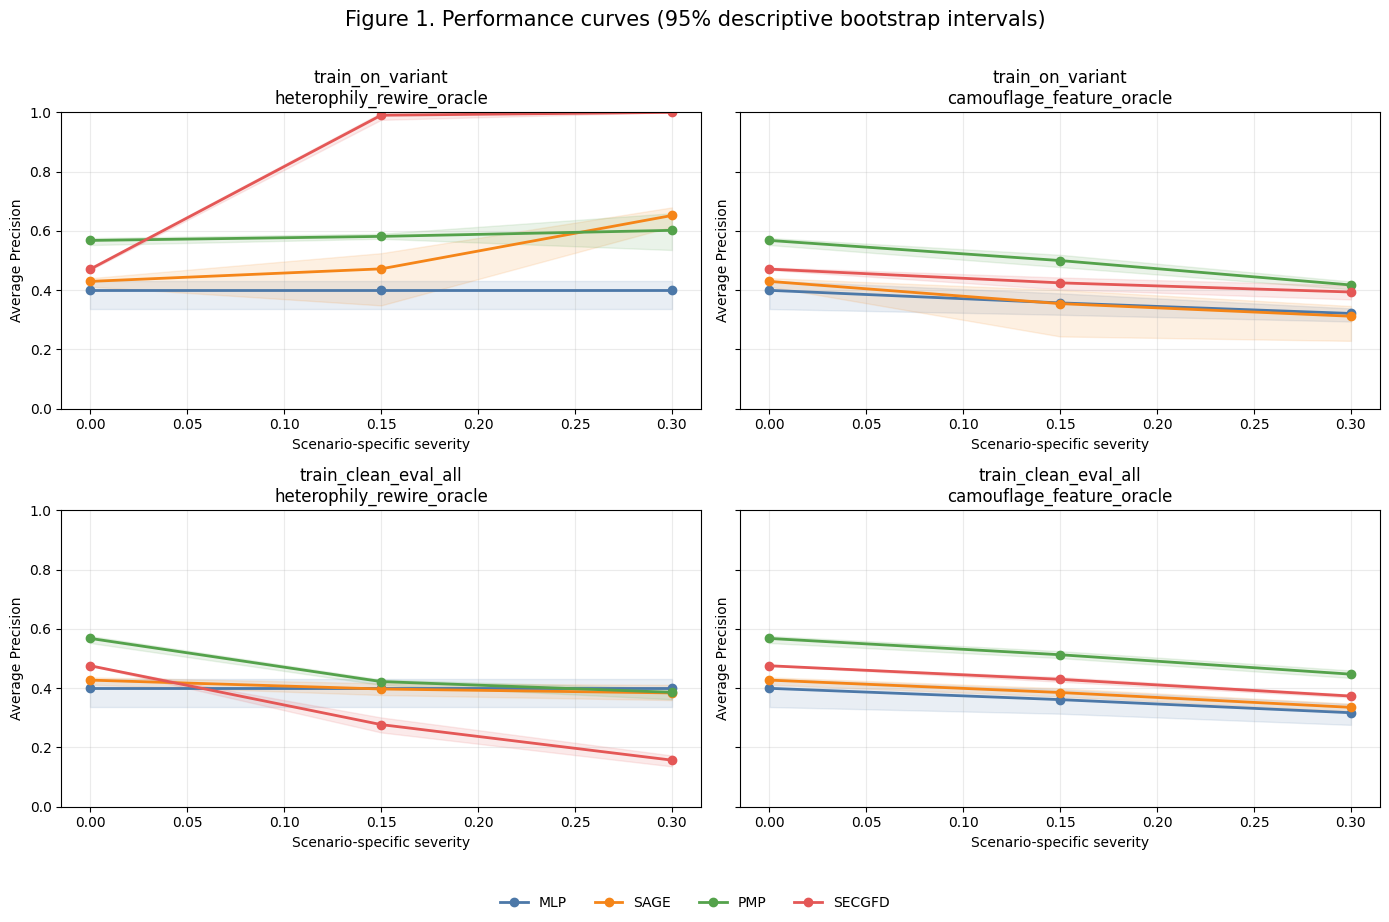

[stage receipt] figure_1


In [61]:
if phase_is_ready('report_complete'):
    STAGE_RECEIPTS.pop('figure_1', None)
    require_phase('report_complete')
    require_variables('summary_curves')
    # Figure 1: Average Precision curves for two representative oracle stresses.
    PRESENTATION_DIR = OUT_DIR / 'presentation'
    PRESENTATION_DIR.mkdir(exist_ok=True)
    colors = {'mlp': '#4C78A8', 'sage': '#F58518', 'pmp': '#54A24B', 'secgfd': '#E45756'}
    representative = ['heterophily_rewire_oracle', 'camouflage_feature_oracle']

    fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey=True)
    for row, protocol in enumerate(PROTOCOL_ORDER):
        for col, scenario in enumerate(representative):
            ax = axes[row, col]
            subset = summary_curves[
                summary_curves['protocol'].eq(protocol)
                & summary_curves['scenario_id'].eq(scenario)
                & summary_curves['metric'].eq('average_precision')
            ]
            for model in MODEL_ORDER:
                part = subset[subset['model_id'].eq(model)].sort_values('severity')
                x = part['severity'].to_numpy(float)
                y = part['mean'].to_numpy(float)
                ax.plot(x, y, marker='o', linewidth=2, label=model.upper(), color=colors[model])
                if {'ci_lower', 'ci_upper'}.issubset(part.columns):
                    ax.fill_between(
                        x,
                        part['ci_lower'].to_numpy(float),
                        part['ci_upper'].to_numpy(float),
                        color=colors[model],
                        alpha=0.12,
                    )
            ax.set_title(f'{protocol}\n{scenario}')
            ax.set_xlabel('Scenario-specific severity')
            ax.set_ylabel('Average Precision')
            ax.set_ylim(0, 1)
            ax.grid(alpha=0.25)
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=4, frameon=False)
    fig.suptitle('Figure 1. Performance curves (95% descriptive bootstrap intervals)', y=1.01, fontsize=15)
    fig.tight_layout(rect=(0, 0.06, 1, 1))
    figure_1 = PRESENTATION_DIR / 'figure_1_ap_curves.png'
    fig.savefig(figure_1, dpi=180, bbox_inches='tight')
    plt.show()
    assert figure_1.is_file() and figure_1.stat().st_size > 0
    record_stage_receipt('figure_1', {
        'path': str(figure_1.relative_to(OUT_DIR)), 'sha256': sha256_file(figure_1),
    })
else:
    print('BLOCKED: report_complete prerequisite is not satisfied in this run attempt.')


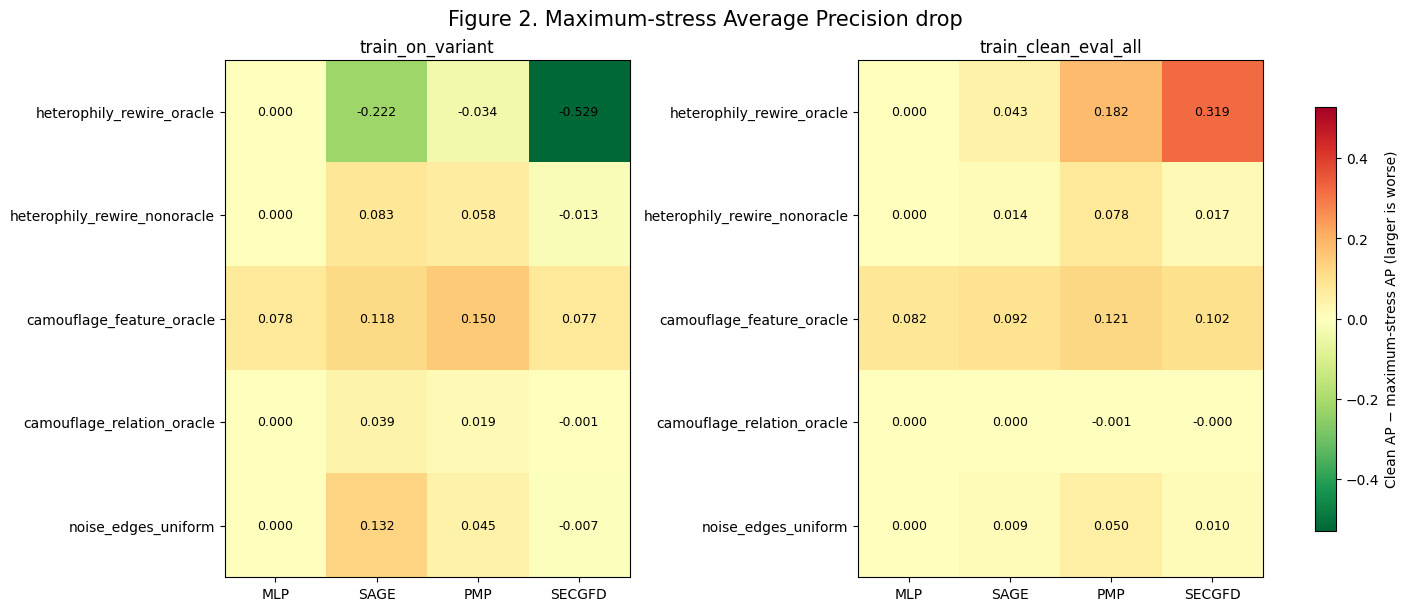

[stage receipt] figure_2


In [62]:
if phase_is_ready('report_complete'):
    STAGE_RECEIPTS.pop('figure_2', None)
    require_phase('report_complete')
    require_variables('ap_drops')
    # Figure 2: clean-to-maximum-stress Average Precision drop for every scenario.
    matrices = []
    for protocol in PROTOCOL_ORDER:
        matrix = ap_drops[ap_drops['protocol'].eq(protocol)].pivot(
            index='scenario_id', columns='model_id', values='drop_mean'
        ).reindex(index=SCENARIO_ORDER, columns=MODEL_ORDER)
        matrices.append(matrix)

    bound = max(abs(np.nanmin([m.to_numpy() for m in matrices])), abs(np.nanmax([m.to_numpy() for m in matrices])), 0.01)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
    for ax, protocol, matrix in zip(axes, PROTOCOL_ORDER, matrices):
        image = ax.imshow(matrix.to_numpy(), cmap='RdYlGn_r', vmin=-bound, vmax=bound, aspect='auto')
        ax.set_xticks(range(len(MODEL_ORDER)), [m.upper() for m in MODEL_ORDER])
        ax.set_yticks(range(len(SCENARIO_ORDER)), SCENARIO_ORDER)
        ax.set_title(protocol)
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                value = matrix.iloc[i, j]
                ax.text(j, i, f'{value:.3f}', ha='center', va='center', fontsize=9)
    fig.colorbar(image, ax=axes, shrink=0.82, label='Clean AP − maximum-stress AP (larger is worse)')
    fig.suptitle('Figure 2. Maximum-stress Average Precision drop', fontsize=15)
    figure_2 = PRESENTATION_DIR / 'figure_2_ap_drop_heatmap.png'
    fig.savefig(figure_2, dpi=180, bbox_inches='tight')
    plt.show()
    assert figure_2.is_file() and figure_2.stat().st_size > 0
    record_stage_receipt('figure_2', {
        'path': str(figure_2.relative_to(OUT_DIR)), 'sha256': sha256_file(figure_2),
    })
else:
    print('BLOCKED: report_complete prerequisite is not satisfied in this run attempt.')


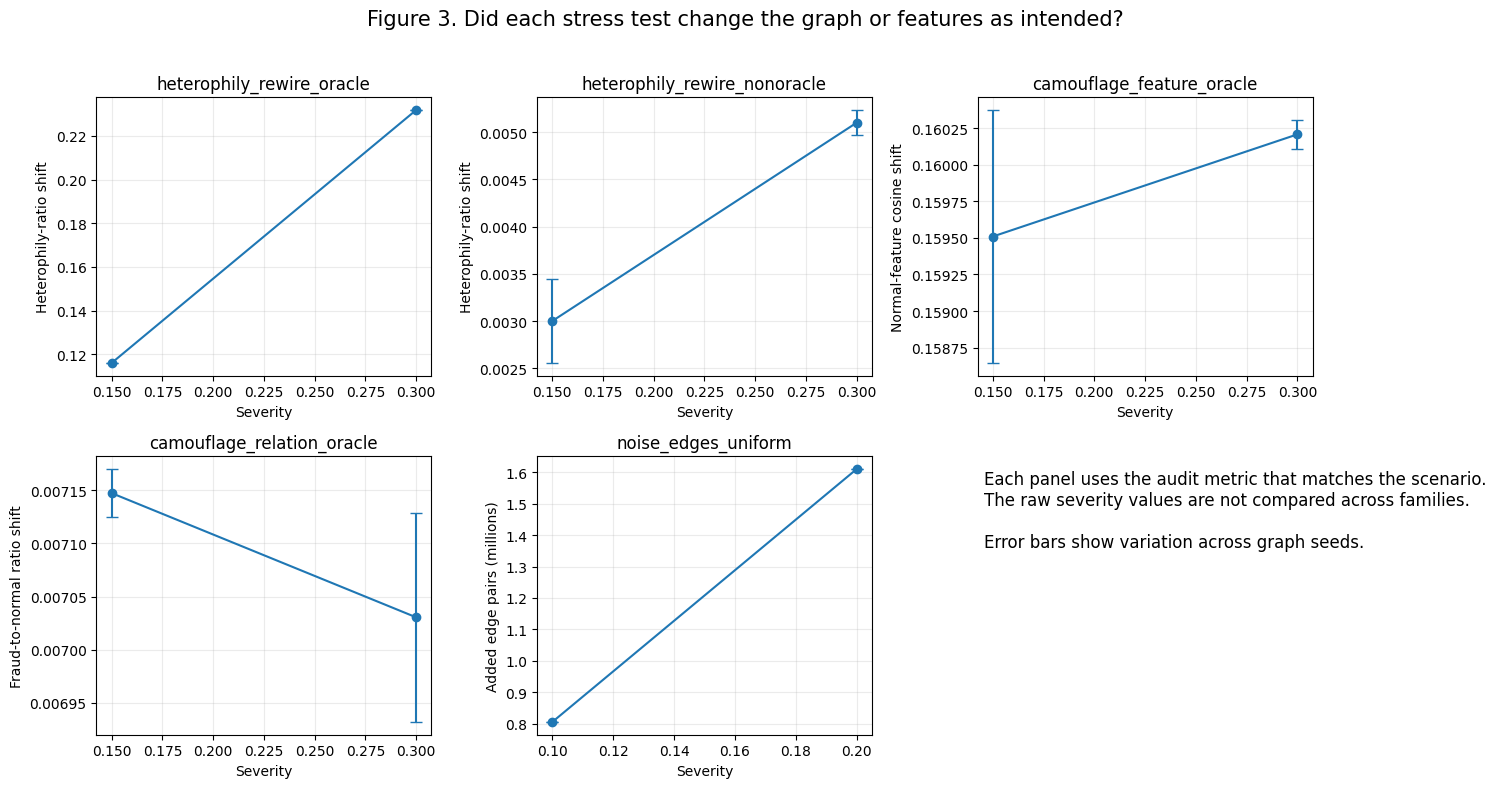

[stage receipt] figure_3


In [63]:
if phase_is_ready('report_complete'):
    STAGE_RECEIPTS.pop('figure_3', None)
    require_phase('report_complete')
    require_variables('audit')
    # Figure 3: realized perturbation evidence, with each family kept in its own units.
    plot_specs = [
        ('heterophily_rewire_oracle', 'heterophily_ratio_before', 'heterophily_ratio_after', 'Heterophily-ratio shift'),
        ('heterophily_rewire_nonoracle', 'heterophily_ratio_before', 'heterophily_ratio_after', 'Heterophily-ratio shift'),
        (
            'camouflage_feature_oracle',
            'mean_cosine_to_sampled_normal_before',
            'mean_cosine_to_sampled_normal_after',
            'Normal-feature cosine shift',
        ),
        (
            'camouflage_relation_oracle',
            'fraud_to_normal_neighbor_ratio_before',
            'fraud_to_normal_neighbor_ratio_after',
            'Fraud-to-normal ratio shift',
        ),
    ]

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    for ax, (scenario, before, after, ylabel) in zip(axes.flat, plot_specs):
        part = audit[audit['scenario_id'].eq(scenario) & audit['severity'].gt(0)].copy()
        part['effect'] = pd.to_numeric(part[after]) - pd.to_numeric(part[before])
        stats = part.groupby('severity')['effect'].agg(['mean', 'std']).reset_index()
        ax.errorbar(stats['severity'], stats['mean'], yerr=stats['std'].fillna(0), marker='o', capsize=4)
        ax.set_title(scenario)
        ax.set_xlabel('Severity')
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.25)

    noise_ax = axes.flat[4]
    noise = audit[audit['scenario_id'].eq('noise_edges_uniform') & audit['severity'].gt(0)].copy()
    noise['added_millions'] = pd.to_numeric(noise['n_added_edge_pairs_actual']) / 1_000_000
    noise_stats = noise.groupby('severity')['added_millions'].agg(['mean', 'std']).reset_index()
    noise_ax.errorbar(
        noise_stats['severity'], noise_stats['mean'], yerr=noise_stats['std'].fillna(0), marker='o', capsize=4
    )
    noise_ax.set_title('noise_edges_uniform')
    noise_ax.set_xlabel('Severity')
    noise_ax.set_ylabel('Added edge pairs (millions)')
    noise_ax.grid(alpha=0.25)

    axes.flat[5].axis('off')
    axes.flat[5].text(
        0.02,
        0.95,
        'Each panel uses the audit metric that matches the scenario.\n'
        'The raw severity values are not compared across families.\n\n'
        'Error bars show variation across graph seeds.',
        va='top',
        fontsize=12,
    )
    fig.suptitle('Figure 3. Did each stress test change the graph or features as intended?', fontsize=15)
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    figure_3 = PRESENTATION_DIR / 'figure_3_realized_audit.png'
    fig.savefig(figure_3, dpi=180, bbox_inches='tight')
    plt.show()
    assert figure_3.is_file() and figure_3.stat().st_size > 0
    record_stage_receipt('figure_3', {
        'path': str(figure_3.relative_to(OUT_DIR)), 'sha256': sha256_file(figure_3),
    })
else:
    print('BLOCKED: report_complete prerequisite is not satisfied in this run attempt.')


## Data-driven interpretation checks

I do not hard-code a winner before the run. The next cells derive conclusions from the fresh results. The MLP gives a useful control: under the clean-train protocol, edge-only changes should not alter its predictions because it does not read graph edges. Feature camouflage can change it because node features are edited.


In [64]:
if phase_is_ready('report_complete'):
    STAGE_RECEIPTS.pop('mlp_invariant', None)
    require_phase('report_complete')
    require_variables('results')
    # Verify the feature-only MLP invariant under graph-only test-time shifts.
    shift_mlp = results[
        results['protocol'].eq('train_clean_eval_all') & results['model_id'].eq('mlp')
    ].copy()
    clean_by_seed = shift_mlp[shift_mlp['scenario_id'].eq('clean')][
        ['training_seed', 'average_precision']
    ].rename(columns={'average_precision': 'clean_ap'})
    edge_scenarios = [
        'heterophily_rewire_oracle',
        'heterophily_rewire_nonoracle',
        'camouflage_relation_oracle',
        'noise_edges_uniform',
    ]
    edge_rows = shift_mlp[shift_mlp['scenario_id'].isin(edge_scenarios)].merge(
        clean_by_seed, on='training_seed', how='left'
    )
    edge_rows['absolute_ap_difference'] = (
        edge_rows['average_precision'] - edge_rows['clean_ap']
    ).abs()
    mlp_edge_check = edge_rows.groupby('scenario_id')['absolute_ap_difference'].max().reset_index()
    display(mlp_edge_check)
    assert set(mlp_edge_check['scenario_id']) == set(edge_scenarios), (
        set(mlp_edge_check['scenario_id']), set(edge_scenarios)
    )
    max_mlp_edge_difference = float(mlp_edge_check['absolute_ap_difference'].max())
    assert np.isfinite(max_mlp_edge_difference), 'MLP invariant received no finite rows.'
    assert max_mlp_edge_difference < 1e-10, max_mlp_edge_difference

    feature_rows = shift_mlp[shift_mlp['scenario_id'].eq('camouflage_feature_oracle')]
    max_severity = feature_rows['severity'].max()
    feature_delta = (
        feature_rows.loc[feature_rows['severity'].eq(max_severity), 'average_precision'].mean()
        - clean_by_seed['clean_ap'].mean()
    )
    print(f'MLP AP change at maximum feature camouflage: {feature_delta:+.4f}')
    record_stage_receipt('mlp_invariant', {
        'max_graph_only_ap_difference': max_mlp_edge_difference,
        'max_feature_camouflage_ap_change': float(feature_delta),
    })
else:
    print('BLOCKED: report_complete prerequisite is not satisfied in this run attempt.')


,scenario_id,absolute_ap_difference
0,camouflage_relation_oracle,0.0
1,heterophily_rewire_nonoracle,0.0
2,heterophily_rewire_oracle,0.0
3,noise_edges_uniform,0.0


MLP AP change at maximum feature camouflage: -0.0824
[stage receipt] mlp_invariant


In [65]:
if phase_is_ready('report_complete'):
    STAGE_RECEIPTS.pop('findings', None)
    require_phase('report_complete')
    require_variables('ap_drops', 'protocol_contrasts')
    # Report absolute stressed AP and paired loss together; do not rank by drop alone.
    best_rows = []
    for (protocol, scenario), group in ap_drops.groupby(['protocol', 'scenario_id']):
        row = group.loc[group['max_severity_mean'].idxmax()]
        best_rows.append({
            'protocol': protocol,
            'scenario': scenario,
            'best_stressed_AP_model': row['model_id'],
            'best_stressed_AP': row['max_severity_mean'],
            'paired_clean_minus_stress_AP': row['drop_mean'],
            'claim_scope': row['claim_scope'],
            'operational_ranking_eligible': row['operational_ranking_eligible'],
        })
    findings = pd.DataFrame(best_rows).sort_values(['protocol', 'scenario'])
    display(findings)

    ap_contrasts = protocol_contrasts[
        protocol_contrasts['metric'].eq('average_precision')
    ].copy()
    max_severity_mask = ap_contrasts['severity'].eq(
        ap_contrasts.groupby('scenario_id')['severity'].transform('max')
    )
    max_ap_contrasts = ap_contrasts[max_severity_mask].sort_values(
        ['scenario_id', 'model_id']
    )
    display(max_ap_contrasts[[
        'scenario_id', 'model_id', 'contrast_definition', 'contrast_mean',
        'contrast_ci_lower', 'contrast_ci_upper', 'claim_scope',
        'operational_ranking_eligible',
    ]])
    findings.to_csv(PRESENTATION_DIR / 'within_scenario_ap_findings.csv', index=False)
    print('Positive protocol contrasts mean train-on-variant AP exceeded clean-train shift AP.')
    findings_path = PRESENTATION_DIR / 'within_scenario_ap_findings.csv'
    assert findings_path.is_file() and not findings.empty
    record_stage_receipt('findings', {
        'rows': len(findings), 'sha256': sha256_file(findings_path),
    })
else:
    print('BLOCKED: report_complete prerequisite is not satisfied in this run attempt.')


,protocol,scenario,best_stressed_AP_model,best_stressed_AP,paired_clean_minus_stress_AP,claim_scope,operational_ranking_eligible
0,train_clean_eval_all,camouflage_feature_oracle,pmp,0.447107,0.120618,oracle_shift_sensitivity_diagnostic,False
1,train_clean_eval_all,camouflage_relation_oracle,pmp,0.568436,-0.000711,oracle_shift_sensitivity_diagnostic,False
2,train_clean_eval_all,heterophily_rewire_nonoracle,pmp,0.489475,0.078250,non_oracle_controlled_stress,True
3,train_clean_eval_all,heterophily_rewire_oracle,mlp,0.399380,0.000000,oracle_shift_sensitivity_diagnostic,False
4,train_clean_eval_all,noise_edges_uniform,pmp,0.517810,0.049915,non_oracle_controlled_stress,True
5,train_on_variant,camouflage_feature_oracle,pmp,0.417391,0.150334,oracle_privileged_training_diagnostic,False
6,train_on_variant,camouflage_relation_oracle,pmp,0.549079,0.018646,oracle_privileged_training_diagnostic,False
7,train_on_variant,heterophily_rewire_nonoracle,pmp,0.509394,0.058331,non_oracle_controlled_stress,True
8,train_on_variant,heterophily_rewire_oracle,secgfd,0.999999,-0.529051,oracle_privileged_training_diagnostic,False
9,train_on_variant,noise_edges_uniform,pmp,0.522772,0.044953,non_oracle_controlled_stress,True


,scenario_id,model_id,contrast_definition,contrast_mean,contrast_ci_lower,contrast_ci_upper,claim_scope,operational_ranking_eligible
97,camouflage_feature_oracle,mlp,train_on_variant - train_clean_eval_all,0.004343,-0.008822,0.038962,oracle_protocol_comparison_diagnostic,False
103,camouflage_feature_oracle,pmp,train_on_variant - train_clean_eval_all,-0.029716,-0.049006,-0.015569,oracle_protocol_comparison_diagnostic,False
100,camouflage_feature_oracle,sage,train_on_variant - train_clean_eval_all,-0.023255,-0.093270,0.004920,oracle_protocol_comparison_diagnostic,False
106,camouflage_feature_oracle,secgfd,train_on_variant - train_clean_eval_all,0.020401,-0.008602,0.043279,oracle_protocol_comparison_diagnostic,False
133,camouflage_relation_oracle,mlp,train_on_variant - train_clean_eval_all,0.000000,0.000000,0.000000,oracle_protocol_comparison_diagnostic,False
139,camouflage_relation_oracle,pmp,train_on_variant - train_clean_eval_all,-0.019357,-0.030756,-0.005853,oracle_protocol_comparison_diagnostic,False
136,camouflage_relation_oracle,sage,train_on_variant - train_clean_eval_all,-0.036238,-0.144994,0.003999,oracle_protocol_comparison_diagnostic,False
142,camouflage_relation_oracle,secgfd,train_on_variant - train_clean_eval_all,-0.003978,-0.012502,0.002591,oracle_protocol_comparison_diagnostic,False
61,heterophily_rewire_nonoracle,mlp,train_on_variant - train_clean_eval_all,0.000000,0.000000,0.000000,non_oracle_controlled_stress,True
67,heterophily_rewire_nonoracle,pmp,train_on_variant - train_clean_eval_all,0.019919,0.009935,0.035100,non_oracle_controlled_stress,True


Positive protocol contrasts mean train-on-variant AP exceeded clean-train shift AP.
[stage receipt] findings


## Limitations and safe conclusions

My conclusions are deliberately narrow:

- This is one dataset and one fixed split. Crossed graph and training seeds measure two within-split sources of variation, but they do not replace repeated independent splits or datasets.
- Report intervals now preserve training/graph seed axes, pair clean and stressed rows, and keep complete severity trajectories together. With only three training and two graph seeds they remain descriptive, not population-level significance claims.
- Oracle heterophily and both camouflage scenarios use true labels during construction. Oracle shift rows are sensitivity diagnostics; oracle train-on-variant rows are privileged-label training diagnostics and are ineligible for operational ranking.
- Severity has a different meaning in every family. I compare models within one scenario and use `variant_audit.csv` to describe the realized change.
- R5 severity variants are deterministic but not guaranteed to be nested prefixes, and the non-oracle feature partition is severity-specific in this frozen config. Non-monotonic curves are not pure dose-response evidence.
- Relation-aware scenarios are generated on YelpChi's source heterograph, but every model is evaluated on the same homogeneous graph. This improves surface consistency but removes native relation-specific downstream behavior.
- The inline config uses feasible benchmark-side settings for PMP and SEC-GFD. The SEC-GFD adapter contains disclosed training-index and cosine-domain repairs needed for finite, split-correct loss computation. This is an integrated comparison, not an exact reproduction of every paper's full setup.
- CUDA runs are seeded, but bitwise determinism is not guaranteed across every GPU kernel. Concurrent lane durations are not fair speed comparisons because processes share CPU, RAM, and disk bandwidth.

The safe result statement is: **under the same controlled scenario, severity, protocol, cached graph, and claim scope, the observed curves show how these integrated adapters behaved in this fixed-split run.** I do not use them to claim production readiness, realistic attacker robustness, or stable cross-dataset rankings.


In [66]:
if phase_is_ready('report_complete') and stage_receipts_ready(
    *sorted(FINAL_REQUIRED_STAGE_RECEIPTS)
):
    # Revalidate the evidence, atomically build the report bundle, and declare completion.
    require_phase('report_complete')
    require_variables('figure_1', 'figure_2', 'figure_3')

    final_results_raw = read_csv_if_present(results_path)
    results = preferred_results(final_results_raw)
    scientific_key = [
        'dataset_id', 'split_id', 'scenario_id', 'severity', 'graph_seed',
        'training_seed', 'model_id', 'protocol',
    ]
    if len(final_results_raw) != N_TOTAL_RESULTS or len(results) != N_TOTAL_RESULTS:
        raise RuntimeError(
            f'Final result count changed before packaging: raw={len(final_results_raw)}, '
            f'canonical={len(results)}, expected={N_TOTAL_RESULTS}.'
        )
    if results.duplicated(scientific_key).any():
        raise RuntimeError('Duplicate scientific keys appeared before packaging.')
    if not results['status'].astype(str).str.lower().eq('ok').all():
        raise RuntimeError('At least one final result has non-ok status.')
    assert_exact_result_keys(
        results,
        protocol='train_on_variant',
        label='packaged standard protocol',
    )
    assert_exact_result_keys(
        results,
        protocol='train_clean_eval_all',
        label='packaged shift protocol',
    )
    final_metrics = results[['roc_auc', 'average_precision', 'f1_macro', 'threshold']].apply(
        pd.to_numeric, errors='coerce'
    )
    if not np.isfinite(final_metrics.to_numpy()).all():
        raise RuntimeError('At least one final result metric is non-finite.')

    missing_path = OUT_DIR / 'plots' / 'missing_or_error_runs.csv'
    require_paths([missing_path], 'report completeness audit')
    missing_or_error = pd.read_csv(missing_path)
    if not missing_or_error.empty:
        raise RuntimeError(
            f'The report audit still contains {len(missing_or_error)} missing/error rows.'
        )
    for figure in (figure_1, figure_2, figure_3):
        if not Path(figure).is_file() or Path(figure).stat().st_size == 0:
            raise RuntimeError(f'Missing or empty presentation figure: {figure}')

    MANIFEST['completed_utc'] = datetime.now(timezone.utc).isoformat()
    MANIFEST['final_result_rows'] = len(results)
    MANIFEST['missing_or_error_rows'] = len(missing_or_error)
    MANIFEST['presentation_figures'] = {
        str(Path(path).relative_to(OUT_DIR)): sha256_file(Path(path))
        for path in (figure_1, figure_2, figure_3)
    }
    MANIFEST['run_status'] = 'packaging'
    MANIFEST['updated_utc'] = datetime.now(timezone.utc).isoformat()
    persist_manifest()

    upstream_text = '\n'.join(
        f"{name}: {spec['url']} @ {spec['commit']}" for name, spec in ACTIVE_UPSTREAMS.items()
    )
    README_TEXT = textwrap.dedent(
        f'''
        Fraud Detection Robustness Benchmark - report bundle
        Notebook implementation: {NOTEBOOK_IMPLEMENTATION_ID}
        Current project repository downloaded: no
        Config SHA-256: {CONFIG_SHA256}
        Complete result rows: {N_TOTAL_RESULTS}

        Downloaded research repositories:
        {upstream_text}

        This bundle contains report evidence, summaries, figures, manifests, and logs.
        It intentionally excludes data/, graphs/, lanes/, smoke/, the isolated Python
        runtime, and the upstream clones to avoid duplicating several GiB. The notebook
        itself remains the authoritative source implementation.
        '''
    ).strip() + '\n'
    readme_path = OUT_DIR / 'REPORT_BUNDLE_README.txt'
    readme_path.write_text(README_TEXT, encoding='utf-8')

    include_roots = [OUT_DIR / 'plots', OUT_DIR / 'presentation', OUT_DIR / 'logs']
    include_files = [
        readme_path,
        RUN_FINGERPRINT_PATH,
        OUT_DIR / 'config.json',
        ledger_path,
        audit_path,
        results_path,
        OUT_DIR / 'results_summary_baselines.csv',
        OUT_DIR / 'results_summary_pmp.csv',
        OUT_DIR / 'results_summary_secgfd.csv',
        OUT_DIR / 'results_summary_shift.csv',
    ]
    for root in include_roots:
        include_files.extend(path for path in root.rglob('*') if path.is_file())
    include_files = sorted(set(include_files))
    missing_bundle_files = [str(path) for path in include_files if not path.is_file()]
    if missing_bundle_files:
        raise RuntimeError('Missing report-bundle files:\n' + '\n'.join(missing_bundle_files))

    # The archive gets a complete manifest. The external manifest receives the
    # archive's size and hash afterward, avoiding a self-referential ZIP hash.
    bundle_manifest = json.loads(json.dumps(MANIFEST))
    bundle_manifest['run_status'] = 'complete'
    bundle_manifest['bundle_manifest_scope'] = (
        'Internal completion evidence; ZIP size and SHA-256 are in the external manifest.'
    )
    bundle_manifest_path = OUT_DIR / '.kaggle_run_manifest.bundle.json'
    bundle_manifest_path.write_text(json.dumps(bundle_manifest, indent=2), encoding='utf-8')

    report_zip_temp = REPORT_ZIP.with_suffix('.zip.tmp')
    if report_zip_temp.exists():
        report_zip_temp.unlink()
    try:
        with zipfile.ZipFile(
            report_zip_temp,
            'w',
            compression=zipfile.ZIP_DEFLATED,
            compresslevel=6,
        ) as archive:
            for path in tqdm(include_files, desc='Build report bundle', unit='file'):
                archive.write(path, arcname=str(path.relative_to(OUT_DIR)))
            archive.write(bundle_manifest_path, arcname='kaggle_run_manifest.json')

        with zipfile.ZipFile(report_zip_temp, 'r') as archive:
            corrupt_member = archive.testzip()
            if corrupt_member is not None:
                raise RuntimeError(f'Corrupt ZIP member: {corrupt_member}')
            internal_manifest = json.loads(archive.read('kaggle_run_manifest.json'))
            if internal_manifest.get('run_status') != 'complete':
                raise RuntimeError('Internal report manifest is not complete.')
            if 'results.csv' not in archive.namelist():
                raise RuntimeError('Report ZIP is missing results.csv.')
        report_zip_temp.replace(REPORT_ZIP)
    finally:
        bundle_manifest_path.unlink(missing_ok=True)
        if report_zip_temp.exists():
            report_zip_temp.unlink()

    MANIFEST['report_zip_bytes'] = REPORT_ZIP.stat().st_size
    MANIFEST['report_zip_sha256'] = sha256_file(REPORT_ZIP)
    mark_phase('complete')

    def directory_size(path: Path) -> int:
        return sum(item.stat().st_size for item in path.rglob('*') if item.is_file())

    storage = pd.DataFrame([
        {'area': 'notebook source + upstream repos', 'GiB': directory_size(SOURCE_ROOT) / 1024**3},
        {'area': 'isolated runtime', 'GiB': directory_size(RUNTIME_DIR) / 1024**3},
        {'area': 'downloaded dataset cache', 'GiB': directory_size(OUT_DIR / 'data') / 1024**3},
        {'area': 'graph cache', 'GiB': directory_size(OUT_DIR / 'graphs') / 1024**3},
        {'area': 'all experiment outputs', 'GiB': directory_size(OUT_DIR) / 1024**3},
        {'area': 'light report zip', 'GiB': REPORT_ZIP.stat().st_size / 1024**3},
    ])
    display(storage.round(3))
    print('Report bundle:', REPORT_ZIP)
    print(current_resource_line())
    assert MANIFEST['run_status'] == 'complete'
    print('FINAL_STATUS=complete')
else:
    missing_stage_receipts = sorted(
        name for name in globals().get('FINAL_REQUIRED_STAGE_RECEIPTS', set())
        if not stage_receipts_ready(name)
    )
    print(
        'BLOCKED: report phase or current-attempt presentation/interpretation receipts are incomplete. '
        f'missing_stage_receipts={missing_stage_receipts}'
    )


Build report bundle:   0%|          | 0/130 [00:00<?, ?file/s]

Pipeline phase: complete


,area,GiB
0,notebook source + upstream repos,0.012
1,isolated runtime,5.331
2,downloaded dataset cache,0.336
3,graph cache,5.323
4,all experiment outputs,5.668
5,light report zip,0.006


Report bundle: /kaggle/working/gfd-robustness-v3-report-r6.zip
GPU(index,util%,MiB): 0, 0, 0, 15360 | 1, 0, 0, 15360; RAM used=1.7 GiB; disk free=8.5 GiB
FINAL_STATUS=complete


## Final hand-off

Cell position alone does not prove that the experiment succeeded. A valid run is complete only when the previous cell prints `FINAL_STATUS=complete`, `kaggle_run_manifest.json` contains `"run_status": "complete"`, `results.csv` has exactly 504 canonical successful rows, and `plots/missing_or_error_runs.csv` is empty.

No current project repository is cloned. The notebook contains the benchmark implementation and compact experiment definition; the only downloaded project sources are the pinned PMP and SEC-GFD repositories allowed by `Repos/Github-links.md`, plus YelpChi through DGL. `gfd-robustness-v3-report-r6.zip` is the lightweight evidence bundle for the report and professor presentation.
